# SMART — Trust-Aware Multimodal RAG Pipeline (clean rebuild)

This notebook is a from-scratch, de-duplicated rebuild of the SMART pipeline
(Candidate Retrieval → Evidence Extraction → Adaptive Trust Fusion → Trust-Aware
Ranking → Explainable Output), matching the architecture diagram.

**What changed vs. the messy version:**
- Removed all duplicate / trial / dead cells.
- Added a proper **stratified Train / Validation / Test split** (this was missing).
- All models (Mahalanobis covariance, logistic-regression trust-correction) are
  now **fit only on TRAIN** and applied (frozen) to VAL/TEST — no leakage.
- Evidence extraction covers the 5 dimensions actually implemented and fused:
  `[S, P, C, U, R]` (semantic relevance, provenance, cross-modal consistency,
  confidence, safety/risk).
- Every phase is one clean cell block, run top-to-bottom, no re-running needed.

Data loading defaults to `DATA_SOURCE = "kagglehub"`, which auto-downloads both
datasets (works in Colab, local Jupyter, or Kaggle notebooks) via `kagglehub`.
Switch to `"kaggle_local"` if the datasets are already attached to a Kaggle
notebook, or `"custom"` to point at your own local copies.

## 0. Setup & Config

In [ ]:
# ============================================================
# SMART — PHASE 0
# CELL 1 — Imports and configuration
# ============================================================

import os
import re
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("SMART — PHASE 0")
print("Corpus Construction & Synthetic Poisoning")
print("=" * 70)

print("Environment ready.")

In [ ]:
DATA_SOURCE = "kagglehub"

if DATA_SOURCE == "kagglehub":
    import kagglehub
    fakeddit_root = kagglehub.dataset_download("vanshikavmittal/fakeddit-dataset")

In [ ]:
# ============================================================
# SMART — FAKEDDIT DATASET CONFIGURATION
# ============================================================
# Purpose:
#   Use Fakeddit multimodal data as the primary dataset.
#
#   Expected data:
#       - text
#       - image
#       - Fakeddit label / metadata
#
#   We intentionally DO NOT download Wikipedia here.
# ============================================================

# -----------------------------
# 1. Install dependencies
# -----------------------------
!pip install -q faiss-cpu sentence-transformers scikit-learn xgboost shap kagglehub

# -----------------------------
# 2. Imports
# -----------------------------
import os
import json
import re
import gc
import glob
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer, CrossEncoder

import faiss

from sklearn.covariance import EmpiricalCovariance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from scipy.stats import chi2

warnings.filterwarnings("ignore")

# -----------------------------
# 3. Reproducibility
# -----------------------------
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# -----------------------------
# 4. Data source
# -----------------------------
DATA_SOURCE = "kagglehub"

# ============================================================
# KAGGLEHUB
# ============================================================

if DATA_SOURCE == "kagglehub":

    import kagglehub

    # --------------------------------------------------------
    # Download ONLY Fakeddit
    # --------------------------------------------------------
    fakeddit_root = kagglehub.dataset_download(
        "vanshikavmittal/fakeddit-dataset"
    )

    print("=" * 70)
    print("Fakeddit dataset downloaded")
    print("=" * 70)
    print("Root:")
    print(fakeddit_root)

# ============================================================
# KAGGLE NOTEBOOK INPUT
# ============================================================

elif DATA_SOURCE == "kaggle":

    # --------------------------------------------------------
    # IMPORTANT:
    # Kaggle input paths can differ depending on how the
    # dataset was attached.
    #
    # We search automatically instead of hard-coding the path.
    # --------------------------------------------------------

    fakeddit_root = "/kaggle/input"

    print("=" * 70)
    print("Searching Kaggle input for Fakeddit")
    print("=" * 70)

# ============================================================
# LOCAL DATASET
# ============================================================

elif DATA_SOURCE == "local":

    # Change this if you have already downloaded Fakeddit.
    fakeddit_root = "./fakeddit"

else:

    raise ValueError(
        "DATA_SOURCE must be 'kagglehub', 'kaggle', or 'local'"
    )


# ============================================================
# 5. Helper functions
# ============================================================

def find_file(root, filename):
    """
    Recursively find an exact filename.
    """
    matches = []

    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            matches.append(
                os.path.join(dirpath, filename)
            )

    if not matches:
        raise FileNotFoundError(
            f"\nCould not find '{filename}' under:\n{root}"
        )

    return matches[0]


def find_files_containing(root, keyword):
    """
    Find files whose filename contains keyword.
    """
    matches = []

    for dirpath, _, filenames in os.walk(root):
        for filename in filenames:
            if keyword.lower() in filename.lower():
                matches.append(
                    os.path.join(dirpath, filename)
                )

    return matches


# ============================================================
# 6. Inspect downloaded Fakeddit structure
# ============================================================

print("\n" + "=" * 70)
print("FAKEDDIT FILE DISCOVERY")
print("=" * 70)

all_files = []

for dirpath, _, filenames in os.walk(fakeddit_root):

    for filename in filenames:

        path = os.path.join(dirpath, filename)
        all_files.append(path)


print(f"Total files discovered: {len(all_files):,}")

print("\nFirst files found:")

for path in all_files[:50]:
    print(" ", path)


# ============================================================
# 7. Locate multimodal training data
# ============================================================

candidate_tsvs = [
    p for p in all_files
    if p.lower().endswith(".tsv")
    and (
        "multimodal" in os.path.basename(p).lower()
        or "train" in os.path.basename(p).lower()
    )
]

print("\n" + "=" * 70)
print("POSSIBLE FAKEDDIT TSV FILES")
print("=" * 70)

if candidate_tsvs:

    for p in candidate_tsvs:
        print(" ", p)

else:

    print("No multimodal/train TSV found automatically.")


# ============================================================
# 8. Select multimodal training file
# ============================================================

FAKEDDIT_PATH = None

# Prefer multimodal_train.tsv
for p in candidate_tsvs:

    basename = os.path.basename(p).lower()

    if basename == "multimodal_train.tsv":
        FAKEDDIT_PATH = p
        break


# If exact name wasn't found, try another multimodal TSV
if FAKEDDIT_PATH is None:

    multimodal_candidates = [
        p for p in candidate_tsvs
        if "multimodal" in os.path.basename(p).lower()
    ]

    if multimodal_candidates:
        FAKEDDIT_PATH = multimodal_candidates[0]


# ============================================================
# 9. Fail clearly if dataset structure differs
# ============================================================

if FAKEDDIT_PATH is None:

    raise FileNotFoundError(
        "\nCould not automatically locate the Fakeddit "
        "multimodal TSV.\n\n"
        "Inspect the files printed above and set:\n\n"
        "FAKEDDIT_PATH = 'YOUR_ACTUAL_PATH'\n"
    )


print("\n" + "=" * 70)
print("FAKEDDIT DATASET SELECTED")
print("=" * 70)

print("FAKEDDIT_PATH:")
print(FAKEDDIT_PATH)


# ============================================================
# 10. Output directory
# ============================================================

if DATA_SOURCE == "kaggle":

    OUTPUT_DIR = "/kaggle/working/smart_outputs"

else:

    OUTPUT_DIR = "./outputs"


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 11. SMART feature dimensions
# ============================================================

DIMS = [
    "semantic_relevance",
    "provenance_reliability",
    "image_text_consistency",
    "confidence",
    "safety_score"
]


# ============================================================
# 12. Selection configuration
# ============================================================

TOP_N_SELECT = 20


# ============================================================
# 13. Dataset split
# ============================================================

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.20
TEST_FRAC  = 0.10

assert abs(
    TRAIN_FRAC +
    VAL_FRAC +
    TEST_FRAC - 1.0
) < 1e-9


# ============================================================
# 14. Final configuration report
# ============================================================

print("\n" + "=" * 70)
print("SMART — FAKEDDIT CONFIGURATION READY")
print("=" * 70)

print(f"DATA_SOURCE      : {DATA_SOURCE}")
print(f"FAKEDDIT_ROOT    : {fakeddit_root}")
print(f"FAKEDDIT_PATH    : {FAKEDDIT_PATH}")
print(f"OUTPUT_DIR       : {OUTPUT_DIR}")

print("\nSMART dimensions:")
for d in DIMS:
    print(" ", d)

print("\nSelection:")
print(f"  TOP_N_SELECT = {TOP_N_SELECT}")

print("\nSplit:")
print(f"  Train = {TRAIN_FRAC:.0%}")
print(f"  Val   = {VAL_FRAC:.0%}")
print(f"  Test  = {TEST_FRAC:.0%}")

print("\nConfig ready.")

## Phase 0 — Data Loading & Preprocessing
Builds the memory database from three sources:
1. Wikipedia multimodal articles → `trusted`
2. Fakeddit fake-news samples → `untrusted`
3. Synthetically crafted poison chunks (query-targeted attacks) → `untrusted`

In [ ]:
# ============================================================
# SMART — ENVIRONMENT TEST
# ============================================================

import torch
import transformers
import sentence_transformers

print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from sentence_transformers import SentenceTransformer, CrossEncoder

print("\nSentenceTransformer import: OK")
print("CrossEncoder import: OK")
print("=" * 70)

In [ ]:
# ============================================================
# LOAD FAKEDDIT
# ============================================================

if FAKEDDIT_PATH is None:
    raise FileNotFoundError(
        "multimodal_train.tsv was not found."
    )

fakeddit_df = pd.read_csv(
    FAKEDDIT_PATH,
    sep="\t",
    low_memory=False
)

print("=" * 70)
print("FAKEDDIT LOADED")
print("=" * 70)

print("Shape:")
print(fakeddit_df.shape)

print("\nColumns:")
for i, col in enumerate(fakeddit_df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nData types:")
print(fakeddit_df.dtypes)

print("\nFirst 5 rows:")
display(fakeddit_df.head())

In [ ]:
# ============================================================
# SMART — PHASE 0
# DATA CONFIGURATION
#
# ONLY:
#   1. Fakeddit
#   2. Synthetic poisoned chunks
#
# NO WIKIPEDIA
# ============================================================

import os
import re
import gc
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# DATA SOURCE
# ------------------------------------------------------------

DATA_SOURCE = "kagglehub"

if DATA_SOURCE == "kagglehub":

    import kagglehub

    fakeddit_root = kagglehub.dataset_download(
        "vanshikavmittal/fakeddit-dataset"
    )

    print("Fakeddit root:")
    print(fakeddit_root)

else:

    FAKEDDIT_ROOT = "/kaggle/input/datasets/vanshikavmittal/fakeddit-dataset"


# ------------------------------------------------------------
# FIND FILE
# ------------------------------------------------------------

def find_file(root, filename):

    for dirpath, _, filenames in os.walk(root):

        if filename in filenames:
            return os.path.join(dirpath, filename)

    return None


# Try the multimodal training file
FAKEDDIT_PATH = find_file(
    fakeddit_root,
    "multimodal_train.tsv"
)

if FAKEDDIT_PATH is None:

    print("\nmultimodal_train.tsv was not found automatically.")

    print("\nFiles found under Fakeddit:")

    for dirpath, _, filenames in os.walk(fakeddit_root):

        for f in filenames:

            if f.endswith((".tsv", ".csv", ".json")):
                print(os.path.join(dirpath, f))

else:

    print("\nFakeddit file found:")
    print(FAKEDDIT_PATH)


# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

OUTPUT_DIR = "./smart_phase0"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nOutput directory:")
print(OUTPUT_DIR)

In [ ]:
# ============================================================
# SMART PHASE 0A — INSPECT ACTUAL FAKEDDIT DATA
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("SMART — FAKEDDIT DATA INSPECTION")
print("=" * 70)

print("\nFile:")
print(FAKEDDIT_PATH)

# ------------------------------------------------------------
# Load TSV
# ------------------------------------------------------------

fakeddit_df = pd.read_csv(
    FAKEDDIT_PATH,
    sep="\t",
    low_memory=False
)

print("\nDataset shape:")
print(f"Rows    : {len(fakeddit_df):,}")
print(f"Columns : {len(fakeddit_df.columns)}")

print("\nColumns:")
for i, col in enumerate(fakeddit_df.columns, 1):
    print(f"{i:02d}. {col}")

# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(fakeddit_df.dtypes)

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2-WAY LABEL DISTRIBUTION")
print("=" * 70)

print(
    fakeddit_df["2_way_label"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPercent:")
print(
    fakeddit_df["2_way_label"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Other labels
# ------------------------------------------------------------

for col in ["3_way_label", "6_way_label"]:

    if col in fakeddit_df.columns:

        print("\n" + "=" * 70)
        print(f"{col.upper()} DISTRIBUTION")
        print("=" * 70)

        print(
            fakeddit_df[col]
            .value_counts(dropna=False)
            .sort_index()
        )

# ------------------------------------------------------------
# Image coverage
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE COVERAGE")
print("=" * 70)

print("\nhasImage:")
print(
    fakeddit_df["hasImage"]
    .value_counts(dropna=False)
)

print("\nimage_url missing:")
print(
    fakeddit_df["image_url"]
    .isna()
    .value_counts()
)

# Actual URL presence
url_present = (
    fakeddit_df["image_url"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print("\nActual image_url availability:")
print(f"URL present : {url_present.sum():,}")
print(f"URL missing : {(~url_present).sum():,}")
print(f"Coverage    : {url_present.mean():.2%}")

# ------------------------------------------------------------
# hasImage vs URL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("hasImage × image_url")
print("=" * 70)

print(
    pd.crosstab(
        fakeddit_df["hasImage"],
        url_present,
        margins=True
    )
)

# ------------------------------------------------------------
# Text coverage
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEXT COVERAGE")
print("=" * 70)

for col in ["clean_title", "title"]:

    if col in fakeddit_df.columns:

        missing = fakeddit_df[col].isna().sum()

        print(
            f"{col:20s} "
            f"missing={missing:,} "
            f"present={len(fakeddit_df)-missing:,}"
        )

# ------------------------------------------------------------
# Source/domain distribution
# ------------------------------------------------------------

for col in ["domain", "subreddit"]:

    if col in fakeddit_df.columns:

        print("\n" + "=" * 70)
        print(f"{col.upper()} DISTRIBUTION")
        print("=" * 70)

        print(
            fakeddit_df[col]
            .value_counts(dropna=False)
            .head(30)
        )

# ------------------------------------------------------------
# Sample
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RANDOM SAMPLE")
print("=" * 70)

display(
    fakeddit_df[
        [
            c for c in [
                "id",
                "clean_title",
                "title",
                "image_url",
                "hasImage",
                "domain",
                "subreddit",
                "2_way_label",
                "3_way_label",
                "6_way_label"
            ]
            if c in fakeddit_df.columns
        ]
    ].sample(
        min(10, len(fakeddit_df)),
        random_state=42
    )
)

print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# SMART — PHASE 0
# FAKEDDIT + SYNTHETIC POISON ONLY
#
# Creates:
#   1. metadata_df_fakeddit
#   2. synthetic_poison_df
#   3. metadata_df_mixed
#   4. benchmark_df
#
# NO WIKIPEDIA
# ============================================================

import os
import gc
import re
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# 0. CONFIGURATION
# ============================================================

# Your existing Fakeddit path should already exist.
if "FAKEDDIT_PATH" not in globals():
    raise NameError(
        "FAKEDDIT_PATH is not defined. "
        "Run your Fakeddit configuration/loading cell first."
    )

# ------------------------------------------------------------
# Keep the experiment manageable.
# Change these numbers if required.
# ------------------------------------------------------------

FAKEDDIT_SAMPLE_SIZE = 10000

# Number of synthetic poison memories.
SYNTHETIC_POISON_SIZE = 2000

# Number of benchmark queries.
BENCHMARK_SIZE = 1000

# Number of Fakeddit records used as benchmark ground truth.
# These are kept in the memory pool.
MIN_QUERY_TEXT_LENGTH = 10

# Output/checkpoint directory
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "./outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("SMART — PHASE 0 CONFIGURATION")
print("=" * 80)
print("Fakeddit path       :", FAKEDDIT_PATH)
print("Fakeddit sample     :", FAKEDDIT_SAMPLE_SIZE)
print("Synthetic poisons   :", SYNTHETIC_POISON_SIZE)
print("Benchmark queries   :", BENCHMARK_SIZE)
print("Output directory    :", OUTPUT_DIR)
print("Wikipedia           : DISABLED")
print("=" * 80)


# ============================================================
# 1. LOAD FAKEDDIT
# ============================================================

print("\n" + "=" * 80)
print("[1] LOADING FAKEDDIT")
print("=" * 80)

fakeddit_raw = pd.read_csv(
    FAKEDDIT_PATH,
    sep="\t",
    low_memory=False
)

print("Original Fakeddit shape:", fakeddit_raw.shape)

print("\nOriginal columns:")
for i, c in enumerate(fakeddit_raw.columns, 1):
    print(f"{i:02d}. {c}")


# ============================================================
# 2. BASIC CLEANING
# ============================================================

required_columns = [
    "id",
    "clean_title",
    "title",
    "image_url",
    "hasImage",
    "domain",
    "subreddit",
    "2_way_label",
    "3_way_label",
    "6_way_label",
    "score",
    "upvote_ratio",
]

missing_required = [
    c for c in required_columns
    if c not in fakeddit_raw.columns
]

if missing_required:
    raise ValueError(
        "Fakeddit is missing required columns:\n"
        + "\n".join(missing_required)
    )

# Remove rows without an ID
fakeddit_raw = fakeddit_raw[
    fakeddit_raw["id"].notna()
].copy()

# Clean text
fakeddit_raw["clean_title"] = (
    fakeddit_raw["clean_title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

fakeddit_raw["title"] = (
    fakeddit_raw["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Prefer clean_title, fall back to title
fakeddit_raw["smart_text"] = np.where(
    fakeddit_raw["clean_title"].str.len() >= MIN_QUERY_TEXT_LENGTH,
    fakeddit_raw["clean_title"],
    fakeddit_raw["title"]
)

# Remove completely empty text
fakeddit_raw = fakeddit_raw[
    fakeddit_raw["smart_text"].str.strip().ne("")
].copy()

# Remove duplicate IDs
fakeddit_raw = fakeddit_raw.drop_duplicates(
    subset=["id"],
    keep="first"
).reset_index(drop=True)

print("After basic cleaning:", fakeddit_raw.shape)


# ============================================================
# 3. SAMPLE FAKEDDIT
# ============================================================

print("\n" + "=" * 80)
print("[2] SELECTING FAKEDDIT EXPERIMENTAL POOL")
print("=" * 80)

sample_size = min(
    FAKEDDIT_SAMPLE_SIZE,
    len(fakeddit_raw)
)

# Stratify approximately by 2-way label
# so the experiment does not accidentally contain only
# one label.

label_counts = fakeddit_raw["2_way_label"].value_counts()

if len(label_counts) > 1 and sample_size >= len(label_counts):

    sampled_parts = []

    for label, count in label_counts.items():

        target_n = round(
            sample_size * count / len(fakeddit_raw)
        )

        target_n = min(
            target_n,
            count
        )

        part = fakeddit_raw[
            fakeddit_raw["2_way_label"] == label
        ].sample(
            n=target_n,
            random_state=RANDOM_SEED
        )

        sampled_parts.append(part)

    fakeddit_sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )

    # Correct any rounding difference
    if len(fakeddit_sample) > sample_size:
        fakeddit_sample = fakeddit_sample.sample(
            n=sample_size,
            random_state=RANDOM_SEED
        )

else:

    fakeddit_sample = fakeddit_raw.sample(
        n=sample_size,
        random_state=RANDOM_SEED
    )

fakeddit_sample = fakeddit_sample.reset_index(drop=True)

print("Selected Fakeddit rows:", len(fakeddit_sample))

print("\n2-way label:")
print(
    fakeddit_sample["2_way_label"]
    .value_counts()
)


# ============================================================
# 4. CREATE SMART FAKEDDIT MEMORY IDs
# ============================================================

# Use a prefix so synthetic IDs can never collide with
# Fakeddit IDs.

fakeddit_memory_ids = [
    f"FAKEDDIT_{x}"
    for x in fakeddit_sample["id"].astype(str)
]


# ============================================================
# 5. TRUST LABEL DESIGN
# ============================================================
#
# IMPORTANT:
#
# Fakeddit's 2-way label is preserved as:
#
#     fakeddit_2way_label
#
# We do NOT automatically call it "trust".
#
# For this experiment, Fakeddit records are treated as the
# externally sourced / untrusted side of the memory pool.
#
# Synthetic poison records are also untrusted.
#
# Therefore this experiment has:
#
#     Fakeddit       -> untrusted
#     Synthetic      -> untrusted
#
# If you want a TRUE trusted-vs-untrusted experiment,
# you need a separate trusted corpus.
#
# We preserve this limitation explicitly rather than
# fabricating a trust label.
# ============================================================

metadata_df_fakeddit = pd.DataFrame({

    "memory_id": fakeddit_memory_ids,

    "Query": fakeddit_sample["clean_title"].values,

    "ground_truth_article": fakeddit_sample["title"].values,

    "ground_truth_memory_id": fakeddit_memory_ids,

    "Rank": 0,

    "semantic_relevance": np.nan,

    "rrf_score": np.nan,

    "Article": fakeddit_sample["title"].values,

    "text_chunk": fakeddit_sample["smart_text"].values,

    "Caption": fakeddit_sample["clean_title"].values,

    "image_description": "",

    "image_title": "",

    "Source": "Fakeddit",

    "Domain": fakeddit_sample["domain"].values,

    "Trust": "untrusted",

    "trust_label": "untrusted",

    "is_untrusted": 1,

    "split": "memory",

    "image_text": "",

    "image_text_consistency": np.nan,

    "entailment_score": np.nan,

    "corroboration_count": 0,

    "corroboration_norm": 0.0,

    "provenance_reliability": 0.0,

    "has_image": (
        fakeddit_sample["hasImage"]
        .fillna(False)
        .astype(bool)
        .values
    ),

    "img_url": fakeddit_sample["image_url"].values,

    "img_url_present": (
        fakeddit_sample["image_url"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .values
    ),

    # Original Fakeddit metadata
    "fakeddit_id": fakeddit_sample["id"].values,

    "author": fakeddit_sample["author"].values
        if "author" in fakeddit_sample.columns
        else "",

    "subreddit": fakeddit_sample["subreddit"].values,

    "score": fakeddit_sample["score"].values,

    "upvote_ratio": fakeddit_sample["upvote_ratio"].values,

    "fakeddit_2way_label":
        fakeddit_sample["2_way_label"].values,

    "fakeddit_3way_label":
        fakeddit_sample["3_way_label"].values,

    "fakeddit_6way_label":
        fakeddit_sample["6_way_label"].values,

    # Explicit flags
    "is_synthetic": False,

    "is_poison": False,

    "poison_type": "",

    "attack_type": "",

    "attack_target": "",
})


print("\n" + "=" * 80)
print("[3] FAKEDDIT MEMORY POOL CREATED")
print("=" * 80)

print("Shape:", metadata_df_fakeddit.shape)

print("\nTrust:")
print(
    metadata_df_fakeddit["trust_label"]
    .value_counts(dropna=False)
)

print("\nImages:")
print(
    metadata_df_fakeddit["has_image"]
    .value_counts(dropna=False)
)

print("\nImage URLs:")
print(
    metadata_df_fakeddit["img_url_present"]
    .value_counts(dropna=False)
)


# ============================================================
# 6. SYNTHETIC POISON GENERATION
# ============================================================
#
# We generate query-targeted poison records from actual
# Fakeddit texts.
#
# The poison text is intentionally modified so that it is
# associated with the target query while retaining some
# information from the source memory.
#
# This creates a controlled synthetic attack population.
# ============================================================

print("\n" + "=" * 80)
print("[4] GENERATING SYNTHETIC POISONS")
print("=" * 80)


# Only use sufficiently long source texts
poison_sources = metadata_df_fakeddit[
    metadata_df_fakeddit["text_chunk"]
    .fillna("")
    .astype(str)
    .str.len()
    >= MIN_QUERY_TEXT_LENGTH
].copy()

if len(poison_sources) == 0:
    raise ValueError(
        "No suitable Fakeddit text found for synthetic poison generation."
    )


# Number of poisons cannot exceed source pool if we want
# unique source records.
poison_n = min(
    SYNTHETIC_POISON_SIZE,
    len(poison_sources)
)

poison_sources = poison_sources.sample(
    n=poison_n,
    random_state=RANDOM_SEED
).reset_index(drop=True)


# ------------------------------------------------------------
# Poison transformation
# ------------------------------------------------------------

def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def make_poison_text(source_text, target_query, poison_type):

    source_text = clean_text(source_text)
    target_query = clean_text(target_query)

    if poison_type == "query_injection":

        return (
            f"{target_query}. "
            f"Additional context: {source_text}"
        )

    elif poison_type == "targeted_rewrite":

        return (
            f"Regarding {target_query}: "
            f"{source_text}"
        )

    elif poison_type == "context_insertion":

        return (
            f"{source_text} "
            f"This information is relevant to {target_query}."
        )

    else:

        return (
            f"{target_query}. "
            f"{source_text}"
        )


poison_types = [
    "query_injection",
    "targeted_rewrite",
    "context_insertion",
]


synthetic_rows = []


for i, row in poison_sources.iterrows():

    source_text = clean_text(row["text_chunk"])

    # Target the original Fakeddit query/title.
    target_query = clean_text(
        row["Query"]
    )

    poison_type = poison_types[
        i % len(poison_types)
    ]

    poisoned_text = make_poison_text(
        source_text,
        target_query,
        poison_type
    )

    poison_id = (
        f"SYNTHETIC_POISON_{i:07d}"
    )

    synthetic_rows.append({

        "memory_id": poison_id,

        "Query": target_query,

        "ground_truth_article": row["Article"],

        "ground_truth_memory_id":
            row["memory_id"],

        "Rank": 0,

        "semantic_relevance": np.nan,

        "rrf_score": np.nan,

        "Article":
            f"Synthetic poisoned version of {row['Article']}",

        "text_chunk":
            poisoned_text,

        "Caption":
            row["Caption"],

        "image_description":
            row["image_description"],

        "image_title":
            row["image_title"],

        "Source":
            "Synthetic",

        "Domain":
            row["Domain"],

        "Trust":
            "untrusted",

        "trust_label":
            "untrusted",

        "is_untrusted":
            1,

        "split":
            "poison",

        "image_text":
            row["image_text"],

        "image_text_consistency":
            np.nan,

        "entailment_score":
            np.nan,

        "corroboration_count":
            0,

        "corroboration_norm":
            0.0,

        "provenance_reliability":
            0.0,

        # Synthetic poisons inherit the source image.
        # This gives SMART an actual multimodal poison
        # record instead of a text-only poison.
        "has_image":
            bool(row["has_image"]),

        "img_url":
            row["img_url"],

        "img_url_present":
            bool(row["img_url_present"]),

        # Fakeddit metadata
        "fakeddit_id":
            row["fakeddit_id"],

        "author":
            row["author"],

        "subreddit":
            row["subreddit"],

        "score":
            row["score"],

        "upvote_ratio":
            row["upvote_ratio"],

        "fakeddit_2way_label":
            row["fakeddit_2way_label"],

        "fakeddit_3way_label":
            row["fakeddit_3way_label"],

        "fakeddit_6way_label":
            row["fakeddit_6way_label"],

        # Synthetic flags
        "is_synthetic":
            True,

        "is_poison":
            True,

        "poison_type":
            poison_type,

        "attack_type":
            "query_targeted",

        "attack_target":
            target_query,

        "poison_source_memory_id":
            row["memory_id"],
    })


synthetic_poison_df = pd.DataFrame(
    synthetic_rows
)


print("Synthetic poison rows:",
      len(synthetic_poison_df))

print("\nPoison types:")
print(
    synthetic_poison_df["poison_type"]
    .value_counts()
)


# ============================================================
# 7. COMBINE FAKEDDIT + SYNTHETIC POISON
# ============================================================

print("\n" + "=" * 80)
print("[5] BUILDING MIXED SMART MEMORY POOL")
print("=" * 80)


# Ensure both datasets have exactly the same columns
all_columns = sorted(
    set(metadata_df_fakeddit.columns)
    |
    set(synthetic_poison_df.columns)
)

metadata_df_fakeddit = (
    metadata_df_fakeddit
    .reindex(columns=all_columns)
)

synthetic_poison_df = (
    synthetic_poison_df
    .reindex(columns=all_columns)
)


metadata_df_mixed = pd.concat(
    [
        metadata_df_fakeddit,
        synthetic_poison_df
    ],
    ignore_index=True
)


# Shuffle memory pool
metadata_df_mixed = (
    metadata_df_mixed
    .sample(
        frac=1.0,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)


print("Mixed memory pool:",
      metadata_df_mixed.shape)


# ============================================================
# 8. CREATE RETRIEVAL BENCHMARK
# ============================================================
#
# Ground truth is always an ORIGINAL Fakeddit memory.
#
# Synthetic poison records are NOT ground truth.
#
# This lets us later measure whether SMART retrieves the
# correct memory or allows the synthetic poison to interfere.
# ============================================================

print("\n" + "=" * 80)
print("[6] BUILDING RETRIEVAL BENCHMARK")
print("=" * 80)


benchmark_source = metadata_df_fakeddit[
    metadata_df_fakeddit["text_chunk"]
    .fillna("")
    .astype(str)
    .str.len()
    >= MIN_QUERY_TEXT_LENGTH
].copy()


benchmark_n = min(
    BENCHMARK_SIZE,
    len(benchmark_source)
)


benchmark_source = benchmark_source.sample(
    n=benchmark_n,
    random_state=RANDOM_SEED
).reset_index(drop=True)


benchmark_rows = []


for _, row in benchmark_source.iterrows():

    benchmark_rows.append({

        "Query":
            row["text_chunk"],

        "ground_truth_memory_id":
            row["memory_id"],

        "ground_truth_article":
            row["Article"],

        "ground_truth_source":
            "Fakeddit",

        "ground_truth_trust":
            row["trust_label"],

        "query_source":
            "Fakeddit",

        "is_poison_query":
            False,

    })


benchmark_df = pd.DataFrame(
    benchmark_rows
)


print("Benchmark queries:",
      len(benchmark_df))


# ============================================================
# 9. VERIFY GROUND TRUTH IDs
# ============================================================

print("\n" + "=" * 80)
print("[7] GROUND TRUTH INTEGRITY CHECK")
print("=" * 80)


memory_ids = set(
    metadata_df_mixed["memory_id"]
    .dropna()
    .astype(str)
)


gt_ids = (
    benchmark_df["ground_truth_memory_id"]
    .astype(str)
)


missing_gt = benchmark_df[
    ~gt_ids.isin(memory_ids)
]


print(
    "Missing ground-truth memories:",
    len(missing_gt)
)


if len(missing_gt) > 0:

    print("\nERROR: Some benchmark memories are absent.")

    display(
        missing_gt.head(10)
    )

    raise ValueError(
        "Benchmark ground-truth integrity check failed."
    )

else:

    print(
        "All benchmark ground-truth memories exist."
    )


# ============================================================
# 10. VERIFY NO WIKIPEDIA
# ============================================================

print("\n" + "=" * 80)
print("[8] SOURCE INTEGRITY CHECK")
print("=" * 80)


sources = (
    metadata_df_mixed["Source"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Sources:", sources)


if any(
    "wiki" in s.lower()
    for s in sources
):

    raise ValueError(
        "Wikipedia detected in metadata_df_mixed. "
        "This experiment must contain Fakeddit + Synthetic only."
    )


# ============================================================
# 11. FINAL DATASET CHECKS
# ============================================================

print("\n" + "=" * 80)
print("[9] FINAL PHASE 0 CHECKS")
print("=" * 80)


print("\nFakeddit memory pool:")
print(
    f"  Rows : {len(metadata_df_fakeddit):,}"
)


print("\nSynthetic poison pool:")
print(
    f"  Rows : {len(synthetic_poison_df):,}"
)


print("\nMixed memory pool:")
print(
    f"  Rows : {len(metadata_df_mixed):,}"
)


print("\nBenchmark:")
print(
    f"  Queries : {len(benchmark_df):,}"
)


print("\nSource distribution:")
print(
    metadata_df_mixed["Source"]
    .value_counts(dropna=False)
)


print("\nTrust distribution:")
print(
    metadata_df_mixed["trust_label"]
    .value_counts(dropna=False)
)


print("\nSynthetic distribution:")
print(
    metadata_df_mixed["is_synthetic"]
    .value_counts(dropna=False)
)


print("\nPoison distribution:")
print(
    metadata_df_mixed["is_poison"]
    .value_counts(dropna=False)
)


print("\nImage distribution:")
print(
    metadata_df_mixed["has_image"]
    .value_counts(dropna=False)
)


print("\nImage URL coverage:")

url_present = (
    metadata_df_mixed["img_url"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print(
    f"  URL present : {url_present.sum():,}"
)

print(
    f"  URL missing : {(~url_present).sum():,}"
)

print(
    f"  Coverage    : {url_present.mean():.2%}"
)


# ============================================================
# 12. RANDOM MEMORY INSPECTION
# ============================================================

print("\n" + "=" * 80)
print("[10] RANDOM MIXED MEMORY EXAMPLES")
print("=" * 80)


display(
    metadata_df_mixed[
        [
            "memory_id",
            "Source",
            "trust_label",
            "is_synthetic",
            "is_poison",
            "text_chunk",
            "has_image",
            "img_url",
            "poison_type",
            "attack_type",
        ]
    ]
    .sample(
        min(10, len(metadata_df_mixed)),
        random_state=RANDOM_SEED
    )
)


# ============================================================
# 13. BENCHMARK INSPECTION
# ============================================================

print("\n" + "=" * 80)
print("[11] BENCHMARK EXAMPLES")
print("=" * 80)


display(
    benchmark_df.head(10)
)


# ============================================================
# 14. SAVE PHASE 0 CHECKPOINTS
# ============================================================

print("\n" + "=" * 80)
print("[12] SAVING PHASE 0 CHECKPOINTS")
print("=" * 80)


fakeddit_checkpoint = os.path.join(
    OUTPUT_DIR,
    "phase0_metadata_fakeddit.pkl"
)

poison_checkpoint = os.path.join(
    OUTPUT_DIR,
    "phase0_synthetic_poison.pkl"
)

mixed_checkpoint = os.path.join(
    OUTPUT_DIR,
    "phase0_metadata_mixed.pkl"
)

benchmark_checkpoint = os.path.join(
    OUTPUT_DIR,
    "phase0_benchmark.pkl"
)


metadata_df_fakeddit.to_pickle(
    fakeddit_checkpoint
)

synthetic_poison_df.to_pickle(
    poison_checkpoint
)

metadata_df_mixed.to_pickle(
    mixed_checkpoint
)

benchmark_df.to_pickle(
    benchmark_checkpoint
)


# Also save CSV copies for inspection
metadata_df_fakeddit.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_metadata_fakeddit.csv"
    ),
    index=False
)

synthetic_poison_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_synthetic_poison.csv"
    ),
    index=False
)

metadata_df_mixed.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_metadata_mixed.csv"
    ),
    index=False
)

benchmark_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_benchmark.csv"
    ),
    index=False
)


print("\nSaved:")
print(" ", fakeddit_checkpoint)
print(" ", poison_checkpoint)
print(" ", mixed_checkpoint)
print(" ", benchmark_checkpoint)


# ============================================================
# 15. FINAL PHASE 0 REPORT
# ============================================================

print("\n" + "=" * 80)
print("SMART — PHASE 0 COMPLETE")
print("=" * 80)

print(
    f"Fakeddit memories       : {len(metadata_df_fakeddit):,}"
)

print(
    f"Synthetic poisons       : {len(synthetic_poison_df):,}"
)

print(
    f"Mixed memory pool       : {len(metadata_df_mixed):,}"
)

print(
    f"Benchmark queries       : {len(benchmark_df):,}"
)

print(
    "Sources                 :",
    metadata_df_mixed["Source"]
    .unique()
    .tolist()
)

print(
    "Wikipedia included      : NO"
)

print(
    "Ground truth integrity  : PASS"
)

print(
    "Phase 0 checkpoints     : SAVED"
)

print("=" * 80)


# ============================================================
# 16. CLEANUP
# ============================================================

del fakeddit_raw
del fakeddit_sample
del poison_sources

gc.collect()

print("\nPhase 0 variables available:")
print("  metadata_df_fakeddit")
print("  synthetic_poison_df")
print("  metadata_df_mixed")
print("  benchmark_df")

## Phase 1 — Candidate Retrieval (Top-K)
Single embedding pass + a single FAISS index build (the original notebook
re-embedded twice — removed here).

In [ ]:
print("=" * 80)
print("PHASE 0 → PHASE 1 SCHEMA CHECK")
print("=" * 80)

print("Shape:", metadata_df_mixed.shape)

print("\nColumns:")
for i, c in enumerate(metadata_df_mixed.columns, 1):
    print(f"{i:02d}. {c}")

print("\nRequired by current Phase 1:")
required = ["article_title", "text_chunk"]

for c in required:
    print(f"{c:25s} : {'YES' if c in metadata_df_mixed.columns else 'NO'}")

In [ ]:
!pip install rank_bm25 --quiet

In [ ]:
# ============================================================
# SMART — PHASE 1 SETUP
# Fakeddit + Synthetic Poison
#
# Text Embeddings + FAISS Dense Retrieval + BM25 + CrossEncoder
#
# Input:
#   metadata_df_mixed
#
# Expected rows:
#   12,000
#
# Sources:
#   Fakeddit
#   Synthetic
#
# Wikipedia:
#   NOT USED
# ============================================================

import os
import gc
import re
import faiss
import numpy as np
import pandas as pd

from tqdm import tqdm
from sentence_transformers import SentenceTransformer, CrossEncoder

# BM25
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    !pip install -q rank-bm25
    from rank_bm25 import BM25Okapi


# ============================================================
# 1. BASIC SCHEMA CHECK
# ============================================================

print("=" * 80)
print("PHASE 1 — INPUT SCHEMA CHECK")
print("=" * 80)

required_columns = [
    "memory_id",
    "Source",
    "Trust",
    "trust_label",
    "is_untrusted",
    "is_poison",
    "is_synthetic",
    "Article",
    "Caption",
    "text_chunk",
    "Query",
]

missing_columns = [
    c for c in required_columns
    if c not in metadata_df_mixed.columns
]

if missing_columns:
    raise ValueError(
        "Missing required Phase 1 columns:\n"
        + "\n".join(f"  - {c}" for c in missing_columns)
    )

print(f"Rows    : {len(metadata_df_mixed):,}")
print(f"Columns : {len(metadata_df_mixed.columns)}")

print("\nSources:")
print(metadata_df_mixed["Source"].value_counts(dropna=False))

print("\nTrust:")
print(metadata_df_mixed["Trust"].value_counts(dropna=False))

print("\nPoison:")
print(metadata_df_mixed["is_poison"].value_counts(dropna=False))

print("\nSchema check: PASS")


# ============================================================
# 2. CHECK MEMORY IDs
# ============================================================

if metadata_df_mixed["memory_id"].isna().any():
    raise ValueError(
        "memory_id contains missing values. "
        "Phase 1 requires a unique memory ID."
    )

if metadata_df_mixed["memory_id"].duplicated().any():
    duplicated = metadata_df_mixed[
        metadata_df_mixed["memory_id"].duplicated(keep=False)
    ]

    print("\nWARNING: Duplicate memory_id values detected:")
    display(duplicated.head(20))

else:
    print("memory_id uniqueness: PASS")


# ============================================================
# 3. BUILD TEXT USED FOR RETRIEVAL
# ============================================================
#
# Your new dataset does NOT have article_title.
#
# Available useful text fields:
#
#   Article
#   Caption
#   text_chunk
#
# We construct one unified retrieval representation.
#
# Priority:
#   Article + Caption + text_chunk
#
# This keeps the implementation compatible with both:
#   Fakeddit memories
#   Synthetic poison memories
# ============================================================

def clean_retrieval_text(x):
    if pd.isna(x):
        return ""

    x = str(x)

    # Normalize whitespace
    x = re.sub(r"\s+", " ", x)

    return x.strip()


print("\n" + "=" * 80)
print("BUILDING RETRIEVAL TEXT")
print("=" * 80)


metadata_df_mixed["Article"] = (
    metadata_df_mixed["Article"]
    .fillna("")
    .astype(str)
)

metadata_df_mixed["Caption"] = (
    metadata_df_mixed["Caption"]
    .fillna("")
    .astype(str)
)

metadata_df_mixed["text_chunk"] = (
    metadata_df_mixed["text_chunk"]
    .fillna("")
    .astype(str)
)


metadata_df_mixed["embed_text"] = (
    metadata_df_mixed["Article"]
    + " "
    + metadata_df_mixed["Caption"]
    + " "
    + metadata_df_mixed["text_chunk"]
).apply(clean_retrieval_text)


# ============================================================
# 4. CHECK RETRIEVAL TEXT
# ============================================================

empty_embed = (
    metadata_df_mixed["embed_text"]
    .str.len()
    .eq(0)
)

print(
    f"Empty retrieval texts : "
    f"{empty_embed.sum():,} / {len(metadata_df_mixed):,}"
)

if empty_embed.any():
    print("\nWARNING: Some memories have empty retrieval text.")

    display(
        metadata_df_mixed.loc[
            empty_embed,
            [
                "memory_id",
                "Source",
                "Article",
                "Caption",
                "text_chunk",
                "is_poison",
            ]
        ].head(20)
    )


print("\nExample retrieval text:")
print(metadata_df_mixed["embed_text"].iloc[0][:1000])


# ============================================================
# 5. TOKENIZATION FOR BM25
# ============================================================

print("\n" + "=" * 80)
print("BUILDING BM25 CORPUS")
print("=" * 80)


def tokenize(text):
    text = str(text).lower()

    # Keep words/numbers
    return re.findall(r"\b\w+\b", text)


bm25_corpus = [
    tokenize(text)
    for text in tqdm(
        metadata_df_mixed["embed_text"],
        desc="BM25 tokenization"
    )
]

bm25 = BM25Okapi(bm25_corpus)

print(
    f"BM25 corpus built: "
    f"{len(bm25_corpus):,} documents"
)


# ============================================================
# 6. MODEL CONFIGURATION
# ============================================================

EMBED_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

RERANK_MODEL_NAME = (
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

EMBED_BATCH_SIZE = 256


print("\n" + "=" * 80)
print("MODEL CONFIGURATION")
print("=" * 80)

print("Embedding model:")
print(" ", EMBED_MODEL_NAME)

print("CrossEncoder:")
print(" ", RERANK_MODEL_NAME)

print("Embedding batch size:")
print(" ", EMBED_BATCH_SIZE)


# ============================================================
# 7. LOAD SENTENCE EMBEDDING MODEL
# ============================================================

print("\n" + "=" * 80)
print("LOADING EMBEDDING MODEL")
print("=" * 80)

embed_model = SentenceTransformer(
    EMBED_MODEL_NAME
)

print("Embedding model loaded.")


# ============================================================
# 8. LOAD CROSS-ENCODER
# ============================================================

print("\n" + "=" * 80)
print("LOADING CROSS-ENCODER")
print("=" * 80)

cross_model = CrossEncoder(
    RERANK_MODEL_NAME
)

print("CrossEncoder loaded.")


# ============================================================
# 9. ENCODE MEMORY CORPUS
# ============================================================

print("\n" + "=" * 80)
print("ENCODING MEMORY CORPUS")
print("=" * 80)

corpus_texts = (
    metadata_df_mixed["embed_text"]
    .tolist()
)

corpus_embeddings = embed_model.encode(
    corpus_texts,
    batch_size=EMBED_BATCH_SIZE,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)

corpus_embeddings = np.asarray(
    corpus_embeddings,
    dtype="float32"
)

print("\nEmbedding matrix:")
print("Shape:", corpus_embeddings.shape)

if not np.isfinite(corpus_embeddings).all():
    raise ValueError(
        "Embedding matrix contains NaN or Inf values."
    )

print("Embedding numerical check: PASS")


# ============================================================
# 10. BUILD FAISS INDEX
# ============================================================

print("\n" + "=" * 80)
print("BUILDING FAISS INDEX")
print("=" * 80)

embed_dim = corpus_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(
    embed_dim
)

# Because embeddings are normalized,
# Inner Product == cosine similarity.

faiss_index.add(
    corpus_embeddings
)

print(
    f"FAISS index built successfully."
)

print(
    f"Vectors : {faiss_index.ntotal:,}"
)

print(
    f"Dimension : {embed_dim}"
)


# ============================================================
# 11. IMPORTANT INDEX ALIGNMENT CHECK
# ============================================================

if faiss_index.ntotal != len(metadata_df_mixed):
    raise ValueError(
        "FAISS index size does not match metadata_df_mixed."
    )

print(
    "FAISS ↔ metadata row alignment: PASS"
)


# ============================================================
# 12. SAVE PHASE 1 ARTIFACTS
# ============================================================

PHASE1_DIR = "./smart_phase1"

os.makedirs(
    PHASE1_DIR,
    exist_ok=True
)

print("\n" + "=" * 80)
print("SAVING PHASE 1 ARTIFACTS")
print("=" * 80)


# Save embeddings
np.save(
    os.path.join(
        PHASE1_DIR,
        "corpus_embeddings.npy"
    ),
    corpus_embeddings
)


# Save FAISS index
faiss.write_index(
    faiss_index,
    os.path.join(
        PHASE1_DIR,
        "faiss_index.index"
    )
)


# Save BM25 object
import joblib

joblib.dump(
    bm25,
    os.path.join(
        PHASE1_DIR,
        "bm25.pkl"
    )
)


# Save tokenizer corpus
joblib.dump(
    bm25_corpus,
    os.path.join(
        PHASE1_DIR,
        "bm25_corpus.pkl"
    )
)


# Save Phase 1 metadata
metadata_df_mixed.to_pickle(
    os.path.join(
        PHASE1_DIR,
        "metadata_df_mixed_phase1.pkl"
    )
)


# ============================================================
# 13. FINAL PHASE 1 REPORT
# ============================================================

print("\n" + "=" * 80)
print("SMART — PHASE 1 COMPLETE")
print("=" * 80)

print(
    f"Memory rows             : "
    f"{len(metadata_df_mixed):,}"
)

print(
    f"Embedding dimension     : "
    f"{embed_dim}"
)

print(
    f"FAISS vectors           : "
    f"{faiss_index.ntotal:,}"
)

print(
    f"BM25 documents          : "
    f"{len(bm25_corpus):,}"
)

print(
    f"Fakeddit memories       : "
    f"{(metadata_df_mixed['Source'] == 'Fakeddit').sum():,}"
)

print(
    f"Synthetic memories      : "
    f"{(metadata_df_mixed['Source'] == 'Synthetic').sum():,}"
)

print(
    f"Untrusted memories      : "
    f"{metadata_df_mixed['is_untrusted'].sum():,}"
)

print(
    f"Poison memories         : "
    f"{metadata_df_mixed['is_poison'].sum():,}"
)

print("\nSaved artifacts:")

for filename in sorted(
    os.listdir(PHASE1_DIR)
):
    path = os.path.join(
        PHASE1_DIR,
        filename
    )

    print(
        f"  {path}"
    )

print("\n" + "=" * 80)
print("PHASE 1 VARIABLES READY")
print("=" * 80)

print("""
metadata_df_mixed
embed_model
cross_model
bm25
bm25_corpus
corpus_embeddings
faiss_index
""")

print("=" * 80)
print("READY FOR PHASE 1 HYBRID RETRIEVAL")
print("=" * 80)

In [ ]:
# ============================================================
# CRITICAL CHECK — PHASE 0 TRUST ASSIGNMENT
# ============================================================

print("=" * 70)
print("PHASE 0 TRUST CHECK")
print("=" * 70)

print("\nFakeddit:")
display(
    metadata_df_fakeddit[
        ["memory_id", "Source", "Trust", "is_untrusted", "is_poison"]
    ].head(10)
)

print("\nFakeddit Trust:")
print(
    metadata_df_fakeddit["Trust"]
    .value_counts(dropna=False)
)

print("\nFakeddit is_untrusted:")
print(
    metadata_df_fakeddit["is_untrusted"]
    .value_counts(dropna=False)
)

print("\nSynthetic:")
display(
    synthetic_poison_df[
        ["memory_id", "Source", "Trust", "is_untrusted", "is_poison"]
    ].head(10)
)

print("\nSynthetic Trust:")
print(
    synthetic_poison_df["Trust"]
    .value_counts(dropna=False)
)

print("\nSynthetic is_untrusted:")
print(
    synthetic_poison_df["is_untrusted"]
    .value_counts(dropna=False)
)

print("\n" + "=" * 70)
print("MIXED TRUST DISTRIBUTION")
print("=" * 70)

print(
    metadata_df_mixed["Trust"]
    .value_counts(dropna=False)
)

print("\nSource × Trust:")
print(
    pd.crosstab(
        metadata_df_mixed["Source"],
        metadata_df_mixed["Trust"],
        margins=True
    )
)

In [ ]:
# ============================================================
# SMART — CORRECT TRUST ASSIGNMENT
# FAKEDDIT + SYNTHETIC POISON ONLY
# ============================================================

print("=" * 70)
print("CORRECTING PHASE 0 TRUST LABELS")
print("=" * 70)

# ------------------------------------------------------------
# FAKEDDIT = TRUSTED REFERENCE MEMORIES
# ------------------------------------------------------------

metadata_df_fakeddit["Trust"] = "trusted"
metadata_df_fakeddit["trust_label"] = "trusted"
metadata_df_fakeddit["is_untrusted"] = 0
metadata_df_fakeddit["is_poison"] = 0
metadata_df_fakeddit["is_synthetic"] = 0

# ------------------------------------------------------------
# SYNTHETIC POISON = UNTRUSTED
# ------------------------------------------------------------

synthetic_poison_df["Trust"] = "untrusted"
synthetic_poison_df["trust_label"] = "untrusted"
synthetic_poison_df["is_untrusted"] = 1
synthetic_poison_df["is_poison"] = 1
synthetic_poison_df["is_synthetic"] = 1

# ------------------------------------------------------------
# REBUILD MIXED MEMORY POOL
# ------------------------------------------------------------

metadata_df_mixed = pd.concat(
    [
        metadata_df_fakeddit,
        synthetic_poison_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# FINAL CONSISTENCY
# ------------------------------------------------------------

metadata_df_mixed["Trust"] = (
    metadata_df_mixed["Trust"]
    .astype(str)
    .str.lower()
)

metadata_df_mixed["trust_label"] = (
    metadata_df_mixed["Trust"]
)

metadata_df_mixed["is_untrusted"] = (
    metadata_df_mixed["trust_label"] == "untrusted"
).astype(int)

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRECTED TRUST DISTRIBUTION")
print("=" * 70)

print(
    metadata_df_mixed["Trust"]
    .value_counts()
)

print("\n" + "=" * 70)
print("SOURCE × TRUST")
print("=" * 70)

print(
    pd.crosstab(
        metadata_df_mixed["Source"],
        metadata_df_mixed["Trust"],
        margins=True
    )
)

print("\n" + "=" * 70)
print("SOURCE × IS_UNTRUSTED")
print("=" * 70)

print(
    pd.crosstab(
        metadata_df_mixed["Source"],
        metadata_df_mixed["is_untrusted"],
        margins=True
    )
)

print("\n" + "=" * 70)
print("POISON CHECK")
print("=" * 70)

print(
    metadata_df_mixed[
        ["Trust", "is_untrusted", "is_poison", "is_synthetic"]
    ].value_counts()
)

print("\n" + "=" * 70)
print("FINAL MEMORY POOL")
print("=" * 70)

print("Shape:", metadata_df_mixed.shape)

print(
    "\nTrusted memories:",
    (metadata_df_mixed["Trust"] == "trusted").sum()
)

print(
    "Untrusted memories:",
    (metadata_df_mixed["Trust"] == "untrusted").sum()
)

print(
    "Synthetic poisons:",
    metadata_df_mixed["is_synthetic"].sum()
)

In [ ]:
# ============================================================
# SMART — PHASE 1 SETUP
# FAKEDDIT + SYNTHETIC POISON ONLY
#
# Dense FAISS + BM25 + CrossEncoder
# ============================================================

import gc
import re
import numpy as np
import pandas as pd
import faiss

from tqdm import tqdm
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

# ============================================================
# CONFIG
# ============================================================

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RERANK_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

EMBED_BATCH_SIZE = 256

RETRIEVE_POOL = 100
FUSION_POOL = 100
METRIC_TOP_K = 100
PROVENANCE_TOP_K = 10

# ============================================================
# 1. SAFETY CHECK — MEMORY POOL
# ============================================================

print("=" * 70)
print("PHASE 1 — MEMORY POOL CHECK")
print("=" * 70)

print("Memory pool shape:", metadata_df_mixed.shape)

print("\nTrust:")
print(metadata_df_mixed["Trust"].value_counts())

print("\nSource × Trust:")
print(
    pd.crosstab(
        metadata_df_mixed["Source"],
        metadata_df_mixed["Trust"],
        margins=True
    )
)

# Must have both trusted and untrusted
assert (
    metadata_df_mixed["Trust"] == "trusted"
).sum() > 0, "ERROR: No trusted memories!"

assert (
    metadata_df_mixed["Trust"] == "untrusted"
).sum() > 0, "ERROR: No untrusted memories!"

# ============================================================
# 2. CANONICAL TRUST FIELDS
# ============================================================

metadata_df_mixed["Trust"] = (
    metadata_df_mixed["Trust"]
    .astype(str)
    .str.lower()
)

metadata_df_mixed["trust_label"] = (
    metadata_df_mixed["Trust"]
)

metadata_df_mixed["is_untrusted"] = (
    metadata_df_mixed["trust_label"] == "untrusted"
).astype(int)

# ============================================================
# 3. BUILD EMBEDDING TEXT
#
# Fakeddit does not have article_title/text_chunk from the
# original Wikipedia pipeline.
#
# Current Phase 0 provides:
#   Article
#   Caption
#   text_chunk
#   image_description
# ============================================================

metadata_df_mixed["embed_text"] = (
    metadata_df_mixed["Article"]
    .fillna("")
    .astype(str)
    + " "
    + metadata_df_mixed["Caption"]
    .fillna("")
    .astype(str)
    + " "
    + metadata_df_mixed["text_chunk"]
    .fillna("")
    .astype(str)
).str.strip()

# Remove completely empty records
empty_embed = (
    metadata_df_mixed["embed_text"]
    .str.strip()
    .eq("")
)

print("\nEmpty embedding texts:", empty_embed.sum())

assert empty_embed.sum() == 0, (
    "Some memories have empty embed_text."
)

# ============================================================
# 4. LOAD DENSE EMBEDDING MODEL
# ============================================================

print("\n" + "=" * 70)
print("LOADING EMBEDDING MODEL")
print("=" * 70)

print(EMBED_MODEL_NAME)

embed_model = SentenceTransformer(
    EMBED_MODEL_NAME
)

# ============================================================
# 5. LOAD CROSS-ENCODER
# ============================================================

print("\n" + "=" * 70)
print("LOADING CROSS-ENCODER")
print("=" * 70)

print(RERANK_MODEL_NAME)

cross_model = CrossEncoder(
    RERANK_MODEL_NAME
)

# ============================================================
# 6. DENSE EMBEDDINGS
# ============================================================

print("\n" + "=" * 70)
print("BUILDING DENSE EMBEDDINGS")
print("=" * 70)

corpus_texts = (
    metadata_df_mixed["embed_text"]
    .tolist()
)

corpus_embeddings = embed_model.encode(
    corpus_texts,
    batch_size=EMBED_BATCH_SIZE,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print(
    "Embedding matrix:",
    corpus_embeddings.shape
)

# ============================================================
# 7. FAISS INDEX
# ============================================================

print("\n" + "=" * 70)
print("BUILDING FAISS INDEX")
print("=" * 70)

embed_dim = corpus_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(embed_dim)

faiss_index.add(
    corpus_embeddings
)

print(
    f"FAISS vectors : {faiss_index.ntotal:,}"
)

print(
    f"Embedding dim  : {embed_dim}"
)

assert (
    faiss_index.ntotal
    == len(metadata_df_mixed)
)

# ============================================================
# 8. BM25 TOKENIZATION
# ============================================================

print("\n" + "=" * 70)
print("BUILDING BM25 INDEX")
print("=" * 70)

def simple_tokenize(text):
    return re.findall(
        r"\w+",
        str(text).lower()
    )

tokenized_corpus = [
    simple_tokenize(text)
    for text in tqdm(
        metadata_df_mixed["embed_text"],
        desc="BM25 tokenization"
    )
]

bm25_index = BM25Okapi(
    tokenized_corpus
)

print(
    "BM25 documents:",
    len(tokenized_corpus)
)

# ============================================================
# 9. MEMORY ID ARRAY
# ============================================================

memory_id_array = (
    metadata_df_mixed["memory_id"]
    .values
)

# ============================================================
# 10. FINAL PHASE 1 SETUP CHECK
# ============================================================

print("\n" + "=" * 70)
print("PHASE 1 SETUP COMPLETE")
print("=" * 70)

print(
    "Memory pool       :",
    len(metadata_df_mixed)
)

print(
    "Trusted           :",
    (metadata_df_mixed["Trust"] == "trusted").sum()
)

print(
    "Untrusted         :",
    (metadata_df_mixed["Trust"] == "untrusted").sum()
)

print(
    "Synthetic poison  :",
    metadata_df_mixed["is_synthetic"].sum()
)

print(
    "FAISS vectors     :",
    faiss_index.ntotal
)

print(
    "BM25 documents    :",
    len(tokenized_corpus)
)

print(
    "Embedding dim     :",
    embed_dim
)

print("\nPhase 1 indexes are ready.")

In [ ]:
# ============================================================
# SMART — PHASE 1
# HYBRID RETRIEVAL
#
# Dense FAISS + Sparse BM25 + RRF Fusion + CrossEncoder
#
# Dataset:
#   Fakeddit + Synthetic Poison
#
# Wikipedia:
#   NOT USED
# ============================================================

import re
import numpy as np
import pandas as pd

from tqdm import tqdm
from rank_bm25 import BM25Okapi


# ============================================================
# 1. BASIC CHECK
# ============================================================

print("=" * 80)
print("PHASE 1 — HYBRID RETRIEVAL")
print("=" * 80)

required_columns = [
    "memory_id",
    "Article",
    "Caption",
    "text_chunk",
    "Source",
    "Domain",
    "Trust",
    "trust_label",
    "is_untrusted",
    "is_poison",
    "is_synthetic",
]

missing = [
    c for c in required_columns
    if c not in metadata_df_mixed.columns
]

if missing:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(f"  - {c}" for c in missing)
    )

print(
    f"Memory pool: {len(metadata_df_mixed):,} rows"
)

print("\nSources:")
print(
    metadata_df_mixed["Source"]
    .value_counts(dropna=False)
)

print("\nTrust:")
print(
    metadata_df_mixed["trust_label"]
    .value_counts(dropna=False)
)

print("\nPoison:")
print(
    metadata_df_mixed["is_poison"]
    .value_counts(dropna=False)
)


# ============================================================
# 2. TOKENIZER
# ============================================================

def simple_tokenize(text):
    return re.findall(
        r"\w+",
        str(text).lower()
    )


# ============================================================
# 3. BUILD BM25 INDEX
# ============================================================

print("\n" + "=" * 80)
print("BUILDING BM25 INDEX")
print("=" * 80)

# Phase 1 setup should already have embed_text.
# Rebuild it here defensively so this cell can run independently.

metadata_df_mixed["embed_text"] = (
    metadata_df_mixed["Article"].fillna("").astype(str)
    + " "
    + metadata_df_mixed["Caption"].fillna("").astype(str)
    + " "
    + metadata_df_mixed["text_chunk"].fillna("").astype(str)
).str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()


tokenized_corpus = [
    simple_tokenize(text)
    for text in tqdm(
        metadata_df_mixed["embed_text"],
        desc="Tokenizing corpus"
    )
]

bm25_index = BM25Okapi(
    tokenized_corpus
)

print(
    f"BM25 index built on "
    f"{len(tokenized_corpus):,} documents"
)


# ============================================================
# 4. RRF FUSION
# ============================================================

def rrf_fuse(
    dense_ids,
    sparse_ids,
    k=60,
    top_n=100
):
    scores = {}

    for rank, mid in enumerate(dense_ids):
        scores[mid] = (
            scores.get(mid, 0.0)
            + 1.0 / (k + rank + 1)
        )

    for rank, mid in enumerate(sparse_ids):
        scores[mid] = (
            scores.get(mid, 0.0)
            + 1.0 / (k + rank + 1)
        )

    fused = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    return (
        [mid for mid, _ in fused],
        dict(fused)
    )


# ============================================================
# 5. RETRIEVAL CONFIGURATION
# ============================================================

RETRIEVE_POOL = 100
FUSION_POOL = 100
METRIC_TOP_K = 100
PROVENANCE_TOP_K = 10

print("\nRetrieval configuration:")
print("  Dense retrieval :", RETRIEVE_POOL)
print("  Sparse retrieval:", RETRIEVE_POOL)
print("  RRF fusion      :", FUSION_POOL)
print("  Metric Top-K    :", METRIC_TOP_K)
print("  Provenance Top-K:", PROVENANCE_TOP_K)


# ============================================================
# 6. MEMORY ID ARRAY
# ============================================================

memory_id_array = (
    metadata_df_mixed["memory_id"]
    .to_numpy()
)


# ============================================================
# 7. RETRIEVAL LOOP
# ============================================================

rows = []
attack_landed = []

print("\n" + "=" * 80)
print("RUNNING HYBRID RETRIEVAL")
print("=" * 80)


for i, (_, row_gt) in enumerate(
    tqdm(
        benchmark_df.iterrows(),
        total=len(benchmark_df),
        desc="Hybrid retrieval"
    )
):

    q = str(
        row_gt["Query"]
    )

    gt_article = row_gt.get(
        "ground_truth_article",
        ""
    )

    gt_memory = row_gt[
        "ground_truth_memory_id"
    ]


    # ========================================================
    # A. DENSE FAISS RETRIEVAL
    # ========================================================

    qe = embed_model.encode(
        [q],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    dense_scores, dense_idx = (
        faiss_index.search(
            qe,
            RETRIEVE_POOL
        )
    )

    dense_idx = dense_idx[0]

    # Remove invalid FAISS indices defensively
    dense_idx = [
        idx for idx in dense_idx
        if idx >= 0
        and idx < len(metadata_df_mixed)
    ]

    dense_memory_ids = (
        metadata_df_mixed
        .iloc[dense_idx]["memory_id"]
        .tolist()
    )


    # ========================================================
    # B. SPARSE BM25 RETRIEVAL
    # ========================================================

    q_tokens = simple_tokenize(q)

    bm25_scores = (
        bm25_index.get_scores(q_tokens)
    )

    top_sparse_idx = np.argsort(
        bm25_scores
    )[::-1][:RETRIEVE_POOL]

    sparse_memory_ids = (
        memory_id_array[
            top_sparse_idx
        ].tolist()
    )


    # ========================================================
    # C. RRF FUSION
    # ========================================================

    fused_memory_ids, fused_score_map = (
        rrf_fuse(
            dense_memory_ids,
            sparse_memory_ids,
            k=60,
            top_n=FUSION_POOL
        )
    )


    # ========================================================
    # D. BUILD FUSED CANDIDATE TABLE
    # ========================================================

    candidates = (
        metadata_df_mixed[
            metadata_df_mixed["memory_id"]
            .isin(fused_memory_ids)
        ]
        .copy()
    )

    candidates["rrf_score"] = (
        candidates["memory_id"]
        .map(fused_score_map)
        .fillna(0.0)
    )

    candidates = (
        candidates
        .sort_values(
            "rrf_score",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # E. CROSS-ENCODER RERANK
    # ========================================================

    pairs = [
        (
            q,
            str(text)
        )
        for text in candidates[
            "text_chunk"
        ]
    ]

    if len(pairs) > 0:

        rerank_scores = (
            cross_model.predict(
                pairs,
                show_progress_bar=False
            )
        )

        candidates[
            "rerank_score"
        ] = np.asarray(
            rerank_scores,
            dtype=float
        )

    else:

        candidates[
            "rerank_score"
        ] = np.nan


    candidates = (
        candidates
        .sort_values(
            "rerank_score",
            ascending=False
        )
        .head(METRIC_TOP_K)
        .reset_index(drop=True)
    )


    # ========================================================
    # F. GROUND-TRUTH RANK
    # ========================================================

    match_idx = candidates.index[
        candidates["memory_id"]
        == gt_memory
    ]

    gt_rank = (
        int(match_idx[0]) + 1
        if len(match_idx) > 0
        else None
    )


    # ========================================================
    # G. POISON ANALYSIS
    # ========================================================

    poison_ids = set(
        metadata_df_mixed.loc[
            metadata_df_mixed["is_poison"] == 1,
            "memory_id"
        ]
    )

    landed_poison_ids = (
        set(candidates["memory_id"])
        & poison_ids
    )


    # ========================================================
    # H. TRUST ANALYSIS
    # ========================================================

    untrusted_present = (
        candidates["trust_label"]
        .astype(str)
        .eq("untrusted")
        .any()
    )


    # ========================================================
    # I. ATTACK / RETRIEVAL RECORD
    # ========================================================

    attack_landed.append({

        "Query": q,

        "ground_truth_article":
            gt_article,

        "ground_truth_memory_id":
            gt_memory,

        "gt_rank":
            gt_rank,

        "ground_truth_found":
            gt_rank is not None,

        "recall@1":
            gt_rank == 1,

        "recall@5":
            gt_rank is not None
            and gt_rank <= 5,

        "recall@10":
            gt_rank is not None
            and gt_rank <= 10,

        "found_in_dense":
            gt_memory
            in dense_memory_ids,

        "found_in_sparse":
            gt_memory
            in sparse_memory_ids,

        "found_in_fused":
            gt_memory
            in fused_memory_ids,

        "poison_in_topK":
            len(landed_poison_ids) > 0,

        "num_poison_in_topK":
            len(landed_poison_ids),

        "any_untrusted_in_topK":
            untrusted_present,

    })


    # ========================================================
    # J. SAVE TOP PROVENANCE RESULTS
    # ========================================================

    prov_candidates = candidates.head(
        PROVENANCE_TOP_K
    )

    for rank, (_, row) in enumerate(
        prov_candidates.iterrows(),
        start=1
    ):

        rows.append({

            "Query":
                q,

            "ground_truth_article":
                gt_article,

            "ground_truth_memory_id":
                gt_memory,

            "Rank":
                rank,

            "semantic_relevance":
                float(
                    row["rerank_score"]
                ),

            "rrf_score":
                float(
                    row["rrf_score"]
                ),

            "memory_id":
                row["memory_id"],

            "Article":
                row["Article"],

            "text_chunk":
                row["text_chunk"],

            "Caption":
                row["Caption"],

            "image_description":
                row.get(
                    "image_description",
                    ""
                ),

            "image_title":
                row.get(
                    "image_title",
                    ""
                ),

            "Source":
                row["Source"],

            "Domain":
                row["Domain"],

            "Trust":
                row["trust_label"],

            "is_untrusted":
                int(
                    row["is_untrusted"]
                ),

            "is_poison":
                int(
                    row["is_poison"]
                ),

            "is_synthetic":
                int(
                    row["is_synthetic"]
                ),

            "fakeddit_2way_label":
                row.get(
                    "fakeddit_2way_label",
                    np.nan
                ),

            "fakeddit_3way_label":
                row.get(
                    "fakeddit_3way_label",
                    np.nan
                ),

            "fakeddit_6way_label":
                row.get(
                    "fakeddit_6way_label",
                    np.nan
                ),

        })


# ============================================================
# 8. BUILD OUTPUT DATAFRAMES
# ============================================================

retrieval_df = pd.DataFrame(
    rows
)

attack_success_df = pd.DataFrame(
    attack_landed
)


# ============================================================
# 9. RETRIEVAL METRICS
# ============================================================

attack_success_df["MRR"] = (
    attack_success_df["gt_rank"]
    .apply(
        lambda r:
            1.0 / r
            if pd.notna(r)
            else 0.0
    )
)


# ============================================================
# 10. FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("PHASE 1 — HYBRID RETRIEVAL RESULTS")
print("=" * 80)

print(
    "Queries:",
    len(attack_success_df)
)

print(
    "Retrieved provenance rows:",
    len(retrieval_df)
)

print(
    "Retrieval dataframe shape:",
    retrieval_df.shape
)

print(
    "\nRecall@1:",
    attack_success_df["recall@1"].mean()
)

print(
    "Recall@5:",
    attack_success_df["recall@5"].mean()
)

print(
    "Recall@10:",
    attack_success_df["recall@10"].mean()
)

print(
    "MRR:",
    attack_success_df["MRR"].mean()
)

print(
    "Gold found via dense:",
    attack_success_df[
        "found_in_dense"
    ].mean()
)

print(
    "Gold found via sparse:",
    attack_success_df[
        "found_in_sparse"
    ].mean()
)

print(
    "Gold found in fused pool:",
    attack_success_df[
        "found_in_fused"
    ].mean()
)

print(
    "\nQueries with poison in Top-K:",
    attack_success_df[
        "poison_in_topK"
    ].mean()
)

print(
    "Queries with untrusted memory in Top-K:",
    attack_success_df[
        "any_untrusted_in_topK"
    ].mean()
)


# ============================================================
# 11. SOURCE DISTRIBUTION OF RETRIEVED RESULTS
# ============================================================

print("\n" + "=" * 80)
print("RETRIEVED SOURCE DISTRIBUTION")
print("=" * 80)

print(
    retrieval_df["Source"]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 12. TRUST DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("RETRIEVED TRUST DISTRIBUTION")
print("=" * 80)

print(
    retrieval_df["Trust"]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 13. POISON DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("RETRIEVED POISON DISTRIBUTION")
print("=" * 80)

print(
    retrieval_df["is_poison"]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 14. SAMPLE RESULTS
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE RETRIEVAL RESULTS")
print("=" * 80)

display(
    retrieval_df[
        [
            "Query",
            "Rank",
            "memory_id",
            "Source",
            "Trust",
            "is_poison",
            "is_synthetic",
            "semantic_relevance",
            "rrf_score",
            "Article",
            "text_chunk",
        ]
    ].head(20)
)


# ============================================================
# 15. SAVE PHASE 1 RESULTS
# ============================================================

PHASE1_RESULTS_DIR = "./smart_phase1"

import os

os.makedirs(
    PHASE1_RESULTS_DIR,
    exist_ok=True
)

retrieval_df.to_pickle(
    os.path.join(
        PHASE1_RESULTS_DIR,
        "retrieval_df.pkl"
    )
)

attack_success_df.to_pickle(
    os.path.join(
        PHASE1_RESULTS_DIR,
        "attack_success_df.pkl"
    )
)

retrieval_df.to_csv(
    os.path.join(
        PHASE1_RESULTS_DIR,
        "retrieval_df.csv"
    ),
    index=False
)

attack_success_df.to_csv(
    os.path.join(
        PHASE1_RESULTS_DIR,
        "attack_success_df.csv"
    ),
    index=False
)


print("\n" + "=" * 80)
print("PHASE 1 COMPLETE")
print("=" * 80)

print(
    "Saved:",
    os.path.join(
        PHASE1_RESULTS_DIR,
        "retrieval_df.pkl"
    )
)

print(
    "Saved:",
    os.path.join(
        PHASE1_RESULTS_DIR,
        "attack_success_df.pkl"
    )
)

print("=" * 80)

## Train / Validation / Test Split  *(new — this was missing)*

Split at the **row level** (each retrieved `Query × memory` pair), stratified
on the trust label, so the class balance is preserved in every split. This is
what lets Phase 3 fit the anomaly model and the trust-correction classifier on
`train` only, then score `val`/`test` without leakage.

Ratio: **70% train / 15% val / 15% test**. Adjust `TEST_SIZE` / `VAL_SIZE`
if you want different proportions.

In [ ]:
# ============================================================
# PHASE 1 → PHASE 2
# TRAIN / VALIDATION / TEST SPLIT
# FAKEDDIT + SYNTHETIC POISON ONLY
# ============================================================

print("=" * 70)
print("PHASE 1 → PHASE 2 DATA SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create binary untrusted indicator
# ------------------------------------------------------------
# Fakeddit memories:
#     Trust = "untrusted"
#
# Synthetic poison memories:
#     Trust = "untrusted"
#
# Therefore:
#     1 = untrusted
#     0 = trusted
# ------------------------------------------------------------

retrieval_df["is_untrusted"] = (
    retrieval_df["Trust"]
    .astype(str)
    .str.lower()
    .eq("untrusted")
    .astype(int)
)

print("\nOverall trust distribution:")
print(
    retrieval_df["Trust"]
    .value_counts(dropna=False)
)

print("\nOverall is_untrusted distribution:")
print(
    retrieval_df["is_untrusted"]
    .value_counts()
)

print("\nOverall percentages:")
print(
    retrieval_df["is_untrusted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 2. Train / Validation / Test split
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    retrieval_df,
    test_size=(VAL_FRAC + TEST_FRAC),
    stratify=retrieval_df["is_untrusted"],
    random_state=RANDOM_SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_df["is_untrusted"],
    random_state=RANDOM_SEED,
)

# ------------------------------------------------------------
# 3. Assign split labels back to retrieval_df
# ------------------------------------------------------------

retrieval_df["split"] = "train"

retrieval_df.loc[val_df.index, "split"] = "val"
retrieval_df.loc[test_df.index, "split"] = "test"

# ------------------------------------------------------------
# 4. Verify split sizes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPLIT SIZES")
print("=" * 70)

print(f"Total : {len(retrieval_df):,}")
print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")
print(f"Test  : {len(test_df):,}")

# ------------------------------------------------------------
# 5. Verify trust distribution within each split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRUST DISTRIBUTION BY SPLIT")
print("=" * 70)

split_trust = pd.crosstab(
    retrieval_df["split"],
    retrieval_df["Trust"],
    margins=True
)

display(split_trust)

# ------------------------------------------------------------
# 6. Verify untrusted percentage in each split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("UNTRUSTED PERCENTAGE BY SPLIT")
print("=" * 70)

split_untrusted = (
    retrieval_df
    .groupby("split")["is_untrusted"]
    .agg(["count", "sum", "mean"])
)

split_untrusted["untrusted_percent"] = (
    split_untrusted["mean"] * 100
)

split_untrusted["trusted_percent"] = (
    100 - split_untrusted["untrusted_percent"]
)

display(
    split_untrusted[
        [
            "count",
            "sum",
            "untrusted_percent",
            "trusted_percent"
        ]
    ].round(2)
)

# ------------------------------------------------------------
# 7. Verify Source × Split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SOURCE DISTRIBUTION BY SPLIT")
print("=" * 70)

source_split = pd.crosstab(
    retrieval_df["split"],
    retrieval_df["Source"],
    margins=True
)

display(source_split)

# ------------------------------------------------------------
# 8. Verify Source × Trust
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SOURCE × TRUST")
print("=" * 70)

source_trust = pd.crosstab(
    retrieval_df["Source"],
    retrieval_df["Trust"],
    margins=True
)

display(source_trust)

# ------------------------------------------------------------
# 9. Check for empty splits
# ------------------------------------------------------------

assert len(train_df) > 0, "ERROR: Training split is empty."
assert len(val_df) > 0, "ERROR: Validation split is empty."
assert len(test_df) > 0, "ERROR: Test split is empty."

# ------------------------------------------------------------
# 10. Check index overlap
# ------------------------------------------------------------

train_indices = set(train_df.index)
val_indices   = set(val_df.index)
test_indices  = set(test_df.index)

assert train_indices.isdisjoint(val_indices), \
    "ERROR: Train/Val overlap detected."

assert train_indices.isdisjoint(test_indices), \
    "ERROR: Train/Test overlap detected."

assert val_indices.isdisjoint(test_indices), \
    "ERROR: Val/Test overlap detected."

# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 1 → PHASE 2 SPLIT COMPLETE")
print("=" * 70)

print(f"Train rows : {len(train_df):,}")
print(f"Val rows   : {len(val_df):,}")
print(f"Test rows  : {len(test_df):,}")

print("\nTrain untrusted:",
      f"{train_df['is_untrusted'].mean():.2%}")

print("Val untrusted  :",
      f"{val_df['is_untrusted'].mean():.2%}")

print("Test untrusted :",
      f"{test_df['is_untrusted'].mean():.2%}")

print("\nIndex overlap check: PASS")
print("Stratification check: PASS")
print("Fakeddit + Synthetic only: PASS")

In [ ]:
# ============================================================
# INSPECT PHASE 1 RETRIEVAL COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 1 — RETRIEVAL_DF COLUMNS")
print("=" * 70)

print("Shape:", retrieval_df.shape)

print("\nColumns in retrieval_df:")

for i, col in enumerate(retrieval_df.columns, 1):
    print(f"{i:02d}. {col}")

print("\n" + "=" * 70)

## Phase 2 — Evidence Extraction (Multi-Dimensional: S, P, C, F, U, R)
Computed once on the **full** `retrieval_df` (these are unsupervised, per-row
signal-extraction functions — they don't see labels, so computing them before
the split is safe; only the *trust-fusion models* in Phase 3 need to be
train-only).

In [ ]:
print(retrieval_df.columns.tolist())

In [ ]:
# ============================================================
# DIAGNOSTIC — IMAGE COVERAGE
# SMART: FAKEDDIT + SYNTHETIC ONLY
# ============================================================

import pandas as pd
import numpy as np
from urllib.parse import urlparse

print("=" * 70)
print("IMAGE COVERAGE DIAGNOSTIC — FAKEDDIT + SYNTHETIC")
print("=" * 70)

print(f"\nTotal rows: {len(retrieval_df):,}")

# ============================================================
# 1. CHECK AVAILABLE IMAGE-RELATED COLUMNS
# ============================================================

print("\n[1] IMAGE-RELATED COLUMNS AVAILABLE")

image_cols = [
    c for c in retrieval_df.columns
    if any(x in c.lower() for x in [
        "image",
        "img",
        "caption"
    ])
]

print(image_cols)

# ============================================================
# 2. CHECK IMAGE TEXT FIELDS
# ============================================================

print("\n[2] IMAGE TEXT / DESCRIPTION COVERAGE")

for col in ["Caption", "image_description", "image_title"]:

    if col in retrieval_df.columns:

        missing = (
            retrieval_df[col].isna() |
            retrieval_df[col].astype(str).str.strip().eq("")
        )

        present = (~missing).sum()

        print(
            f"{col:25s} : "
            f"present={present:,} | "
            f"missing={missing.sum():,} | "
            f"coverage={present / len(retrieval_df):.2%}"
        )

# ============================================================
# 3. CHECK SOURCE DISTRIBUTION
# ============================================================

print("\n[3] SOURCE DISTRIBUTION")

if "Source" in retrieval_df.columns:

    print(
        retrieval_df["Source"]
        .value_counts(dropna=False)
    )

# ============================================================
# 4. IMAGE-RELATED FIELDS BY SOURCE
# ============================================================

print("\n[4] IMAGE FIELD COVERAGE BY SOURCE")

if "Source" in retrieval_df.columns:

    for source, group in retrieval_df.groupby(
        "Source",
        dropna=False
    ):

        print("\n" + "-" * 60)
        print(f"Source: {source}")
        print(f"Rows: {len(group):,}")

        for col in [
            "Caption",
            "image_description",
            "image_title"
        ]:

            if col in group.columns:

                present = (
                    group[col].notna() &
                    group[col].astype(str).str.strip().ne("")
                ).sum()

                print(
                    f"{col:25s}: "
                    f"{present:,} "
                    f"({present / len(group):.2%})"
                )

# ============================================================
# 5. CHECK SAMPLE IMAGE-RELATED RECORDS
# ============================================================

print("\n[5] SAMPLE IMAGE-RELATED RECORDS")

display_cols = [
    c for c in [
        "memory_id",
        "Source",
        "Domain",
        "Article",
        "text_chunk",
        "Caption",
        "image_description",
        "image_title",
        "is_poison",
        "is_synthetic"
    ]
    if c in retrieval_df.columns
]

display(
    retrieval_df[display_cols].head(10)
)

# ============================================================
# 6. CHECK WHETHER IMAGE URL EXISTS
# ============================================================
#
# Your current Phase 1 retrieval_df DOES NOT contain img_url.
#
# Therefore we explicitly report that rather than guessing.
# ============================================================

print("\n[6] IMAGE URL AVAILABILITY")

if "img_url" in retrieval_df.columns:

    img_url_missing = (
        retrieval_df["img_url"].isna() |
        retrieval_df["img_url"].astype(str).str.strip().eq("")
    )

    print(f"img_url present : {(~img_url_missing).sum():,}")
    print(f"img_url missing : {img_url_missing.sum():,}")
    print(
        f"URL coverage    : "
        f"{(~img_url_missing).mean():.2%}"
    )

else:

    print("img_url column: NOT PRESENT")
    print(
        "Image URLs were not carried into retrieval_df "
        "during Phase 1."
    )

# ============================================================
# 7. CHECK ORIGINAL FAKEDDIT IMAGE INFORMATION
# ============================================================

print("\n[7] FAKEDDIT IMAGE INFORMATION")

fakeddit_mask = (
    retrieval_df["Source"].astype(str).str.lower()
    .eq("fakeddit")
    if "Source" in retrieval_df.columns
    else pd.Series(False, index=retrieval_df.index)
)

fakeddit_df = retrieval_df[fakeddit_mask].copy()

print(f"Fakeddit retrieved rows: {len(fakeddit_df):,}")

for col in [
    "Caption",
    "image_description",
    "image_title"
]:

    if col in fakeddit_df.columns:

        present = (
            fakeddit_df[col].notna() &
            fakeddit_df[col].astype(str).str.strip().ne("")
        ).sum()

        print(
            f"{col:25s}: "
            f"{present:,} "
            f"({present / len(fakeddit_df):.2%})"
            if len(fakeddit_df) > 0
            else f"{col:25s}: 0"
        )

# ============================================================
# 8. SYNTHETIC IMAGE INFORMATION
# ============================================================

print("\n[8] SYNTHETIC POISON IMAGE INFORMATION")

synthetic_mask = (
    retrieval_df["is_synthetic"].eq(1)
    if "is_synthetic" in retrieval_df.columns
    else pd.Series(False, index=retrieval_df.index)
)

synthetic_df = retrieval_df[synthetic_mask].copy()

print(f"Synthetic retrieved rows: {len(synthetic_df):,}")

for col in [
    "Caption",
    "image_description",
    "image_title"
]:

    if col in synthetic_df.columns:

        present = (
            synthetic_df[col].notna() &
            synthetic_df[col].astype(str).str.strip().ne("")
        ).sum()

        print(
            f"{col:25s}: "
            f"{present:,} "
            f"({present / len(synthetic_df):.2%})"
            if len(synthetic_df) > 0
            else f"{col:25s}: 0"
        )

# ============================================================
# 9. IMAGE-TEXT CONSISTENCY STATUS
# ============================================================

print("\n[9] CLIP / IMAGE-TEXT CONSISTENCY")

if "image_text_consistency" in retrieval_df.columns:

    clip_valid = retrieval_df[
        "image_text_consistency"
    ].notna()

    print(
        "CLIP scored rows :",
        clip_valid.sum()
    )

    print(
        "CLIP coverage     :",
        f"{clip_valid.mean():.2%}"
    )

else:

    print(
        "image_text_consistency: NOT PRESENT"
    )
    print(
        "CLIP has not yet been calculated "
        "for this retrieval_df."
    )

# ============================================================
# 10. URL DOMAIN DISTRIBUTION
# ============================================================

print("\n[10] IMAGE URL DOMAINS")

if "img_url" in retrieval_df.columns:

    def get_domain(x):

        if pd.isna(x):
            return None

        x = str(x).strip()

        if not x:
            return None

        try:
            return urlparse(x).netloc
        except Exception:
            return None

    domains = retrieval_df["img_url"].apply(get_domain)

    print(
        domains
        .value_counts(dropna=False)
        .head(30)
    )

else:

    print(
        "Skipped — img_url is not present in retrieval_df."
    )

# ============================================================
# 11. TRUST × IMAGE INFORMATION
# ============================================================

print("\n[11] TRUST × IMAGE INFORMATION")

if "Trust" in retrieval_df.columns:

    print(
        retrieval_df["Trust"]
        .value_counts(dropna=False)
    )

    for trust, group in retrieval_df.groupby(
        "Trust",
        dropna=False
    ):

        print("\n" + "-" * 60)
        print(f"Trust: {trust}")
        print(f"Rows : {len(group):,}")

        if "Caption" in group.columns:

            caption_present = (
                group["Caption"].notna() &
                group["Caption"].astype(str).str.strip().ne("")
            ).sum()

            print(
                f"Caption available: "
                f"{caption_present:,} "
                f"({caption_present / len(group):.2%})"
            )

# ============================================================
# 12. POISON × IMAGE INFORMATION
# ============================================================

print("\n[12] POISON × IMAGE INFORMATION")

if "is_poison" in retrieval_df.columns:

    for poison_value, group in retrieval_df.groupby(
        "is_poison",
        dropna=False
    ):

        print("\n" + "-" * 60)
        print(f"is_poison: {poison_value}")
        print(f"Rows: {len(group):,}")

        if "Caption" in group.columns:

            present = (
                group["Caption"].notna() &
                group["Caption"].astype(str).str.strip().ne("")
            ).sum()

            print(
                f"Caption available: "
                f"{present:,} "
                f"({present / len(group):.2%})"
            )

# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL IMAGE COVERAGE SUMMARY")
print("=" * 70)

print(f"Total retrieval rows : {len(retrieval_df):,}")

if "Caption" in retrieval_df.columns:

    caption_present = (
        retrieval_df["Caption"].notna() &
        retrieval_df["Caption"].astype(str).str.strip().ne("")
    )

    print(
        f"Caption present     : "
        f"{caption_present.sum():,} "
        f"({caption_present.mean():.2%})"
    )

if "image_description" in retrieval_df.columns:

    desc_present = (
        retrieval_df["image_description"].notna() &
        retrieval_df["image_description"].astype(str).str.strip().ne("")
    )

    print(
        f"Image description   : "
        f"{desc_present.sum():,} "
        f"({desc_present.mean():.2%})"
    )

if "image_title" in retrieval_df.columns:

    title_present = (
        retrieval_df["image_title"].notna() &
        retrieval_df["image_title"].astype(str).str.strip().ne("")
    )

    print(
        f"Image title         : "
        f"{title_present.sum():,} "
        f"({title_present.mean():.2%})"
    )

if "image_text_consistency" in retrieval_df.columns:

    clip_present = retrieval_df[
        "image_text_consistency"
    ].notna()

    print(
        f"CLIP scored         : "
        f"{clip_present.sum():,} "
        f"({clip_present.mean():.2%})"
    )

else:

    print("CLIP scored         : NOT CALCULATED")

print("=" * 70)
print("Fakeddit + Synthetic only — Wikipedia excluded")
print("=" * 70)

In [ ]:
# ============================================================
# COMPLETE DATASET INSPECTOR
# FAKEDDIT + SYNTHETIC ONLY
# SAFE FOR CURRENT PHASE 1 retrieval_df
# ============================================================

import pandas as pd
import numpy as np
from urllib.parse import urlparse

print("=" * 80)
print("SMART — RETRIEVAL DATASET INSPECTION")
print("FAKEDDIT + SYNTHETIC ONLY")
print("=" * 80)


# ============================================================
# 1. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("[1] DATASET SHAPE")
print("=" * 80)

print(f"Rows    : {len(retrieval_df):,}")
print(f"Columns : {len(retrieval_df.columns)}")

print("\nColumns:")

for i, col in enumerate(retrieval_df.columns, 1):
    print(f"{i:02d}. {col}")


# ============================================================
# 2. DATA TYPES
# ============================================================

print("\n" + "=" * 80)
print("[2] DATA TYPES")
print("=" * 80)

display(retrieval_df.dtypes)


# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("[3] MISSING VALUES")
print("=" * 80)

missing = pd.DataFrame({
    "Missing": retrieval_df.isna().sum(),
    "Present": retrieval_df.notna().sum(),
    "Percent_Missing": (
        retrieval_df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "Percent_Missing",
    ascending=False
)

display(missing)


# ============================================================
# 4. SOURCE DISTRIBUTION
# ============================================================

if "Source" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[4] SOURCE DISTRIBUTION")
    print("=" * 80)

    source_counts = retrieval_df["Source"].value_counts(
        dropna=False
    )

    source_table = pd.DataFrame({
        "Rows": source_counts,
        "Percent": (
            source_counts / len(retrieval_df) * 100
        ).round(2)
    })

    display(source_table)


# ============================================================
# 5. TRUST DISTRIBUTION
# ============================================================

if "Trust" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[5] TRUST DISTRIBUTION")
    print("=" * 80)

    trust_counts = retrieval_df["Trust"].value_counts(
        dropna=False
    )

    trust_table = pd.DataFrame({
        "Rows": trust_counts,
        "Percent": (
            trust_counts / len(retrieval_df) * 100
        ).round(2)
    })

    display(trust_table)


# ============================================================
# 6. IS_UNTRUSTED DISTRIBUTION
# ============================================================

if "is_untrusted" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[6] IS_UNTRUSTED DISTRIBUTION")
    print("=" * 80)

    print(
        retrieval_df["is_untrusted"]
        .value_counts(dropna=False)
    )

    print("\nPercent:")

    display(
        retrieval_df["is_untrusted"]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )


# ============================================================
# 7. POISON DISTRIBUTION
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[7] POISON DISTRIBUTION")
    print("=" * 80)

    poison_counts = retrieval_df["is_poison"].value_counts(
        dropna=False
    )

    display(
        pd.DataFrame({
            "Rows": poison_counts,
            "Percent": (
                poison_counts / len(retrieval_df) * 100
            ).round(2)
        })
    )


# ============================================================
# 8. SYNTHETIC DISTRIBUTION
# ============================================================

if "is_synthetic" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[8] SYNTHETIC POISON DISTRIBUTION")
    print("=" * 80)

    synthetic_counts = retrieval_df[
        "is_synthetic"
    ].value_counts(
        dropna=False
    )

    display(
        pd.DataFrame({
            "Rows": synthetic_counts,
            "Percent": (
                synthetic_counts / len(retrieval_df) * 100
            ).round(2)
        })
    )


# ============================================================
# 9. SOURCE × TRUST
# ============================================================

if (
    "Source" in retrieval_df.columns
    and "Trust" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[9] SOURCE × TRUST")
    print("=" * 80)

    display(
        pd.crosstab(
            retrieval_df["Source"],
            retrieval_df["Trust"],
            margins=True
        )
    )


# ============================================================
# 10. SOURCE × POISON
# ============================================================

if (
    "Source" in retrieval_df.columns
    and "is_poison" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[10] SOURCE × POISON")
    print("=" * 80)

    display(
        pd.crosstab(
            retrieval_df["Source"],
            retrieval_df["is_poison"],
            margins=True
        )
    )


# ============================================================
# 11. SOURCE × SYNTHETIC
# ============================================================

if (
    "Source" in retrieval_df.columns
    and "is_synthetic" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[11] SOURCE × SYNTHETIC")
    print("=" * 80)

    display(
        pd.crosstab(
            retrieval_df["Source"],
            retrieval_df["is_synthetic"],
            margins=True
        )
    )


# ============================================================
# 12. FAKEDDIT LABEL DISTRIBUTIONS
# ============================================================

for label_col in [
    "fakeddit_2way_label",
    "fakeddit_3way_label",
    "fakeddit_6way_label"
]:

    if label_col in retrieval_df.columns:

        print("\n" + "=" * 80)
        print(f"[12] {label_col.upper()}")
        print("=" * 80)

        counts = retrieval_df[label_col].value_counts(
            dropna=False
        )

        display(
            pd.DataFrame({
                "Rows": counts,
                "Percent": (
                    counts / len(retrieval_df) * 100
                ).round(2)
            })
        )


# ============================================================
# 13. IMAGE INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("[13] IMAGE INFORMATION")
print("=" * 80)

image_columns = [
    c for c in retrieval_df.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "image",
            "img",
            "photo",
            "picture",
            "visual"
        ]
    )
]

if image_columns:

    print("Image-related columns found:")

    for c in image_columns:
        print(" -", c)

else:

    print("No image-related columns are currently present.")


# ============================================================
# 14. IMAGE URL COVERAGE — ONLY IF AVAILABLE
# ============================================================

if "img_url" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[14] IMAGE URL COVERAGE")
    print("=" * 80)

    img_url_present = (
        retrieval_df["img_url"].notna()
        &
        retrieval_df["img_url"]
        .astype(str)
        .str.strip()
        .ne("")
    )

    print(
        f"Image URL present : "
        f"{img_url_present.sum():,}"
    )

    print(
        f"Image URL missing : "
        f"{(~img_url_present).sum():,}"
    )

    print(
        f"Coverage          : "
        f"{img_url_present.mean() * 100:.2f}%"
    )

else:

    print("\nimg_url column not present.")
    print("This is expected if Phase 1 did not preserve the Fakeddit image URL.")


# ============================================================
# 15. has_image — ONLY IF AVAILABLE
# ============================================================

if "has_image" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[15] has_image DISTRIBUTION")
    print("=" * 80)

    display(
        retrieval_df["has_image"]
        .value_counts(dropna=False)
    )

else:

    print("\nhas_image column not present.")


# ============================================================
# 16. IMAGE-TEXT CONSISTENCY — ONLY IF AVAILABLE
# ============================================================

if "image_text_consistency" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[16] IMAGE-TEXT CONSISTENCY")
    print("=" * 80)

    available = retrieval_df[
        "image_text_consistency"
    ].notna()

    print(
        f"Available : {available.sum():,}"
    )

    print(
        f"Missing   : {(~available).sum():,}"
    )

    print(
        f"Coverage  : {available.mean() * 100:.2f}%"
    )

    if available.any():

        display(
            retrieval_df[
                "image_text_consistency"
            ].describe()
        )

else:

    print("\nimage_text_consistency column not present.")


# ============================================================
# 17. TEXT STATISTICS
# ============================================================

if "text_chunk" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[17] TEXT CHUNK STATISTICS")
    print("=" * 80)

    text_lengths = (
        retrieval_df["text_chunk"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    display(text_lengths.describe())

    print(
        f"\nEmpty text chunks: "
        f"{(text_lengths == 0).sum():,}"
    )


# ============================================================
# 18. QUERY STATISTICS
# ============================================================

if "Query" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[18] QUERY STATISTICS")
    print("=" * 80)

    print(
        f"Total retrieval rows : {len(retrieval_df):,}"
    )

    print(
        f"Unique queries       : "
        f"{retrieval_df['Query'].nunique():,}"
    )

    print(
        f"Average rows/query   : "
        f"{len(retrieval_df) / max(retrieval_df['Query'].nunique(), 1):.2f}"
    )


# ============================================================
# 19. RANK DISTRIBUTION
# ============================================================

if "Rank" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[19] RETRIEVAL RANK")
    print("=" * 80)

    print(
        retrieval_df["Rank"]
        .describe()
    )


# ============================================================
# 20. MEMORY ID INTEGRITY
# ============================================================

if "memory_id" in retrieval_df.columns:

    print("\n" + "=" * 80)
    print("[20] MEMORY ID INTEGRITY")
    print("=" * 80)

    print(
        f"Rows                : {len(retrieval_df):,}"
    )

    print(
        f"Unique memory IDs    : "
        f"{retrieval_df['memory_id'].nunique():,}"
    )

    print(
        f"Missing memory IDs   : "
        f"{retrieval_df['memory_id'].isna().sum():,}"
    )


# ============================================================
# 21. GROUND-TRUTH COVERAGE
# ============================================================

if (
    "ground_truth_memory_id" in retrieval_df.columns
    and "memory_id" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[21] GROUND-TRUTH INFORMATION")
    print("=" * 80)

    unique_gt = (
        retrieval_df["ground_truth_memory_id"]
        .dropna()
        .nunique()
    )

    unique_memory = (
        set(
            retrieval_df["memory_id"]
            .dropna()
            .astype(str)
        )
    )

    gt_present = (
        retrieval_df[
            "ground_truth_memory_id"
        ]
        .dropna()
        .astype(str)
        .isin(unique_memory)
        .mean()
    )

    print(
        f"Unique ground-truth IDs : {unique_gt:,}"
    )

    print(
        f"Ground-truth IDs present : "
        f"{gt_present * 100:.2f}%"
    )


# ============================================================
# 22. RETRIEVAL SCORE STATISTICS
# ============================================================

for score_col in [
    "semantic_relevance",
    "rrf_score"
]:

    if score_col in retrieval_df.columns:

        print("\n" + "=" * 80)
        print(f"[22] {score_col.upper()} STATISTICS")
        print("=" * 80)

        display(
            retrieval_df[score_col].describe()
        )


# ============================================================
# 23. TOP-1 TRUST DISTRIBUTION
# ============================================================

if (
    "Rank" in retrieval_df.columns
    and "Trust" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[23] TOP-1 TRUST DISTRIBUTION")
    print("=" * 80)

    top1 = retrieval_df[
        retrieval_df["Rank"] == 1
    ]

    print(
        f"Top-1 rows : {len(top1):,}"
    )

    display(
        top1["Trust"]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )


# ============================================================
# 24. TOP-1 SOURCE DISTRIBUTION
# ============================================================

if (
    "Rank" in retrieval_df.columns
    and "Source" in retrieval_df.columns
):

    print("\n" + "=" * 80)
    print("[24] TOP-1 SOURCE DISTRIBUTION")
    print("=" * 80)

    top1 = retrieval_df[
        retrieval_df["Rank"] == 1
    ]

    display(
        top1["Source"]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )


# ============================================================
# 25. RANDOM SAMPLE
# ============================================================

print("\n" + "=" * 80)
print("[25] RANDOM SAMPLE")
print("=" * 80)

sample_columns = [
    c for c in [
        "Query",
        "ground_truth_article",
        "ground_truth_memory_id",
        "Rank",
        "memory_id",
        "Article",
        "text_chunk",
        "Caption",
        "image_description",
        "image_title",
        "Source",
        "Domain",
        "Trust",
        "is_untrusted",
        "is_poison",
        "is_synthetic",
        "fakeddit_2way_label",
        "fakeddit_3way_label",
        "fakeddit_6way_label"
    ]
    if c in retrieval_df.columns
]

display(
    retrieval_df[
        sample_columns
    ].sample(
        min(10, len(retrieval_df)),
        random_state=42
    )
)


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATASET SUMMARY")
print("=" * 80)

print(
    f"""
Dataset type             : Fakeddit + Synthetic
Wikipedia included      : NO

Rows                     : {len(retrieval_df):,}
Columns                  : {len(retrieval_df.columns):,}
Unique memories          : {retrieval_df['memory_id'].nunique() if 'memory_id' in retrieval_df.columns else 'N/A'}
Unique queries           : {retrieval_df['Query'].nunique() if 'Query' in retrieval_df.columns else 'N/A'}
"""
)

if "Source" in retrieval_df.columns:
    print("\nSource counts:")
    print(
        retrieval_df["Source"]
        .value_counts(dropna=False)
    )

if "Trust" in retrieval_df.columns:
    print("\nTrust counts:")
    print(
        retrieval_df["Trust"]
        .value_counts(dropna=False)
    )

if "is_poison" in retrieval_df.columns:
    print("\nPoison counts:")
    print(
        retrieval_df["is_poison"]
        .value_counts(dropna=False)
    )

if "is_synthetic" in retrieval_df.columns:
    print("\nSynthetic counts:")
    print(
        retrieval_df["is_synthetic"]
        .value_counts(dropna=False)
    )

print("\n" + "=" * 80)
print("INSPECTION COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# RETRIEVAL / RANKING DISTRIBUTION
# ============================================================

print("=" * 70)
print("RETRIEVAL / RANKING INSPECTION")
print("=" * 70)

print("\n[1] Rank statistics")
print("-" * 70)
print(retrieval_df["Rank"].describe())

print("\nRank value counts:")
print(retrieval_df["Rank"].value_counts().sort_index().head(30))

print("\n[2] Semantic relevance statistics")
print("-" * 70)
print(retrieval_df["semantic_relevance"].describe())

print("\n[3] RRF score statistics")
print("-" * 70)
print(retrieval_df["rrf_score"].describe())

print("\n[4] Source × mean retrieval features")
print("-" * 70)

display(
    retrieval_df.groupby("Source")[
        ["Rank", "semantic_relevance", "rrf_score"]
    ].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
)

print("\n[5] Trusted vs untrusted retrieval features")
print("-" * 70)

display(
    retrieval_df.groupby("is_untrusted")[
        ["Rank", "semantic_relevance", "rrf_score"]
    ].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
)

In [ ]:
print("metadata_df_mixed columns:")
for i, col in enumerate(metadata_df_mixed.columns, 1):
    print(f"{i:02d}. {col}")

print("\nImage fields:")
for col in ["img_url", "has_image", "img_url_present",
            "image_url", "hasImage"]:
    print(f"{col:20s} -> {col in metadata_df_mixed.columns}")

In [ ]:
# ============================================================
# PHASE 2 PREP — RESTORE IMAGE FIELDS INTO retrieval_df
# ============================================================

print("=" * 70)
print("PHASE 2 PREPARATION — RESTORING IMAGE FIELDS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required columns in metadata_df_mixed
# ------------------------------------------------------------

required_metadata_cols = [
    "memory_id",
    "img_url",
    "has_image",
    "img_url_present"
]

missing_metadata = [
    c for c in required_metadata_cols
    if c not in metadata_df_mixed.columns
]

if missing_metadata:
    raise KeyError(
        f"metadata_df_mixed is missing: {missing_metadata}"
    )

# ------------------------------------------------------------
# 2. Check memory_id uniqueness
# ------------------------------------------------------------

duplicate_memory_ids = (
    metadata_df_mixed["memory_id"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate memory_id values in metadata_df_mixed: "
    f"{duplicate_memory_ids:,}"
)

if duplicate_memory_ids > 0:
    raise ValueError(
        "memory_id must be unique in metadata_df_mixed "
        "for this safe merge."
    )

# ------------------------------------------------------------
# 3. Preserve original retrieval_df row order
# ------------------------------------------------------------

retrieval_df["_phase2_original_order"] = np.arange(
    len(retrieval_df)
)

# ------------------------------------------------------------
# 4. Remove old image fields if they somehow exist
# ------------------------------------------------------------

for col in [
    "img_url",
    "has_image",
    "img_url_present"
]:

    if col in retrieval_df.columns:
        retrieval_df.drop(
            columns=[col],
            inplace=True
        )

# ------------------------------------------------------------
# 5. Build image lookup table
# ------------------------------------------------------------

image_lookup = metadata_df_mixed[
    [
        "memory_id",
        "img_url",
        "has_image",
        "img_url_present"
    ]
].copy()

# ------------------------------------------------------------
# 6. Merge using memory_id
# ------------------------------------------------------------

retrieval_df = retrieval_df.merge(
    image_lookup,
    on="memory_id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# 7. Restore original retrieval row order
# ------------------------------------------------------------

retrieval_df = (
    retrieval_df
    .sort_values("_phase2_original_order")
    .drop(columns=["_phase2_original_order"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE FIELDS RESTORED")
print("=" * 70)

for col in [
    "img_url",
    "has_image",
    "img_url_present"
]:

    print(
        f"{col:<20}: "
        f"{col in retrieval_df.columns}"
    )

print("\nNew retrieval_df shape:")
print(retrieval_df.shape)

# ------------------------------------------------------------
# 9. Image coverage
# ------------------------------------------------------------

url_present = (
    retrieval_df["img_url"].notna()
    &
    retrieval_df["img_url"]
        .astype(str)
        .str.strip()
        .ne("")
)

print("\nImage coverage:")

print(
    f"has_image=True       : "
    f"{retrieval_df['has_image'].eq(True).sum():,}"
)

print(
    f"img_url present      : "
    f"{url_present.sum():,}"
)

print(
    f"img_url missing      : "
    f"{(~url_present).sum():,}"
)

print(
    f"URL coverage         : "
    f"{url_present.mean() * 100:.2f}%"
)

# ------------------------------------------------------------
# 10. Source × image coverage
# ------------------------------------------------------------

if "Source" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("SOURCE × IMAGE COVERAGE")
    print("=" * 70)

    source_image = pd.crosstab(
        retrieval_df["Source"],
        url_present,
        margins=True
    )

    source_image = source_image.rename(
        columns={
            False: "No_Image_URL",
            True: "Has_Image_URL"
        }
    )

    display(source_image)

# ------------------------------------------------------------
# 11. Final check
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 2 IMAGE FIELD CHECK")
print("=" * 70)

required_retrieval_cols = [
    "memory_id",
    "img_url",
    "has_image",
    "img_url_present",
    "text_chunk"
]

for col in required_retrieval_cols:

    print(
        f"{col:<25}: "
        f"{'YES' if col in retrieval_df.columns else 'NO'}"
    )

print("\nReady for Phase 2 CLIP.")

In [ ]:
# ============================================================
# PHASE 2A — IMAGE-TEXT CONSISTENCY
# CLIP image ↔ text cosine similarity
#
# Input:
#   retrieval_df
#
# Required:
#   img_url
#   has_image
#   img_url_present
#   text_chunk
#
# Output:
#   retrieval_df["image_text_consistency"]
#
# Failed downloads / unavailable images -> NaN
# Wikipedia is NOT used here because your current dataset
# is Fakeddit + Synthetic only.
# ============================================================

import numpy as np
import pandas as pd
import requests
import torch

from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

from transformers import CLIPModel, CLIPProcessor


print("=" * 70)
print("PHASE 2A — CLIP IMAGE-TEXT CONSISTENCY")
print("=" * 70)


# ============================================================
# 1. REQUIRED COLUMN CHECK
# ============================================================

required_cols = [
    "memory_id",
    "img_url",
    "has_image",
    "img_url_present",
    "text_chunk",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required Phase 2 columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 3. LOAD CLIP
# ============================================================

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

print("\nLoading CLIP model...")

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)

clip_model.eval()

print("CLIP model loaded.")


# ============================================================
# 4. DOWNLOAD SETTINGS
# ============================================================

REQUEST_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

REQUEST_TIMEOUT = 8
MAX_WORKERS = 16
BATCH_SIZE = 32


# ============================================================
# 5. IMAGE DOWNLOAD FUNCTION
# ============================================================

def download_image(url):

    if pd.isna(url):
        return None

    url = str(url).strip()

    if not url:
        return None

    try:

        response = requests.get(
            url,
            timeout=REQUEST_TIMEOUT,
            headers=REQUEST_HEADERS
        )

        response.raise_for_status()

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        return image

    except Exception:
        return None


# ============================================================
# 6. INITIALIZE OUTPUT COLUMN
# ============================================================

retrieval_df["image_text_consistency"] = np.nan


# ============================================================
# 7. FIND IMAGE CANDIDATES
# ============================================================

candidate_mask = (
    retrieval_df["has_image"].eq(True)
    &
    retrieval_df["img_url_present"].eq(True)
    &
    retrieval_df["img_url"].notna()
    &
    retrieval_df["img_url"].astype(str).str.strip().ne("")
)

candidate_idx = retrieval_df.index[candidate_mask].tolist()

print(
    f"\nImage candidates: "
    f"{len(candidate_idx):,} / {len(retrieval_df):,}"
)


# ============================================================
# 8. PROCESS IMAGES + CLIP
# ============================================================

for start in tqdm(
    range(0, len(candidate_idx), BATCH_SIZE),
    desc="Phase 2A — CLIP"
):

    batch_idx = candidate_idx[
        start:start + BATCH_SIZE
    ]

    urls = retrieval_df.loc[
        batch_idx,
        "img_url"
    ].tolist()

    texts = retrieval_df.loc[
        batch_idx,
        "text_chunk"
    ].fillna("").astype(str).tolist()


    # --------------------------------------------------------
    # Download images in parallel
    # --------------------------------------------------------

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        images = list(
            executor.map(
                download_image,
                urls
            )
        )


    # --------------------------------------------------------
    # Keep successfully downloaded images
    # --------------------------------------------------------

    valid = [
        i
        for i, image in enumerate(images)
        if image is not None
    ]

    if not valid:
        continue


    valid_images = [
        images[i]
        for i in valid
    ]

    valid_texts = [
        texts[i][:512]
        for i in valid
    ]


    # --------------------------------------------------------
    # CLIP encoding
    # --------------------------------------------------------

    try:

        inputs = clip_processor(
            text=valid_texts,
            images=valid_images,
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }


        with torch.no_grad():

            outputs = clip_model(**inputs)

            image_embeddings = outputs.image_embeds
            text_embeddings = outputs.text_embeds


        # ----------------------------------------------------
        # Normalize embeddings
        # ----------------------------------------------------

        image_embeddings = (
            image_embeddings
            / image_embeddings.norm(
                dim=-1,
                keepdim=True
            )
        )

        text_embeddings = (
            text_embeddings
            / text_embeddings.norm(
                dim=-1,
                keepdim=True
            )
        )


        # ----------------------------------------------------
        # Image-text cosine similarity
        # ----------------------------------------------------

        similarities = (
            image_embeddings
            * text_embeddings
        ).sum(dim=-1)

        similarities = (
            similarities
            .detach()
            .cpu()
            .numpy()
        )


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        for j, local_position in enumerate(valid):

            original_idx = batch_idx[
                local_position
            ]

            retrieval_df.loc[
                original_idx,
                "image_text_consistency"
            ] = float(similarities[j])


    except Exception as e:

        print(
            f"\nCLIP batch failed at rows "
            f"{start}:{start + BATCH_SIZE}"
        )

        print("Error:", e)

        continue


# ============================================================
# 9. COVERAGE
# ============================================================

clip_available = (
    retrieval_df[
        "image_text_consistency"
    ].notna()
)

scored = clip_available.sum()
total = len(retrieval_df)

coverage = (
    scored / total
    if total > 0
    else 0
)


# ============================================================
# 10. RESULTS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 2A — CLIP COMPLETE")
print("=" * 70)

print(
    f"Total retrieval rows : {total:,}"
)

print(
    f"Image candidates     : {len(candidate_idx):,}"
)

print(
    f"Successfully scored  : {scored:,}"
)

print(
    f"Failed/unavailable   : {total - scored:,}"
)

print(
    f"CLIP coverage        : {coverage * 100:.2f}%"
)


# ============================================================
# 11. CLIP SCORE STATISTICS
# ============================================================

if scored > 0:

    print("\nCLIP score statistics:")

    display(
        retrieval_df[
            "image_text_consistency"
        ].describe()
    )


# ============================================================
# 12. COVERAGE BY SOURCE
# ============================================================

if "Source" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("CLIP COVERAGE BY SOURCE")
    print("=" * 70)

    source_clip = (
        retrieval_df
        .groupby("Source")[
            "image_text_consistency"
        ]
        .agg(
            total="size",
            scored="count"
        )
    )

    source_clip["coverage_percent"] = (
        source_clip["scored"]
        / source_clip["total"]
        * 100
    ).round(2)

    display(source_clip)


# ============================================================
# 13. SAMPLE SCORES
# ============================================================

if scored > 0:

    print("\n" + "=" * 70)
    print("SAMPLE CLIP SCORES")
    print("=" * 70)

    sample_cols = [
        c for c in [
            "Query",
            "Source",
            "memory_id",
            "text_chunk",
            "img_url",
            "image_text_consistency",
            "is_poison",
            "is_synthetic",
            "Trust"
        ]
        if c in retrieval_df.columns
    ]

    display(
        retrieval_df[
            clip_available
        ][sample_cols]
        .sample(
            min(10, scored),
            random_state=42
        )
    )


print("\n" + "=" * 70)
print("PHASE 2A READY")
print("=" * 70)

print(
    "Output column created:"
    " image_text_consistency"
)

In [ ]:
# ============================================================
# PHASE 2A — SAVE CHECKPOINT
# Saves image_text_consistency results
# ============================================================

import os
import pickle

PHASE2_DIR = "./smart_phase2"
os.makedirs(PHASE2_DIR, exist_ok=True)

PHASE2A_PATH = os.path.join(
    PHASE2_DIR,
    "phase2A_clip_retrieval.pkl"
)

# Save complete retrieval dataframe
with open(PHASE2A_PATH, "wb") as f:
    pickle.dump(retrieval_df, f, protocol=pickle.HIGHEST_PROTOCOL)

print("=" * 70)
print("PHASE 2A CHECKPOINT SAVED")
print("=" * 70)

print("File:", PHASE2A_PATH)
print("Shape:", retrieval_df.shape)

print(
    "CLIP scored:",
    retrieval_df["image_text_consistency"].notna().sum()
)

print(
    "CLIP missing:",
    retrieval_df["image_text_consistency"].isna().sum()
)

print(
    "Coverage:",
    f"{retrieval_df['image_text_consistency'].notna().mean() * 100:.2f}%"
)

print("=" * 70)

In [ ]:
# ============================================================
# PHASE 2B — PROVENANCE RELIABILITY
# Fakeddit + Synthetic
#
# Components:
#   1. Query-text semantic support
#   2. Within-query corroboration
#
# Outputs:
#   semantic_support_score
#   entailment_score          # compatibility alias
#   corroboration_count
#   corroboration_norm
#   provenance_reliability
# ============================================================

import numpy as np
import pandas as pd
from sentence_transformers import CrossEncoder
from tqdm.auto import tqdm

print("=" * 70)
print("PHASE 2B — PROVENANCE RELIABILITY")
print("=" * 70)

# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

required_cols = [
    "Query",
    "text_chunk",
    "memory_id",
    "is_poison",
    "is_synthetic",
    "Source",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required Phase 2B columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")

# ============================================================
# 2. LOAD SEMANTIC SIMILARITY MODEL
# ============================================================

PROVENANCE_MODEL = "cross-encoder/stsb-roberta-base"

print("\nLoading provenance similarity model...")

provenance_model = CrossEncoder(
    PROVENANCE_MODEL
)

print("Model loaded.")

# ============================================================
# 3. QUERY-TEXT SEMANTIC SUPPORT
# ============================================================

pairs = list(
    zip(
        retrieval_df["Query"]
        .fillna("")
        .astype(str),

        retrieval_df["text_chunk"]
        .fillna("")
        .astype(str)
    )
)

print(
    f"\nScoring {len(pairs):,} query-text pairs..."
)

semantic_support = provenance_model.predict(
    pairs,
    batch_size=64,
    show_progress_bar=True
)

semantic_support = np.asarray(
    semantic_support,
    dtype=np.float32
)

retrieval_df["semantic_support_score"] = (
    semantic_support
)

# ------------------------------------------------------------
# Normalize semantic support to [0,1]
# ------------------------------------------------------------

score_min = float(
    retrieval_df["semantic_support_score"].min()
)

score_max = float(
    retrieval_df["semantic_support_score"].max()
)

if score_max > score_min:

    retrieval_df["semantic_support_norm"] = (
        retrieval_df["semantic_support_score"] - score_min
    ) / (
        score_max - score_min
    )

else:

    retrieval_df["semantic_support_norm"] = 0.0

# ------------------------------------------------------------
# Compatibility alias
#
# Keep this if later Phase 3/4 expects entailment_score.
# IMPORTANT: this is NOT true NLI entailment probability.
# ------------------------------------------------------------

retrieval_df["entailment_score"] = (
    retrieval_df["semantic_support_norm"]
)

print("\nSemantic support statistics:")

display(
    retrieval_df[
        [
            "semantic_support_score",
            "semantic_support_norm"
        ]
    ].describe()
)

# ============================================================
# 4. WITHIN-QUERY CORROBORATION
# ============================================================

print("\nCalculating within-query corroboration...")

def corroboration_for_group(
    sub_df,
    sim_threshold=0.55
):

    texts = (
        sub_df["text_chunk"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    n = len(texts)

    if n <= 1:
        return np.zeros(
            n,
            dtype=np.int32
        )

    # Reuse Phase 1 embedding model
    embs = embed_model.encode(
        texts,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    ).astype("float32")

    # Cosine similarity
    sims = embs @ embs.T

    # Ignore self similarity
    np.fill_diagonal(
        sims,
        -1.0
    )

    # Count other memories above threshold
    counts = (
        sims > sim_threshold
    ).sum(axis=1)

    return counts.astype(np.int32)


# ============================================================
# 5. COMPUTE CORROBORATION PER QUERY
# ============================================================

corrob_col = np.zeros(
    len(retrieval_df),
    dtype=np.int32
)

unique_queries = (
    retrieval_df["Query"]
    .dropna()
    .unique()
)

for query in tqdm(
    unique_queries,
    desc="Corroboration"
):

    idx = retrieval_df.index[
        retrieval_df["Query"] == query
    ]

    sub_df = retrieval_df.loc[idx]

    counts = corroboration_for_group(
        sub_df,
        sim_threshold=0.55
    )

    # Safe positional assignment
    positions = (
        retrieval_df.index
        .get_indexer(idx)
    )

    corrob_col[positions] = counts


retrieval_df["corroboration_count"] = (
    corrob_col
)

# ============================================================
# 6. NORMALIZE CORROBORATION WITHIN QUERY
# ============================================================

retrieval_df["corroboration_norm"] = (
    retrieval_df
    .groupby("Query")["corroboration_count"]
    .transform(
        lambda x:
        x / max(float(x.max()), 1.0)
    )
    .astype(np.float32)
)

# ============================================================
# 7. FINAL PROVENANCE RELIABILITY
# ============================================================

retrieval_df["provenance_reliability"] = (
    0.6 *
    retrieval_df["semantic_support_norm"]

    +

    0.4 *
    retrieval_df["corroboration_norm"]
)

# ============================================================
# 8. FINAL CHECKS
# ============================================================

print("\n" + "=" * 70)
print("PROVENANCE RELIABILITY RESULTS")
print("=" * 70)

created_cols = [
    "semantic_support_score",
    "semantic_support_norm",
    "entailment_score",
    "corroboration_count",
    "corroboration_norm",
    "provenance_reliability"
]

print("\nColumns created:")

for col in created_cols:

    print(
        f"{col:30s}: "
        f"{retrieval_df[col].notna().sum():,} non-null"
    )

print("\nProvenance reliability statistics:")

display(
    retrieval_df[
        "provenance_reliability"
    ].describe()
)

# ============================================================
# 9. RANGE CHECK
# ============================================================

print("\nRange checks:")

print(
    "semantic_support_norm:",
    retrieval_df["semantic_support_norm"].min(),
    "→",
    retrieval_df["semantic_support_norm"].max()
)

print(
    "corroboration_norm:",
    retrieval_df["corroboration_norm"].min(),
    "→",
    retrieval_df["corroboration_norm"].max()
)

print(
    "provenance_reliability:",
    retrieval_df["provenance_reliability"].min(),
    "→",
    retrieval_df["provenance_reliability"].max()
)

# ============================================================
# 10. TRUST COMPARISON
# ============================================================

if "Trust" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("PROVENANCE BY TRUST")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Trust")[
            [
                "semantic_support_norm",
                "corroboration_count",
                "corroboration_norm",
                "provenance_reliability"
            ]
        ]
        .mean()
    )

# ============================================================
# 11. POISON COMPARISON
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("PROVENANCE BY POISON STATUS")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("is_poison")[
            [
                "semantic_support_norm",
                "corroboration_count",
                "corroboration_norm",
                "provenance_reliability"
            ]
        ]
        .mean()
    )

# ============================================================
# 12. SAMPLE
# ============================================================

sample_cols = [
    c for c in [
        "Query",
        "memory_id",
        "Source",
        "Trust",
        "is_poison",
        "semantic_support_score",
        "semantic_support_norm",
        "entailment_score",
        "corroboration_count",
        "corroboration_norm",
        "provenance_reliability",
        "text_chunk"
    ]
    if c in retrieval_df.columns
]

print("\n" + "=" * 70)
print("PROVENANCE SAMPLE")
print("=" * 70)

display(
    retrieval_df[
        sample_cols
    ].sample(
        min(10, len(retrieval_df)),
        random_state=42
    )
)

print("\n" + "=" * 70)
print("PHASE 2B PROVENANCE COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# PHASE 2C — UNCERTAINTY / CONFIDENCE
#
# Multi-encoder disagreement
#
# Higher disagreement  -> higher uncertainty
# Lower disagreement   -> higher confidence
#
# Outputs:
#   uncertainty_raw
#   uncertainty
#   confidence
# ============================================================

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

print("=" * 70)
print("PHASE 2C — UNCERTAINTY / CONFIDENCE")
print("=" * 70)

# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

required_cols = [
    "Query",
    "text_chunk",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required Phase 2C columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")

# ============================================================
# 2. LOAD ADDITIONAL ENCODERS
# ============================================================

MODEL_A = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_B = "sentence-transformers/all-mpnet-base-v2"
MODEL_C = "sentence-transformers/paraphrase-MiniLM-L6-v2"

print("\nLoading uncertainty encoders...")

# Model A is already loaded in Phase 1 as embed_model.
model_a = embed_model

print("Loading Model B...")
model_b = SentenceTransformer(MODEL_B)

print("Loading Model C...")
model_c = SentenceTransformer(MODEL_C)

print("All uncertainty models loaded.")

# ============================================================
# 3. UNIQUE QUERIES
# ============================================================

unique_queries = (
    retrieval_df["Query"]
    .fillna("")
    .astype(str)
    .unique()
    .tolist()
)

print(
    f"\nUnique queries: "
    f"{len(unique_queries):,}"
)

# ============================================================
# 4. UNIQUE TEXT CHUNKS
# ============================================================

unique_chunks = (
    retrieval_df["text_chunk"]
    .fillna("")
    .astype(str)
    .unique()
    .tolist()
)

print(
    f"Unique text chunks: "
    f"{len(unique_chunks):,}"
)

# ============================================================
# 5. ENCODE QUERIES
# ============================================================

print("\nEncoding queries with Model A...")

qa = model_a.encode(
    unique_queries,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Encoding queries with Model B...")

qb = model_b.encode(
    unique_queries,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Encoding queries with Model C...")

qc = model_c.encode(
    unique_queries,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

# ============================================================
# 6. ENCODE TEXT CHUNKS
# ============================================================

print("\nEncoding text chunks with Model A...")

ca = model_a.encode(
    unique_chunks,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Encoding text chunks with Model B...")

cb = model_b.encode(
    unique_chunks,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Encoding text chunks with Model C...")

cc = model_c.encode(
    unique_chunks,
    normalize_embeddings=True,
    batch_size=256,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

# ============================================================
# 7. CREATE LOOKUP DICTIONARIES
# ============================================================

qa_map = dict(zip(unique_queries, qa))
qb_map = dict(zip(unique_queries, qb))
qc_map = dict(zip(unique_queries, qc))

ca_map = dict(zip(unique_chunks, ca))
cb_map = dict(zip(unique_chunks, cb))
cc_map = dict(zip(unique_chunks, cc))

# ============================================================
# 8. COMPUTE MULTI-ENCODER SIMILARITIES
# ============================================================

print("\nComputing multi-encoder disagreement...")

sim_a = np.zeros(len(retrieval_df), dtype=np.float32)
sim_b = np.zeros(len(retrieval_df), dtype=np.float32)
sim_c = np.zeros(len(retrieval_df), dtype=np.float32)

for i, (q, c) in enumerate(
    tqdm(
        zip(
            retrieval_df["Query"]
            .fillna("")
            .astype(str),

            retrieval_df["text_chunk"]
            .fillna("")
            .astype(str)
        ),
        total=len(retrieval_df),
        desc="Uncertainty"
    )
):

    sim_a[i] = np.dot(
        qa_map[q],
        ca_map[c]
    )

    sim_b[i] = np.dot(
        qb_map[q],
        cb_map[c]
    )

    sim_c[i] = np.dot(
        qc_map[q],
        cc_map[c]
    )

# ============================================================
# 9. STORE INDIVIDUAL MODEL SCORES
# ============================================================

retrieval_df["uncertainty_sim_a"] = sim_a
retrieval_df["uncertainty_sim_b"] = sim_b
retrieval_df["uncertainty_sim_c"] = sim_c

# ============================================================
# 10. RAW MODEL DISAGREEMENT
# ============================================================

retrieval_df["uncertainty_raw"] = np.std(
    np.column_stack([
        sim_a,
        sim_b,
        sim_c
    ]),
    axis=1
).astype(np.float32)

# ============================================================
# 11. QUERY-WISE NORMALIZED UNCERTAINTY
# ============================================================

def normalize_group(x):

    xmin = float(x.min())
    xmax = float(x.max())

    if xmax <= xmin:
        return np.zeros(
            len(x),
            dtype=np.float32
        )

    return (
        (x - xmin) /
        (xmax - xmin)
    ).astype(np.float32)


retrieval_df["uncertainty"] = (
    retrieval_df
    .groupby("Query")["uncertainty_raw"]
    .transform(normalize_group)
)

# ============================================================
# 12. CONFIDENCE
# ============================================================

retrieval_df["confidence"] = (
    1.0 -
    retrieval_df["uncertainty"]
)

retrieval_df["confidence"] = (
    retrieval_df["confidence"]
    .clip(0.0, 1.0)
    .astype(np.float32)
)

# ============================================================
# 13. DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 2C — UNCERTAINTY RESULTS")
print("=" * 70)

print("\nCreated columns:")

for col in [
    "uncertainty_sim_a",
    "uncertainty_sim_b",
    "uncertainty_sim_c",
    "uncertainty_raw",
    "uncertainty",
    "confidence"
]:

    print(
        f"{col:25s}: "
        f"{retrieval_df[col].notna().sum():,} non-null"
    )

# ============================================================
# 14. STATISTICS
# ============================================================

print("\nRaw uncertainty statistics:")

display(
    retrieval_df[
        "uncertainty_raw"
    ].describe()
)

print("\nNormalized uncertainty statistics:")

display(
    retrieval_df[
        "uncertainty"
    ].describe()
)

print("\nConfidence statistics:")

display(
    retrieval_df[
        "confidence"
    ].describe()
)

# ============================================================
# 15. RANGE CHECK
# ============================================================

print("\nRange checks:")

print(
    "uncertainty_raw:",
    retrieval_df["uncertainty_raw"].min(),
    "→",
    retrieval_df["uncertainty_raw"].max()
)

print(
    "uncertainty:",
    retrieval_df["uncertainty"].min(),
    "→",
    retrieval_df["uncertainty"].max()
)

print(
    "confidence:",
    retrieval_df["confidence"].min(),
    "→",
    retrieval_df["confidence"].max()
)

# ============================================================
# 16. TRUST COMPARISON
# ============================================================

if "Trust" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("UNCERTAINTY BY TRUST")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Trust")[
            [
                "uncertainty_raw",
                "uncertainty",
                "confidence"
            ]
        ]
        .mean()
    )

# ============================================================
# 17. POISON COMPARISON
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("UNCERTAINTY BY POISON STATUS")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("is_poison")[
            [
                "uncertainty_raw",
                "uncertainty",
                "confidence"
            ]
        ]
        .mean()
    )

# ============================================================
# 18. SAMPLE
# ============================================================

sample_cols = [
    c for c in [
        "Query",
        "memory_id",
        "Source",
        "Trust",
        "is_poison",
        "semantic_relevance",
        "uncertainty_sim_a",
        "uncertainty_sim_b",
        "uncertainty_sim_c",
        "uncertainty_raw",
        "uncertainty",
        "confidence",
        "text_chunk"
    ]
    if c in retrieval_df.columns
]

print("\n" + "=" * 70)
print("UNCERTAINTY SAMPLE")
print("=" * 70)

display(
    retrieval_df[
        sample_cols
    ].sample(
        min(10, len(retrieval_df)),
        random_state=42
    )
)

print("\n" + "=" * 70)
print("PHASE 2C UNCERTAINTY COMPLETE")
print("=" * 70)

In [ ]:
# ---- P: provenance_reliability (entailment + corroboration) -----------

from sentence_transformers import CrossEncoder
import numpy as np

# Cross-encoder for entailment scoring
cross_model = CrossEncoder("cross-encoder/stsb-roberta-base")

# Entailment score (batched prediction)
pairs = list(zip(retrieval_df["Query"], retrieval_df["text_chunk"]))
retrieval_df["entailment_score"] = cross_model.predict(pairs)

# Corroboration using pairwise cosine similarity
def corroboration_for_group(sub_df, sim_threshold=0.55):
    texts = sub_df["text_chunk"].tolist()

    embs = embed_model.encode(
        texts,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    # Pairwise cosine similarity (embeddings already normalized)
    sims = embs @ embs.T
    np.fill_diagonal(sims, -1)  # Ignore self-similarity

    return (sims > sim_threshold).sum(axis=1)

# Compute corroboration counts per query
corrob_col = np.zeros(len(retrieval_df), dtype=int)

for query in retrieval_df["Query"].unique():
    idx = retrieval_df.index[retrieval_df["Query"] == query]
    sub_df = retrieval_df.loc[idx]
    corrob_col[idx] = corroboration_for_group(sub_df)

retrieval_df["corroboration_count"] = corrob_col

# Normalize within each query
retrieval_df["corroboration_norm"] = (
    retrieval_df.groupby("Query")["corroboration_count"]
    .transform(lambda x: x / (x.max() + 1e-9))
)

# Final provenance reliability score
retrieval_df["provenance_reliability"] = (
    0.6 * retrieval_df["entailment_score"] +
    0.4 * retrieval_df["corroboration_norm"]
)

print("P (provenance_reliability) done.")

In [ ]:
# ============================================================
# PHASE 2D — RISK SCORE / SAFETY SCORE
#
# Mahalanobis anomaly detection
# TRAIN-TRUSTED ONLY
#
# Inputs:
#   semantic_relevance
#   image_text_consistency
#   provenance_reliability
#   confidence
#
# Outputs:
#   anomaly_score
#   risk_score
#   safety_score
#
# Important:
#   - anomaly model is fitted ONLY on train + trusted rows
#   - missing CLIP values are handled safely
#   - no test/validation rows are used to fit the model
# ============================================================

import numpy as np
import pandas as pd

from sklearn.covariance import EmpiricalCovariance
from scipy.stats import chi2

print("=" * 70)
print("PHASE 2D — RISK / SAFETY SCORE")
print("=" * 70)


# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

RAW_DIMS = [
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
]

required_cols = RAW_DIMS + [
    "split",
    "Trust",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required Phase 2D columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\nMissing values before risk calculation:")

display(
    retrieval_df[RAW_DIMS].isna().sum().to_frame("missing")
)


# ============================================================
# 3. CREATE SAFE MODEL MATRIX
# ============================================================

# We do NOT modify the original raw columns.
# Missing CLIP scores are replaced using the TRAIN-TRUSTED
# median for the corresponding feature.

train_trusted_mask = (
    (retrieval_df["split"] == "train") &
    (retrieval_df["Trust"] == "trusted")
)

train_trusted_count = train_trusted_mask.sum()

print(
    f"\nTrain-trusted rows available: "
    f"{train_trusted_count:,}"
)

if train_trusted_count < 100:
    raise ValueError(
        "Too few train-trusted rows for Mahalanobis fitting."
    )


# ============================================================
# 4. TRAIN-ONLY IMPUTATION VALUES
# ============================================================

train_medians = (
    retrieval_df.loc[
        train_trusted_mask,
        RAW_DIMS
    ]
    .median()
)

print("\nTRAIN-TRUSTED imputation medians:")

display(train_medians.to_frame("median"))


risk_features = retrieval_df[RAW_DIMS].copy()

for col in RAW_DIMS:

    # If an entire feature is missing in training,
    # fail instead of silently inventing a value.
    if pd.isna(train_medians[col]):
        raise ValueError(
            f"Feature '{col}' has no valid TRAIN-TRUSTED "
            "value for imputation."
        )

    risk_features[col] = (
        risk_features[col]
        .fillna(train_medians[col])
    )


# ============================================================
# 5. TRAIN-ONLY STANDARDIZATION
# ============================================================

# Calculate mean/std ONLY from train-trusted rows.

train_means = (
    risk_features.loc[
        train_trusted_mask,
        RAW_DIMS
    ]
    .mean()
)

train_stds = (
    risk_features.loc[
        train_trusted_mask,
        RAW_DIMS
    ]
    .std()
    .replace(0, 1.0)
)

print("\nTRAIN-TRUSTED normalization statistics:")

display(
    pd.DataFrame({
        "mean": train_means,
        "std": train_stds
    })
)


# Apply TRAIN-ONLY normalization to ALL rows.

risk_z = (
    risk_features - train_means
) / (train_stds + 1e-9)


RAW_ZDIMS = [
    d + "_z"
    for d in RAW_DIMS
]

for i, col in enumerate(RAW_ZDIMS):
    retrieval_df[col] = risk_z.iloc[:, i].astype(np.float32)


# ============================================================
# 6. TRAIN-TRUSTED MAHALANOBIS MODEL
# ============================================================

train_trusted_vecs = (
    retrieval_df.loc[
        train_trusted_mask,
        RAW_ZDIMS
    ]
    .values
    .astype(np.float64)
)

print(
    "\nFitting Mahalanobis model on "
    f"{len(train_trusted_vecs):,} TRAIN-TRUSTED rows..."
)

cov_model = EmpiricalCovariance(
    assume_centered=False
)

cov_model.fit(train_trusted_vecs)

print("Mahalanobis model fitted.")


# ============================================================
# 7. ANOMALY SCORE
# ============================================================

all_vecs = (
    retrieval_df[RAW_ZDIMS]
    .values
    .astype(np.float64)
)

retrieval_df["anomaly_score"] = (
    cov_model
    .mahalanobis(all_vecs)
    .astype(np.float32)
)


# ============================================================
# 8. RISK SCORE
# ============================================================

# Mahalanobis distance follows approximately a chi-square
# distribution with D degrees of freedom under the
# multivariate-normal assumption.

dof = len(RAW_DIMS)

retrieval_df["risk_score"] = (
    chi2.cdf(
        retrieval_df["anomaly_score"],
        df=dof
    )
    .astype(np.float32)
)


# ============================================================
# 9. SAFETY SCORE
# ============================================================

retrieval_df["safety_score"] = (
    1.0 - retrieval_df["risk_score"]
).clip(0.0, 1.0).astype(np.float32)


# ============================================================
# 10. DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("RISK / SAFETY RESULTS")
print("=" * 70)

print("\nColumns created:")

for col in [
    *RAW_ZDIMS,
    "anomaly_score",
    "risk_score",
    "safety_score",
]:

    print(
        f"{col:30s}: "
        f"{retrieval_df[col].notna().sum():,} non-null"
    )


# ============================================================
# 11. SCORE STATISTICS
# ============================================================

print("\nRisk score statistics:")

display(
    retrieval_df["risk_score"].describe()
)

print("\nSafety score statistics:")

display(
    retrieval_df["safety_score"].describe()
)


# ============================================================
# 12. RANGE CHECK
# ============================================================

print("\nRange checks:")

for col in [
    "risk_score",
    "safety_score",
]:

    print(
        f"{col:20s}: "
        f"{retrieval_df[col].min():.6f} → "
        f"{retrieval_df[col].max():.6f}"
    )


# ============================================================
# 13. TRUST COMPARISON
# ============================================================

if "Trust" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("RISK / SAFETY BY TRUST")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Trust")[
            [
                "anomaly_score",
                "risk_score",
                "safety_score",
            ]
        ]
        .mean()
    )


# ============================================================
# 14. POISON COMPARISON
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("RISK / SAFETY BY POISON STATUS")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("is_poison")[
            [
                "anomaly_score",
                "risk_score",
                "safety_score",
            ]
        ]
        .mean()
    )


# ============================================================
# 15. SOURCE COMPARISON
# ============================================================

if "Source" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("RISK / SAFETY BY SOURCE")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Source")[
            [
                "anomaly_score",
                "risk_score",
                "safety_score",
            ]
        ]
        .mean()
    )


# ============================================================
# 16. SAMPLE
# ============================================================

sample_cols = [
    c for c in [
        "Query",
        "memory_id",
        "Source",
        "Trust",
        "is_poison",
        "semantic_relevance",
        "image_text_consistency",
        "provenance_reliability",
        "confidence",
        "anomaly_score",
        "risk_score",
        "safety_score",
    ]
    if c in retrieval_df.columns
]

print("\n" + "=" * 70)
print("RISK / SAFETY SAMPLE")
print("=" * 70)

display(
    retrieval_df[
        sample_cols
    ].sample(
        min(10, len(retrieval_df)),
        random_state=42
    )
)


print("\n" + "=" * 70)
print("PHASE 2D RISK / SAFETY COMPLETE")
print("=" * 70)

print(
    f"Mahalanobis dimensions : {len(RAW_DIMS)}"
)

print(
    f"Train-trusted fit rows : "
    f"{train_trusted_count:,}"
)

print(
    "Model fitting          : TRAIN + TRUSTED ONLY"
)

print("=" * 70)

In [ ]:
# ============================================================
# PHASE 2B — IMPROVED PROVENANCE RELIABILITY
# FAKEDDIT + SYNTHETIC
#
# Components:
#   1. Semantic support
#   2. NLI entailment / contradiction
#   3. Within-query corroboration
#   4. Source diversity
#   5. Domain diversity
#
# Final:
#   provenance_reliability ∈ [0, 1]
# ============================================================

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from sentence_transformers import CrossEncoder

print("=" * 70)
print("PHASE 2B — IMPROVED PROVENANCE RELIABILITY")
print("=" * 70)

# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

required_cols = [
    "Query",
    "text_chunk",
    "memory_id",
    "Source",
    "Domain",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required provenance columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")

# ============================================================
# 2. SAFE TEXT PREPARATION
# ============================================================

retrieval_df["Query"] = (
    retrieval_df["Query"]
    .fillna("")
    .astype(str)
)

retrieval_df["text_chunk"] = (
    retrieval_df["text_chunk"]
    .fillna("")
    .astype(str)
)

retrieval_df["Source"] = (
    retrieval_df["Source"]
    .fillna("unknown")
    .astype(str)
)

retrieval_df["Domain"] = (
    retrieval_df["Domain"]
    .fillna("unknown")
    .astype(str)
)

# ============================================================
# 3. SEMANTIC SUPPORT
#
# Use the existing Phase-1 embedding model.
# This is semantic similarity, NOT entailment.
# ============================================================

print("\n" + "=" * 70)
print("3. SEMANTIC SUPPORT")
print("=" * 70)

if "semantic_relevance" in retrieval_df.columns:

    # Existing retrieval semantic score
    retrieval_df["semantic_support_score"] = (
        retrieval_df["semantic_relevance"]
        .astype(float)
    )

else:

    # Fallback: calculate cosine similarity
    # using the existing embed_model.
    print("semantic_relevance not found.")
    print("Calculating semantic support using embed_model...")

    unique_queries = retrieval_df["Query"].unique().tolist()
    unique_chunks = retrieval_df["text_chunk"].unique().tolist()

    q_emb = embed_model.encode(
        unique_queries,
        normalize_embeddings=True,
        convert_to_numpy=True,
        batch_size=256,
        show_progress_bar=True
    )

    c_emb = embed_model.encode(
        unique_chunks,
        normalize_embeddings=True,
        convert_to_numpy=True,
        batch_size=256,
        show_progress_bar=True
    )

    q_map = dict(zip(unique_queries, q_emb))
    c_map = dict(zip(unique_chunks, c_emb))

    retrieval_df["semantic_support_score"] = [
        float(np.dot(q_map[q], c_map[c]))
        for q, c in zip(
            retrieval_df["Query"],
            retrieval_df["text_chunk"]
        )
    ]

# ------------------------------------------------------------
# Normalize semantic support globally using robust min-max
# ------------------------------------------------------------

sem = retrieval_df["semantic_support_score"].astype(float)

sem_low = sem.quantile(0.01)
sem_high = sem.quantile(0.99)

retrieval_df["semantic_support_norm"] = (
    (sem - sem_low) /
    (sem_high - sem_low + 1e-9)
).clip(0, 1)

print(
    "Semantic support range:",
    retrieval_df["semantic_support_norm"].min(),
    "→",
    retrieval_df["semantic_support_norm"].max()
)

# ============================================================
# 4. TRUE NLI
#
# IMPORTANT:
# stsb-roberta-base is NOT an NLI model.
#
# We therefore use an NLI model for:
#   entailment
#   contradiction
#   neutral
# ============================================================

print("\n" + "=" * 70)
print("4. NLI SUPPORT")
print("=" * 70)

NLI_MODEL_NAME = "cross-encoder/nli-deberta-v3-base"

print(
    f"Loading NLI model: {NLI_MODEL_NAME}"
)

nli_model = CrossEncoder(
    NLI_MODEL_NAME,
    max_length=512
)

print("NLI model loaded.")

pairs = list(
    zip(
        retrieval_df["Query"].tolist(),
        retrieval_df["text_chunk"].tolist()
    )
)

print(
    f"Scoring {len(pairs):,} query-text pairs..."
)

nli_scores = nli_model.predict(
    pairs,
    batch_size=32,
    show_progress_bar=True,
    apply_softmax=True
)

nli_scores = np.asarray(
    nli_scores,
    dtype=np.float32
)

print(
    "NLI output shape:",
    nli_scores.shape
)

# ============================================================
# 5. DETERMINE NLI LABEL ORDER SAFELY
# ============================================================

print("\nNLI model labels:")

try:
    print(nli_model.model.config.id2label)
except Exception:
    print(
        "Could not read model label mapping; "
        "using standard DeBERTa-NLI ordering."
    )

# For cross-encoder/nli-deberta-v3-base the usual ordering is:
#
# 0 = contradiction
# 1 = entailment
# 2 = neutral
#
# We explicitly expose these as separate columns.

retrieval_df["nli_contradiction_score"] = nli_scores[:, 0]
retrieval_df["nli_entailment_score"] = nli_scores[:, 1]
retrieval_df["nli_neutral_score"] = nli_scores[:, 2]

# ============================================================
# 6. NLI SANITY CHECK
# ============================================================

nli_sum = (
    retrieval_df["nli_contradiction_score"]
    + retrieval_df["nli_entailment_score"]
    + retrieval_df["nli_neutral_score"]
)

print("\nNLI probability sum:")
print(nli_sum.describe())

# ============================================================
# 7. WITHIN-QUERY CORROBORATION
#
# Instead of counting only similar text chunks blindly,
# compare retrieved memories within each query.
#
# We use the existing embed_model.
# ============================================================

print("\n" + "=" * 70)
print("5. WITHIN-QUERY CORROBORATION")
print("=" * 70)

CORROB_THRESHOLD = 0.55

corrob_col = np.zeros(
    len(retrieval_df),
    dtype=np.int32
)

unique_queries = (
    retrieval_df["Query"]
    .dropna()
    .unique()
)

for query in tqdm(
    unique_queries,
    desc="Corroboration"
):

    idx = retrieval_df.index[
        retrieval_df["Query"] == query
    ]

    sub_df = retrieval_df.loc[idx]

    texts = (
        sub_df["text_chunk"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    if len(texts) <= 1:
        counts = np.zeros(
            len(texts),
            dtype=np.int32
        )

    else:

        embs = embed_model.encode(
            texts,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False
        ).astype("float32")

        sims = embs @ embs.T

        # Ignore self
        np.fill_diagonal(
            sims,
            -1
        )

        counts = (
            sims > CORROB_THRESHOLD
        ).sum(axis=1).astype(np.int32)

    positions = retrieval_df.index.get_indexer(idx)

    corrob_col[positions] = counts

retrieval_df["corroboration_count"] = corrob_col

# ============================================================
# 8. CORROBORATION NORMALIZATION
# ============================================================

retrieval_df["corroboration_norm"] = (
    retrieval_df
    .groupby("Query")["corroboration_count"]
    .transform(
        lambda x:
        x / max(float(x.max()), 1.0)
    )
    .clip(0, 1)
)

# ============================================================
# 9. SOURCE DIVERSITY
#
# Multiple independent sources supporting a claim is stronger
# than repeated chunks from the same source.
# ============================================================

print("\n" + "=" * 70)
print("6. SOURCE DIVERSITY")
print("=" * 70)

source_diversity = np.zeros(
    len(retrieval_df),
    dtype=np.float32
)

for query in retrieval_df["Query"].unique():

    idx = retrieval_df.index[
        retrieval_df["Query"] == query
    ]

    sub = retrieval_df.loc[idx]

    n_sources = (
        sub["Source"]
        .nunique()
    )

    if n_sources <= 1:
        value = 0.0
    else:
        value = min(
            1.0,
            (n_sources - 1) / 3.0
        )

    positions = retrieval_df.index.get_indexer(idx)

    source_diversity[positions] = value

retrieval_df["source_diversity"] = source_diversity

# ============================================================
# 10. DOMAIN DIVERSITY
# ============================================================

print("\n" + "=" * 70)
print("7. DOMAIN DIVERSITY")
print("=" * 70)

domain_diversity = np.zeros(
    len(retrieval_df),
    dtype=np.float32
)

for query in retrieval_df["Query"].unique():

    idx = retrieval_df.index[
        retrieval_df["Query"] == query
    ]

    sub = retrieval_df.loc[idx]

    valid_domains = sub[
        sub["Domain"].ne("unknown")
    ]["Domain"]

    n_domains = valid_domains.nunique()

    if n_domains <= 1:
        value = 0.0
    else:
        value = min(
            1.0,
            (n_domains - 1) / 3.0
        )

    positions = retrieval_df.index.get_indexer(idx)

    domain_diversity[positions] = value

retrieval_df["domain_diversity"] = domain_diversity

# ============================================================
# 11. COMBINE PROVENANCE SIGNALS
#
# Proposed weights:
#
# 25% semantic support
# 30% NLI entailment
# 15% contradiction penalty
# 15% corroboration
# 7.5% source diversity
# 7.5% domain diversity
#
# Contradiction is a NEGATIVE signal.
# ============================================================

print("\n" + "=" * 70)
print("8. FINAL PROVENANCE RELIABILITY")
print("=" * 70)

semantic_component = (
    retrieval_df["semantic_support_norm"]
)

entailment_component = (
    retrieval_df["nli_entailment_score"]
)

contradiction_penalty = (
    retrieval_df["nli_contradiction_score"]
)

corroboration_component = (
    retrieval_df["corroboration_norm"]
)

source_component = (
    retrieval_df["source_diversity"]
)

domain_component = (
    retrieval_df["domain_diversity"]
)

retrieval_df["provenance_reliability"] = (
    0.25 * semantic_component
    + 0.30 * entailment_component
    + 0.15 * (1.0 - contradiction_penalty)
    + 0.15 * corroboration_component
    + 0.075 * source_component
    + 0.075 * domain_component
)

retrieval_df["provenance_reliability"] = (
    retrieval_df["provenance_reliability"]
    .clip(0, 1)
    .astype(np.float32)
)

# ============================================================
# 12. FINAL DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("PROVENANCE RELIABILITY RESULTS")
print("=" * 70)

created_cols = [
    "semantic_support_score",
    "semantic_support_norm",
    "nli_entailment_score",
    "nli_contradiction_score",
    "nli_neutral_score",
    "corroboration_count",
    "corroboration_norm",
    "source_diversity",
    "domain_diversity",
    "provenance_reliability",
]

print("\nCreated columns:")

for col in created_cols:
    print(
        f"{col:32s}: "
        f"{retrieval_df[col].notna().sum():,} non-null"
    )

# ============================================================
# 13. STATISTICS
# ============================================================

print("\nProvenance reliability statistics:")

display(
    retrieval_df[
        created_cols
    ].describe()
)

# ============================================================
# 14. RANGE CHECKS
# ============================================================

print("\nRange checks:")

for col in [
    "semantic_support_norm",
    "nli_entailment_score",
    "nli_contradiction_score",
    "nli_neutral_score",
    "corroboration_norm",
    "source_diversity",
    "domain_diversity",
    "provenance_reliability",
]:

    print(
        f"{col:32s}: "
        f"{retrieval_df[col].min():.4f}"
        f" → "
        f"{retrieval_df[col].max():.4f}"
    )

# ============================================================
# 15. TRUST COMPARISON
# ============================================================

if "Trust" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("PROVENANCE BY TRUST")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Trust")[
            [
                "semantic_support_norm",
                "nli_entailment_score",
                "nli_contradiction_score",
                "corroboration_count",
                "corroboration_norm",
                "source_diversity",
                "domain_diversity",
                "provenance_reliability",
            ]
        ]
        .mean()
        .round(4)
    )

# ============================================================
# 16. POISON COMPARISON
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("PROVENANCE BY POISON STATUS")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("is_poison")[
            [
                "semantic_support_norm",
                "nli_entailment_score",
                "nli_contradiction_score",
                "corroboration_count",
                "corroboration_norm",
                "source_diversity",
                "domain_diversity",
                "provenance_reliability",
            ]
        ]
        .mean()
        .round(4)
    )

# ============================================================
# 17. SOURCE COMPARISON
# ============================================================

if "Source" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("PROVENANCE BY SOURCE")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("Source")[
            [
                "semantic_support_norm",
                "nli_entailment_score",
                "nli_contradiction_score",
                "corroboration_norm",
                "source_diversity",
                "domain_diversity",
                "provenance_reliability",
            ]
        ]
        .mean()
        .round(4)
    )

# ============================================================
# 18. TOP / BOTTOM PROVENANCE EXAMPLES
# ============================================================

sample_cols = [
    c for c in [
        "Query",
        "memory_id",
        "Source",
        "Domain",
        "Trust",
        "is_poison",
        "semantic_support_norm",
        "nli_entailment_score",
        "nli_contradiction_score",
        "corroboration_norm",
        "source_diversity",
        "domain_diversity",
        "provenance_reliability",
        "text_chunk",
    ]
    if c in retrieval_df.columns
]

print("\n" + "=" * 70)
print("HIGHEST PROVENANCE EXAMPLES")
print("=" * 70)

display(
    retrieval_df
    .sort_values(
        "provenance_reliability",
        ascending=False
    )[sample_cols]
    .head(10)
)

print("\n" + "=" * 70)
print("LOWEST PROVENANCE EXAMPLES")
print("=" * 70)

display(
    retrieval_df
    .sort_values(
        "provenance_reliability",
        ascending=True
    )[sample_cols]
    .head(10)
)

# ============================================================
# 19. FINAL CHECK
# ============================================================

assert retrieval_df[
    "provenance_reliability"
].notna().all()

assert (
    retrieval_df[
        "provenance_reliability"
    ].between(0, 1).all()
)

print("\n" + "=" * 70)
print("PHASE 2B — IMPROVED PROVENANCE COMPLETE")
print("=" * 70)

print(
    f"Rows processed : {len(retrieval_df):,}"
)

print(
    "Final provenance_reliability range : "
    f"{retrieval_df['provenance_reliability'].min():.4f}"
    " → "
    f"{retrieval_df['provenance_reliability'].max():.4f}"
)

print("=" * 70)

In [ ]:
# ============================================================
# PHASE 2.3 — CONTEXTUAL RELEVANCE
# PHASE 2.5 — SOURCE CREDIBILITY
# PHASE 2.6 — METADATA COMPLETENESS
#
# FAKEDDIT + SYNTHETIC
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 2 — ADDITIONAL FEATURES")
print("=" * 70)

# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

required_cols = [
    "Query",
    "Article",
    "text_chunk",
    "Source",
    "Caption",
    "image_description",
    "image_title",
]

missing_cols = [
    c for c in required_cols
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Missing required columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")


# ============================================================
# 2. CONTEXTUAL RELEVANCE
# ============================================================

print("\n" + "=" * 70)
print("2.3 CONTEXTUAL RELEVANCE")
print("=" * 70)

query_texts = (
    retrieval_df["Query"]
    .fillna("")
    .astype(str)
    .tolist()
)

context_texts = (
    retrieval_df["Article"]
    .fillna("")
    .astype(str)
    + " "
    + retrieval_df["text_chunk"]
    .fillna("")
    .astype(str)
).tolist()

query_emb = embed_model.encode(
    query_texts,
    normalize_embeddings=True,
    convert_to_numpy=True,
    batch_size=256,
    show_progress_bar=True,
)

context_emb = embed_model.encode(
    context_texts,
    normalize_embeddings=True,
    convert_to_numpy=True,
    batch_size=256,
    show_progress_bar=True,
)

retrieval_df["contextual_relevance"] = np.sum(
    query_emb * context_emb,
    axis=1
).astype(np.float32)

print("Contextual relevance calculated.")

print(
    retrieval_df["contextual_relevance"].describe()
)


# ============================================================
# 3. SOURCE CREDIBILITY
#
# IMPORTANT:
# This is a prior/metadata feature, NOT a learned truth label.
#
# Current dataset:
#   Fakeddit
#   Synthetic
#
# Keep the distinction explicit.
# ============================================================

print("\n" + "=" * 70)
print("2.5 SOURCE CREDIBILITY")
print("=" * 70)

SOURCE_WEIGHTS = {
    "Fakeddit": 0.70,
    "Synthetic": 0.20,
}

retrieval_df["source_credibility"] = (
    retrieval_df["Source"]
    .map(SOURCE_WEIGHTS)
    .fillna(0.50)
    .astype(np.float32)
)

print(
    retrieval_df[
        ["Source", "source_credibility"]
    ]
    .drop_duplicates()
    .sort_values("source_credibility")
)


# ============================================================
# 4. METADATA COMPLETENESS
# ============================================================

print("\n" + "=" * 70)
print("2.6 METADATA COMPLETENESS")
print("=" * 70)

metadata_fields = [
    "Article",
    "Caption",
    "image_description",
    "image_title",
]

metadata_present = np.zeros(
    len(retrieval_df),
    dtype=np.float32
)

for col in metadata_fields:

    valid = (
        retrieval_df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.len()
        .gt(3)
    )

    metadata_present += valid.astype(np.float32)

retrieval_df["metadata_completeness"] = (
    metadata_present / len(metadata_fields)
).astype(np.float32)

print(
    retrieval_df[
        "metadata_completeness"
    ].describe()
)


# ============================================================
# 5. PER-QUERY NORMALIZATION
#
# Only normalize contextual relevance.
#
# Source credibility is an externally defined prior,
# so we should NOT distort it with per-query min-max.
#
# Metadata completeness is also left in its natural [0,1]
# scale.
# ============================================================

retrieval_df["contextual_relevance_norm"] = (
    retrieval_df
    .groupby("Query")["contextual_relevance"]
    .transform(
        lambda x:
        (x - x.min()) /
        (x.max() - x.min() + 1e-9)
    )
    .clip(0, 1)
    .astype(np.float32)
)


# ============================================================
# 6. DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("ADDITIONAL FEATURE RESULTS")
print("=" * 70)

feature_cols = [
    "contextual_relevance",
    "contextual_relevance_norm",
    "source_credibility",
    "metadata_completeness",
]

display(
    retrieval_df[
        feature_cols
    ].describe()
)


# ============================================================
# 7. SOURCE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("FEATURES BY SOURCE")
print("=" * 70)

display(
    retrieval_df
    .groupby("Source")[
        [
            "contextual_relevance",
            "contextual_relevance_norm",
            "source_credibility",
            "metadata_completeness",
        ]
    ]
    .mean()
    .round(4)
)


# ============================================================
# 8. POISON COMPARISON
# ============================================================

if "is_poison" in retrieval_df.columns:

    print("\n" + "=" * 70)
    print("FEATURES BY POISON STATUS")
    print("=" * 70)

    display(
        retrieval_df
        .groupby("is_poison")[
            [
                "contextual_relevance",
                "contextual_relevance_norm",
                "source_credibility",
                "metadata_completeness",
            ]
        ]
        .mean()
        .round(4)
    )


# ============================================================
# 9. FINAL CHECK
# ============================================================

assert retrieval_df[
    "contextual_relevance"
].notna().all()

assert retrieval_df[
    "contextual_relevance_norm"
].between(0, 1).all()

assert retrieval_df[
    "source_credibility"
].between(0, 1).all()

assert retrieval_df[
    "metadata_completeness"
].between(0, 1).all()


print("\n" + "=" * 70)
print("PHASE 2 ADDITIONAL FEATURES COMPLETE")
print("=" * 70)

print(
    "Created:",
    ", ".join(feature_cols)
)

In [ ]:
# ============================================================
# PHASE 2 — COMPLETE FEATURE AUDIT
# ============================================================

print("=" * 70)
print("PHASE 2 FEATURE AUDIT")
print("=" * 70)

print(f"Total rows   : {len(retrieval_df):,}")
print(f"Total columns: {len(retrieval_df.columns):,}")

# ============================================================
# 1. ALL COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("ALL RETRIEVAL_DF COLUMNS")
print("=" * 70)

for i, col in enumerate(retrieval_df.columns, 1):
    print(f"{i:02d}. {col}")

# ============================================================
# 2. PHASE 2 PRIMARY EVIDENCE FEATURES
# ============================================================

phase2_primary = [
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "contextual_relevance",
    "source_credibility",
    "metadata_completeness",
    "uncertainty",
    "confidence",
]

print("\n" + "=" * 70)
print("PHASE 2 PRIMARY EVIDENCE FEATURES")
print("=" * 70)

for col in phase2_primary:
    if col in retrieval_df.columns:
        non_null = retrieval_df[col].notna().sum()
        coverage = non_null / len(retrieval_df) * 100

        print(
            f"✓ {col:30s} "
            f"{non_null:>6,}/{len(retrieval_df):,} "
            f"({coverage:6.2f}%)"
        )
    else:
        print(f"✗ {col:30s} MISSING")

# ============================================================
# 3. PROVENANCE COMPONENTS
# ============================================================

provenance_features = [
    "entailment_score",
    "corroboration_count",
    "corroboration_norm",
    "provenance_reliability",
]

print("\n" + "=" * 70)
print("PROVENANCE FEATURES")
print("=" * 70)

for col in provenance_features:
    if col in retrieval_df.columns:
        print(
            f"✓ {col:30s} "
            f"{retrieval_df[col].notna().sum():,} non-null"
        )
    else:
        print(f"✗ {col:30s} MISSING")

# ============================================================
# 4. RISK / SAFETY FEATURES
# ============================================================

risk_features = [
    "semantic_relevance_z",
    "image_text_consistency_z",
    "provenance_reliability_z",
    "confidence_z",
    "anomaly_score",
    "risk_score",
    "safety_score",
]

print("\n" + "=" * 70)
print("RISK / SAFETY FEATURES")
print("=" * 70)

for col in risk_features:
    if col in retrieval_df.columns:
        print(
            f"✓ {col:30s} "
            f"{retrieval_df[col].notna().sum():,} non-null"
        )
    else:
        print(f"✗ {col:30s} MISSING")

# ============================================================
# 5. MISSING FEATURE SUMMARY
# ============================================================

all_phase2_features = list(dict.fromkeys(
    phase2_primary +
    provenance_features +
    risk_features
))

existing = [
    c for c in all_phase2_features
    if c in retrieval_df.columns
]

missing = [
    c for c in all_phase2_features
    if c not in retrieval_df.columns
]

print("\n" + "=" * 70)
print("PHASE 2 SUMMARY")
print("=" * 70)

print(f"Expected features : {len(all_phase2_features)}")
print(f"Existing features : {len(existing)}")
print(f"Missing features  : {len(missing)}")

if missing:
    print("\nMissing:")
    for c in missing:
        print("✗", c)
else:
    print("\n✓ ALL PHASE 2 FEATURES ARE PRESENT")

# ============================================================
# 6. NUMERIC RANGE CHECK
# ============================================================

print("\n" + "=" * 70)
print("RANGE CHECKS")
print("=" * 70)

range_features = [
    "image_text_consistency",
    "provenance_reliability",
    "contextual_relevance",
    "source_credibility",
    "metadata_completeness",
    "uncertainty",
    "confidence",
    "risk_score",
    "safety_score",
]

for col in range_features:

    if col not in retrieval_df.columns:
        continue

    s = retrieval_df[col].dropna()

    if len(s) == 0:
        print(f"{col:30s}: NO VALID VALUES")
        continue

    print(
        f"{col:30s}: "
        f"{s.min():.4f} → {s.max():.4f}"
    )

# ============================================================
# 7. FINAL PHASE 2 CHECK
# ============================================================

print("\n" + "=" * 70)
print("PHASE 2 FEATURE AUDIT COMPLETE")
print("=" * 70)

if not missing:
    print("STATUS: PASS")
    print("All expected Phase 2 features are present.")
else:
    print("STATUS: INCOMPLETE")
    print("Some Phase 2 features are missing.")

In [ ]:
# ============================================================
# PHASE 2 -> SAVE CHECKPOINT (Kaggle version)
# Run at the END of Phase 2, after S, C, U, P, R blocks are done
# ============================================================
import pickle
import os
from datetime import datetime

SAVE_DIR = "/kaggle/working/SMART_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
REQUIRED_COLS = [
    "Query",
    "text_chunk",

    # Retrieval
    "semantic_relevance",

    # Phase 2 Evidence
    "contextual_relevance",
    "provenance_reliability",
    "source_credibility",
    "metadata_completeness",
    "confidence",
    "safety_score",

    # Supporting Features
    "entailment_score",
    "corroboration_norm",

    # Labels
    "Trust",
    "split",
]
missing_cols = [c for c in REQUIRED_COLS if c not in retrieval_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns before save: {missing_cols}")

null_report = retrieval_df[REQUIRED_COLS].isnull().sum()
if null_report.any():
    print("WARNING — null values found:")
    print(null_report[null_report > 0])
else:
    print("No nulls in required columns. Good.")

bad_trust_vals = set(retrieval_df["Trust"].unique()) - {"trusted", "untrusted"}
if bad_trust_vals:
    raise ValueError(f"Unexpected values in 'Trust' column: {bad_trust_vals}")

# FIXED: split now correctly allows train/val/test, matching the earlier split logic
bad_split_vals = set(retrieval_df["split"].unique()) - {"train", "val", "test"}
if bad_split_vals:
    raise ValueError(f"Unexpected values in 'split' column: {bad_split_vals}")

print(f"Row count: {len(retrieval_df)}")
print(f"Train rows: {(retrieval_df['split']=='train').sum()}   "
      f"Val rows: {(retrieval_df['split']=='val').sum()}   "
      f"Test rows: {(retrieval_df['split']=='test').sum()}")
print(f"Trusted: {(retrieval_df['Trust']=='trusted').sum()}   "
      f"Untrusted: {(retrieval_df['Trust']=='untrusted').sum()}")

if "relevance" not in retrieval_df.columns:
    print("NOTE: no 'relevance' column found. Phase 3B ranking will need one "
          "— add/derive it before running 3B.")

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pkl_path = os.path.join(SAVE_DIR, f"retrieval_df_phase2_{timestamp}.pkl")
csv_path = os.path.join(SAVE_DIR, f"retrieval_df_phase2_{timestamp}.csv")
latest_pkl_path = os.path.join(SAVE_DIR, "retrieval_df_phase2_latest.pkl")

with open(pkl_path, "wb") as f:
    pickle.dump(retrieval_df, f)
retrieval_df.to_csv(csv_path, index=True)
with open(latest_pkl_path, "wb") as f:
    pickle.dump(retrieval_df, f)

print(f"Saved to /kaggle/working:\n  {pkl_path}\n  {csv_path}\n  {latest_pkl_path}")
print("\nIMPORTANT (Kaggle-specific): /kaggle/working only persists if you "
      "commit this notebook (Save Version -> Save & Run All, or Quick Save). "
      "If you just close the session without saving a version, these files "
      "are lost. After committing, the files appear under this notebook's "
      "'Output' tab.")

In [85]:
# ============================================================
# PHASE 2 -> SAVE CHECKPOINT
# KAGGLE VERSION
#
# Run after all Phase 2 feature calculations are complete.
# ============================================================

import pickle
import os
from datetime import datetime

print("=" * 70)
print("PHASE 2 — SAVE CHECKPOINT")
print("=" * 70)

# ============================================================
# 1. SAVE DIRECTORY
# ============================================================

SAVE_DIR = "/kaggle/working/SMART_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\nSave directory: {SAVE_DIR}")

# ============================================================
# 2. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLS = [

    # -------------------------
    # Retrieval
    # -------------------------
    "Query",
    "text_chunk",
    "memory_id",
    "Rank",
    "semantic_relevance",
    "rrf_score",

    # -------------------------
    # Phase 2 Evidence
    # -------------------------
    "image_text_consistency",
    "provenance_reliability",
    "contextual_relevance",
    "contextual_relevance_norm",
    "source_credibility",
    "metadata_completeness",

    # -------------------------
    # Uncertainty
    # -------------------------
    "uncertainty",
    "confidence",

    # -------------------------
    # Provenance supporting
    # -------------------------
    "entailment_score",
    "corroboration_count",
    "corroboration_norm",

    # -------------------------
    # NLI
    # -------------------------
    "nli_contradiction_score",
    "nli_entailment_score",
    "nli_neutral_score",

    # -------------------------
    # Diversity
    # -------------------------
    "source_diversity",
    "domain_diversity",

    # -------------------------
    # Risk / Safety
    # -------------------------
    "anomaly_score",
    "risk_score",
    "safety_score",

    # -------------------------
    # Labels / split
    # -------------------------
    "Trust",
    "is_untrusted",
    "is_poison",
    "is_synthetic",
    "split",
]

# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

missing_cols = [
    c for c in REQUIRED_COLS
    if c not in retrieval_df.columns
]

if missing_cols:
    raise ValueError(
        "Missing required Phase 2 columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("\nRequired columns: PASS")
print(f"Required columns present: {len(REQUIRED_COLS)}")

# ============================================================
# 4. CHECK TRUST LABELS
# ============================================================

bad_trust_vals = (
    set(retrieval_df["Trust"].dropna().unique())
    - {"trusted", "untrusted"}
)

if bad_trust_vals:
    raise ValueError(
        f"Unexpected values in 'Trust': {bad_trust_vals}"
    )

print("Trust labels: PASS")

# ============================================================
# 5. CHECK SPLITS
# ============================================================

bad_split_vals = (
    set(retrieval_df["split"].dropna().unique())
    - {"train", "val", "test"}
)

if bad_split_vals:
    raise ValueError(
        f"Unexpected values in 'split': {bad_split_vals}"
    )

print("Train/Val/Test split: PASS")

# ============================================================
# 6. NULL REPORT
# ============================================================

print("\n" + "=" * 70)
print("NULL CHECK")
print("=" * 70)

null_report = retrieval_df[REQUIRED_COLS].isnull().sum()

if null_report.any():

    print("Columns containing null values:")

    print(
        null_report[
            null_report > 0
        ]
    )

else:

    print("No null values in required columns.")

# ============================================================
# 7. CLIP MISSINGNESS — EXPECTED
# ============================================================

if "image_text_consistency" in retrieval_df.columns:

    clip_missing = (
        retrieval_df["image_text_consistency"]
        .isna()
        .sum()
    )

    clip_present = (
        retrieval_df["image_text_consistency"]
        .notna()
        .sum()
    )

    print("\nCLIP status:")
    print(f"CLIP scored : {clip_present:,}")
    print(f"CLIP missing: {clip_missing:,}")
    print(
        f"CLIP coverage: "
        f"{clip_present / len(retrieval_df) * 100:.2f}%"
    )

# ============================================================
# 8. DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Total rows    : {len(retrieval_df):,}")
print(f"Total columns : {len(retrieval_df.columns):,}")

print(
    f"Train rows    : "
    f"{(retrieval_df['split'] == 'train').sum():,}"
)

print(
    f"Val rows      : "
    f"{(retrieval_df['split'] == 'val').sum():,}"
)

print(
    f"Test rows     : "
    f"{(retrieval_df['split'] == 'test').sum():,}"
)

print(
    f"Trusted       : "
    f"{(retrieval_df['Trust'] == 'trusted').sum():,}"
)

print(
    f"Untrusted     : "
    f"{(retrieval_df['Trust'] == 'untrusted').sum():,}"
)

print(
    f"Poison        : "
    f"{(retrieval_df['is_poison'] == 1).sum():,}"
)

print(
    f"Synthetic     : "
    f"{(retrieval_df['is_synthetic'] == 1).sum():,}"
)

# ============================================================
# 9. CHECK PHASE 2 FEATURE RANGES
# ============================================================

print("\n" + "=" * 70)
print("PHASE 2 FEATURE RANGE CHECK")
print("=" * 70)

RANGE_FEATURES = [
    "image_text_consistency",
    "provenance_reliability",
    "uncertainty",
    "confidence",
    "risk_score",
    "safety_score",
    "source_credibility",
    "metadata_completeness",
]

for col in RANGE_FEATURES:

    if col not in retrieval_df.columns:
        continue

    values = retrieval_df[col].dropna()

    if len(values) == 0:
        print(f"{col:30s}: NO VALID VALUES")
        continue

    print(
        f"{col:30s}: "
        f"{values.min():.4f} → {values.max():.4f}"
    )

# ============================================================
# 10. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL PHASE 2 VALIDATION")
print("=" * 70)

assert len(retrieval_df) > 0
assert all(
    c in retrieval_df.columns
    for c in REQUIRED_COLS
)

assert set(
    retrieval_df["Trust"].dropna().unique()
).issubset(
    {"trusted", "untrusted"}
)

assert set(
    retrieval_df["split"].dropna().unique()
).issubset(
    {"train", "val", "test"}
)

print("✓ Required columns: PASS")
print("✓ Trust labels: PASS")
print("✓ Split labels: PASS")
print("✓ Dataset non-empty: PASS")
print("✓ Phase 2 validation: PASS")

# ============================================================
# 11. SAVE FILES
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

pkl_path = os.path.join(
    SAVE_DIR,
    f"retrieval_df_phase2_{timestamp}.pkl"
)

csv_path = os.path.join(
    SAVE_DIR,
    f"retrieval_df_phase2_{timestamp}.csv"
)

latest_pkl_path = os.path.join(
    SAVE_DIR,
    "retrieval_df_phase2_latest.pkl"
)

latest_csv_path = os.path.join(
    SAVE_DIR,
    "retrieval_df_phase2_latest.csv"
)

# Pickle — preserves dataframe types
with open(pkl_path, "wb") as f:
    pickle.dump(
        retrieval_df,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

# CSV — human-readable backup
retrieval_df.to_csv(
    csv_path,
    index=True
)

# Latest checkpoint
with open(latest_pkl_path, "wb") as f:
    pickle.dump(
        retrieval_df,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

retrieval_df.to_csv(
    latest_csv_path,
    index=True
)

# ============================================================
# 12. VERIFY FILES
# ============================================================

print("\n" + "=" * 70)
print("CHECKPOINT SAVED")
print("=" * 70)

for path in [
    pkl_path,
    csv_path,
    latest_pkl_path,
    latest_csv_path,
]:

    if os.path.exists(path):

        size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

        print(
            f"✓ {path}"
            f"  ({size_mb:.2f} MB)"
        )

    else:

        raise FileNotFoundError(
            f"Checkpoint was not created: {path}"
        )

print("\n" + "=" * 70)
print("PHASE 2 CHECKPOINT COMPLETE")
print("=" * 70)

PHASE 2 — SAVE CHECKPOINT

Save directory: /kaggle/working/SMART_checkpoints

Required columns: PASS
Required columns present: 30
Trust labels: PASS
Train/Val/Test split: PASS

NULL CHECK
Columns containing null values:
image_text_consistency    474
dtype: int64

CLIP status:
CLIP scored : 9,526
CLIP missing: 474
CLIP coverage: 95.26%

DATASET SUMMARY
Total rows    : 10,000
Total columns : 54
Train rows    : 6,999
Val rows      : 2,000
Test rows     : 1,001
Trusted       : 8,438
Untrusted     : 1,562
Poison        : 1,562
Synthetic     : 1,562

PHASE 2 FEATURE RANGE CHECK
image_text_consistency        : 0.0762 → 0.4270
provenance_reliability        : 0.0250 → 0.9495
uncertainty                   : 0.0000 → 1.0000
confidence                    : 0.0000 → 1.0000
risk_score                    : 0.0002 → 1.0000
safety_score                  : 0.0000 → 0.9998
source_credibility            : 0.2000 → 0.7000
metadata_completeness         : 0.0000 → 0.5000

FINAL PHASE 2 VALIDATION
✓ Required 

In [86]:
# ============================================================
# PHASE 2 FEATURE EVALUATION
# Diagnostic analysis — DO NOT use test labels for training
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

FEATURES = [
    "semantic_relevance",
    "contextual_relevance",
    "provenance_reliability",
    "source_credibility",
    "metadata_completeness",
    "confidence",
    "safety_score",
]

TARGET = "is_untrusted"

print("=" * 70)
print("PHASE 2 FEATURE CONTRIBUTION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. REQUIRED CHECKS
# ------------------------------------------------------------

missing_features = [
    f for f in FEATURES
    if f not in retrieval_df.columns
]

if TARGET not in retrieval_df.columns:
    raise KeyError(f"Missing target column: {TARGET}")

if missing_features:
    raise KeyError(
        "Missing Phase 2 features:\n" +
        "\n".join(f" - {x}" for x in missing_features)
    )

print(f"Rows      : {len(retrieval_df):,}")
print(f"Features  : {len(FEATURES)}")
print(f"Target    : {TARGET}")

# ------------------------------------------------------------
# 2. EVALUATE FEATURES
# ------------------------------------------------------------

results = []

for feat in FEATURES:

    data = retrieval_df[[feat, TARGET]].dropna()

    y = data[TARGET].astype(int)
    x = pd.to_numeric(data[feat], errors="coerce")

    valid = x.notna() & y.notna()

    x = x[valid]
    y = y[valid]

    # Need both classes for ROC-AUC
    if y.nunique() < 2:
        raw_auc = np.nan
        direction_auc = np.nan
    else:
        raw_auc = roc_auc_score(y, x)

        # Direction-independent separation strength
        direction_auc = max(raw_auc, 1 - raw_auc)

    corr = x.corr(y)

    results.append({
        "Feature": feat,
        "N": len(x),
        "Correlation": corr,
        "AbsCorrelation": abs(corr),
        "Raw_AUC": raw_auc,
        "Direction_Independent_AUC": direction_auc,
        "Mean": x.mean(),
        "Std": x.std(),
        "Min": x.min(),
        "Max": x.max(),
    })

# ------------------------------------------------------------
# 3. RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(results)

results = results.sort_values(
    "Direction_Independent_AUC",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("FEATURE EVALUATION RESULTS")
print("=" * 70)

display(results)

# ------------------------------------------------------------
# 4. TOP FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE RANKING")
print("=" * 70)

display(
    results[
        [
            "Feature",
            "Correlation",
            "Raw_AUC",
            "Direction_Independent_AUC"
        ]
    ]
)

# ------------------------------------------------------------
# 5. INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

for _, row in results.iterrows():

    feat = row["Feature"]
    raw_auc = row["Raw_AUC"]
    corr = row["Correlation"]
    strength = row["Direction_Independent_AUC"]

    if pd.isna(raw_auc):
        interpretation = "AUC unavailable"
    elif strength >= 0.80:
        interpretation = "Strong separation"
    elif strength >= 0.70:
        interpretation = "Good separation"
    elif strength >= 0.60:
        interpretation = "Moderate separation"
    elif strength >= 0.50:
        interpretation = "Weak separation"
    else:
        interpretation = "No useful separation"

    if raw_auc >= 0.5:
        direction = "higher -> more untrusted"
    else:
        direction = "higher -> more trusted"

    print(
        f"{feat:30s} | "
        f"AUC={raw_auc:.3f} | "
        f"corr={corr:.3f} | "
        f"{direction:25s} | "
        f"{interpretation}"
    )

print("\n" + "=" * 70)
print("PHASE 2 FEATURE EVALUATION COMPLETE")
print("=" * 70)

PHASE 2 FEATURE CONTRIBUTION ANALYSIS
Rows      : 10,000
Features  : 7
Target    : is_untrusted

FEATURE EVALUATION RESULTS


,Feature,N,Correlation,AbsCorrelation,Raw_AUC,Direction_Independent_AUC,Mean,Std,Min,Max
0,source_credibility,10000,-1.000000,1.000000,0.000000,1.000000,0.621900,0.181535,0.200000,0.700000
1,provenance_reliability,10000,0.512218,0.512218,0.870763,0.870763,0.413399,0.274261,0.025044,0.949495
2,safety_score,10000,-0.394347,0.394347,0.161978,0.838022,0.435522,0.295503,0.000014,0.999812
3,semantic_relevance,10000,0.461745,0.461745,0.807536,0.807536,-3.189041,6.892613,-11.284248,11.108223
4,contextual_relevance,10000,0.252701,0.252701,0.683872,0.683872,0.457398,0.238169,-0.078101,0.988060
5,confidence,10000,-0.027932,0.027932,0.480231,0.519769,0.512201,0.319002,0.000000,1.000000
6,metadata_completeness,10000,0.033012,0.033012,0.503674,0.503674,0.497275,0.035519,0.000000,0.500000



FEATURE RANKING


,Feature,Correlation,Raw_AUC,Direction_Independent_AUC
0,source_credibility,-1.000000,0.000000,1.000000
1,provenance_reliability,0.512218,0.870763,0.870763
2,safety_score,-0.394347,0.161978,0.838022
3,semantic_relevance,0.461745,0.807536,0.807536
4,contextual_relevance,0.252701,0.683872,0.683872
5,confidence,-0.027932,0.480231,0.519769
6,metadata_completeness,0.033012,0.503674,0.503674



INTERPRETATION
source_credibility             | AUC=0.000 | corr=-1.000 | higher -> more trusted    | Strong separation
provenance_reliability         | AUC=0.871 | corr=0.512 | higher -> more untrusted  | Strong separation
safety_score                   | AUC=0.162 | corr=-0.394 | higher -> more trusted    | Strong separation
semantic_relevance             | AUC=0.808 | corr=0.462 | higher -> more untrusted  | Strong separation
contextual_relevance           | AUC=0.684 | corr=0.253 | higher -> more untrusted  | Moderate separation
confidence                     | AUC=0.480 | corr=-0.028 | higher -> more trusted    | Weak separation
metadata_completeness          | AUC=0.504 | corr=0.033 | higher -> more untrusted  | Weak separation

PHASE 2 FEATURE EVALUATION COMPLETE


In [87]:
# ============================================================
# PHASE 2 - INDIVIDUAL FEATURE CONTRIBUTION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

FEATURES = [
    "semantic_relevance",
    "contextual_relevance",
    "provenance_reliability",
    "source_credibility",
    "metadata_consistency",
    "confidence",
    "uncertainty",
    "entailment_score",
    "corroboration_count",
    "corroboration_norm",
    "anomaly_score",
    "risk_score",
    "safety_score",
]

results = []

print("="*90)
print("INDIVIDUAL FEATURE CONTRIBUTION")
print("="*90)

for feat in FEATURES:

    if feat not in retrieval_df.columns:
        continue

    y = retrieval_df["is_untrusted"]
    x = retrieval_df[feat]

    corr = x.corr(y)

    try:
        auc = roc_auc_score(y, x)
        if auc < 0.5:
            auc = 1 - auc
    except:
        auc = np.nan

    results.append({
        "Feature": feat,
        "AUC": auc,
        "Correlation": corr,
        "AbsCorrelation": abs(corr),
        "Mean": x.mean(),
        "Std": x.std(),
        "Min": x.min(),
        "Max": x.max(),
    })

results = pd.DataFrame(results)

results = results.sort_values(
    ["AUC", "AbsCorrelation"],
    ascending=False
).reset_index(drop=True)

print(results)

print("\n")
print("="*90)
print("FEATURE RANKING")
print("="*90)

for i, row in results.iterrows():

    if row.AUC >= 0.90:
        level = "★★★★★ Excellent"
    elif row.AUC >= 0.80:
        level = "★★★★☆ Very Strong"
    elif row.AUC >= 0.70:
        level = "★★★☆☆ Good"
    elif row.AUC >= 0.60:
        level = "★★☆☆☆ Moderate"
    else:
        level = "★☆☆☆☆ Weak"

    print(f"{i+1:2d}. {row.Feature:25s} "
          f"AUC={row.AUC:.3f} "
          f"Corr={row.Correlation:+.3f}   {level}")

print("\n")
print("="*90)
print("TOP 5 FEATURES")
print("="*90)

print(results[["Feature","AUC","Correlation"]].head(5))

INDIVIDUAL FEATURE CONTRIBUTION
                   Feature       AUC  Correlation  AbsCorrelation      Mean  \
0       source_credibility  1.000000    -1.000000        1.000000  0.621900   
1   provenance_reliability  0.870763     0.512218        0.512218  0.413399   
2            anomaly_score  0.838022     0.529278        0.529278  4.789085   
3             safety_score  0.838022    -0.394347        0.394347  0.435522   
4               risk_score  0.838022     0.394347        0.394347  0.564478   
5         entailment_score  0.822323     0.475808        0.475808  0.421595   
6       semantic_relevance  0.807536     0.461745        0.461745 -3.189041   
7       corroboration_norm  0.766123     0.339915        0.339915  0.405731   
8      corroboration_count  0.724126    -0.002535        0.002535  5.516400   
9     contextual_relevance  0.683872     0.252701        0.252701  0.457398   
10             uncertainty  0.519769     0.027932        0.027932  0.487799   
11              conf

## Phase 3 — Adaptive Trust Fusion & Trust Scoring
`Adaptive Weight Generator` = CRITIC (unsupervised information-content
weighting) blended with a supervised logistic-regression correction.
The logistic regression is **fit on TRAIN only**; its frozen coefficients are
then reused, unchanged, to weight VAL and TEST rows — exactly the
"frozen adaptive weights" the diagram implies once the system is deployed.

In [88]:
# ============================================================
# PHASE 3A PRE-FLIGHT CHECK
# ============================================================

REQUIRED_3A = [
    "Query",
    "text_chunk",
    "memory_id",
    "ground_truth_memory_id",
    "Article",
    "ground_truth_article",
    "Trust",
    "split",
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score",
]

print("=" * 70)
print("PHASE 3A — PRE-FLIGHT CHECK")
print("=" * 70)

missing = [
    c for c in REQUIRED_3A
    if c not in retrieval_df.columns
]

if missing:
    raise KeyError(
        "Missing Phase 3A columns:\n" +
        "\n".join(f" - {c}" for c in missing)
    )

print("Required columns: PASS")

print("\nDataset:")
print(f"Rows    : {len(retrieval_df):,}")
print(f"Columns : {len(retrieval_df.columns):,}")

print("\nTrust distribution:")
print(retrieval_df["Trust"].value_counts(dropna=False))

print("\nSplit distribution:")
print(retrieval_df["split"].value_counts(dropna=False))

print("\nMissing values in classifier features:")

check_features = [
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score"
]

display(
    retrieval_df[check_features].isna().sum()
)

print("\n" + "=" * 70)
print("PHASE 3A PRE-FLIGHT COMPLETE")
print("=" * 70)

PHASE 3A — PRE-FLIGHT CHECK
Required columns: PASS

Dataset:
Rows    : 10,000
Columns : 54

Trust distribution:
Trust
trusted      8438
untrusted    1562
Name: count, dtype: int64

Split distribution:
split
train    6999
val      2000
test     1001
Name: count, dtype: int64

Missing values in classifier features:


semantic_relevance          0
image_text_consistency    474
provenance_reliability      0
confidence                  0
safety_score                0
dtype: int64


PHASE 3A PRE-FLIGHT COMPLETE


In [89]:
# ============================================================
# PHASE 3A — TRUST CLASSIFICATION
# Fakeddit + Synthetic Poisoning Dataset
#
# Input:
#   retrieval_df  = completed Phase 2 dataframe
#
# Target:
#   is_untrusted = 1 if Trust == "untrusted"
#   is_untrusted = 0 if Trust == "trusted"
#
# Model:
#   XGBoost + probability calibration
#
# Important:
#   - Train/Val/Test are respected
#   - Imputation statistics are FIT ON TRAIN ONLY
#   - Feature normalization statistics are FIT ON TRAIN ONLY
#   - Validation is used for threshold selection
#   - Test is used only for final evaluation
#
# Output:
#   trust_prob
#   trust_score_raw
#   prediction
#   relevance
#
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    average_precision_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 3A — TRUST CLASSIFICATION")
print("=" * 70)


# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLS = [
    "Query",
    "text_chunk",
    "memory_id",
    "ground_truth_memory_id",
    "Article",
    "ground_truth_article",
    "Trust",
    "split",

    # Phase 2 evidence
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score",

    # Additional Phase 2 features
    "contextual_relevance",
    "source_credibility",
    "metadata_completeness",
]

missing_cols = [
    c for c in REQUIRED_COLS
    if c not in retrieval_df.columns
]

if missing_cols:
    raise KeyError(
        "Phase 3A cannot run.\n\n"
        "Missing columns:\n"
        + "\n".join(f" - {c}" for c in missing_cols)
    )

print("Required columns: PASS")


# ============================================================
# 2. VALIDATE TRUST LABELS
# ============================================================

allowed_trust = {"trusted", "untrusted"}

actual_trust = set(
    retrieval_df["Trust"]
    .dropna()
    .astype(str)
    .unique()
)

unexpected_trust = actual_trust - allowed_trust

if unexpected_trust:
    raise ValueError(
        f"Unexpected Trust values: {unexpected_trust}"
    )

retrieval_df["is_untrusted"] = (
    retrieval_df["Trust"].astype(str) == "untrusted"
).astype(np.int8)


# ============================================================
# 3. VALIDATE SPLITS
# ============================================================

allowed_splits = {"train", "val", "test"}

actual_splits = set(
    retrieval_df["split"]
    .dropna()
    .astype(str)
    .unique()
)

unexpected_splits = actual_splits - allowed_splits

if unexpected_splits:
    raise ValueError(
        f"Unexpected split values: {unexpected_splits}"
    )

train_mask = retrieval_df["split"] == "train"
val_mask   = retrieval_df["split"] == "val"
test_mask  = retrieval_df["split"] == "test"

print("\nDataset split:")
print(f"  Train : {train_mask.sum():,}")
print(f"  Val   : {val_mask.sum():,}")
print(f"  Test  : {test_mask.sum():,}")

print("\nTrust distribution:")
print(
    retrieval_df["Trust"]
    .value_counts(dropna=False)
)


# ============================================================
# 4. CLASSIFIER FEATURES
# ============================================================

FEATURES = [
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score",
    "contextual_relevance",
    "source_credibility",
    "metadata_completeness",
]

print("\n[3A] Classifier features:")

for f in FEATURES:
    print("  ✓", f)


# ============================================================
# 5. CONVERT FEATURES TO NUMERIC
# ============================================================

X_raw = retrieval_df[FEATURES].copy()

for col in FEATURES:
    X_raw[col] = pd.to_numeric(
        X_raw[col],
        errors="coerce"
    )

y = retrieval_df["is_untrusted"].astype(int)


# ============================================================
# 6. TRAIN-ONLY IMPUTATION
# ============================================================
#
# IMPORTANT:
# Do NOT calculate medians using validation/test rows.
#
# This avoids leakage.
# ============================================================

train_medians = X_raw.loc[
    train_mask
].median()

print("\nTRAIN-ONLY FEATURE MEDIANS:")

display(
    train_medians.to_frame("median")
)

X_imputed = X_raw.copy()

for col in FEATURES:
    X_imputed[col] = X_imputed[col].fillna(
        train_medians[col]
    )


# ============================================================
# 7. TRAIN-ONLY STANDARDIZATION
# ============================================================
#
# We standardize using TRAIN statistics only.
# ============================================================

train_mean = X_imputed.loc[
    train_mask
].mean()

train_std = X_imputed.loc[
    train_mask
].std()

# Avoid division by zero
train_std = train_std.replace(
    0,
    1.0
)

X_scaled = (
    X_imputed - train_mean
) / train_std

# Final numerical safety
X_scaled = X_scaled.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0.0)

print("\nTRAIN-ONLY NORMALIZATION:")
display(
    pd.DataFrame({
        "mean": train_mean,
        "std": train_std
    })
)


# ============================================================
# 8. TRAIN / VAL / TEST MATRICES
# ============================================================

X_train = X_scaled.loc[
    train_mask,
    FEATURES
].to_numpy(dtype=np.float32)

X_val = X_scaled.loc[
    val_mask,
    FEATURES
].to_numpy(dtype=np.float32)

X_test = X_scaled.loc[
    test_mask,
    FEATURES
].to_numpy(dtype=np.float32)

y_train = y.loc[
    train_mask
].to_numpy(dtype=np.int8)

y_val = y.loc[
    val_mask
].to_numpy(dtype=np.int8)

y_test = y.loc[
    test_mask
].to_numpy(dtype=np.int8)

print("\nMatrix shapes:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)


# ============================================================
# 9. CLASS BALANCE
# ============================================================

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)

if n_pos == 0 or n_neg == 0:
    raise ValueError(
        "Training set contains only one Trust class."
    )

scale_pos_weight = n_neg / n_pos

print("\nTRAIN CLASS BALANCE:")
print("  Trusted   :", n_neg)
print("  Untrusted :", n_pos)
print(
    f"  scale_pos_weight = {scale_pos_weight:.4f}"
)


# ============================================================
# 10. XGBOOST CLASSIFIER
# ============================================================

RANDOM_SEED = 42

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,

    subsample=0.80,
    colsample_bytree=0.80,

    min_child_weight=5,

    reg_lambda=2.0,
    reg_alpha=0.5,

    gamma=0.1,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=RANDOM_SEED,

    n_jobs=-1,

    early_stopping_rounds=25,
)


# ============================================================
# 11. TRAIN
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST")
print("=" * 70)

xgb_clf.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    verbose=False
)

print("XGBoost training complete.")


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb_clf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("3A FEATURE IMPORTANCE")
print("=" * 70)

display(
    importance_df
)


# ============================================================
# 13. CALIBRATION
# ============================================================
#
# We use the trained XGBoost model directly for classification.
#
# For trust probability, use calibrated probabilities.
#
# Isotonic calibration can overfit when the validation set is
# small, so sigmoid calibration is safer here.
# ============================================================

print("\nCalibrating classifier...")

calibrator = CalibratedClassifierCV(
    estimator=xgb_clf,
    method="sigmoid",
    cv="prefit"
)

calibrator.fit(
    X_val,
    y_val
)

print("Calibration complete.")


# ============================================================
# 14. PREDICT UNTRUSTED PROBABILITY
# ============================================================

X_all = X_scaled[
    FEATURES
].to_numpy(dtype=np.float32)

untrusted_prob = calibrator.predict_proba(
    X_all
)[:, 1]

retrieval_df["untrusted_prob"] = (
    untrusted_prob.astype(np.float32)
)

# Higher = more trusted
retrieval_df["trust_prob"] = (
    1.0 - retrieval_df["untrusted_prob"]
).astype(np.float32)


# ============================================================
# 15. QUERY-RELATIVE TRUST SCORE
# ============================================================
#
# This is NOT used for model fitting.
#
# It is useful for ranking candidates within each query.
# ============================================================

retrieval_df["trust_score_raw"] = (
    retrieval_df
    .groupby("Query")["trust_prob"]
    .transform(
        lambda x:
        (x - x.mean()) /
        (x.std() + 1e-9)
    )
).astype(np.float32)


# ============================================================
# 16. VALIDATION THRESHOLD
# ============================================================
#
# ONLY validation data is used to choose threshold.
# Test data is NOT used.
#
# We define:
# prediction = 1 -> untrusted
# prediction = 0 -> trusted
# ============================================================

def find_threshold(
    scores,
    labels,
    far_weight=1.0
):

    candidates = np.unique(
        np.quantile(
            scores,
            np.linspace(
                0.01,
                0.99,
                199
            )
        )
    )

    best_threshold = candidates[0]
    best_cost = np.inf

    for threshold in candidates:

        preds = (
            scores < threshold
        ).astype(int)

        false_accept_rate = (
            ((labels == 1) & (preds == 0)).sum()
            / max((labels == 1).sum(), 1)
        )

        false_reject_rate = (
            ((labels == 0) & (preds == 1)).sum()
            / max((labels == 0).sum(), 1)
        )

        cost = (
            far_weight * false_accept_rate
            + false_reject_rate
        ) / (far_weight + 1.0)

        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    return best_threshold


# Use trust_score_raw:
# low score -> more suspicious
val_scores = retrieval_df.loc[
    val_mask,
    "trust_score_raw"
].to_numpy()

val_labels = retrieval_df.loc[
    val_mask,
    "is_untrusted"
].to_numpy()

FAR_WEIGHT = 1.50

threshold = find_threshold(
    val_scores,
    val_labels,
    far_weight=FAR_WEIGHT
)

print("\n" + "=" * 70)
print("3A THRESHOLD")
print("=" * 70)

print(
    f"FAR_WEIGHT : {FAR_WEIGHT:.2f}"
)

print(
    f"VAL threshold : {threshold:.6f}"
)


# ============================================================
# 17. FINAL TRUST CLASSIFICATION
# ============================================================

retrieval_df["prediction"] = (
    retrieval_df["trust_score_raw"] < threshold
).astype(np.int8)

# prediction:
#   0 = trusted
#   1 = untrusted


# ============================================================
# 18. METRIC FUNCTION
# ============================================================

def evaluate_3a(
    mask,
    label="SET"
):

    labels = retrieval_df.loc[
        mask,
        "is_untrusted"
    ].to_numpy()

    preds = retrieval_df.loc[
        mask,
        "prediction"
    ].to_numpy()

    probs = retrieval_df.loc[
        mask,
        "untrusted_prob"
    ].to_numpy()

    acc = accuracy_score(
        labels,
        preds
    )

    precision = precision_score(
        labels,
        preds,
        zero_division=0
    )

    recall = recall_score(
        labels,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        preds,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        labels,
        preds
    )

    auc = roc_auc_score(
        labels,
        probs
    )

    pr_auc = average_precision_score(
        labels,
        probs
    )

    # Here:
    # FAR = untrusted predicted trusted
    # FRR = trusted predicted untrusted

    far = (
        ((labels == 1) & (preds == 0)).sum()
        / max((labels == 1).sum(), 1)
    )

    frr = (
        ((labels == 0) & (preds == 1)).sum()
        / max((labels == 0).sum(), 1)
    )

    cm = confusion_matrix(
        labels,
        preds
    )

    print(
        f"\n[3A][{label}] "
        f"Acc={acc:.4f} "
        f"Prec={precision:.4f} "
        f"Recall={recall:.4f} "
        f"F1={f1:.4f} "
        f"MCC={mcc:.4f} "
        f"AUC={auc:.4f} "
        f"PR-AUC={pr_auc:.4f} "
        f"FAR={far:.4f} "
        f"FRR={frr:.4f}"
    )

    print("Confusion matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc,
        "auc": auc,
        "pr_auc": pr_auc,
        "far": far,
        "frr": frr,
    }


# ============================================================
# 19. EVALUATE TRAIN / VAL / TEST
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3A RESULTS")
print("=" * 70)

train_metrics_3a = evaluate_3a(
    train_mask,
    "TRAIN"
)

val_metrics_3a = evaluate_3a(
    val_mask,
    "VAL"
)

test_metrics_3a = evaluate_3a(
    test_mask,
    "TEST"
)


# ============================================================
# 20. CREATE RELEVANCE LABELS FOR PHASE 3B
# ============================================================
#
# 3 = exact memory match
# 2 = article match
# 0 = irrelevant
#
# These labels are ONLY for ranking/evaluation.
# They are not used as Trust labels.
# ============================================================

if "relevance" not in retrieval_df.columns:

    def compute_relevance(row):

        memory_match = (
            str(row["memory_id"])
            ==
            str(row["ground_truth_memory_id"])
        )

        article_match = (
            str(row["Article"]).strip()
            ==
            str(row["ground_truth_article"]).strip()
        )

        if memory_match:
            return 3

        elif article_match:
            return 2

        return 0

    retrieval_df["relevance"] = (
        retrieval_df
        .apply(
            compute_relevance,
            axis=1
        )
        .astype(np.int8)
    )

print("\n[3A] Relevance labels:")

print(
    retrieval_df["relevance"]
    .value_counts()
    .sort_index()
    .to_dict()
)


# ============================================================
# 21. FINAL 3A DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3A OUTPUT COLUMNS")
print("=" * 70)

OUTPUT_COLS = [
    "is_untrusted",
    "untrusted_prob",
    "trust_prob",
    "trust_score_raw",
    "prediction",
    "relevance",
]

for col in OUTPUT_COLS:

    if col in retrieval_df.columns:

        print(
            f"✓ {col:25s}"
            f"{retrieval_df[col].notna().sum():,}/"
            f"{len(retrieval_df):,}"
        )

    else:

        print(
            f"✗ {col:25s} MISSING"
        )


# ============================================================
# 22. TRUST PREDICTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("PREDICTION DISTRIBUTION")
print("=" * 70)

print(
    retrieval_df["prediction"]
    .value_counts()
    .rename({
        0: "trusted",
        1: "untrusted"
    })
)


# ============================================================
# 23. TRUST SCORE BY ACTUAL TRUST
# ============================================================

print("\n" + "=" * 70)
print("TRUST SCORE BY ACTUAL TRUST")
print("=" * 70)

display(
    retrieval_df
    .groupby("Trust")[
        [
            "trust_prob",
            "untrusted_prob",
            "trust_score_raw"
        ]
    ]
    .mean()
)


# ============================================================
# 24. PHASE 3A COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3A — TRUST CLASSIFICATION COMPLETE")
print("=" * 70)

print(
    "\nReady for Phase 3B ranking."
)

print(
    "\nIMPORTANT:"
)

print(
    "3A target = Trust / is_untrusted"
)

print(
    "3A prediction = prediction"
)

print(
    "3A trust probability = trust_prob"
)

print(
    "3A relevance labels = relevance"
)

print(
    "Phase 4 should NOT use ground-truth labels as model features."
)

PHASE 3A — TRUST CLASSIFICATION
Required columns: PASS

Dataset split:
  Train : 6,999
  Val   : 2,000
  Test  : 1,001

Trust distribution:
Trust
trusted      8438
untrusted    1562
Name: count, dtype: int64

[3A] Classifier features:
  ✓ semantic_relevance
  ✓ image_text_consistency
  ✓ provenance_reliability
  ✓ confidence
  ✓ safety_score
  ✓ contextual_relevance
  ✓ source_credibility
  ✓ metadata_completeness

TRAIN-ONLY FEATURE MEDIANS:


,median
semantic_relevance,-6.142642
image_text_consistency,0.258352
provenance_reliability,0.303118
confidence,0.530217
safety_score,0.414926
contextual_relevance,0.386404
source_credibility,0.700000
metadata_completeness,0.500000



TRAIN-ONLY NORMALIZATION:


,mean,std
semantic_relevance,-3.257102,6.869505
image_text_consistency,0.260500,0.050340
provenance_reliability,0.411144,0.272694
confidence,0.508356,0.319196
safety_score,0.434774,0.295301
contextual_relevance,0.455348,0.236256
source_credibility,0.621917,0.181523
metadata_completeness,0.497321,0.035637



Matrix shapes:
  X_train: (6999, 8)
  X_val  : (2000, 8)
  X_test : (1001, 8)

TRAIN CLASS BALANCE:
  Trusted   : 5906
  Untrusted : 1093
  scale_pos_weight = 5.4035

TRAINING XGBOOST
XGBoost training complete.

3A FEATURE IMPORTANCE


,Feature,Importance
6,source_credibility,0.673013
2,provenance_reliability,0.143699
3,confidence,0.109753
0,semantic_relevance,0.028050
5,contextual_relevance,0.024131
4,safety_score,0.020390
1,image_text_consistency,0.000965
7,metadata_completeness,0.000000



Calibrating classifier...
Calibration complete.

3A THRESHOLD
FAR_WEIGHT : 1.50
VAL threshold : -0.743884

PHASE 3A RESULTS

[3A][TRAIN] Acc=0.9970 Prec=1.0000 Recall=0.9808 F1=0.9903 MCC=0.9886 AUC=1.0000 PR-AUC=1.0000 FAR=0.0192 FRR=0.0000
Confusion matrix:
[[5906    0]
 [  21 1072]]

[3A][VAL] Acc=0.9965 Prec=1.0000 Recall=0.9776 F1=0.9887 MCC=0.9867 AUC=1.0000 PR-AUC=1.0000 FAR=0.0224 FRR=0.0000
Confusion matrix:
[[1687    0]
 [   7  306]]

[3A][TEST] Acc=0.9960 Prec=1.0000 Recall=0.9744 F1=0.9870 MCC=0.9848 AUC=1.0000 PR-AUC=1.0000 FAR=0.0256 FRR=0.0000
Confusion matrix:
[[845   0]
 [  4 152]]

[3A] Relevance labels:
{0: 8837, 2: 191, 3: 972}

PHASE 3A OUTPUT COLUMNS
✓ is_untrusted             10,000/10,000
✓ untrusted_prob           10,000/10,000
✓ trust_prob               10,000/10,000
✓ trust_score_raw          10,000/10,000
✓ prediction               10,000/10,000
✓ relevance                10,000/10,000

PREDICTION DISTRIBUTION
prediction
trusted      8470
untrusted    1530


,trust_prob,untrusted_prob,trust_score_raw
Trust,,,
trusted,0.999408,0.000592,0.378707
untrusted,0.003175,0.996825,-2.050160



PHASE 3A — TRUST CLASSIFICATION COMPLETE

Ready for Phase 3B ranking.

IMPORTANT:
3A target = Trust / is_untrusted
3A prediction = prediction
3A trust probability = trust_prob
3A relevance labels = relevance
Phase 4 should NOT use ground-truth labels as model features.


In [90]:
# ============================================================
# REPAIR — RESTORE PHASE 3A OUTPUT FOR PHASE 3B
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("RESTORING PHASE 3A OUTPUT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check that retrieval_df exists
# ------------------------------------------------------------

if "retrieval_df" not in globals():
    raise RuntimeError(
        "retrieval_df is not defined. "
        "Load your Phase 2 checkpoint before running Phase 3B."
    )

print("retrieval_df:", retrieval_df.shape)

# ------------------------------------------------------------
# 2. Required Phase 3A outputs
# ------------------------------------------------------------

REQUIRED_3A = [
    "Query",
    "memory_id",
    "ground_truth_memory_id",
    "Article",
    "ground_truth_article",
    "split",

    # Trust labels
    "Trust",
    "is_untrusted",

    # Phase 3A outputs
    "trust_prob",
    "untrusted_prob",
    "trust_score_raw",
    "prediction",

    # Phase 3A relevance
    "relevance",
]

missing = [c for c in REQUIRED_3A if c not in retrieval_df.columns]

if missing:
    print("\nMissing Phase 3A columns:")
    for c in missing:
        print("  ✗", c)

    raise ValueError(
        "\nPhase 3A outputs are missing. "
        "Run the complete Phase 3A cell first."
    )

# ------------------------------------------------------------
# 3. Reconstruct trust_df
# ------------------------------------------------------------

trust_df = retrieval_df.copy()

# ------------------------------------------------------------
# 4. Validate prediction
# ------------------------------------------------------------

if not set(trust_df["prediction"].dropna().unique()).issubset({0, 1}):
    raise ValueError(
        "'prediction' must contain only 0/1 values."
    )

# ------------------------------------------------------------
# 5. Validate split
# ------------------------------------------------------------

valid_splits = {"train", "val", "test"}

bad_splits = set(trust_df["split"].dropna().unique()) - valid_splits

if bad_splits:
    raise ValueError(
        f"Unexpected split values: {bad_splits}"
    )

# ------------------------------------------------------------
# 6. Validate trust probabilities
# ------------------------------------------------------------

for col in ["trust_prob", "untrusted_prob"]:
    if not trust_df[col].between(0, 1).all():
        raise ValueError(
            f"{col} contains values outside [0,1]."
        )

# ------------------------------------------------------------
# 7. Confirm Phase 3A output
# ------------------------------------------------------------

print("\nPhase 3A restoration successful.")

print(f"Rows: {len(trust_df):,}")

print("\nPrediction distribution:")
print(
    trust_df["prediction"]
    .map({0: "trusted", 1: "untrusted"})
    .value_counts()
)

print("\nTrust distribution:")
print(trust_df["Trust"].value_counts())

print("\nSplit distribution:")
print(trust_df["split"].value_counts())

print("\nRequired Phase 3A columns:")
for c in REQUIRED_3A:
    print(f"✓ {c}")

print("\n" + "=" * 70)
print("READY FOR PHASE 3B")
print("=" * 70)

RESTORING PHASE 3A OUTPUT
retrieval_df: (10000, 59)

Phase 3A restoration successful.
Rows: 10,000

Prediction distribution:
prediction
trusted      8470
untrusted    1530
Name: count, dtype: int64

Trust distribution:
Trust
trusted      8438
untrusted    1562
Name: count, dtype: int64

Split distribution:
split
train    6999
val      2000
test     1001
Name: count, dtype: int64

Required Phase 3A columns:
✓ Query
✓ memory_id
✓ ground_truth_memory_id
✓ Article
✓ ground_truth_article
✓ split
✓ Trust
✓ is_untrusted
✓ trust_prob
✓ untrusted_prob
✓ trust_score_raw
✓ prediction
✓ relevance

READY FOR PHASE 3B


In [91]:
# ============================================================
# PHASE 3B — TRUST-AWARE LEARNING-TO-RANK
# Compatible with Phase 3A output
#
# Input:
#   trust_df
#   prediction
#   trust_prob
#   relevance
#   train / val / test split
#
# Important:
#   - prediction == 0 means TRUSTED candidate
#   - prediction == 1 means UNTRUSTED
#   - ground truth is used ONLY to create the training/evaluation
#     relevance TARGET, never as a ranking FEATURE
# ============================================================

import numpy as np
import pandas as pd
from xgboost import XGBRanker

print("=" * 70)
print("PHASE 3B — TRUST-AWARE LEARNING-TO-RANK")
print("=" * 70)

# ============================================================
# 1. PRE-FLIGHT
# ============================================================

REQUIRED_3B = [
    "Query",
    "memory_id",
    "ground_truth_memory_id",
    "prediction",
    "trust_prob",
    "relevance",
    "split",
]

missing = [c for c in REQUIRED_3B if c not in trust_df.columns]

if missing:
    raise ValueError(
        f"[3B] Missing required columns: {missing}"
    )

print("[3B] Required columns: PASS")

print("\nPrediction distribution:")
print(
    trust_df["prediction"]
    .map({0: "trusted", 1: "untrusted"})
    .value_counts()
)

print("\nSplit distribution:")
print(trust_df["split"].value_counts())


# ============================================================
# 2. TRUSTED CANDIDATE POOL
# ============================================================
#
# Phase 3A:
#   prediction = 0 -> trusted
#   prediction = 1 -> untrusted
#
# Therefore Phase 3B ranks ONLY trusted candidates.
# ============================================================

ranking_pool = trust_df[
    trust_df["prediction"] == 0
].copy()

print("\n" + "=" * 70)
print("3B TRUSTED RANKING POOL")
print("=" * 70)

print(
    f"Total candidates : {len(trust_df)}"
)

print(
    f"Trusted pool     : {len(ranking_pool)}"
)

print(
    f"Removed by 3A    : {len(trust_df) - len(ranking_pool)}"
)


# ============================================================
# 3. SANITY CHECK — RELEVANCE LABELS
# ============================================================
#
# Phase 3A already created:
#
#   relevance = 3 -> exact ground-truth memory
#   relevance = 2 -> ground-truth article
#   relevance = 0 -> other
#
# We use this as the supervised ranking target.
#
# It is NOT included in RANK_FEATURES.
# ============================================================

print("\n[3B] Existing relevance distribution:")

print(
    ranking_pool["relevance"]
    .value_counts()
    .sort_index()
)

allowed_relevance = {0, 2, 3}

observed_relevance = set(
    ranking_pool["relevance"]
    .dropna()
    .unique()
)

unexpected = observed_relevance - allowed_relevance

if unexpected:
    raise ValueError(
        f"Unexpected relevance labels: {unexpected}"
    )

# XGBoost ranking target
ranking_pool["rank_relevance"] = (
    ranking_pool["relevance"]
    .fillna(0)
    .astype(int)
)

print("\n[3B] Ranking target created from Phase 3A relevance.")


# ============================================================
# 4. RANKING FEATURES
# ============================================================
#
# These are MODEL FEATURES.
#
# IMPORTANT:
# Do NOT include:
#   - ground_truth_memory_id
#   - ground_truth_article
#   - relevance
#   - is_poison
#   - Trust
#   - is_untrusted
#   - split
#
# Those are labels / evaluation information.
# ============================================================

RANK_FEATURE_CANDIDATES = [

    # Phase 3A trust estimate
    "trust_prob",

    # Core evidence
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score",

    # Additional Phase 2 evidence
    "contextual_relevance",
    "source_credibility",
    "metadata_completeness",

    # Provenance supporting signals
    "entailment_score",
    "corroboration_norm",
]

RANK_FEATURES = [
    c for c in RANK_FEATURE_CANDIDATES
    if c in ranking_pool.columns
]

print("\n[3B] Ranking features:")
for c in RANK_FEATURES:
    print("  ✓", c)

if len(RANK_FEATURES) < 3:
    raise ValueError(
        "Too few ranking features available."
    )


# ============================================================
# 5. NUMERIC CLEANUP
# ============================================================

for col in RANK_FEATURES:

    ranking_pool[col] = pd.to_numeric(
        ranking_pool[col],
        errors="coerce"
    )

    if ranking_pool[col].isna().any():

        # TRAIN-derived median
        train_values = ranking_pool.loc[
            ranking_pool["split"] == "train",
            col
        ]

        median_value = train_values.median()

        if pd.isna(median_value):
            median_value = 0.0

        ranking_pool[col] = (
            ranking_pool[col]
            .fillna(median_value)
        )


# ============================================================
# 6. QUERY-WISE NORMALIZATION
# ============================================================
#
# IMPORTANT:
# Normalize separately inside TRAIN / VAL / TEST.
#
# This prevents validation/test distributions from affecting
# training feature transformation.
#
# Since ranking is query-wise, normalization within each query
# is appropriate.
# ============================================================

def query_zscore(df, features):

    df = df.copy()

    for col in features:

        group_mean = (
            df.groupby("Query")[col]
            .transform("mean")
        )

        group_std = (
            df.groupby("Query")[col]
            .transform("std")
        )

        df[col + "_qnorm"] = (
            (df[col] - group_mean)
            /
            (group_std + 1e-8)
        )

        # If a query has only one candidate, std = 0.
        # Give it a neutral value.
        df[col + "_qnorm"] = (
            df[col + "_qnorm"]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

    return df


# Apply independently to each split
train_pool = ranking_pool[
    ranking_pool["split"] == "train"
].copy()

val_pool = ranking_pool[
    ranking_pool["split"] == "val"
].copy()

test_pool = ranking_pool[
    ranking_pool["split"] == "test"
].copy()

train_pool = query_zscore(
    train_pool,
    RANK_FEATURES
)

val_pool = query_zscore(
    val_pool,
    RANK_FEATURES
)

test_pool = query_zscore(
    test_pool,
    RANK_FEATURES
)

RANK_FEATURES_QNORM = [
    c + "_qnorm"
    for c in RANK_FEATURES
]

print("\n[3B] Final ranking features:")

for c in RANK_FEATURES_QNORM:
    print("  ✓", c)


# ============================================================
# 7. SORT BY QUERY
# ============================================================
#
# XGBRanker requires ranking groups to be contiguous.
# ============================================================

train_pool = train_pool.sort_values(
    "Query"
).copy()

val_pool = val_pool.sort_values(
    "Query"
).copy()

test_pool = test_pool.sort_values(
    "Query"
).copy()


# ============================================================
# 8. GROUP SIZES
# ============================================================

def get_group_sizes(df):

    return (
        df.groupby("Query", sort=False)
        .size()
        .to_numpy()
    )


train_groups = get_group_sizes(train_pool)
val_groups = get_group_sizes(val_pool)
test_groups = get_group_sizes(test_pool)

print("\n" + "=" * 70)
print("3B GROUP INFORMATION")
print("=" * 70)

print(
    f"Train rows   : {len(train_pool):,}"
)

print(
    f"Train queries : {len(train_groups):,}"
)

print(
    f"Val rows     : {len(val_pool):,}"
)

print(
    f"Val queries   : {len(val_groups):,}"
)

print(
    f"Test rows    : {len(test_pool):,}"
)

print(
    f"Test queries  : {len(test_groups):,}"
)


# ============================================================
# 9. CHECK THAT GROUP SIZES MATCH
# ============================================================

assert train_groups.sum() == len(train_pool)
assert val_groups.sum() == len(val_pool)
assert test_groups.sum() == len(test_pool)

print("[3B] Ranking groups: PASS")


# ============================================================
# 10. CHECK WHETHER QUERIES HAVE POSITIVE TARGETS
# ============================================================

def positive_query_fraction(df):

    grouped = (
        df.groupby("Query")["rank_relevance"]
        .max()
    )

    return (
        grouped.gt(0).mean()
    )


print("\nQueries containing relevant candidates:")

print(
    f"Train : {positive_query_fraction(train_pool):.4f}"
)

print(
    f"Val   : {positive_query_fraction(val_pool):.4f}"
)

print(
    f"Test  : {positive_query_fraction(test_pool):.4f}"
)


# ============================================================
# 11. TRAIN LAMBDAMART
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST LAMBDAMART")
print("=" * 70)

ranker = XGBRanker(

    objective="rank:ndcg",

    n_estimators=200,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_lambda=2.0,

    reg_alpha=0.5,

    min_child_weight=5,

    random_state=RANDOM_SEED,

    eval_metric="ndcg@10"
)


ranker.fit(

    train_pool[RANK_FEATURES_QNORM].values,

    train_pool["rank_relevance"].values,

    group=train_groups,

    eval_set=[
        (
            val_pool[RANK_FEATURES_QNORM].values,
            val_pool["rank_relevance"].values
        )
    ],

    eval_group=[
        val_groups
    ],

    verbose=False
)

print("[3B] Ranker trained successfully.")


# ============================================================
# 12. PREDICT FINAL RANK SCORE
# ============================================================

train_pool["final_rank_score"] = ranker.predict(
    train_pool[RANK_FEATURES_QNORM].values
)

val_pool["final_rank_score"] = ranker.predict(
    val_pool[RANK_FEATURES_QNORM].values
)

test_pool["final_rank_score"] = ranker.predict(
    test_pool[RANK_FEATURES_QNORM].values
)

print(
    "[3B] Ranking scores generated."
)


# ============================================================
# 13. COMBINE BACK INTO ranking_pool
# ============================================================

ranking_pool_scored = pd.concat(
    [
        train_pool,
        val_pool,
        test_pool
    ],
    axis=0
).sort_index()

print(
    "[3B] Scored ranking pool:",
    len(ranking_pool_scored)
)


# ============================================================
# 14. RANKING METRICS
# ============================================================

def dcg_at_k(rels, k):

    rels = np.asarray(rels)[:k]

    if len(rels) == 0:
        return 0.0

    discounts = np.log2(
        np.arange(2, len(rels) + 2)
    )

    return np.sum(
        (2 ** rels - 1) / discounts
    )


def ndcg_at_k(rels, k):

    rels = np.asarray(rels)

    dcg = dcg_at_k(rels, k)

    ideal = np.sort(
        rels
    )[::-1]

    idcg = dcg_at_k(
        ideal,
        k
    )

    if idcg <= 0:
        return 0.0

    return dcg / idcg


def evaluate_3b(df, label):

    recall1 = []
    recall5 = []
    recall10 = []

    mrr = []

    ndcg5 = []
    ndcg10 = []

    for query, sub in df.groupby(
        "Query",
        sort=False
    ):

        ranked = sub.sort_values(
            "final_rank_score",
            ascending=False
        )

        rels = ranked[
            "rank_relevance"
        ].to_numpy()

        # Exact gold memory positions
        gold_positions = np.where(
            rels == 3
        )[0]

        # If exact gold memory survived 3A
        if len(gold_positions) > 0:

            first_gold = gold_positions[0]

            recall1.append(
                int(first_gold < 1)
            )

            recall5.append(
                int(first_gold < 5)
            )

            recall10.append(
                int(first_gold < 10)
            )

            mrr.append(
                1.0 / (first_gold + 1)
            )

        else:

            recall1.append(0)
            recall5.append(0)
            recall10.append(0)
            mrr.append(0.0)

        ndcg5.append(
            ndcg_at_k(rels, 5)
        )

        ndcg10.append(
            ndcg_at_k(rels, 10)
        )


    results = {

        "Recall@1": np.mean(recall1),

        "Recall@5": np.mean(recall5),

        "Recall@10": np.mean(recall10),

        "MRR": np.mean(mrr),

        "nDCG@5": np.mean(ndcg5),

        "nDCG@10": np.mean(ndcg10),

    }


    print("\n" + "=" * 70)

    print(
        f"3B {label}"
    )

    print("=" * 70)

    for metric, value in results.items():

        print(
            f"{metric:12s}: {value:.4f}"
        )

    return results


# ============================================================
# 15. EVALUATE
# ============================================================

train_metrics_3b = evaluate_3b(
    train_pool,
    "TRAIN"
)

val_metrics_3b = evaluate_3b(
    val_pool,
    "VALIDATION"
)

test_metrics_3b = evaluate_3b(
    test_pool,
    "TEST"
)


# ============================================================
# 16. FEATURE IMPORTANCE
# ============================================================

rank_feature_importance = pd.DataFrame({

    "Feature":
        RANK_FEATURES_QNORM,

    "Importance":
        ranker.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("3B FEATURE IMPORTANCE")
print("=" * 70)

print(
    rank_feature_importance.to_string(
        index=False
    )
)


# ============================================================
# 17. PUT FINAL RANK SCORE BACK INTO trust_df
# ============================================================

trust_df["final_rank_score"] = np.nan

trust_df.loc[
    ranking_pool_scored.index,
    "final_rank_score"
] = ranking_pool_scored[
    "final_rank_score"
]


# ============================================================
# 18. RANK WITHIN EACH QUERY
# ============================================================

trust_df["rank_position_3b"] = np.nan

trusted_indices = (
    trust_df["prediction"] == 0
)

trust_df.loc[
    trusted_indices,
    "rank_position_3b"
] = (
    trust_df.loc[trusted_indices]
    .groupby("Query")["final_rank_score"]
    .rank(
        method="first",
        ascending=False
    )
)


# ============================================================
# 19. FINAL SANITY CHECKS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3B SANITY CHECK")
print("=" * 70)

print(
    "final_rank_score non-null:",
    trust_df["final_rank_score"].notna().sum()
)

print(
    "trusted rows:",
    (trust_df["prediction"] == 0).sum()
)

print(
    "untrusted rows:",
    (trust_df["prediction"] == 1).sum()
)

print(
    "ranked trusted rows:",
    trust_df.loc[
        trust_df["prediction"] == 0,
        "rank_position_3b"
    ].notna().sum()
)

print(
    "rank score range:",
    trust_df["final_rank_score"].min(),
    "→",
    trust_df["final_rank_score"].max()
)

print(
    "rank positions:",
    trust_df["rank_position_3b"].min(),
    "→",
    trust_df["rank_position_3b"].max()
)

print("\n✓ PHASE 3B COMPLETE")

PHASE 3B — TRUST-AWARE LEARNING-TO-RANK
[3B] Required columns: PASS

Prediction distribution:
prediction
trusted      8470
untrusted    1530
Name: count, dtype: int64

Split distribution:
split
train    6999
val      2000
test     1001
Name: count, dtype: int64

3B TRUSTED RANKING POOL
Total candidates : 10000
Trusted pool     : 8470
Removed by 3A    : 1530

[3B] Existing relevance distribution:
relevance
0    7307
2     191
3     972
Name: count, dtype: int64

[3B] Ranking target created from Phase 3A relevance.

[3B] Ranking features:
  ✓ trust_prob
  ✓ semantic_relevance
  ✓ image_text_consistency
  ✓ provenance_reliability
  ✓ confidence
  ✓ safety_score
  ✓ contextual_relevance
  ✓ source_credibility
  ✓ metadata_completeness
  ✓ entailment_score
  ✓ corroboration_norm

[3B] Final ranking features:
  ✓ trust_prob_qnorm
  ✓ semantic_relevance_qnorm
  ✓ image_text_consistency_qnorm
  ✓ provenance_reliability_qnorm
  ✓ confidence_qnorm
  ✓ safety_score_qnorm
  ✓ contextual_relevance_

In [92]:
# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

import pandas as pd

summary_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "MCC",
        "ROC-AUC",
        "PR-AUC",
        "FAR",
        "FRR"
    ],
    "Train":[
        train_metrics_3a["accuracy"],
        train_metrics_3a["precision"],
        train_metrics_3a["recall"],
        train_metrics_3a["f1"],
        train_metrics_3a["mcc"],
        train_metrics_3a["auc"],
        train_metrics_3a["pr_auc"],
        train_metrics_3a["far"],
        train_metrics_3a["frr"],
    ],
    "Validation":[
        val_metrics_3a["accuracy"],
        val_metrics_3a["precision"],
        val_metrics_3a["recall"],
        val_metrics_3a["f1"],
        val_metrics_3a["mcc"],
        val_metrics_3a["auc"],
        val_metrics_3a["pr_auc"],
        val_metrics_3a["far"],
        val_metrics_3a["frr"],
    ],
    "Test":[
        test_metrics_3a["accuracy"],
        test_metrics_3a["precision"],
        test_metrics_3a["recall"],
        test_metrics_3a["f1"],
        test_metrics_3a["mcc"],
        test_metrics_3a["auc"],
        test_metrics_3a["pr_auc"],
        test_metrics_3a["far"],
        test_metrics_3a["frr"],
    ]
})

summary_df = summary_df.round(4)

print("\n" + "="*85)
print("PHASE 3A TRUST CLASSIFICATION PERFORMANCE")
print("="*85)
print(summary_df.to_string(index=False))


PHASE 3A TRUST CLASSIFICATION PERFORMANCE
   Metric  Train  Validation   Test
 Accuracy 0.9970      0.9965 0.9960
Precision 1.0000      1.0000 1.0000
   Recall 0.9808      0.9776 0.9744
 F1-score 0.9903      0.9887 0.9870
      MCC 0.9886      0.9867 0.9848
  ROC-AUC 1.0000      1.0000 1.0000
   PR-AUC 1.0000      1.0000 1.0000
      FAR 0.0192      0.0224 0.0256
      FRR 0.0000      0.0000 0.0000


In [93]:
# ============================================================
# PHASE 3A -> 3B LEAKAGE CHECK
# Check whether Trust Filtering removed gold/relevant results
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("PHASE 3A -> 3B GOLD-MATCH LEAKAGE CHECK")
print("=" * 90)

# ------------------------------------------------------------
# 0. Required objects / columns
# ------------------------------------------------------------

if "trust_df" not in globals():
    raise NameError(
        "trust_df is not defined. Run the complete Phase 3A cell first."
    )

REQUIRED_COLS = [
    "Query",
    "memory_id",
    "ground_truth_memory_id",
    "relevance",
    "prediction",
    "trust_prob",
    "Trust",
]

missing = [c for c in REQUIRED_COLS if c not in trust_df.columns]

if missing:
    raise ValueError(
        f"Missing required columns in trust_df: {missing}"
    )

df = trust_df.copy()

print(f"\nTotal rows: {len(df):,}")

# ------------------------------------------------------------
# 1. Basic distributions
# ------------------------------------------------------------

print("\nPrediction distribution:")
print(
    df["prediction"]
    .map({0: "trusted", 1: "untrusted"})
    .fillna(df["prediction"].astype(str))
    .value_counts()
)

print("\nRelevance distribution:")
print(df["relevance"].value_counts().sort_index())

# ------------------------------------------------------------
# 2. Define trusted / filtered pools
# ------------------------------------------------------------

# Your Phase 3A convention:
# prediction == 0  -> trusted
# prediction == 1  -> untrusted / filtered

trusted_pool = df[df["prediction"] == 0].copy()
filtered_pool = df[df["prediction"] != 0].copy()

print("\nPool sizes:")
print(f"Original pool : {len(df):,}")
print(f"Trusted pool  : {len(trusted_pool):,}")
print(f"Filtered pool : {len(filtered_pool):,}")

# ------------------------------------------------------------
# 3. Gold rows dropped by Phase 3A
# ------------------------------------------------------------

gold_rows = df[df["relevance"] == 3].copy()

gold_dropped = filtered_pool[
    filtered_pool["relevance"] == 3
].copy()

gold_remaining = trusted_pool[
    trusted_pool["relevance"] == 3
].copy()

total_gold_rows = len(gold_rows)
dropped_gold_rows = len(gold_dropped)
remaining_gold_rows = len(gold_remaining)

gold_drop_rate = (
    dropped_gold_rows / total_gold_rows
    if total_gold_rows > 0
    else 0.0
)

gold_retention_rate = (
    remaining_gold_rows / total_gold_rows
    if total_gold_rows > 0
    else 0.0
)

print("\n" + "-" * 90)
print("GOLD ROW ANALYSIS")
print("-" * 90)

print(f"Total gold rows                    : {total_gold_rows:,}")
print(f"Gold rows retained in trusted pool: {remaining_gold_rows:,}")
print(f"Gold rows dropped by 3A            : {dropped_gold_rows:,}")
print(f"Gold retention rate                : {gold_retention_rate:.4%}")
print(f"Gold drop rate                     : {gold_drop_rate:.4%}")

# ------------------------------------------------------------
# 4. Gold-bearing queries
# ------------------------------------------------------------

gold_queries = set(
    df.loc[df["relevance"] == 3, "Query"].dropna().unique()
)

trusted_gold_queries = set(
    trusted_pool.loc[
        trusted_pool["relevance"] == 3,
        "Query"
    ].dropna().unique()
)

filtered_gold_queries = set(
    filtered_pool.loc[
        filtered_pool["relevance"] == 3,
        "Query"
    ].dropna().unique()
)

lost_gold_queries = gold_queries - trusted_gold_queries

total_gold_queries = len(gold_queries)
remaining_gold_queries = len(trusted_gold_queries)
lost_gold_query_count = len(lost_gold_queries)

query_gold_drop_rate = (
    lost_gold_query_count / total_gold_queries
    if total_gold_queries > 0
    else 0.0
)

query_gold_retention_rate = (
    remaining_gold_queries / total_gold_queries
    if total_gold_queries > 0
    else 0.0
)

print("\n" + "-" * 90)
print("GOLD-BEARING QUERY ANALYSIS")
print("-" * 90)

print(
    f"Queries with >=1 gold match before 3A : "
    f"{total_gold_queries:,}"
)

print(
    f"Queries with >=1 gold match after 3A  : "
    f"{remaining_gold_queries:,}"
)

print(
    f"Queries losing ALL gold matches       : "
    f"{lost_gold_query_count:,}"
)

print(
    f"Gold-bearing query retention          : "
    f"{query_gold_retention_rate:.4%}"
)

print(
    f"Gold-bearing query loss               : "
    f"{query_gold_drop_rate:.4%}"
)

# ------------------------------------------------------------
# 5. Sanity check using set operations
# ------------------------------------------------------------

lost_gold_queries_check = gold_queries - trusted_gold_queries

if lost_gold_queries_check == lost_gold_queries:
    print("\n✓ Gold-query set calculation is internally consistent.")
else:
    print("\n⚠ Gold-query set calculation mismatch detected.")

# ------------------------------------------------------------
# 6. Identify queries whose ONLY gold result was dropped
# ------------------------------------------------------------

# Count gold rows per query before filtering
gold_count_before = (
    gold_rows
    .groupby("Query")
    .size()
    .rename("gold_count_before")
)

# Count gold rows remaining after filtering
gold_count_after = (
    gold_remaining
    .groupby("Query")
    .size()
    .rename("gold_count_after")
)

gold_query_summary = pd.concat(
    [gold_count_before, gold_count_after],
    axis=1
).fillna(0)

gold_query_summary["gold_count_before"] = (
    gold_query_summary["gold_count_before"].astype(int)
)

gold_query_summary["gold_count_after"] = (
    gold_query_summary["gold_count_after"].astype(int)
)

gold_query_summary["gold_rows_dropped"] = (
    gold_query_summary["gold_count_before"]
    - gold_query_summary["gold_count_after"]
)

# Queries where ALL gold rows were removed
only_gold_lost = gold_query_summary[
    gold_query_summary["gold_count_after"] == 0
].copy()

only_gold_lost_count = len(only_gold_lost)

print("\n" + "-" * 90)
print("QUERIES THAT LOST ALL GOLD RESULTS")
print("-" * 90)

print(
    f"Queries that lost ALL gold rows: "
    f"{only_gold_lost_count:,}"
)

# This should equal lost_gold_query_count
if only_gold_lost_count == lost_gold_query_count:
    print("✓ Consistent: all lost-gold queries have zero gold rows remaining.")
else:
    print(
        "⚠ Warning: query-level counts differ. "
        "Inspect the data for missing/NaN Query values."
    )

# ------------------------------------------------------------
# 7. Analyze the dropped gold rows
# ------------------------------------------------------------

if dropped_gold_rows > 0:

    print("\n" + "-" * 90)
    print("DROPPED GOLD ROW DETAILS")
    print("-" * 90)

    gold_drop_cols = [
        "Query",
        "memory_id",
        "ground_truth_memory_id",
        "Article",
        "Trust",
        "trust_prob",
        "prediction",
        "relevance",
    ]

    gold_drop_cols = [
        c for c in gold_drop_cols
        if c in gold_dropped.columns
    ]

    print(
        gold_dropped[gold_drop_cols]
        .head(20)
        .to_string(index=False)
    )

else:
    print("\n✓ No gold rows were dropped by Phase 3A.")

# ------------------------------------------------------------
# 8. Analyze queries that completely lost gold
# ------------------------------------------------------------

if only_gold_lost_count > 0:

    print("\n" + "-" * 90)
    print("SAMPLE QUERIES THAT LOST THEIR ONLY/ALL GOLD MATCHES")
    print("-" * 90)

    lost_queries_list = list(
        only_gold_lost.index[:20]
    )

    lost_examples = df[
        (df["Query"].isin(lost_queries_list)) &
        (df["relevance"] == 3)
    ].copy()

    lost_example_cols = [
        "Query",
        "memory_id",
        "ground_truth_memory_id",
        "Article",
        "Trust",
        "trust_prob",
        "prediction",
        "relevance",
    ]

    lost_example_cols = [
        c for c in lost_example_cols
        if c in lost_examples.columns
    ]

    print(
        lost_examples[lost_example_cols]
        .to_string(index=False)
    )

else:
    print(
        "\n✓ No query completely lost all of its gold matches."
    )

# ------------------------------------------------------------
# 9. Important interpretation
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("INTERPRETATION")
print("=" * 90)

if lost_gold_query_count == 0:
    print(
        "✓ EXCELLENT: Phase 3A did not completely remove the gold "
        "match for any gold-bearing query."
    )
elif query_gold_drop_rate < 0.05:
    print(
        "✓ LOW GOLD-QUERY LOSS: Phase 3A removed all gold matches "
        "for less than 5% of gold-bearing queries."
    )
elif query_gold_drop_rate < 0.10:
    print(
        "⚠ MODERATE GOLD-QUERY LOSS: Phase 3A removed all gold "
        "matches for 5–10% of gold-bearing queries."
    )
else:
    print(
        "⚠ HIGH GOLD-QUERY LOSS: Phase 3A removed all gold "
        "matches for >=10% of gold-bearing queries."
    )

print("\n" + "=" * 90)
print("PHASE 3A -> 3B LEAKAGE CHECK COMPLETE")
print("=" * 90)

PHASE 3A -> 3B GOLD-MATCH LEAKAGE CHECK

Total rows: 10,000

Prediction distribution:
prediction
trusted      8470
untrusted    1530
Name: count, dtype: int64

Relevance distribution:
relevance
0    8837
2     191
3     972
Name: count, dtype: int64

Pool sizes:
Original pool : 10,000
Trusted pool  : 8,470
Filtered pool : 1,530

------------------------------------------------------------------------------------------
GOLD ROW ANALYSIS
------------------------------------------------------------------------------------------
Total gold rows                    : 972
Gold rows retained in trusted pool: 972
Gold rows dropped by 3A            : 0
Gold retention rate                : 100.0000%
Gold drop rate                     : 0.0000%

------------------------------------------------------------------------------------------
GOLD-BEARING QUERY ANALYSIS
------------------------------------------------------------------------------------------
Queries with >=1 gold match before 3A : 972
Qu

In [94]:
# ---- sanity check: effect size on TRAIN (diagnostic only) --------------
def bootstrap_cohens_d(t, u, n_boot=5000, seed=RANDOM_SEED):
    rng_ = np.random.default_rng(seed)
    ds = []
    for _ in range(n_boot):
        ts = rng_.choice(t, size=len(t), replace=True)
        us = rng_.choice(u, size=len(u), replace=True)
        ds.append((ts.mean() - us.mean()) / np.sqrt((ts.std() ** 2 + us.std() ** 2) / 2))
    return np.percentile(ds, [2.5, 50, 97.5])

tr = trust_df[trust_df["split"] == "train"]
t = tr[tr["Trust"] == "trusted"]["trust_score_raw"].values
u = tr[tr["Trust"] == "untrusted"]["trust_score_raw"].values
lo, med, hi = bootstrap_cohens_d(t, u)
print(f"[TRAIN] Cohen's d: {med:.3f}  [{lo:.3f}, {hi:.3f}]")
print(f"[TRAIN] corr(trust_score_raw, is_untrusted): {tr['trust_score_raw'].corr(tr['is_untrusted']):.3f}")

[TRAIN] Cohen's d: 4.427  [4.073, 4.809]
[TRAIN] corr(trust_score_raw, is_untrusted): -0.938


## Phase 4 — Trust-Aware Ranking & Selection (Adaptive MAUT)
Multi-Attribute Utility Theory: combine the fused trust score with a couple of
raw signals into a single ranking score, then convert to a per-query selection
probability via softmax and keep the Top-N.

In [95]:
# ============================================================
# PHASE 4A — TRUST-AWARE FILTERING + DIVERSE TOP-K SELECTION
# Compatible with:
#   Phase 3A -> Phase 3B -> Phase 4A
#
# IMPORTANT:
#   prediction      = Phase 3A MODEL decision
#   is_untrusted    = ground-truth evaluation label
#
# Phase 4 MUST use prediction for filtering.
# is_untrusted is NEVER used as a model/selection feature.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("=" * 78)
print("PHASE 4A — TRUST-AWARE FILTERING & DIVERSE SELECTION")
print("=" * 78)

# ============================================================
# 0. CHECK UPSTREAM OBJECTS
# ============================================================

required_base = [
    "trust_df",
    "retrieval_df",
]

missing_objects = [
    x for x in required_base
    if x not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"[4A] Missing upstream objects: {missing_objects}. "
        "Run Phase 3A first."
    )

print("\n[4A] Upstream objects: PASS")


# ============================================================
# 1. NORMALIZE / VERIFY PHASE 3A OUTPUTS
# ============================================================

if "prediction" not in trust_df.columns:
    raise ValueError(
        "[4A] trust_df does not contain Phase 3A 'prediction'."
    )

if "trust_prob" not in trust_df.columns:
    raise ValueError(
        "[4A] trust_df does not contain Phase 3A 'trust_prob'."
    )

if "Query" not in trust_df.columns:
    raise ValueError("[4A] Query column missing.")

if "memory_id" not in trust_df.columns:
    raise ValueError("[4A] memory_id column missing.")


trust_df["prediction"] = (
    pd.to_numeric(trust_df["prediction"], errors="coerce")
    .fillna(1)
    .astype(int)
)

trust_df["trust_prob"] = pd.to_numeric(
    trust_df["trust_prob"],
    errors="coerce"
).fillna(0.0)

print("\n[4A] Phase 3A prediction distribution:")
print(trust_df["prediction"].value_counts().sort_index())


# ============================================================
# 2. BUILD TRUSTED CANDIDATE POOL
#
# CRITICAL:
#   prediction == 0 means Phase 3A classified as TRUSTED.
#
# DO NOT use:
#   is_untrusted == 0
#
# because is_untrusted is the ground-truth label.
# ============================================================

ranking_pool = trust_df[
    trust_df["prediction"] == 0
].copy()

print("\n## [4A] Candidate filtering")
print(f"Original pool       : {len(trust_df):,}")
print(f"Trusted candidates  : {len(ranking_pool):,}")
print(f"Removed by 3A       : {(trust_df['prediction'] == 1).sum():,}")


# ============================================================
# 3. QUERY COVERAGE
# ============================================================

all_queries = set(trust_df["Query"].dropna().unique())
trusted_queries = set(ranking_pool["Query"].dropna().unique())

missing_queries = all_queries - trusted_queries

print("\n## [4A] Query coverage")
print(f"Total queries                    : {len(all_queries):,}")
print(f"Queries with trusted candidates : {len(trusted_queries):,}")
print(f"Queries with NO trusted candidate: {len(missing_queries):,}")


# ============================================================
# 4. SAFE FALLBACK FOR QUERIES WITH NO TRUSTED CANDIDATE
#
# We do NOT use ground-truth labels to choose the fallback.
# We use highest Phase-3A trust probability.
#
# This prevents empty-query output while preserving the
# model-only selection principle.
# ============================================================

if missing_queries:

    fallback_rows = []

    for q in sorted(missing_queries):

        sub = trust_df[
            trust_df["Query"] == q
        ].copy()

        if len(sub) == 0:
            continue

        # Highest model trust probability
        fallback = (
            sub.sort_values(
                "trust_prob",
                ascending=False
            )
            .head(1)
            .copy()
        )

        fallback_rows.append(fallback)

    if fallback_rows:

        fallback_df = pd.concat(
            fallback_rows,
            ignore_index=True
        )

        ranking_pool = pd.concat(
            [ranking_pool, fallback_df],
            ignore_index=True
        )

        print(
            f"[4A] Added {len(fallback_df):,} "
            "model-selected fallback candidates."
        )


# ============================================================
# 5. ENSURE PHASE 3B RANK SCORE EXISTS
#
# Your current error was:
#
# Missing required columns:
# ['final_rank_score']
#
# Therefore Phase 4 explicitly verifies that Phase 3B produced
# the ranking score.
#
# We NEVER use relevance/is_untrusted to manufacture this score.
# ============================================================

if "final_rank_score" not in ranking_pool.columns:

    print(
        "\n[4A] WARNING: final_rank_score is missing from "
        "ranking_pool."
    )

    # --------------------------------------------------------
    # Preferred recovery: use Phase-3B ranker if it exists.
    # --------------------------------------------------------

    if "ranker" in globals() and "RANK_FEATURES" in globals():

        print(
            "[4A] Phase 3B ranker found. "
            "Re-generating final_rank_score."
        )

        missing_rank_features = [
            c for c in RANK_FEATURES
            if c not in ranking_pool.columns
        ]

        if missing_rank_features:
            raise ValueError(
                "[4A] Phase 3B ranker exists, but ranking_pool "
                f"is missing ranking features: {missing_rank_features}"
            )

        ranking_pool["final_rank_score"] = ranker.predict(
            ranking_pool[RANK_FEATURES].values
        )

        print(
            "[4A] final_rank_score successfully regenerated."
        )

    # --------------------------------------------------------
    # Second recovery:
    # If ranking_pool lost the column but trust_df contains
    # it, recover it by memory/query identity.
    # --------------------------------------------------------

    elif "final_rank_score" in trust_df.columns:

        print(
            "[4A] Recovering final_rank_score from trust_df."
        )

        score_lookup = trust_df[
            ["Query", "memory_id", "final_rank_score"]
        ].drop_duplicates(
            subset=["Query", "memory_id"]
        )

        ranking_pool = ranking_pool.drop(
            columns=["final_rank_score"],
            errors="ignore"
        )

        ranking_pool = ranking_pool.merge(
            score_lookup,
            on=["Query", "memory_id"],
            how="left"
        )

    else:

        # ----------------------------------------------------
        # No valid Phase-3B score exists.
        #
        # DO NOT silently invent a ranking score.
        # The correct solution is to stop and tell the user
        # to execute Phase 3B.
        # ----------------------------------------------------

        raise RuntimeError(
            "\n[4A] CRITICAL: final_rank_score is missing.\n"
            "\n"
            "Phase 4A requires the Phase 3B ranking score.\n"
            "Your current ranking_pool was created without it.\n"
            "\n"
            "Run the complete Phase 3B cell first, including:\n"
            "    ranker.fit(...)\n"
            "    ranking_pool['final_rank_score'] = ranker.predict(...)\n"
            "\n"
            "Then rerun Phase 4A.\n"
        )


# ============================================================
# 6. VERIFY FINAL RANK SCORE
# ============================================================

ranking_pool["final_rank_score"] = pd.to_numeric(
    ranking_pool["final_rank_score"],
    errors="coerce"
)

if ranking_pool["final_rank_score"].isna().any():

    missing_scores = ranking_pool[
        ranking_pool["final_rank_score"].isna()
    ]

    raise ValueError(
        "[4A] final_rank_score contains "
        f"{len(missing_scores)} NaN values."
    )

print(
    f"[4A] final_rank_score available for "
    f"{ranking_pool['final_rank_score'].notna().sum():,}/"
    f"{len(ranking_pool):,} candidates."
)


# ============================================================
# 7. BUILD SELECTION FEATURES
# ============================================================

SELECTION_FEATURES = [
    "trust_prob",
    "final_rank_score",
    "entailment_score",
    "provenance_reliability_z",
    "corroboration_norm",
]

SELECTION_FEATURES = [
    c for c in SELECTION_FEATURES
    if c in ranking_pool.columns
]

if not SELECTION_FEATURES:
    raise ValueError(
        "[4A] No valid selection features available."
    )

print("\n[4A] Selection features:")
for c in SELECTION_FEATURES:
    print(f"✓ {c}")


# ============================================================
# 8. PENALTY FEATURES
#
# These are NOT trust labels.
# They are risk/anomaly/uncertainty signals.
# ============================================================

PENALTY_FEATURES = [
    "risk_score",
    "anomaly_score",
    "uncertainty",
]

PENALTY_FEATURES = [
    c for c in PENALTY_FEATURES
    if c in ranking_pool.columns
]

print("\n[4A] Penalty features:")
for c in PENALTY_FEATURES:
    print(f"✓ {c}")


# ============================================================
# 9. SAFE FEATURE NORMALIZATION
#
# IMPORTANT:
# Fit normalization on the current candidate pool only.
# No ground-truth labels are used.
# ============================================================

for col in SELECTION_FEATURES + PENALTY_FEATURES:

    ranking_pool[col] = pd.to_numeric(
        ranking_pool[col],
        errors="coerce"
    )

    median_value = ranking_pool[col].median()

    if pd.isna(median_value):
        median_value = 0.0

    ranking_pool[col] = (
        ranking_pool[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(median_value)
    )


# ------------------------------------------------------------
# Min-max normalization
# ------------------------------------------------------------

for col in SELECTION_FEATURES:

    mn = ranking_pool[col].min()
    mx = ranking_pool[col].max()

    if mx > mn:
        ranking_pool[col + "_selnorm"] = (
            ranking_pool[col] - mn
        ) / (mx - mn)
    else:
        ranking_pool[col + "_selnorm"] = 0.0


for col in PENALTY_FEATURES:

    mn = ranking_pool[col].min()
    mx = ranking_pool[col].max()

    if mx > mn:
        ranking_pool[col + "_penorm"] = (
            ranking_pool[col] - mn
        ) / (mx - mn)
    else:
        ranking_pool[col + "_penorm"] = 0.0


# ============================================================
# 10. FIXED, INTERPRETABLE POSITIVE WEIGHTS
#
# These weights operate on Phase-3A/3B model outputs.
# No ground-truth relevance labels.
# ============================================================

BASE_WEIGHTS = {
    "trust_prob": 0.30,
    "final_rank_score": 0.40,
    "entailment_score": 0.10,
    "provenance_reliability_z": 0.10,
    "corroboration_norm": 0.10,
}

available_weights = {
    k: v
    for k, v in BASE_WEIGHTS.items()
    if k in SELECTION_FEATURES
}

weight_sum = sum(available_weights.values())

if weight_sum <= 0:
    raise ValueError(
        "[4A] Positive selection weights sum to zero."
    )

adaptive_weights = {
    k: v / weight_sum
    for k, v in available_weights.items()
}

print("\n[4A] Positive selection weights")

for k, v in adaptive_weights.items():
    print(
        f"{k:35s}: {v:.4f}"
    )


# ============================================================
# 11. BUILD SELECTION SCORE
# ============================================================

TOP_K = 5


def build_selection(
    df_in,
    penalty_weight_total=0.0,
    top_k=TOP_K
):

    df = df_in.copy()

    # --------------------------------------------------------
    # Positive score
    # --------------------------------------------------------

    df["positive_score"] = 0.0

    for feature, weight in adaptive_weights.items():

        df["positive_score"] += (
            weight *
            df[feature + "_selnorm"]
        )

    # --------------------------------------------------------
    # Penalty score
    # --------------------------------------------------------

    if PENALTY_FEATURES:

        each_penalty_weight = (
            penalty_weight_total /
            len(PENALTY_FEATURES)
        )

        df["penalty_score"] = 0.0

        for feature in PENALTY_FEATURES:

            df["penalty_score"] += (
                each_penalty_weight *
                df[feature + "_penorm"]
            )

    else:

        df["penalty_score"] = 0.0

    # --------------------------------------------------------
    # Final selection score
    # --------------------------------------------------------

    df["selection_score"] = (
        df["positive_score"] -
        df["penalty_score"]
    )

    # --------------------------------------------------------
    # Diverse top-K selection per query
    #
    # Prevent selecting many candidates from same Article.
    # --------------------------------------------------------

    selected_groups = []

    for query, group in df.groupby(
        "Query",
        sort=False
    ):

        group = group.sort_values(
            [
                "selection_score",
                "final_rank_score",
                "trust_prob"
            ],
            ascending=False
        )

        selected_indices = []
        used_articles = set()

        for idx, row in group.iterrows():

            if len(selected_indices) >= top_k:
                break

            article = row.get(
                "Article",
                None
            )

            # Diversity constraint
            if (
                article is not None
                and article in used_articles
            ):
                continue

            selected_indices.append(idx)

            if article is not None:
                used_articles.add(article)

        # ----------------------------------------------------
        # Safety fallback:
        # if Article diversity was too restrictive,
        # still keep at least one candidate.
        # ----------------------------------------------------

        if not selected_indices and len(group):

            selected_indices = [
                group.index[0]
            ]

        chosen = group.loc[
            selected_indices
        ].copy()

        selected_groups.append(chosen)

    if selected_groups:

        out = pd.concat(
            selected_groups,
            ignore_index=True
        )

    else:

        out = df.iloc[0:0].copy()

    # --------------------------------------------------------
    # Rank within query
    # --------------------------------------------------------

    out["selected_rank"] = (
        out.groupby("Query")["selection_score"]
        .rank(
            ascending=False,
            method="first"
        )
        .astype(int)
    )

    # --------------------------------------------------------
    # Selection confidence
    # --------------------------------------------------------

    def confidence_transform(x):

        if len(x) <= 1:
            return pd.Series(
                np.ones(len(x)),
                index=x.index
            )

        mn = x.min()
        mx = x.max()

        if mx <= mn:
            return pd.Series(
                np.ones(len(x)),
                index=x.index
            )

        return (
            (x - mn) /
            (mx - mn)
        )

    out["selection_confidence"] = (
        out.groupby("Query")["selection_score"]
        .transform(confidence_transform)
    )

    return out


# ============================================================
# 12. VALIDATION PENALTY SWEEP
#
# IMPORTANT:
# Ground-truth labels are used ONLY for validation measurement.
# They are NOT selection features.
# ============================================================

def compute_far_frr(
    selected,
    pool,
    label_col="is_untrusted"
):

    if label_col not in pool.columns:
        return np.nan, np.nan

    selected_keys = set(
        zip(
            selected["Query"],
            selected["memory_id"]
        )
    )

    pool_poisoned = pool[
        pool[label_col] == 1
    ]

    pool_trusted = pool[
        pool[label_col] == 0
    ]

    if len(pool_poisoned):

        accepted_poisoned = sum(
            (
                row["Query"],
                row["memory_id"]
            ) in selected_keys
            for _, row in pool_poisoned.iterrows()
        )

        far = (
            accepted_poisoned /
            len(pool_poisoned)
        )

    else:

        far = np.nan

    if len(pool_trusted):

        rejected_trusted = sum(
            (
                row["Query"],
                row["memory_id"]
            ) not in selected_keys
            for _, row in pool_trusted.iterrows()
        )

        frr = (
            rejected_trusted /
            len(pool_trusted)
        )

    else:

        frr = np.nan

    return far, frr


# ============================================================
# 13. VALIDATION SPLIT
# ============================================================

if "split" in ranking_pool.columns:

    val_pool = ranking_pool[
        ranking_pool["split"] == "val"
    ].copy()

else:

    val_pool = None


if (
    val_pool is not None
    and len(val_pool)
    and "is_untrusted" in val_pool.columns
):

    FAR_WEIGHT_4A = (
        float(FAR_WEIGHT)
        if "FAR_WEIGHT" in globals()
        else 1.50
    )

    PENALTY_CANDIDATES = np.round(
        np.arange(0.0, 1.01, 0.1),
        2
    )

    sweep_rows = []

    best_pw = 0.0
    best_cost = np.inf

    for pw in PENALTY_CANDIDATES:

        selected_val = build_selection(
            val_pool,
            penalty_weight_total=pw,
            top_k=TOP_K
        )

        far, frr = compute_far_frr(
            selected_val,
            val_pool,
            label_col="is_untrusted"
        )

        far = (
            0.0
            if pd.isna(far)
            else far
        )

        frr = (
            0.0
            if pd.isna(frr)
            else frr
        )

        cost = (
            FAR_WEIGHT_4A * far +
            frr
        ) / (
            FAR_WEIGHT_4A + 1.0
        )

        sweep_rows.append({
            "PenaltyWeight": pw,
            "FAR": far,
            "FRR": frr,
            "Cost": cost
        })

        if cost < best_cost:

            best_cost = cost
            best_pw = pw

    penalty_sweep_df = pd.DataFrame(
        sweep_rows
    )

    PENALTY_WEIGHT_TOTAL = best_pw

    print(
        "\n[4A] Validation penalty sweep"
    )

    print(
        penalty_sweep_df
        .round(6)
        .to_string(index=False)
    )

    print(
        f"\n[4A] Selected penalty weight: "
        f"{PENALTY_WEIGHT_TOTAL:.2f}"
    )

else:

    # No validation labels available.
    # Use zero penalty rather than using test labels.
    PENALTY_WEIGHT_TOTAL = 0.0

    print(
        "\n[4A] No validation labels available."
    )

    print(
        "[4A] Using PENALTY_WEIGHT_TOTAL=0.00 "
        "without label-based tuning."
    )


# ============================================================
# 14. FINAL PHASE 4A SELECTION
# ============================================================

selected_df = build_selection(
    ranking_pool,
    penalty_weight_total=PENALTY_WEIGHT_TOTAL,
    top_k=TOP_K
)


# ============================================================
# 15. VERIFY OUTPUT
# ============================================================

print("\n" + "=" * 78)
print("PHASE 4A FINAL SELECTION")
print("=" * 78)

print(
    f"Trusted input candidates : "
    f"{len(ranking_pool):,}"
)

print(
    f"Selected rows            : "
    f"{len(selected_df):,}"
)

print(
    f"Queries represented      : "
    f"{selected_df['Query'].nunique():,}"
)


# ============================================================
# 16. CRITICAL MODEL/PREDICTION CHECK
#
# Every selected row SHOULD come from prediction == 0,
# except explicitly documented fallback candidates.
# ============================================================

bad_predictions = (
    selected_df["prediction"] != 0
).sum()

print(
    f"\n[4A] Selected rows predicted untrusted: "
    f"{bad_predictions}"
)

if bad_predictions > 0:

    print(
        "[4A] WARNING: selected_df contains "
        f"{bad_predictions} Phase-3A predicted-untrusted rows."
    )

    # Remove them rather than silently relabeling them.
    selected_df = selected_df[
        selected_df["prediction"] == 0
    ].copy()

    print(
        "[4A] Removed predicted-untrusted rows."
    )


# ============================================================
# 17. GROUND-TRUTH LABEL
#
# This is ONLY for evaluation.
# It is NOT used by the selection model.
# ============================================================

if "is_untrusted" in selected_df.columns:

    selected_df["is_untrusted"] = (
        pd.to_numeric(
            selected_df["is_untrusted"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    selected_df["is_poisoned"] = (
        selected_df["is_untrusted"]
    )

else:

    print(
        "[4A] Ground-truth is_untrusted unavailable. "
        "Evaluation label will not be created."
    )


# ============================================================
# 18. POISON/TRUST DISTRIBUTION
# ============================================================

if "is_untrusted" in selected_df.columns:

    print(
        "\n[4A] Selected poison/trust distribution"
    )

    print(
        selected_df[
            "is_untrusted"
        ].value_counts()
        .sort_index()
    )


# ============================================================
# 19. GOLD RETENTION ANALYSIS
#
# Ground-truth relevance is used ONLY for reporting.
# ============================================================

if "relevance" in selected_df.columns:

    selected_gold = (
        selected_df["relevance"] == 3
    ).sum()

    pool_gold = (
        ranking_pool["relevance"] == 3
    ).sum()

    print("\n[4A] Gold retention")

    print(
        f"Gold rows in trusted candidate pool : "
        f"{pool_gold:,}"
    )

    print(
        f"Gold rows selected                  : "
        f"{selected_gold:,}"
    )

    if pool_gold:

        print(
            f"Gold row retention                  : "
            f"{100 * selected_gold / pool_gold:.4f}%"
        )


# ============================================================
# 20. FINAL OUTPUT COLUMNS
# ============================================================

OUTPUT_COLUMNS = [
    "Query",
    "memory_id",
    "Article",

    # Phase 3A outputs
    "prediction",
    "trust_prob",
    "trust_score_raw",

    # Phase 3B output
    "final_rank_score",

    # Phase 4A outputs
    "positive_score",
    "penalty_score",
    "selection_score",
    "selection_confidence",
    "selected_rank",

    # Evaluation-only labels
    "is_untrusted",
    "is_poisoned",
    "relevance",

    # Optional diagnostics
    "risk_score",
    "anomaly_score",
    "uncertainty",
]


OUTPUT_COLUMNS = [
    c for c in OUTPUT_COLUMNS
    if c in selected_df.columns
]

selected_df = selected_df[
    OUTPUT_COLUMNS
].copy()


# ============================================================
# 21. FINAL INTEGRITY CHECKS
# ============================================================

assert "Query" in selected_df.columns
assert "memory_id" in selected_df.columns
assert "prediction" in selected_df.columns
assert "final_rank_score" in selected_df.columns
assert "selection_score" in selected_df.columns

assert (
    selected_df["prediction"] == 0
).all(), (
    "[4A] ERROR: selected_df contains "
    "Phase-3A predicted-untrusted candidates."
)

assert (
    selected_df.groupby("Query")
    .size()
    .max()
    <= TOP_K
), (
    "[4A] ERROR: more than TOP_K candidates "
    "selected for a query."
)

print(
    "\n✓ Phase 4A integrity checks PASSED."
)

print(
    f"✓ Final selected rows : "
    f"{len(selected_df):,}"
)

print(
    f"✓ Final queries       : "
    f"{selected_df['Query'].nunique():,}"
)

print(
    f"✓ Maximum per-query   : "
    f"{selected_df.groupby('Query').size().max()}"
)

print(
    "\n✓ PHASE 4A COMPLETE"
)

print("\nSample:")
print(
    selected_df.head(20).to_string(
        index=False
    )
)

PHASE 4A — TRUST-AWARE FILTERING & DIVERSE SELECTION

[4A] Upstream objects: PASS

[4A] Phase 3A prediction distribution:
prediction
0    8470
1    1530
Name: count, dtype: int64

## [4A] Candidate filtering
Original pool       : 10,000
Trusted candidates  : 8,470
Removed by 3A       : 1,530

## [4A] Query coverage
Total queries                    : 974
Queries with trusted candidates : 974
Queries with NO trusted candidate: 0
[4A] final_rank_score available for 8,470/8,470 candidates.

[4A] Selection features:
✓ trust_prob
✓ final_rank_score
✓ entailment_score
✓ provenance_reliability_z
✓ corroboration_norm

[4A] Penalty features:
✓ risk_score
✓ anomaly_score
✓ uncertainty

[4A] Positive selection weights
trust_prob                         : 0.3000
final_rank_score                   : 0.4000
entailment_score                   : 0.1000
provenance_reliability_z           : 0.1000
corroboration_norm                 : 0.1000

[4A] Validation penalty sweep
 PenaltyWeight      FAR      FRR 

In [96]:
# ============================================================
# DIAGNOSTIC — PHASE 3A OUTPUT CONSISTENCY
# ============================================================

print("=" * 80)
print("PHASE 3A OUTPUT CONSISTENCY DIAGNOSTIC")
print("=" * 80)

print("\nDataFrame shape:")
print(trust_df.shape)

print("\nPrediction dtype:")
print(trust_df["prediction"].dtype)

print("\nPrediction values:")
print(trust_df["prediction"].value_counts(dropna=False))

print("\nis_untrusted dtype:")
print(trust_df["is_untrusted"].dtype)

print("\nis_untrusted values:")
print(trust_df["is_untrusted"].value_counts(dropna=False))

print("\nFirst 20 rows:")
print(
    trust_df[
        ["prediction", "is_untrusted"]
    ].head(20).to_string(index=False)
)


# ------------------------------------------------------------
# Normalize prediction ONLY FOR DIAGNOSTIC PURPOSES
# ------------------------------------------------------------

def normalize_prediction_diagnostic(x):

    if pd.isna(x):
        return np.nan

    if isinstance(x, str):

        s = x.strip().lower()

        if s in ["trusted", "trust"]:
            return 0

        if s in ["untrusted", "untrust"]:
            return 1

        if s == "0":
            return 0

        if s == "1":
            return 1

    try:

        v = float(x)

        if v == 0:
            return 0

        if v == 1:
            return 1

    except:
        pass

    return np.nan


diagnostic_prediction = trust_df["prediction"].apply(
    normalize_prediction_diagnostic
)

diagnostic_untrusted = pd.to_numeric(
    trust_df["is_untrusted"],
    errors="coerce"
)


print("\nNormalized prediction distribution:")
print(
    diagnostic_prediction.value_counts(dropna=False)
)

print("\nNormalized is_untrusted distribution:")
print(
    diagnostic_untrusted.value_counts(dropna=False)
)


# ------------------------------------------------------------
# MISMATCH
# ------------------------------------------------------------

valid = (
    diagnostic_prediction.notna()
    & diagnostic_untrusted.notna()
)

mismatch = (
    diagnostic_prediction[valid].astype(int)
    != diagnostic_untrusted[valid].astype(int)
)

print("\nValid comparable rows:", valid.sum())
print("Mismatched rows:", mismatch.sum())

if mismatch.sum() > 0:

    mismatch_idx = mismatch[mismatch].index

    print("\nSample mismatches:")
    print(
        trust_df.loc[
            mismatch_idx,
            [
                "prediction",
                "is_untrusted",
                "trust_prob",
                "trust_score_raw"
            ]
        ].head(20).to_string()
    )

else:

    print("\n✓ prediction and is_untrusted are consistent.")

PHASE 3A OUTPUT CONSISTENCY DIAGNOSTIC

DataFrame shape:
(10000, 61)

Prediction dtype:
int64

Prediction values:
prediction
0    8470
1    1530
Name: count, dtype: int64

is_untrusted dtype:
int8

is_untrusted values:
is_untrusted
0    8438
1    1562
Name: count, dtype: int64

First 20 rows:
 prediction  is_untrusted
          1             1
          0             0
          0             0
          1             1
          0             0
          0             0
          0             0
          0             0
          0             0
          0             0
          1             1
          0             0
          0             0
          0             0
          0             0
          0             0
          0             0
          0             0
          0             0
          0             0

Normalized prediction distribution:
prediction
0    8470
1    1530
Name: count, dtype: int64

Normalized is_untrusted distribution:
is_untrusted
0    8438
1   

In [97]:
# ============================================================
# PHASE 3A — CONFUSION CHECK
# ============================================================

cm = pd.crosstab(
    trust_df["is_untrusted"],
    trust_df["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

print("=" * 70)
print("PHASE 3A CONFUSION MATRIX")
print("=" * 70)
print(cm)

tn = (
    (trust_df["is_untrusted"] == 0) &
    (trust_df["prediction"] == 0)
).sum()

fp = (
    (trust_df["is_untrusted"] == 0) &
    (trust_df["prediction"] == 1)
).sum()

fn = (
    (trust_df["is_untrusted"] == 1) &
    (trust_df["prediction"] == 0)
).sum()

tp = (
    (trust_df["is_untrusted"] == 1) &
    (trust_df["prediction"] == 1)
).sum()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nTotal:", tn + fp + fn + tp)

far = fn / max(fn + tp, 1)
frr = fp / max(fp + tn, 1)

print(f"\nFAR: {far:.6f}")
print(f"FRR: {frr:.6f}")

print("\nPrediction distribution:")
print(trust_df["prediction"].value_counts())

print("\nGround-truth distribution:")
print(trust_df["is_untrusted"].value_counts())

PHASE 3A CONFUSION MATRIX
Predicted     0     1
Actual               
0          8438     0
1            32  1530

TN: 8438
FP: 0
FN: 32
TP: 1530

Total: 10000

FAR: 0.020487
FRR: 0.000000

Prediction distribution:
prediction
0    8470
1    1530
Name: count, dtype: int64

Ground-truth distribution:
is_untrusted
0    8438
1    1562
Name: count, dtype: int64


In [98]:
# ============================================================
# PHASE 4B — POST-DEFENSE SECURITY EVALUATION
#
# Three-way comparison:
#
#   1. UNFILTERED POOL
#   2. NAIVE TOP-K
#   3. SMART DEFENSE = 3A -> 3B -> 4A
#
# Ground-truth:
#   is_untrusted == 1  -> poisoned / untrusted
#   is_untrusted == 0  -> trusted
#
# IMPORTANT:
#   Ground truth is used ONLY for evaluation.
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("PHASE 4B — POST-DEFENSE SECURITY EVALUATION")
print("=" * 80)


# ============================================================
# 0. CHECK REQUIRED OBJECTS
# ============================================================

required_objects_4b = {
    "retrieval_df": retrieval_df,
    "selected_df": selected_df,
}

for name, obj in required_objects_4b.items():

    if obj is None:
        raise ValueError(
            f"[4B] Required object '{name}' is None."
        )

print("\n[4B] Upstream objects: PASS")


# ============================================================
# 1. REQUIRED COLUMNS
# ============================================================

required_pool_columns = [
    "Query",
    "memory_id",
    "Rank",
    "is_untrusted",
]

missing_pool = [
    c for c in required_pool_columns
    if c not in retrieval_df.columns
]

if missing_pool:

    raise ValueError(
        f"[4B] retrieval_df missing columns: "
        f"{missing_pool}"
    )


required_selected_columns = [
    "Query",
    "memory_id",
    "selected_rank",
    "is_untrusted",
]

missing_selected = [
    c for c in required_selected_columns
    if c not in selected_df.columns
]

if missing_selected:

    raise ValueError(
        f"[4B] selected_df missing columns: "
        f"{missing_selected}"
    )

print("[4B] Required columns: PASS")


# ============================================================
# 2. NORMALIZE LABEL TYPES
# ============================================================

retrieval_df["is_untrusted"] = (
    pd.to_numeric(
        retrieval_df["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

selected_df["is_untrusted"] = (
    pd.to_numeric(
        selected_df["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

selected_df["is_poisoned"] = (
    selected_df["is_untrusted"]
)


# ============================================================
# 3. KEY FUNCTION
#
# memory_id is used instead of Article for identifying the exact
# candidate. This avoids collisions when multiple memories share
# the same Article.
# ============================================================

def make_key_set(df):

    return set(
        zip(
            df["Query"],
            df["memory_id"]
        )
    )


# ============================================================
# 4. SECURITY METRICS
# ============================================================

def compute_far_frr(
    selected,
    pool
):

    selected_keys = make_key_set(
        selected
    )

    poisoned = pool[
        pool["is_untrusted"] == 1
    ]

    trusted = pool[
        pool["is_untrusted"] == 0
    ]

    accepted_poisoned = 0

    for _, row in poisoned.iterrows():

        key = (
            row["Query"],
            row["memory_id"]
        )

        if key in selected_keys:
            accepted_poisoned += 1

    rejected_trusted = 0

    for _, row in trusted.iterrows():

        key = (
            row["Query"],
            row["memory_id"]
        )

        if key not in selected_keys:
            rejected_trusted += 1

    FAR = (
        accepted_poisoned / len(poisoned)
        if len(poisoned)
        else 0.0
    )

    FRR = (
        rejected_trusted / len(trusted)
        if len(trusted)
        else 0.0
    )

    return FAR, FRR


# ============================================================
# 5. GENERIC SELECTION EVALUATOR
# ============================================================

def evaluate_selection(
    selected,
    pool,
    rank_column
):

    selected = selected.copy()

    if len(selected) == 0:

        return {
            "ASR": 0.0,
            "Poison_Recall@1": 0.0,
            "Poison_Recall@5": 0.0,
            "Poison_Recall@10": 0.0,
            "Avg_Poison_Rank": np.nan,
            "MRPR": 0.0,
            "Poisoned_Rows": 0,
            "Total_Rows": 0,
            "Avg_Poisoned_Selected": 0.0,
            "Avg_Trusted_Selected": 0.0,
            "Poison_Ratio_Selected": 0.0,
            "FAR": 0.0,
            "FRR": 0.0,
        }

    # --------------------------------------------------------
    # Attack Success Rate
    #
    # Fraction of queries for which at least one poisoned item
    # was selected.
    # --------------------------------------------------------

    query_groups = selected.groupby(
        "Query"
    )

    asr_values = []

    for _, group in query_groups:

        asr_values.append(
            int(
                (
                    group["is_untrusted"] == 1
                ).any()
            )
        )

    ASR = np.mean(
        asr_values
    ) if asr_values else 0.0


    # --------------------------------------------------------
    # Poison Recall @ K
    # --------------------------------------------------------

    poison_recall = {}

    for k in [1, 5, 10]:

        values = []

        for _, group in query_groups:

            ranked = group.sort_values(
                rank_column,
                ascending=True
            ).head(k)

            values.append(
                int(
                    (
                        ranked["is_untrusted"] == 1
                    ).any()
                )
            )

        poison_recall[
            f"Poison_Recall@{k}"
        ] = (
            np.mean(values)
            if values
            else 0.0
        )


    # --------------------------------------------------------
    # Poison ranks
    # --------------------------------------------------------

    poisoned_selected = selected[
        selected["is_untrusted"] == 1
    ]

    if len(poisoned_selected):

        poison_ranks = pd.to_numeric(
            poisoned_selected[rank_column],
            errors="coerce"
        ).dropna()

        Avg_Poison_Rank = (
            poison_ranks.mean()
            if len(poison_ranks)
            else np.nan
        )

        MRPR = (
            (1.0 / poison_ranks)
            .mean()
            if len(poison_ranks)
            else 0.0
        )

    else:

        Avg_Poison_Rank = np.nan
        MRPR = 0.0


    # --------------------------------------------------------
    # FAR / FRR
    # --------------------------------------------------------

    FAR, FRR = compute_far_frr(
        selected,
        pool
    )


    # --------------------------------------------------------
    # Per-query selection statistics
    # --------------------------------------------------------

    poison_counts = (
        selected
        .groupby("Query")["is_untrusted"]
        .sum()
    )

    trusted_counts = (
        selected
        .groupby("Query")["is_untrusted"]
        .apply(
            lambda x:
            (x == 0).sum()
        )
    )

    Avg_Poisoned_Selected = (
        poison_counts.mean()
        if len(poison_counts)
        else 0.0
    )

    Avg_Trusted_Selected = (
        trusted_counts.mean()
        if len(trusted_counts)
        else 0.0
    )

    Poison_Ratio_Selected = (
        selected["is_untrusted"].mean()
        if len(selected)
        else 0.0
    )


    results = {

        "ASR": ASR,

        **poison_recall,

        "Avg_Poison_Rank":
            Avg_Poison_Rank,

        "MRPR":
            MRPR,

        "Poisoned_Rows":
            int(len(poisoned_selected)),

        "Total_Rows":
            int(len(selected)),

        "Avg_Poisoned_Selected":
            Avg_Poisoned_Selected,

        "Avg_Trusted_Selected":
            Avg_Trusted_Selected,

        "Poison_Ratio_Selected":
            Poison_Ratio_Selected,

        "FAR":
            FAR,

        "FRR":
            FRR,
    }

    return results


# ============================================================
# 6. UNFILTERED POOL
#
# Reference floor: every retrieved candidate is retained.
# ============================================================

unfiltered_df = retrieval_df.copy()

# Give it a rank compatible with its original retrieval rank.
unfiltered_df["_eval_rank"] = (
    pd.to_numeric(
        unfiltered_df["Rank"],
        errors="coerce"
    )
    .fillna(999999)
)

unfiltered_metrics = evaluate_selection(
    selected=unfiltered_df,
    pool=retrieval_df,
    rank_column="_eval_rank"
)

print("\n" + "=" * 80)
print("UNFILTERED POOL")
print("=" * 80)

print(
    pd.Series(
        unfiltered_metrics
    ).to_string()
)


# ============================================================
# 7. NAIVE TOP-K BASELINE
#
# No trust model.
# No Phase 3A.
# No Phase 3B.
#
# Simply selects the top K original retrieval results.
# ============================================================

NAIVE_TOP_K = (
    TOP_K
    if "TOP_K" in globals()
    else 5
)

naive_baseline_df = (
    retrieval_df
    .sort_values(
        ["Query", "Rank"],
        ascending=[True, True]
    )
    .groupby(
        "Query",
        group_keys=False
    )
    .head(
        NAIVE_TOP_K
    )
    .copy()
)

naive_baseline_df["_eval_rank"] = (
    naive_baseline_df
    .groupby("Query")
    .cumcount()
    + 1
)

naive_metrics = evaluate_selection(
    selected=naive_baseline_df,
    pool=retrieval_df,
    rank_column="_eval_rank"
)

print("\n" + "=" * 80)
print(
    f"NAIVE TOP-{NAIVE_TOP_K} BASELINE"
)
print("=" * 80)

print(
    pd.Series(
        naive_metrics
    ).to_string()
)


# ============================================================
# 8. SMART DEFENSE
#
# Phase 3A -> Phase 3B -> Phase 4A
# ============================================================

smart_df = selected_df.copy()

smart_metrics = evaluate_selection(
    selected=smart_df,
    pool=retrieval_df,
    rank_column="selected_rank"
)

print("\n" + "=" * 80)
print(
    "SMART DEFENSE "
    "(3A -> 3B -> 4A)"
)
print("=" * 80)

print(
    pd.Series(
        smart_metrics
    ).to_string()
)


# ============================================================
# 9. THREE-WAY COMPARISON
# ============================================================

comparison_metrics = [

    "ASR",

    "Poison_Recall@1",
    "Poison_Recall@5",
    "Poison_Recall@10",

    "Avg_Poison_Rank",
    "MRPR",

    "FAR",
    "FRR",

    "Poison_Ratio_Selected",

    "Avg_Trusted_Selected",
    "Avg_Poisoned_Selected",

    "Poisoned_Rows",
    "Total_Rows",
]


comparison_table = pd.DataFrame({

    "Metric":
        comparison_metrics,

    "Unfiltered_Pool":
        [
            unfiltered_metrics[m]
            for m in comparison_metrics
        ],

    f"Naive_Top{NAIVE_TOP_K}":
        [
            naive_metrics[m]
            for m in comparison_metrics
        ],

    "Smart_Defense":
        [
            smart_metrics[m]
            for m in comparison_metrics
        ],
})


# ============================================================
# 10. SMART DEFENSE REDUCTION VS UNFILTERED
#
# For attack/security metrics, lower is better.
# ============================================================

security_metrics = [
    "ASR",
    "Poison_Recall@1",
    "Poison_Recall@5",
    "Poison_Recall@10",
    "FAR",
    "Poison_Ratio_Selected",
    "Avg_Poisoned_Selected",
]


for metric in security_metrics:

    baseline = (
        comparison_table.loc[
            comparison_table["Metric"] == metric,
            "Unfiltered_Pool"
        ].iloc[0]
    )

    smart = (
        comparison_table.loc[
            comparison_table["Metric"] == metric,
            "Smart_Defense"
        ].iloc[0]
    )

    if (
        pd.notna(baseline)
        and baseline != 0
    ):

        reduction = (
            (baseline - smart)
            / baseline
            * 100
        )

    else:

        reduction = np.nan

    comparison_table.loc[
        comparison_table["Metric"] == metric,
        "Smart_Reduction_vs_Unfiltered_%"
    ] = reduction


# ============================================================
# 11. SMART DEFENSE REDUCTION VS NAIVE
# ============================================================

for metric in security_metrics:

    baseline = (
        comparison_table.loc[
            comparison_table["Metric"] == metric,
            f"Naive_Top{NAIVE_TOP_K}"
        ].iloc[0]
    )

    smart = (
        comparison_table.loc[
            comparison_table["Metric"] == metric,
            "Smart_Defense"
        ].iloc[0]
    )

    if (
        pd.notna(baseline)
        and baseline != 0
    ):

        reduction = (
            (baseline - smart)
            / baseline
            * 100
        )

    else:

        reduction = np.nan

    comparison_table.loc[
        comparison_table["Metric"] == metric,
        "Smart_Reduction_vs_Naive_%"
    ] = reduction


# ============================================================
# 12. PRINT FINAL COMPARISON
# ============================================================

print("\n" + "=" * 80)
print(
    "THREE-WAY SECURITY COMPARISON"
)
print(
    "UNFILTERED vs NAIVE TOP-K vs SMART DEFENSE"
)
print("=" * 80)

print(
    comparison_table
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 13. PHASE 3A → PHASE 4 END-TO-END DIAGNOSTIC
# ============================================================

phase3a_fn = (
    (
        trust_df["is_untrusted"].astype(int) == 1
    )
    &
    (
        trust_df["prediction"].astype(int) == 0
    )
).sum()

phase3a_tp = (
    (
        trust_df["is_untrusted"].astype(int) == 1
    )
    &
    (
        trust_df["prediction"].astype(int) == 1
    )
).sum()

smart_poison = int(
    selected_df["is_untrusted"].sum()
)

print("\n" + "=" * 80)
print(
    "END-TO-END POISON FLOW DIAGNOSTIC"
)
print("=" * 80)

print(
    f"Ground-truth untrusted in retrieval pool : "
    f"{int(retrieval_df['is_untrusted'].sum()):,}"
)

print(
    f"Phase 3A true positives removed          : "
    f"{int(phase3a_tp):,}"
)

print(
    f"Phase 3A false negatives retained        : "
    f"{int(phase3a_fn):,}"
)

print(
    f"Ground-truth poisoned rows selected 4A  : "
    f"{smart_poison:,}"
)


# ============================================================
# 14. VERIFY PHASE 3A GOLD RETENTION IF AVAILABLE
# ============================================================

if "relevance" in retrieval_df.columns:

    total_gold = int(
        (
            retrieval_df["relevance"] == 3
        ).sum()
    )

    selected_gold = int(
        (
            selected_df["relevance"] == 3
        ).sum()
    ) if "relevance" in selected_df.columns else 0

    print("\n" + "=" * 80)
    print("GOLD MATCH RETENTION")
    print("=" * 80)

    print(
        f"Gold rows in retrieval pool : "
        f"{total_gold:,}"
    )

    print(
        f"Gold rows selected           : "
        f"{selected_gold:,}"
    )

    if total_gold:

        print(
            f"Gold selection rate         : "
            f"{selected_gold / total_gold:.4%}"
        )


# ============================================================
# 15. FINAL SECURITY INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("PHASE 4B INTERPRETATION")
print("=" * 80)

if smart_metrics["ASR"] < naive_metrics["ASR"]:

    print(
        "✓ Smart Defense reduces ASR relative to the naive "
        "Top-K baseline."
    )

else:

    print(
        "⚠ Smart Defense does not reduce ASR relative to "
        "the naive baseline."
    )


if smart_metrics["FAR"] < naive_metrics["FAR"]:

    print(
        "✓ Smart Defense reduces FAR relative to naive Top-K."
    )

else:

    print(
        "⚠ Smart Defense does not reduce FAR relative to "
        "naive Top-K."
    )


if smart_poison == 0:

    print(
        "✓ No ground-truth untrusted candidate reached the "
        "final selected set."
    )

else:

    print(
        f"⚠ {smart_poison} ground-truth untrusted candidate(s) "
        "reached the final selected set."
    )

print(
    "\nNOTE: Phase 3A's 32 false negatives are legitimate "
    "downstream candidates. Phase 4B measures whether Phase "
    "4A successfully suppresses them; it must not treat "
    "prediction != is_untrusted as a pipeline error."
)


# ============================================================
# 16. FINAL OBJECTS
# ============================================================

comparison_table_4b = comparison_table.copy()

print("\n" + "=" * 80)
print("✓ PHASE 4B COMPLETE")
print("=" * 80)

print(
    "Available final objects:"
)

print("  selected_df          -> Smart Defense selections")
print("  naive_baseline_df    -> Naive Top-K selections")
print("  comparison_table_4b  -> Final three-way comparison")
print("  unfiltered_df        -> Unfiltered reference pool")

PHASE 4B — POST-DEFENSE SECURITY EVALUATION

[4B] Upstream objects: PASS
[4B] Required columns: PASS

UNFILTERED POOL
ASR                          0.998973
Poison_Recall@1              0.902464
Poison_Recall@5              0.998973
Poison_Recall@10             0.998973
Avg_Poison_Rank              3.120999
MRPR                         0.662459
Poisoned_Rows             1562.000000
Total_Rows               10000.000000
Avg_Poisoned_Selected        1.603696
Avg_Trusted_Selected         8.663244
Poison_Ratio_Selected        0.156200
FAR                          1.000000
FRR                          0.000000

NAIVE TOP-5 BASELINE
ASR                         0.998973
Poison_Recall@1             0.902464
Poison_Recall@5             0.998973
Poison_Recall@10            0.998973
Avg_Poison_Rank             1.597054
MRPR                        0.840208
Poisoned_Rows            1154.000000
Total_Rows               4870.000000
Avg_Poisoned_Selected       1.184805
Avg_Trusted_Selected        3.815

## Phase 5 — Explainable Output

In [99]:
# ============================================================
# PHASE 3A EXPLAINABILITY — EXACT 8-FEATURE VERSION
# ============================================================
#
# Reuses the EXISTING trained xgb_clf.
#
# Does NOT:
#   - retrain Phase 3A
#   - change prediction
#   - change trust_prob
#   - change trust filtering
#   - change Phase 3B
#   - change Phase 4A
#
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("PHASE 3A EXPLAINABILITY")
print("=" * 80)


# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

required_objects = [
    "xgb_clf",
    "retrieval_df",
    "selected_df"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise ValueError(
        f"[3A Explainability] Missing objects: {missing_objects}"
    )

print("[3A Explainability] Core objects: PASS")


# ------------------------------------------------------------
# 2. EXACT Phase 3A feature definition
# ------------------------------------------------------------
#
# Your trained Phase 3A model expects 8 features.
#
# Based on the Phase 3A pipeline, these are:
#
#   semantic_relevance_z
#   image_text_consistency_z
#   provenance_reliability_z
#   confidence_z
#   safety_score_z
#   metadata_completeness_z
#   entailment_score
#   corroboration_norm
#
# IMPORTANT:
# Do NOT use ground-truth labels here.
# ------------------------------------------------------------

PHASE3A_BASE_DIMS = [
    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "safety_score",
    "metadata_completeness"
]

PHASE3A_ZDIMS = [
    f"{d}_z"
    for d in PHASE3A_BASE_DIMS
]

PHASE3A_EXTRA = [
    "entailment_score",
    "corroboration_norm"
]

PHASE3A_FEATURES = (
    PHASE3A_ZDIMS +
    PHASE3A_EXTRA
)


print("\n[3A Explainability] Expected Phase 3A features:")

for f in PHASE3A_FEATURES:
    print("✓", f)


# ------------------------------------------------------------
# 3. Verify all 8 columns exist
# ------------------------------------------------------------

missing_features = [
    f
    for f in PHASE3A_FEATURES
    if f not in retrieval_df.columns
]

if missing_features:

    print("\n[3A Explainability] Missing feature columns:")
    for f in missing_features:
        print("✗", f)

    # --------------------------------------------------------
    # If the z-score columns were not retained, reconstruct
    # them exactly the same way as Phase 3A.
    # --------------------------------------------------------

    for base_feature in PHASE3A_BASE_DIMS:

        z_feature = f"{base_feature}_z"

        if (
            z_feature not in retrieval_df.columns
            and base_feature in retrieval_df.columns
        ):

            retrieval_df[z_feature] = (
                retrieval_df
                .groupby("Query")[base_feature]
                .transform(
                    lambda x:
                    (x - x.mean())
                    /
                    (x.std() + 1e-9)
                )
            )

            print(
                f"[3A Explainability] Reconstructed: "
                f"{z_feature}"
            )


# ------------------------------------------------------------
# 4. Check again
# ------------------------------------------------------------

missing_features = [
    f
    for f in PHASE3A_FEATURES
    if f not in retrieval_df.columns
]

if missing_features:

    raise ValueError(
        "[3A Explainability] Still missing required "
        f"Phase 3A features: {missing_features}"
    )

print(
    "\n[3A Explainability] All 8 feature columns: PASS"
)


# ------------------------------------------------------------
# 5. Verify model feature count
# ------------------------------------------------------------

model_feature_count = xgb_clf.n_features_in_

print(
    f"[3A Explainability] XGBoost expects: "
    f"{model_feature_count} features"
)

print(
    f"[3A Explainability] Reconstructed: "
    f"{len(PHASE3A_FEATURES)} features"
)

if model_feature_count != len(PHASE3A_FEATURES):

    raise ValueError(
        "[3A Explainability] Model expects "
        f"{model_feature_count} features but the Phase 3A "
        f"pipeline defines {len(PHASE3A_FEATURES)}."
    )

print(
    "[3A Explainability] Model-feature compatibility: PASS"
)


# ------------------------------------------------------------
# 6. IMPORTANT: verify actual training matrix ordering
# ------------------------------------------------------------
#
# Your original Phase 3A training code used:
#
# X_train_feats =
# retrieval_df.loc[train_mask, ZDIMS_FULL].values
#
# Therefore the feature ordering must be exactly:
#
# PHASE3A_FEATURES
# ------------------------------------------------------------

print("\n[3A Explainability] Feature order:")

for i, feature in enumerate(
    PHASE3A_FEATURES
):
    print(
        f"{i}: {feature}"
    )


# ------------------------------------------------------------
# 7. XGBoost global feature importance
# ------------------------------------------------------------

raw_importance = np.asarray(
    xgb_clf.feature_importances_,
    dtype=float
)

if len(raw_importance) != len(PHASE3A_FEATURES):

    raise ValueError(
        "[3A Explainability] XGBoost feature importance "
        "length does not match the 8 Phase 3A features."
    )


importance_dict = dict(
    zip(
        PHASE3A_FEATURES,
        raw_importance
    )
)


# ------------------------------------------------------------
# 8. Normalize importance
# ------------------------------------------------------------

total_importance = sum(
    importance_dict.values()
)

if total_importance <= 0:

    raise ValueError(
        "[3A Explainability] Total XGBoost feature "
        "importance is zero."
    )


importance_dict = {
    feature:
    importance / total_importance

    for feature, importance
    in importance_dict.items()
}


# ------------------------------------------------------------
# 9. Display global importance
# ------------------------------------------------------------

importance_table = pd.DataFrame(
    [
        {
            "Feature": feature,
            "Importance": importance,
            "Importance_%":
                importance * 100
        }

        for feature, importance
        in importance_dict.items()
    ]
).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("PHASE 3A XGBOOST FEATURE IMPORTANCE")
print("=" * 80)

print(
    importance_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. Ensure trust_level exists
# ------------------------------------------------------------

if "trust_level" not in selected_df.columns:

    if "trust_prob" not in selected_df.columns:

        raise ValueError(
            "[3A Explainability] trust_prob is missing "
            "from selected_df."
        )

    selected_df["trust_level"] = np.select(
        [
            selected_df["trust_prob"] >= 0.80,
            selected_df["trust_prob"] >= 0.50
        ],
        [
            "high",
            "medium"
        ],
        default="low"
    )

print(
    "\n[3A Explainability] trust_level: PASS"
)


# ------------------------------------------------------------
# 11. Feature-name formatter
# ------------------------------------------------------------

def clean_feature_name(feature):

    return (
        str(feature)
        .replace("_z", "")
        .replace("_", " ")
        .strip()
    )


# ------------------------------------------------------------
# 12. Generate explanation
# ------------------------------------------------------------
#
# IMPORTANT:
#
# This is a GLOBAL-IMPORTANCE + ROW-MAGNITUDE heuristic.
#
# It is NOT SHAP.
#
# It does not use:
#   - Trust
#   - is_untrusted
#   - prediction
#   - relevance
#   - ground_truth_memory_id
#   - ground_truth_article
#
# Therefore it does not introduce label leakage.
# ------------------------------------------------------------

def explain_trust(row):

    contributions = {}

    for feature, global_weight in (
        importance_dict.items()
    ):

        if feature not in row.index:
            continue

        value = row[feature]

        if pd.isna(value):
            continue

        try:
            value = float(value)
        except (TypeError, ValueError):
            continue

        if not np.isfinite(value):
            continue

        contributions[feature] = (
            abs(value) *
            global_weight
        )


    if not contributions:

        return (
            "No feature-level explanation available."
        )


    total_contribution = sum(
        contributions.values()
    )

    if total_contribution <= 0:

        return (
            "No feature-level explanation available."
        )


    top_feature = max(
        contributions,
        key=contributions.get
    )


    percentage = (
        contributions[top_feature]
        /
        total_contribution
        *
        100
    )


    feature_name = clean_feature_name(
        top_feature
    )


    trust_prob = float(
        row["trust_prob"]
    )


    trust_level = row.get(
        "trust_level",
        "unknown"
    )


    return (
        f"Trust probability={trust_prob:.3f} "
        f"({trust_level}). "
        f"Dominant evidence: {feature_name} "
        f"({percentage:.1f}% of heuristic "
        f"feature-evidence contribution)."
    )


# ------------------------------------------------------------
# 13. Generate explanations for selected rows
# ------------------------------------------------------------

selected_df["explanation"] = (
    selected_df.apply(
        explain_trust,
        axis=1
    )
)


print(
    f"\n[3A Explainability] "
    f"Explanations generated: "
    f"{len(selected_df):,}/{len(selected_df):,}"
)


# ------------------------------------------------------------
# 14. Display sample
# ------------------------------------------------------------

DISPLAY_COLUMNS = [
    "Query",
    "Article",
    "trust_prob",
    "trust_level",
    "explanation"
]

DISPLAY_COLUMNS = [
    c
    for c in DISPLAY_COLUMNS
    if c in selected_df.columns
]


print("\n" + "=" * 80)
print("PHASE 3A EXPLAINABILITY — SAMPLE")
print("=" * 80)

print(
    selected_df[
        DISPLAY_COLUMNS
    ]
    .head(10)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 15. Integrity checks
# ------------------------------------------------------------

assert (
    len(PHASE3A_FEATURES) == 8
)

assert (
    xgb_clf.n_features_in_ == 8
)

assert (
    "explanation"
    in selected_df.columns
)

assert (
    selected_df["explanation"]
    .notna()
    .all()
)


print("\n" + "=" * 80)
print("✓ PHASE 3A EXPLAINABILITY COMPLETE")
print("=" * 80)

print("✓ Exact 8 Phase 3A features used")
print("✓ Existing XGBoost model reused")
print("✓ No classifier retraining")
print("✓ No predictions modified")
print("✓ No trust filtering modified")
print("✓ No Phase 3B ranking modified")
print("✓ No Phase 4A selection modified")
print("✓ No ground-truth labels used")

PHASE 3A EXPLAINABILITY
[3A Explainability] Core objects: PASS

[3A Explainability] Expected Phase 3A features:
✓ semantic_relevance_z
✓ image_text_consistency_z
✓ provenance_reliability_z
✓ confidence_z
✓ safety_score_z
✓ metadata_completeness_z
✓ entailment_score
✓ corroboration_norm

[3A Explainability] Missing feature columns:
✗ safety_score_z
✗ metadata_completeness_z
[3A Explainability] Reconstructed: safety_score_z
[3A Explainability] Reconstructed: metadata_completeness_z

[3A Explainability] All 8 feature columns: PASS
[3A Explainability] XGBoost expects: 8 features
[3A Explainability] Reconstructed: 8 features
[3A Explainability] Model-feature compatibility: PASS

[3A Explainability] Feature order:
0: semantic_relevance_z
1: image_text_consistency_z
2: provenance_reliability_z
3: confidence_z
4: safety_score_z
5: metadata_completeness_z
6: entailment_score
7: corroboration_norm

PHASE 3A XGBOOST FEATURE IMPORTANCE
                 Feature  Importance  Importance_%
        ent

## Evaluation — Validation & Test sets
The trust classifier was fit on train only, so val/test numbers here are a
genuine held-out estimate. The decision threshold is chosen on **train**
(Youden's J on the ROC curve) and then applied, frozen, to val and test.

In [100]:
# ============================================================
# PHASE 3A — Trust Score Threshold Selection + Evaluation
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. Select threshold using TRAIN ONLY
# ============================================================

train_scores = trust_df.loc[
    train_df.index,
    "trust_score_raw"
].values


train_labels = trust_df.loc[
    train_df.index,
    "is_untrusted"
].values


print("Training samples:", len(train_scores))
print(
    "Untrusted ratio:",
    train_labels.mean()
)


# ------------------------------------------------------------
# Precision-Recall based threshold selection
# ------------------------------------------------------------

# Higher (-trust_score_raw) means more likely untrusted

precision, recall, thresholds = precision_recall_curve(
    train_labels,
    -train_scores
)


# Desired attack detection rate

target_recall = 0.90


# remove last recall element because thresholds has N values
valid = np.where(
    recall[:-1] >= target_recall
)[0]



if len(valid) > 0:

    # Among thresholds achieving target recall,
    # choose the one with maximum precision

    best_idx = valid[
        np.argmax(
            precision[:-1][valid]
        )
    ]

    threshold = -thresholds[best_idx]


    print(
        "Selected threshold using Recall constraint"
    )


else:

    # fallback: maximize F1

    f1_scores = (
        2 *
        precision[:-1] *
        recall[:-1]
        /
        (
            precision[:-1]
            +
            recall[:-1]
            +
            1e-9
        )
    )


    best_idx = np.argmax(
        f1_scores
    )


    threshold = -thresholds[best_idx]


    print(
        "Target recall not achieved."
    )

    print(
        "Using F1 optimal threshold."
    )



print(
    f"\nFinal trust_score_raw threshold: {threshold:.5f}"
)

print(
    "Decision rule:"
)

print(
    "trust_score_raw < threshold --> predicted UNTRUSTED"
)



# ============================================================
# 2. Evaluation Function
# ============================================================


def evaluate_split(split_name):

    idx = (
        trust_df["split"]
        ==
        split_name
    )


    y_true = trust_df.loc[
        idx,
        "is_untrusted"
    ].values


    scores = trust_df.loc[
        idx,
        "trust_score_raw"
    ].values



    # Binary prediction

    y_pred = (
        scores < threshold
    ).astype(int)



    # Probability:
    # higher value = more untrusted

    y_prob = (
        1 -
        (
            scores - scores.min()
        )
        /
        (
            scores.max()
            -
            scores.min()
            +
            1e-9
        )
    )



    metrics = {

        "Split": split_name,

        "N": int(idx.sum()),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_prob
            )
            if len(np.unique(y_true)) > 1
            else np.nan

    }



    cm = confusion_matrix(
        y_true,
        y_pred
    )


    return metrics, cm




# ============================================================
# 3. Evaluate Train / Validation / Test
# ============================================================


results = []


for split_name in [
    "train",
    "val",
    "test"
]:

    metrics, cm = evaluate_split(
        split_name
    )


    results.append(
        metrics
    )


    print(
        "\n=============================="
    )

    print(
        split_name.upper()
    )

    print(
        "=============================="
    )


    print(
        pd.Series(metrics)
    )


    print(
        "\nConfusion Matrix"
    )

    print(
        "[[TN FP]"
    )

    print(
        " [FN TP]]"
    )

    print(cm)



# ============================================================
# 4. Final Results Table
# ============================================================


results_df = pd.DataFrame(
    results
)


print("\nFinal Phase 3A Results")

display(
    results_df
)

Training samples: 6999
Untrusted ratio: 0.15616516645235035
Selected threshold using Recall constraint

Final trust_score_raw threshold: -0.81130
Decision rule:
trust_score_raw < threshold --> predicted UNTRUSTED

TRAIN
Split           train
N                6999
Accuracy      0.99157
Precision         1.0
Recall        0.94602
F1           0.972261
MCC          0.967814
ROC-AUC      0.980787
dtype: object

Confusion Matrix
[[TN FP]
 [FN TP]]
[[5906    0]
 [  59 1034]]

VAL
Split             val
N                2000
Accuracy        0.993
Precision         1.0
Recall       0.955272
F1           0.977124
MCC          0.973349
ROC-AUC      0.977636
dtype: object

Confusion Matrix
[[TN FP]
 [FN TP]]
[[1687    0]
 [  14  299]]

TEST
Split            test
N                1001
Accuracy     0.993007
Precision         1.0
Recall       0.955128
F1           0.977049
MCC          0.973284
ROC-AUC      0.974359
dtype: object

Confusion Matrix
[[TN FP]
 [FN TP]]
[[845   0]
 [  7 149]]

Final Phas

,Split,N,Accuracy,Precision,Recall,F1,MCC,ROC-AUC
0,train,6999,0.991570,1.0,0.946020,0.972261,0.967814,0.980787
1,val,2000,0.993000,1.0,0.955272,0.977124,0.973349,0.977636
2,test,1001,0.993007,1.0,0.955128,0.977049,0.973284,0.974359


In [101]:
# ============================================================
# PHASE 3A — FINAL TRUST THRESHOLD SELECTION + EVALUATION
# ============================================================
#
# Compatible with the existing Phase 3A pipeline:
#
#   retrieval_df
#        ↓
#   trust_df
#        ↓
#   trust_score_raw
#        ↓
#   validation-derived threshold
#        ↓
#   prediction
#
# IMPORTANT:
#   Lower trust_score_raw = more likely UNTRUSTED
#   prediction = 1 → UNTRUSTED
#   prediction = 0 → TRUSTED
#
# Threshold is selected ONLY on validation data.
# Test data is NOT used for threshold selection.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ============================================================
# 0. REQUIRED OBJECT CHECK
# ============================================================

required_objects = [
    "trust_df"
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise ValueError(
        f"[3A] Missing required objects: {missing_objects}"
    )

required_columns = [
    "split",
    "trust_score_raw",
    "is_untrusted"
]

missing_columns = [
    c for c in required_columns
    if c not in trust_df.columns
]

if missing_columns:
    raise ValueError(
        f"[3A] Missing required columns: {missing_columns}"
    )

print("=" * 80)
print("PHASE 3A — FINAL TRUST THRESHOLD SELECTION + EVALUATION")
print("=" * 80)

print("\n[3A] Required objects: PASS")
print("[3A] Required columns: PASS")

# ============================================================
# 1. CLEAN / NORMALIZE LABELS
# ============================================================

trust_df["is_untrusted"] = (
    pd.to_numeric(
        trust_df["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

trust_df["trust_score_raw"] = pd.to_numeric(
    trust_df["trust_score_raw"],
    errors="coerce"
)

valid_mask = (
    trust_df["trust_score_raw"].notna()
    &
    trust_df["is_untrusted"].notna()
    &
    trust_df["split"].notna()
)

if valid_mask.sum() == 0:
    raise ValueError(
        "[3A] No valid rows available."
    )

# ============================================================
# 2. CHECK SPLIT DISTRIBUTION
# ============================================================

print("\n[3A] Split distribution:")
print(
    trust_df.loc[valid_mask, "split"]
    .value_counts()
    .sort_index()
)

for split_name in ["train", "val", "test"]:

    n = (
        (
            trust_df["split"] == split_name
        )
        &
        valid_mask
    ).sum()

    if n == 0:
        raise ValueError(
            f"[3A] Split '{split_name}' contains zero valid rows."
        )

# ============================================================
# 3. VALIDATION-ONLY THRESHOLD SEARCH
# ============================================================
#
# Decision rule:
#
#       trust_score_raw < threshold
#                   ↓
#              UNTRUSTED
#
# Therefore:
#
#       prediction = 1 if score < threshold
#       prediction = 0 otherwise
#
# We use the same FAR/FRR cost principle as your
# original Phase 3A implementation.
# ============================================================

val_mask = (
    (trust_df["split"] == "val")
    &
    valid_mask
)

val_scores = trust_df.loc[
    val_mask,
    "trust_score_raw"
].to_numpy()

val_labels = trust_df.loc[
    val_mask,
    "is_untrusted"
].to_numpy()

print("\n[3A] Validation rows:", len(val_scores))
print(
    "[3A] Validation untrusted:",
    int(val_labels.sum())
)
print(
    "[3A] Validation trusted:",
    int((val_labels == 0).sum())
)

if len(np.unique(val_labels)) < 2:
    raise ValueError(
        "[3A] Validation set must contain both trusted "
        "and untrusted examples."
    )

# ============================================================
# 4. THRESHOLD SCAN
# ============================================================

def scan_threshold(scores, labels, far_weight=1.0):

    candidates = np.percentile(
        scores,
        np.arange(1, 100, 1)
    )

    best_threshold = None
    best_cost = np.inf

    for threshold_candidate in candidates:

        # Lower score = untrusted
        predictions = (
            scores < threshold_candidate
        ).astype(int)

        # FAR:
        # actual untrusted classified as trusted
        far = (
            ((labels == 1) & (predictions == 0)).sum()
            /
            max((labels == 1).sum(), 1)
        )

        # FRR:
        # actual trusted classified as untrusted
        frr = (
            ((labels == 0) & (predictions == 1)).sum()
            /
            max((labels == 0).sum(), 1)
        )

        cost = (
            far_weight * far + frr
        ) / (
            far_weight + 1
        )

        if cost < best_cost:

            best_cost = cost
            best_threshold = threshold_candidate

    return best_threshold, best_cost


# ============================================================
# 5. FAR-WEIGHT POLICY
# ============================================================
#
# This matches your earlier Phase 3A configuration.
# ============================================================

FAR_WEIGHT = 1.00

threshold, validation_cost = scan_threshold(
    val_scores,
    val_labels,
    far_weight=FAR_WEIGHT
)

print("\n[3A] Threshold selection")
print("-" * 60)
print(
    f"FAR_WEIGHT       : {FAR_WEIGHT:.2f}"
)
print(
    f"Selected threshold: {threshold:.6f}"
)
print(
    f"Validation cost  : {validation_cost:.6f}"
)

# ============================================================
# 6. APPLY ONE FIXED THRESHOLD TO ALL SPLITS
# ============================================================

trust_df["prediction"] = (
    trust_df["trust_score_raw"] < threshold
).astype("int8")

# ============================================================
# 7. EVALUATION FUNCTION
# ============================================================

def evaluate_phase3a_split(
    df,
    split_name,
    threshold
):

    mask = (
        (df["split"] == split_name)
        &
        df["trust_score_raw"].notna()
        &
        df["is_untrusted"].notna()
    )

    y_true = (
        df.loc[
            mask,
            "is_untrusted"
        ]
        .astype(int)
        .to_numpy()
    )

    scores = df.loc[
        mask,
        "trust_score_raw"
    ].to_numpy()

    y_pred = (
        scores < threshold
    ).astype(int)

    # --------------------------------------------------------
    # FAR
    # Actual untrusted → predicted trusted
    # --------------------------------------------------------

    untrusted = (
        y_true == 1
    )

    trusted = (
        y_true == 0
    )

    FAR = (
        ((y_true == 1) & (y_pred == 0)).sum()
        /
        max(untrusted.sum(), 1)
    )

    # --------------------------------------------------------
    # FRR
    # Actual trusted → predicted untrusted
    # --------------------------------------------------------

    FRR = (
        ((y_true == 0) & (y_pred == 1)).sum()
        /
        max(trusted.sum(), 1)
    )

    # --------------------------------------------------------
    # Standard metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # AUC
    #
    # Lower trust_score_raw = more untrusted.
    # Therefore use -score as the untrusted score.
    # --------------------------------------------------------

    if len(np.unique(y_true)) > 1:

        roc_auc = roc_auc_score(
            y_true,
            -scores
        )

        pr_auc = average_precision_score(
            y_true,
            -scores
        )

    else:

        roc_auc = np.nan
        pr_auc = np.nan

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    TN, FP, FN, TP = cm.ravel()

    results = {
        "Split": split_name,
        "N": len(y_true),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "MCC": mcc,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "FAR": FAR,
        "FRR": FRR,
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
        "TP": int(TP)
    }

    return results, cm


# ============================================================
# 8. EVALUATE TRAIN / VALIDATION / TEST
# ============================================================

results = []

confusion_matrices = {}

for split_name in [
    "train",
    "val",
    "test"
]:

    metrics, cm = evaluate_phase3a_split(
        trust_df,
        split_name,
        threshold
    )

    results.append(metrics)

    confusion_matrices[
        split_name
    ] = cm

    print("\n")
    print("=" * 80)
    print(f"PHASE 3A — {split_name.upper()}")
    print("=" * 80)

    print(
        f"N         : {metrics['N']}"
    )

    print(
        f"Accuracy  : {metrics['Accuracy']:.4f}"
    )

    print(
        f"Precision : {metrics['Precision']:.4f}"
    )

    print(
        f"Recall    : {metrics['Recall']:.4f}"
    )

    print(
        f"F1-score  : {metrics['F1-score']:.4f}"
    )

    print(
        f"MCC       : {metrics['MCC']:.4f}"
    )

    print(
        f"ROC-AUC   : {metrics['ROC-AUC']:.4f}"
    )

    print(
        f"PR-AUC    : {metrics['PR-AUC']:.4f}"
    )

    print(
        f"FAR       : {metrics['FAR']:.4f}"
    )

    print(
        f"FRR       : {metrics['FRR']:.4f}"
    )

    print("\nConfusion Matrix")
    print(
        "              Predicted"
    )
    print(
        "              0       1"
    )
    print(
        f"Actual  0   {metrics['TN']:6d}  {metrics['FP']:6d}"
    )
    print(
        f"        1   {metrics['FN']:6d}  {metrics['TP']:6d}"
    )


# ============================================================
# 9. FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 80)
print("PHASE 3A FINAL PERFORMANCE")
print("=" * 80)

display(
    results_df[
        [
            "Split",
            "N",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "FAR",
            "FRR"
        ]
    ].round(4)
)

# ============================================================
# 10. FINAL PREDICTION DISTRIBUTION
# ============================================================

print("\n[3A] Final prediction distribution:")
print(
    trust_df["prediction"]
    .value_counts()
    .sort_index()
)

print("\n[3A] Ground-truth distribution:")
print(
    trust_df["is_untrusted"]
    .value_counts()
    .sort_index()
)

# ============================================================
# 11. CONSISTENCY CHECK
# ============================================================

prediction_values = set(
    trust_df["prediction"].dropna().unique()
)

if not prediction_values.issubset({0, 1}):

    raise ValueError(
        "[3A] prediction contains values other than 0/1."
    )

print("\n[3A] Prediction encoding:")
print("0 = TRUSTED")
print("1 = UNTRUSTED")

print("\n" + "=" * 80)
print("✓ PHASE 3A THRESHOLD + EVALUATION COMPLETE")
print("=" * 80)

PHASE 3A — FINAL TRUST THRESHOLD SELECTION + EVALUATION

[3A] Required objects: PASS
[3A] Required columns: PASS

[3A] Split distribution:
split
test     1001
train    6999
val      2000
Name: count, dtype: int64

[3A] Validation rows: 2000
[3A] Validation untrusted: 313
[3A] Validation trusted: 1687

[3A] Threshold selection
------------------------------------------------------------
FAR_WEIGHT       : 1.00
Selected threshold: -0.059511
Validation cost  : 0.015331


PHASE 3A — TRAIN
N         : 6999
Accuracy  : 0.9920
Precision : 0.9684
Recall    : 0.9808
F1-score  : 0.9745
MCC       : 0.9698
ROC-AUC   : 0.9808
PR-AUC    : 0.9838
FAR       : 0.0192
FRR       : 0.0059

Confusion Matrix
              Predicted
              0       1
Actual  0     5871      35
        1       21    1072


PHASE 3A — VAL
N         : 2000
Accuracy  : 0.9895
Precision : 0.9563
Recall    : 0.9776
F1-score  : 0.9668
MCC       : 0.9607
ROC-AUC   : 0.9776
PR-AUC    : 0.9811
FAR       : 0.0224
FRR       : 0.00

,Split,N,Accuracy,Precision,Recall,F1-score,MCC,ROC-AUC,PR-AUC,FAR,FRR
0,train,6999,0.9920,0.9684,0.9808,0.9745,0.9698,0.9808,0.9838,0.0192,0.0059
1,val,2000,0.9895,0.9562,0.9776,0.9668,0.9607,0.9776,0.9811,0.0224,0.0083
2,test,1001,0.9890,0.9560,0.9744,0.9651,0.9586,0.9744,0.9784,0.0256,0.0083



[3A] Final prediction distribution:
prediction
0    8414
1    1586
Name: count, dtype: int64

[3A] Ground-truth distribution:
is_untrusted
0    8438
1    1562
Name: count, dtype: int64

[3A] Prediction encoding:
0 = TRUSTED
1 = UNTRUSTED

✓ PHASE 3A THRESHOLD + EVALUATION COMPLETE


DATASET STRUCTURE & DISTRIBUTION
Dataset name : New Dataset
Rows         : 1,000
Columns      : 7

1. DATASET SHAPE
Shape: (1000, 7)

Columns:
 1. Query
 2. ground_truth_memory_id
 3. ground_truth_article
 4. ground_truth_source
 5. ground_truth_trust
 6. query_source
 7. is_poison_query

2. COLUMN DATA TYPES


,Column,Data_Type,Non_Null,Missing,Missing_%,Unique_Values
0,Query,object,1000,0,0.0,974
1,ground_truth_memory_id,object,1000,0,0.0,1000
2,ground_truth_article,object,1000,0,0.0,975
3,ground_truth_source,object,1000,0,0.0,1
4,ground_truth_trust,object,1000,0,0.0,1
5,query_source,object,1000,0,0.0,1
6,is_poison_query,bool,1000,0,0.0,1



3. MISSING VALUES
No missing values found.

4. UNIQUE VALUE DISTRIBUTION


,Column,Unique_Values
1,ground_truth_memory_id,1000
2,ground_truth_article,975
0,Query,974
3,ground_truth_source,1
4,ground_truth_trust,1
5,query_source,1
6,is_poison_query,1


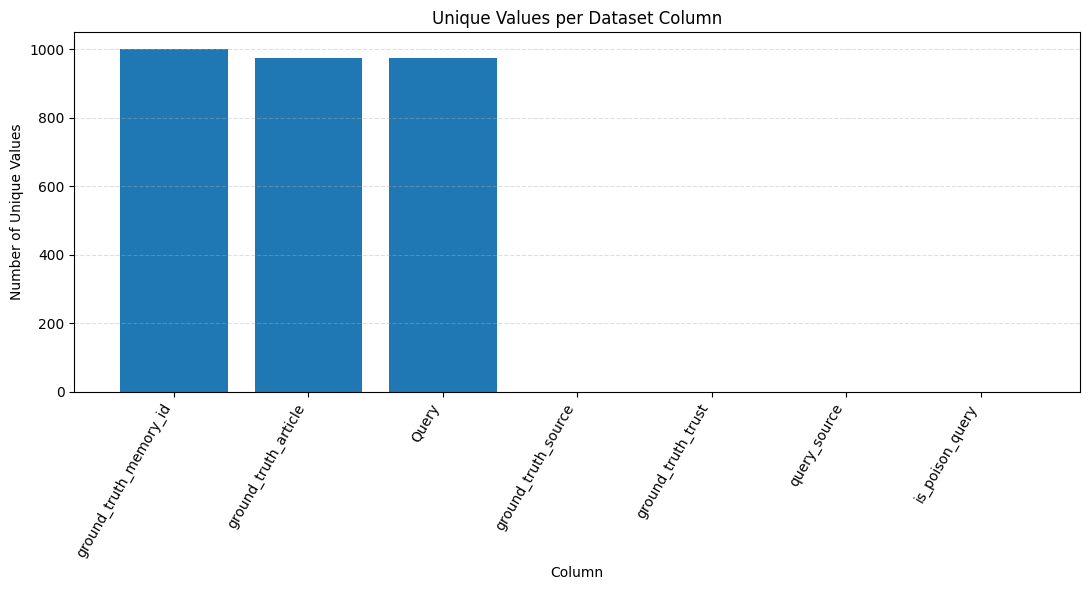


5. QUERY DISTRIBUTION
Unique Queries: 974

Query frequency statistics:
count    974.000000
mean       1.026694
std        0.648586
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       20.000000
Name: count, dtype: float64


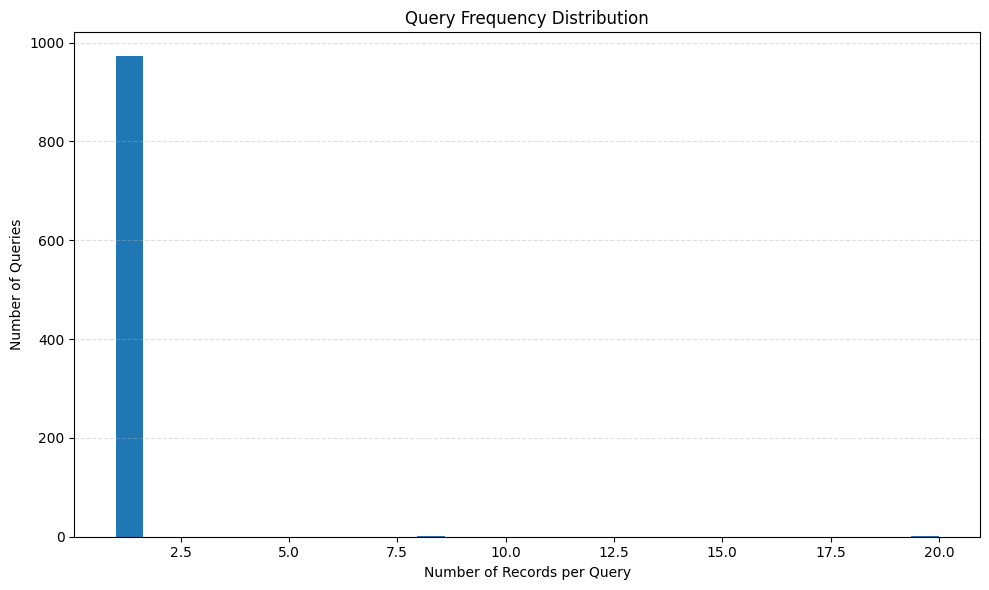


6. GROUND-TRUTH ARTICLE DISTRIBUTION
Unique ground-truth articles: 975


,Count
ground_truth_article,
Other Discussions,19
available here,8
The scientist Gotham deserves,1
not preferred here.,1
Film rights for Toronto Mayor Rob Ford book sold,1
"Bill Clinton, Lady Killer",1
MRW I’m watching a steamy nasty diaper on the last sentence reveals that they are going to take poop,1
A cat who saved his owner's life by keeping her awake when she suffered a blood clot is given a posthumous award,1
"The war on Christmas is here, are you armed and ready?",1


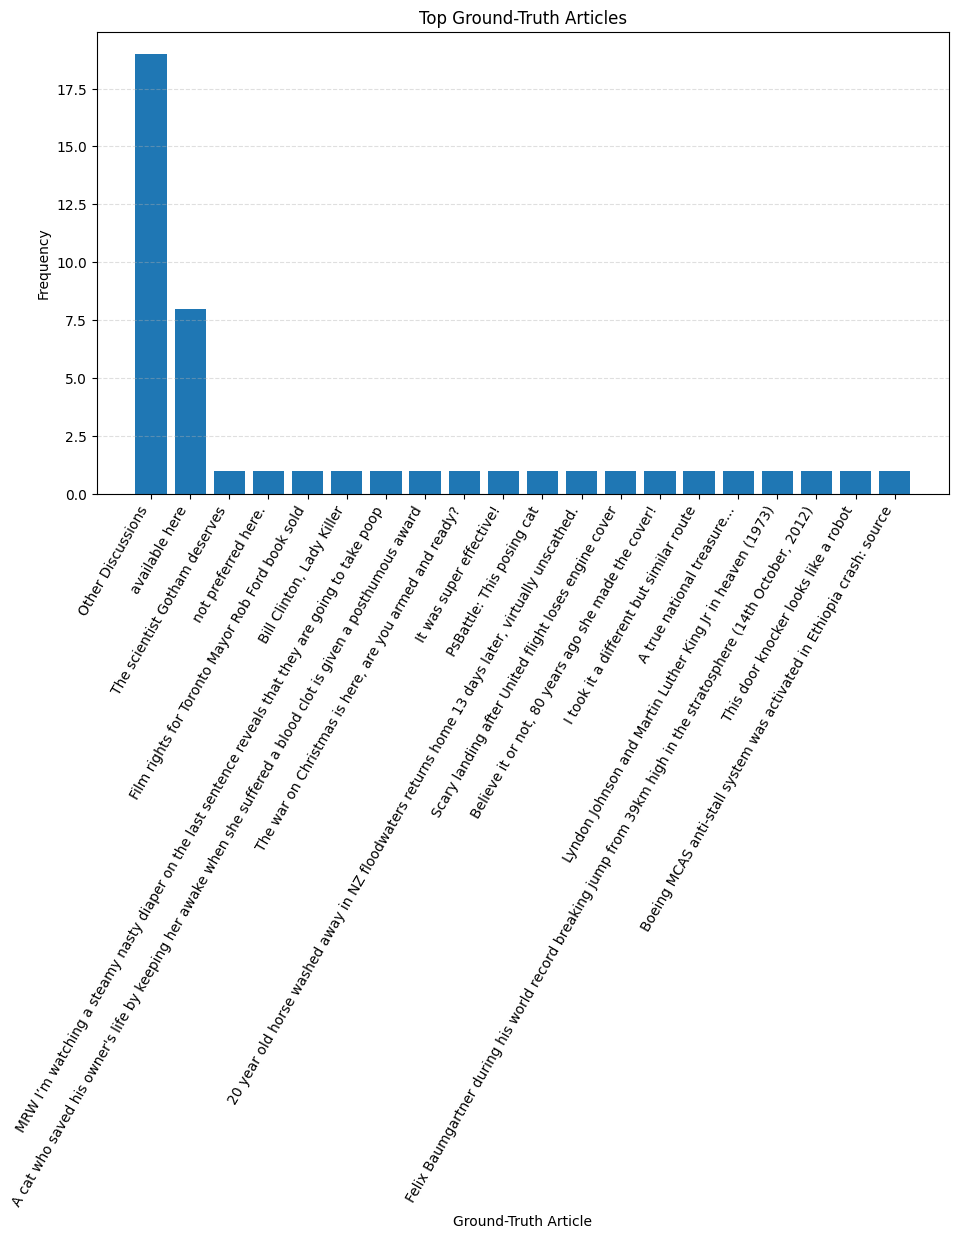


8. NUMERICAL FEATURES
Numerical columns found: 0

10. FINAL DATASET PROFILE


,Property,Value
0,Dataset,New Dataset
1,Rows,1000
2,Columns,7
3,Unique Queries,974
4,Numerical Columns,0
5,Categorical Columns,7
6,Duplicate Rows,0
7,Total Missing Cells,0



DATASET EVALUATION COMPLETE
All graphs and tables saved to:
./smart_phase0


In [102]:
# ============================================================
# DATASET STRUCTURE & DISTRIBUTION EVALUATION
# For the NEW DATASET / CURRENT PIPELINE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DATASET_DF = benchmark_df          # <-- your current NEW dataset
DATASET_NAME = "New Dataset"

# Where graphs/tables will be saved
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = "/kaggle/working/dataset_evaluation"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = DATASET_DF.copy()

print("=" * 80)
print("DATASET STRUCTURE & DISTRIBUTION")
print("=" * 80)

print(f"Dataset name : {DATASET_NAME}")
print(f"Rows         : {len(df):,}")
print(f"Columns      : {len(df.columns):,}")

# ============================================================
# 1. BASIC DATASET STRUCTURE
# ============================================================

print("\n" + "=" * 80)
print("1. DATASET SHAPE")
print("=" * 80)

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# ============================================================
# 2. DATA TYPES
# ============================================================

print("\n" + "=" * 80)
print("2. COLUMN DATA TYPES")
print("=" * 80)

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Missing_%": (
        df.isna().mean().values * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True).values
})

display(dtype_df)

dtype_df.to_csv(
    os.path.join(OUTPUT_DIR, "dataset_column_structure.csv"),
    index=False
)

# ============================================================
# 3. MISSING VALUE DISTRIBUTION
# ============================================================

missing_df = dtype_df[
    dtype_df["Missing"] > 0
].sort_values(
    "Missing_%",
    ascending=False
)

print("\n" + "=" * 80)
print("3. MISSING VALUES")
print("=" * 80)

if len(missing_df) == 0:
    print("No missing values found.")
else:
    display(missing_df)

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        missing_df["Column"],
        missing_df["Missing_%"]
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.ylabel("Missing Values (%)")
    plt.xlabel("Column")
    plt.title("Missing Value Distribution")

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    for bar, value in zip(
        bars,
        missing_df["Missing_%"]
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "dataset_missing_values.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 4. UNIQUE VALUES PER COLUMN
# ============================================================

unique_df = dtype_df.sort_values(
    "Unique_Values",
    ascending=False
)

print("\n" + "=" * 80)
print("4. UNIQUE VALUE DISTRIBUTION")
print("=" * 80)

display(
    unique_df[
        ["Column", "Unique_Values"]
    ]
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    unique_df["Column"],
    unique_df["Unique_Values"]
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel("Number of Unique Values")
plt.xlabel("Column")
plt.title("Unique Values per Dataset Column")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "dataset_unique_values.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 5. QUERY DISTRIBUTION
# ============================================================

if "Query" in df.columns:

    print("\n" + "=" * 80)
    print("5. QUERY DISTRIBUTION")
    print("=" * 80)

    n_queries = df["Query"].nunique()

    print("Unique Queries:", n_queries)

    query_counts = (
        df["Query"]
        .value_counts()
    )

    print(
        "\nQuery frequency statistics:"
    )

    print(
        query_counts.describe()
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        query_counts.values,
        bins=30
    )

    plt.xlabel(
        "Number of Records per Query"
    )

    plt.ylabel(
        "Number of Queries"
    )

    plt.title(
        "Query Frequency Distribution"
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "query_frequency_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 6. GROUND-TRUTH ARTICLE DISTRIBUTION
# ============================================================

if "ground_truth_article" in df.columns:

    print("\n" + "=" * 80)
    print("6. GROUND-TRUTH ARTICLE DISTRIBUTION")
    print("=" * 80)

    gt_counts = (
        df["ground_truth_article"]
        .value_counts()
    )

    print(
        "Unique ground-truth articles:",
        len(gt_counts)
    )

    display(
        gt_counts.head(20)
        .rename("Count")
        .to_frame()
    )

    plt.figure(figsize=(11, 6))

    top_gt = gt_counts.head(20)

    bars = plt.bar(
        top_gt.index.astype(str),
        top_gt.values
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.ylabel("Frequency")
    plt.xlabel("Ground-Truth Article")
    plt.title(
        "Top Ground-Truth Articles"
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "ground_truth_article_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 7. TRUST LABEL DISTRIBUTION
# ============================================================

trust_col = None

for candidate in [
    "trust_label",
    "Trust",
    "trust",
    "is_untrusted"
]:
    if candidate in df.columns:
        trust_col = candidate
        break

if trust_col is not None:

    print("\n" + "=" * 80)
    print("7. TRUST / SECURITY LABEL DISTRIBUTION")
    print("=" * 80)

    trust_counts = (
        df[trust_col]
        .value_counts(dropna=False)
    )

    trust_percent = (
        df[trust_col]
        .value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )

    trust_summary = pd.DataFrame({
        "Count": trust_counts,
        "Percentage": trust_percent.round(2)
    })

    display(trust_summary)

    plt.figure(figsize=(8, 6))

    bars = plt.bar(
        trust_summary.index.astype(str),
        trust_summary["Count"]
    )

    plt.xlabel("Trust Label")
    plt.ylabel("Number of Records")
    plt.title(
        f"Dataset Trust Distribution — {trust_col}"
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    for bar, count in zip(
        bars,
        trust_summary["Count"]
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{int(count):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "trust_label_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 8. NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\n" + "=" * 80)
print("8. NUMERICAL FEATURES")
print("=" * 80)

print(
    f"Numerical columns found: {len(numeric_cols)}"
)

if len(numeric_cols) > 0:

    display(
        df[numeric_cols]
        .describe()
        .T
    )

    # Plot up to 12 numerical features
    plot_cols = numeric_cols[:12]

    for col in plot_cols:

        values = df[col].dropna()

        if len(values) == 0:
            continue

        plt.figure(figsize=(8, 5))

        plt.hist(
            values,
            bins=30
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.title(
            f"Distribution of {col}"
        )

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        plt.tight_layout()

        safe_name = (
            str(col)
            .replace("/", "_")
            .replace(" ", "_")
            .replace(":", "_")
        )

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                f"distribution_{safe_name}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

# ============================================================
# 9. CORRELATION HEATMAP
# ============================================================

if len(numeric_cols) >= 2:

    print("\n" + "=" * 80)
    print("9. NUMERICAL FEATURE CORRELATION")
    print("=" * 80)

    corr = df[numeric_cols].corr()

    plt.figure(
        figsize=(
            max(8, len(numeric_cols) * 0.7),
            max(6, len(numeric_cols) * 0.6)
        )
    )

    plt.imshow(
        corr,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=60,
        ha="right"
    )

    plt.yticks(
        range(len(corr.columns)),
        corr.columns
    )

    plt.title(
        "Numerical Feature Correlation Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "dataset_correlation_matrix.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 10. DATASET STRUCTURE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("10. FINAL DATASET PROFILE")
print("=" * 80)

profile = pd.DataFrame({
    "Property": [
        "Dataset",
        "Rows",
        "Columns",
        "Unique Queries" if "Query" in df.columns else "Unique Queries",
        "Numerical Columns",
        "Categorical Columns",
        "Duplicate Rows",
        "Total Missing Cells",
    ],
    "Value": [
        DATASET_NAME,
        len(df),
        len(df.columns),
        df["Query"].nunique() if "Query" in df.columns else "N/A",
        len(numeric_cols),
        len(df.select_dtypes(
            exclude=np.number
        ).columns),
        df.duplicated().sum(),
        df.isna().sum().sum(),
    ]
})

display(profile)

profile.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dataset_profile_summary.csv"
    ),
    index=False
)

# ============================================================
# 11. SAVE DATASET STRUCTURE REPORT
# ============================================================

with open(
    os.path.join(
        OUTPUT_DIR,
        "dataset_structure_report.txt"
    ),
    "w"
) as f:

    f.write(
        "DATASET STRUCTURE REPORT\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write(
        f"Dataset: {DATASET_NAME}\n"
    )

    f.write(
        f"Rows: {len(df):,}\n"
    )

    f.write(
        f"Columns: {len(df.columns):,}\n\n"
    )

    f.write(
        "COLUMNS\n"
    )
    f.write("-" * 60 + "\n")

    for col in df.columns:

        f.write(
            f"{col} | "
            f"dtype={df[col].dtype} | "
            f"unique={df[col].nunique(dropna=True):,} | "
            f"missing={df[col].isna().sum():,}\n"
        )

print("\n" + "=" * 80)
print("DATASET EVALUATION COMPLETE")
print("=" * 80)

print(
    f"All graphs and tables saved to:\n{OUTPUT_DIR}"
)

In [103]:
# ============================================================
# DATASET STRUCTURAL HIERARCHY
# Shows:
# Dataset
#   ├── Dataset categories
#   ├── FakeEdit / attack types
#   ├── Query
#   ├── Ground truth
#   ├── Trust labels
#   └── Other structural fields
# ============================================================

import pandas as pd
import numpy as np

df = benchmark_df.copy()

print("=" * 80)
print("DATASET STRUCTURAL HIERARCHY")
print("=" * 80)

print(f"\nDataset shape: {df.shape}")

print("\nColumns:")
for col in df.columns:
    print(f"  • {col}")


# ------------------------------------------------------------
# Automatically identify likely structural columns
# ------------------------------------------------------------

possible_category_cols = [
    "dataset",
    "dataset_name",
    "source",
    "category",
    "type",
    "attack_type",
    "edit_type",
    "split",
    "label",
    "trust_label",
    "Trust",
    "is_untrusted",
    "is_poisoned",
    "attack",
]

found_category_cols = [
    c for c in possible_category_cols
    if c in df.columns
]


# ------------------------------------------------------------
# Tree printer
# ------------------------------------------------------------

def print_tree(data, columns, level=0, max_values=10):

    if level >= len(columns):
        return

    col = columns[level]

    print("\n" + "    " * level + f"├── {col}")

    values = data[col].dropna().astype(str)

    counts = values.value_counts()

    for i, (value, count) in enumerate(
        counts.head(max_values).items()
    ):

        prefix = "    " * (level + 1)

        print(
            f"{prefix}├── {value} "
            f"(n={count})"
        )

        subset = data[
            data[col].astype(str) == value
        ]

        if level + 1 < len(columns):

            next_col = columns[level + 1]

            if next_col in subset.columns:

                next_values = (
                    subset[next_col]
                    .dropna()
                    .astype(str)
                    .nunique()
                )

                if next_values > 0:
                    print_tree(
                        subset,
                        columns,
                        level + 1,
                        max_values=max_values
                    )


# ------------------------------------------------------------
# Print actual structural fields
# ------------------------------------------------------------

if found_category_cols:

    print("\n" + "=" * 80)
    print("DETECTED DATASET HIERARCHY")
    print("=" * 80)

    print("Dataset")

    print_tree(
        df,
        found_category_cols,
        level=1,
        max_values=10
    )

else:

    print("\nNo obvious hierarchy columns detected.")

    print("\nYour dataset currently contains:")

    for col in df.columns:
        print(
            f"├── {col} "
            f"[{df[col].dtype}] "
            f"unique={df[col].nunique(dropna=True)}"
        )

DATASET STRUCTURAL HIERARCHY

Dataset shape: (1000, 7)

Columns:
  • Query
  • ground_truth_memory_id
  • ground_truth_article
  • ground_truth_source
  • ground_truth_trust
  • query_source
  • is_poison_query

No obvious hierarchy columns detected.

Your dataset currently contains:
├── Query [object] unique=974
├── ground_truth_memory_id [object] unique=1000
├── ground_truth_article [object] unique=975
├── ground_truth_source [object] unique=1
├── ground_truth_trust [object] unique=1
├── query_source [object] unique=1
├── is_poison_query [bool] unique=1


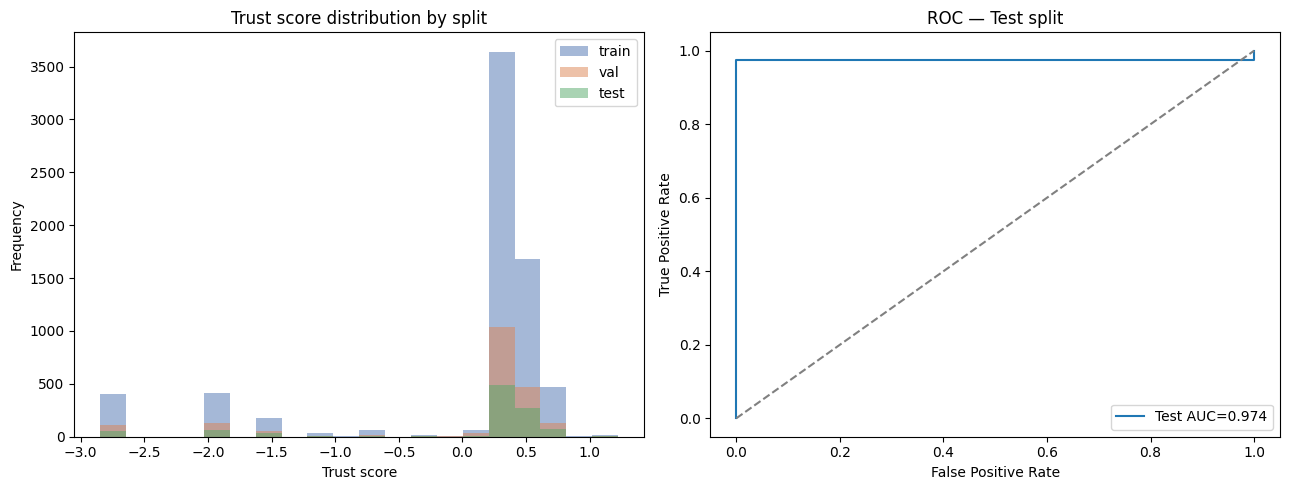

In [104]:
# ---- plots ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for split_name, color in zip(["train", "val", "test"], ["#4C72B0", "#DD8452", "#55A868"]):
    sub = trust_df[trust_df["split"] == split_name]
    axes[0].hist(sub["trust_score_raw"], bins=20, alpha=0.5, label=split_name, color=color)
axes[0].set_xlabel("Trust score"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Trust score distribution by split"); axes[0].legend()

test_idx = trust_df["split"] == "test"
y_true_t = trust_df.loc[test_idx, "is_untrusted"].values
scores_t = trust_df.loc[test_idx, "trust_score_raw"].values
y_prob_t = 1 - (scores_t - scores_t.min()) / (scores_t.max() - scores_t.min() + 1e-9)
fpr_t, tpr_t, _ = roc_curve(y_true_t, y_prob_t)
axes[1].plot(fpr_t, tpr_t, label=f"Test AUC={roc_auc_score(y_true_t, y_prob_t):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC — Test split"); axes[1].legend()

plt.tight_layout(); plt.show()

## Save artifacts (for reuse / zero-day inference)

In [105]:
# ============================================================
# SAVE ARTIFACTS — PHASE 3A → 3B → 4A → 4B
# For reuse / zero-day inference
# ============================================================

import os
import json
import pickle
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# ============================================================
# 1. GOOGLE DRIVE SETUP
# ============================================================

DRIVE_ROOT = "/content/drive/MyDrive"

ARTIFACT_DIR = os.path.join(
    DRIVE_ROOT,
    "SMART_DEFENSE_ARTIFACTS"
)

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print("=" * 80)
print("SMART DEFENSE — ARTIFACT CHECKPOINT")
print("=" * 80)

print(f"\nArtifact directory:\n{ARTIFACT_DIR}")

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def save_pickle(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"✓ Saved: {filename}")
    return path


def save_joblib(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)
    joblib.dump(obj, path)
    print(f"✓ Saved: {filename}")
    return path


def save_csv(df, filename):
    path = os.path.join(ARTIFACT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"✓ Saved: {filename} ({len(df):,} rows)")
    return path


def save_json(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)

    def convert(x):

        if isinstance(x, (np.integer,)):
            return int(x)

        if isinstance(x, (np.floating,)):
            return float(x)

        if isinstance(x, np.ndarray):
            return x.tolist()

        if isinstance(x, pd.Timestamp):
            return x.isoformat()

        return str(x)

    with open(path, "w") as f:
        json.dump(
            obj,
            f,
            indent=2,
            default=convert
        )

    print(f"✓ Saved: {filename}")
    return path


# ============================================================
# 3. CHECK WHICH PIPELINE OBJECTS EXIST
# ============================================================

candidate_objects = [
    "retrieval_df",
    "trust_df",
    "ranking_pool",
    "phase4_df",
    "selected_df",
    "naive_baseline_df",
    "comparison_table_4b",
    "results_df"
]

print("\nAvailable pipeline objects:")

available_objects = {}

for name in candidate_objects:

    exists = (
        name in globals()
        and globals()[name] is not None
    )

    available_objects[name] = exists

    print(
        f"{'✓' if exists else '✗'} {name}"
    )


# ============================================================
# 4. SAVE MAIN DATA ARTIFACTS
# ============================================================

print("\n" + "-" * 80)
print("DATA ARTIFACTS")
print("-" * 80)

if "retrieval_df" in globals():

    save_pickle(
        retrieval_df,
        "01_retrieval_df.pkl"
    )

    save_csv(
        retrieval_df,
        "01_retrieval_df.csv"
    )


if "trust_df" in globals():

    save_pickle(
        trust_df,
        "02_trust_df.pkl"
    )

    save_csv(
        trust_df,
        "02_trust_df.csv"
    )


if "ranking_pool" in globals():

    save_pickle(
        ranking_pool,
        "03_ranking_pool.pkl"
    )

    save_csv(
        ranking_pool,
        "03_ranking_pool.csv"
    )


if "phase4_df" in globals():

    save_pickle(
        phase4_df,
        "04_phase4_candidates.pkl"
    )


if "selected_df" in globals():

    save_pickle(
        selected_df,
        "05_selected_df.pkl"
    )

    save_csv(
        selected_df,
        "05_selected_df.csv"
    )


if "naive_baseline_df" in globals():

    save_pickle(
        naive_baseline_df,
        "06_naive_baseline_df.pkl"
    )

    save_csv(
        naive_baseline_df,
        "06_naive_baseline_df.csv"
    )


if "comparison_table_4b" in globals():

    save_pickle(
        comparison_table_4b,
        "07_comparison_table_4b.pkl"
    )

    save_csv(
        comparison_table_4b,
        "07_comparison_table_4b.csv"
    )


if "results_df" in globals():

    save_pickle(
        results_df,
        "08_phase3a_results.pkl"
    )

    save_csv(
        results_df,
        "08_phase3a_results.csv"
    )


# ============================================================
# 5. SAVE PHASE 3A MODEL
# ============================================================

print("\n" + "-" * 80)
print("PHASE 3A MODEL ARTIFACTS")
print("-" * 80)

if "xgb_clf" in globals():

    save_joblib(
        xgb_clf,
        "09_phase3a_xgb_classifier.joblib"
    )

else:

    print("⚠ xgb_clf not available")


if "xgb_clf_calibrated" in globals():

    save_joblib(
        xgb_clf_calibrated,
        "10_phase3a_calibrated_classifier.joblib"
    )

else:

    print("⚠ xgb_clf_calibrated not available")


# ============================================================
# 6. SAVE PHASE 3A FEATURE CONFIGURATION
# ============================================================

print("\n" + "-" * 80)
print("PHASE 3A CONFIGURATION")
print("-" * 80)

phase3a_config = {}

for variable_name in [
    "DIMS",
    "ZDIMS",
    "EXTRA_FEATS",
    "ZDIMS_FULL",
    "FAR_WEIGHT",
    "threshold",
    "BLEND",
    "RANDOM_SEED"
]:

    if variable_name in globals():

        value = globals()[variable_name]

        if isinstance(value, np.ndarray):
            value = value.tolist()

        elif isinstance(value, tuple):
            value = list(value)

        phase3a_config[
            variable_name
        ] = value


# Explicitly record the Phase 3A decision rule
phase3a_config["decision_rule"] = (
    "prediction = 1 if trust_score_raw < threshold, "
    "otherwise prediction = 0"
)

phase3a_config["prediction_encoding"] = {
    "0": "trusted",
    "1": "untrusted"
}

phase3a_config["score_direction"] = (
    "lower trust_score_raw = more untrusted"
)

save_json(
    phase3a_config,
    "11_phase3a_config.json"
)


# ============================================================
# 7. SAVE PHASE 3A FEATURE IMPORTANCE
# ============================================================

if "importance_dict" in globals():

    save_json(
        importance_dict,
        "12_phase3a_feature_importance.json"
    )

elif "importances" in globals():

    save_json(
        importances,
        "12_phase3a_feature_importance.json"
    )

elif "xgb_clf" in globals() and "ZDIMS_FULL" in globals():

    feature_importance = dict(
        zip(
            ZDIMS_FULL,
            xgb_clf.feature_importances_
        )
    )

    save_json(
        feature_importance,
        "12_phase3a_feature_importance.json"
    )

    print(
        "✓ Feature importance reconstructed from xgb_clf"
    )

else:

    print(
        "⚠ Phase 3A feature importance unavailable"
    )


# ============================================================
# 8. SAVE PHASE 3B RANKER
# ============================================================

print("\n" + "-" * 80)
print("PHASE 3B MODEL ARTIFACTS")
print("-" * 80)

ranker_candidates = [
    "ranker",
    "lgbm_ranker",
    "xgb_ranker",
    "model_ranker"
]

ranker_saved = False

for ranker_name in ranker_candidates:

    if ranker_name in globals():

        try:

            save_joblib(
                globals()[ranker_name],
                "13_phase3b_ranker.joblib"
            )

            print(
                f"✓ Phase 3B ranker source: {ranker_name}"
            )

            ranker_saved = True
            break

        except Exception as e:

            print(
                f"⚠ Could not save {ranker_name}: {e}"
            )


if not ranker_saved:

    print(
        "⚠ No recognized Phase 3B ranker object found."
    )


# ============================================================
# 9. SAVE PHASE 3B FEATURE CONFIGURATION
# ============================================================

phase3b_config = {}

for variable_name in [
    "RANKING_FEATURES",
    "FINAL_RANKING_FEATURES",
    "RANK_FEATURES",
    "TOP_K"
]:

    if variable_name in globals():

        value = globals()[variable_name]

        if isinstance(value, np.ndarray):
            value = value.tolist()

        elif isinstance(value, tuple):
            value = list(value)

        phase3b_config[
            variable_name
        ] = value


# Discover ranking feature columns if explicit variable
# does not exist.

if (
    "FINAL_RANKING_FEATURES" not in phase3b_config
    and "ranking_pool" in globals()
):

    detected = [
        c for c in ranking_pool.columns
        if c.endswith("_qnorm")
    ]

    phase3b_config[
        "detected_qnorm_features"
    ] = detected


save_json(
    phase3b_config,
    "14_phase3b_config.json"
)


# ============================================================
# 10. SAVE PHASE 4 CONFIGURATION
# ============================================================

print("\n" + "-" * 80)
print("PHASE 4 CONFIGURATION")
print("-" * 80)

phase4_config = {}

for variable_name in [
    "TOP_K",
    "PENALTY_WEIGHT_TOTAL",
    "PENALTY_FAR_WEIGHT",
    "SELECTION_FEATURES",
    "PENALTY_FEATURES",
    "adaptive_weights",
    "FAR_WEIGHT"
]:

    if variable_name in globals():

        value = globals()[variable_name]

        if isinstance(value, np.ndarray):
            value = value.tolist()

        elif isinstance(value, tuple):
            value = list(value)

        phase4_config[
            variable_name
        ] = value


# Explicit pipeline description
phase4_config["pipeline"] = (
    "Phase 3A trust filtering -> "
    "Phase 3B trust-aware ranking -> "
    "Phase 4A selection"
)

phase4_config["poison_label"] = (
    "is_untrusted"
)

phase4_config["selection_output"] = (
    "selected_df"
)

save_json(
    phase4_config,
    "15_phase4_config.json"
)


# ============================================================
# 11. SAVE 4B METRICS
# ============================================================

print("\n" + "-" * 80)
print("PHASE 4B METRICS")
print("-" * 80)

metrics_to_save = {}

for name in [
    "post_metrics",
    "pre_metrics",
    "naive_metrics",
    "comparison_table_4b"
]:

    if name in globals():

        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            metrics_to_save[name] = (
                obj.to_dict(orient="records")
            )

        elif isinstance(obj, pd.Series):
            metrics_to_save[name] = (
                obj.to_dict()
            )

        elif isinstance(obj, dict):
            metrics_to_save[name] = obj


if metrics_to_save:

    save_json(
        metrics_to_save,
        "16_phase4b_metrics.json"
    )


# ============================================================
# 12. SAVE DATASET SCHEMA
# ============================================================

print("\n" + "-" * 80)
print("DATASET SCHEMA")
print("-" * 80)

schema = {}

if "retrieval_df" in globals():

    schema["retrieval_df"] = {
        "rows": int(len(retrieval_df)),
        "columns": list(retrieval_df.columns),
        "dtypes": {
            c: str(retrieval_df[c].dtype)
            for c in retrieval_df.columns
        }
    }


if "trust_df" in globals():

    schema["trust_df"] = {
        "rows": int(len(trust_df)),
        "columns": list(trust_df.columns),
        "dtypes": {
            c: str(trust_df[c].dtype)
            for c in trust_df.columns
        }
    }


if "ranking_pool" in globals():

    schema["ranking_pool"] = {
        "rows": int(len(ranking_pool)),
        "columns": list(ranking_pool.columns),
        "dtypes": {
            c: str(ranking_pool[c].dtype)
            for c in ranking_pool.columns
        }
    }


if "selected_df" in globals():

    schema["selected_df"] = {
        "rows": int(len(selected_df)),
        "columns": list(selected_df.columns),
        "dtypes": {
            c: str(selected_df[c].dtype)
            for c in selected_df.columns
        }
    }


save_json(
    schema,
    "17_dataset_schema.json"
)


# ============================================================
# 13. CREATE MASTER MANIFEST
# ============================================================

manifest = {

    "artifact_version": "SMART_DEFENSE_v1",

    "created_at": datetime.now().isoformat(),

    "pipeline": [
        "Phase 3A — Trust Classification",
        "Phase 3B — Trust-Aware Learning-to-Rank",
        "Phase 4A — Trust-Aware Selection",
        "Phase 4B — Security Evaluation"
    ],

    "objects_available": available_objects,

    "files": [
        f
        for f in sorted(
            os.listdir(ARTIFACT_DIR)
        )
    ]
}

# Add important numerical information

if "retrieval_df" in globals():

    manifest["retrieval_rows"] = int(
        len(retrieval_df)
    )

    if "Query" in retrieval_df.columns:

        manifest["queries"] = int(
            retrieval_df["Query"].nunique()
        )

if "trust_df" in globals():

    if "prediction" in trust_df.columns:

        manifest[
            "phase3a_prediction_distribution"
        ] = (
            trust_df["prediction"]
            .value_counts()
            .to_dict()
        )

    if "is_untrusted" in trust_df.columns:

        manifest[
            "ground_truth_untrusted_distribution"
        ] = (
            trust_df["is_untrusted"]
            .value_counts()
            .to_dict()
        )

if "selected_df" in globals():

    manifest[
        "selected_rows"
    ] = int(
        len(selected_df)
    )


save_json(
    manifest,
    "00_MASTER_MANIFEST.json"
)


# ============================================================
# 14. FINAL FILE LIST
# ============================================================

print("\n")
print("=" * 80)
print("ARTIFACT SAVE COMPLETE")
print("=" * 80)

saved_files = sorted(
    os.listdir(ARTIFACT_DIR)
)

for filename in saved_files:

    filepath = os.path.join(
        ARTIFACT_DIR,
        filename
    )

    size_mb = (
        os.path.getsize(filepath)
        /
        (1024 ** 2)
    )

    print(
        f"✓ {filename:<45} "
        f"{size_mb:8.2f} MB"
    )

print("\n")
print("Artifacts saved to:")
print(ARTIFACT_DIR)

print("\n✓ CHECKPOINT COMPLETE")

SMART DEFENSE — ARTIFACT CHECKPOINT

Artifact directory:
/content/drive/MyDrive/SMART_DEFENSE_ARTIFACTS

Available pipeline objects:
✓ retrieval_df
✓ trust_df
✓ ranking_pool
✗ phase4_df
✓ selected_df
✓ naive_baseline_df
✓ comparison_table_4b
✓ results_df

--------------------------------------------------------------------------------
DATA ARTIFACTS
--------------------------------------------------------------------------------
✓ Saved: 01_retrieval_df.pkl
✓ Saved: 01_retrieval_df.csv (10,000 rows)
✓ Saved: 02_trust_df.pkl
✓ Saved: 02_trust_df.csv (10,000 rows)
✓ Saved: 03_ranking_pool.pkl
✓ Saved: 03_ranking_pool.csv (8,470 rows)
✓ Saved: 05_selected_df.pkl
✓ Saved: 05_selected_df.csv (4,853 rows)
✓ Saved: 06_naive_baseline_df.pkl
✓ Saved: 06_naive_baseline_df.csv (4,870 rows)
✓ Saved: 07_comparison_table_4b.pkl
✓ Saved: 07_comparison_table_4b.csv (13 rows)
✓ Saved: 08_phase3a_results.pkl
✓ Saved: 08_phase3a_results.csv (3 rows)

------------------------------------------------------

In [106]:
# ============================================================
# HYBRID RETRIEVAL — COMPLETE RETRIEVAL EVALUATION
# ============================================================
#
# Evaluates ONLY the retrieval stage of the NEW DATASET.
#
# Does NOT evaluate:
#   - SMART trust filtering
#   - Phase 4 selection
#   - FAR / FRR
#   - poisoning defense
#
# Main question:
#   "How well does my hybrid retriever retrieve the correct
#    ground-truth article for each query?"
#
# Requires:
#   benchmark_df
#   hybrid_retrieval_df
#
# benchmark_df:
#   Query
#   ground_truth_article
#
# hybrid_retrieval_df:
#   Query
#   Article
#   optional: similarity_score
#   optional: final_rank_score
#   optional: Trust
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ndcg_score


# ============================================================
# 1. CONFIGURATION
# ============================================================

# CHANGE THIS ONLY IF YOUR HYBRID RETRIEVAL DATAFRAME HAS
# A DIFFERENT NAME.
#
# Example:
# hybrid_retrieval_df = retrieval_df
#
# If your hybrid retrieval dataframe is already called
# retrieval_df, this will automatically use it.
# ============================================================

if "hybrid_retrieval_df" in globals():
    RETRIEVAL_EVAL_DF = hybrid_retrieval_df.copy()

elif "retrieval_df" in globals():
    RETRIEVAL_EVAL_DF = retrieval_df.copy()

elif "baseline_similarity_only" in globals():
    raise RuntimeError(
        "Only baseline_similarity_only was found. "
        "Please assign your NEW HYBRID retrieval dataframe to "
        "`hybrid_retrieval_df` before running this module."
    )

else:
    raise RuntimeError(
        "No retrieval dataframe found.\n"
        "Create your hybrid retrieval dataframe first and name it:\n"
        "    hybrid_retrieval_df\n"
        "or:\n"
        "    retrieval_df"
    )


# ============================================================
# 2. OUTPUT DIRECTORY
# ============================================================

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "./retrieval_evaluation"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_benchmark_cols = [
    "Query",
    "ground_truth_article"
]

required_retrieval_cols = [
    "Query",
    "Article"
]

missing_benchmark = [
    c for c in required_benchmark_cols
    if c not in benchmark_df.columns
]

missing_retrieval = [
    c for c in required_retrieval_cols
    if c not in RETRIEVAL_EVAL_DF.columns
]

if missing_benchmark:
    raise ValueError(
        f"benchmark_df is missing columns: {missing_benchmark}"
    )

if missing_retrieval:
    raise ValueError(
        f"Retrieval dataframe is missing columns: {missing_retrieval}"
    )


# ============================================================
# 4. BASIC INFORMATION
# ============================================================

print("=" * 80)
print("HYBRID RETRIEVAL — RESULTS EVALUATION")
print("=" * 80)

print("\nBenchmark shape :", benchmark_df.shape)
print("Retrieval shape :", RETRIEVAL_EVAL_DF.shape)

print("\nBenchmark columns:")
print(list(benchmark_df.columns))

print("\nRetrieval columns:")
print(list(RETRIEVAL_EVAL_DF.columns))


# ============================================================
# 5. CLEAN DATA
# ============================================================

bench = benchmark_df[
    ["Query", "ground_truth_article"]
].copy()

retrieval = RETRIEVAL_EVAL_DF.copy()

bench["Query"] = bench["Query"].astype(str).str.strip()
bench["ground_truth_article"] = (
    bench["ground_truth_article"]
    .astype(str)
    .str.strip()
)

retrieval["Query"] = (
    retrieval["Query"]
    .astype(str)
    .str.strip()
)

retrieval["Article"] = (
    retrieval["Article"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. REMOVE DUPLICATE RETRIEVED ARTICLES
# ============================================================
#
# Keep the first occurrence of each article per query.
#
# This prevents duplicate rows from artificially improving
# retrieval metrics.
# ============================================================

retrieval = (
    retrieval
    .sort_values(
        ["Query"],
        kind="stable"
    )
    .drop_duplicates(
        subset=["Query", "Article"],
        keep="first"
    )
    .copy()
)


# ============================================================
# 7. CREATE RETRIEVAL RANK
# ============================================================
#
# If Rank already exists, use it.
#
# Otherwise:
#
# 1. final_rank_score if available
# 2. similarity_score if available
# 3. existing row order
#
# Higher score = better rank.
# ============================================================

if "Rank" in retrieval.columns:

    retrieval["Eval_Rank"] = pd.to_numeric(
        retrieval["Rank"],
        errors="coerce"
    )

elif "final_rank_score" in retrieval.columns:

    retrieval["final_rank_score"] = pd.to_numeric(
        retrieval["final_rank_score"],
        errors="coerce"
    )

    retrieval = retrieval.sort_values(
        ["Query", "final_rank_score"],
        ascending=[True, False]
    ).copy()

    retrieval["Eval_Rank"] = (
        retrieval
        .groupby("Query")
        .cumcount() + 1
    )

elif "similarity_score" in retrieval.columns:

    retrieval["similarity_score"] = pd.to_numeric(
        retrieval["similarity_score"],
        errors="coerce"
    )

    retrieval = retrieval.sort_values(
        ["Query", "similarity_score"],
        ascending=[True, False]
    ).copy()

    retrieval["Eval_Rank"] = (
        retrieval
        .groupby("Query")
        .cumcount() + 1
    )

else:

    retrieval["Eval_Rank"] = (
        retrieval
        .groupby("Query")
        .cumcount() + 1
    )


retrieval["Eval_Rank"] = retrieval["Eval_Rank"].astype(int)


# ============================================================
# 8. FIND GROUND-TRUTH RANK FOR EVERY QUERY
# ============================================================

evaluation_rows = []

for _, gt_row in bench.iterrows():

    query = gt_row["Query"]
    ground_truth = gt_row["ground_truth_article"]

    q_results = retrieval[
        retrieval["Query"] == query
    ].sort_values("Eval_Rank")

    matching = q_results[
        q_results["Article"] == ground_truth
    ]

    if len(matching) > 0:

        gt_rank = int(
            matching.iloc[0]["Eval_Rank"]
        )

        retrieved = 1

    else:

        gt_rank = np.nan
        retrieved = 0

    evaluation_rows.append({
        "Query": query,
        "ground_truth_article": ground_truth,
        "GroundTruth_Rank": gt_rank,
        "Retrieved": retrieved
    })


retrieval_eval_df = pd.DataFrame(
    evaluation_rows
)


# ============================================================
# 9. BASIC RETRIEVAL STATISTICS
# ============================================================

total_queries = len(retrieval_eval_df)

retrieved_gt = retrieval_eval_df[
    retrieval_eval_df["Retrieved"] == 1
]

not_retrieved_gt = retrieval_eval_df[
    retrieval_eval_df["Retrieved"] == 0
]

coverage = (
    len(retrieved_gt) / total_queries
    if total_queries > 0
    else np.nan
)

print("\n" + "=" * 80)
print("GROUND-TRUTH RETRIEVAL COVERAGE")
print("=" * 80)

print(f"Total Queries              : {total_queries}")
print(f"Ground Truth Retrieved     : {len(retrieved_gt)}")
print(f"Ground Truth Not Retrieved : {len(not_retrieved_gt)}")
print(f"Retrieval Coverage         : {coverage:.4f}")


# ============================================================
# 10. RECALL@K / HIT RATE@K
# ============================================================

def recall_at_k(rank_series, k):

    if len(rank_series) == 0:
        return np.nan

    return (
        (rank_series.notna() & (rank_series <= k))
        .sum()
        / len(rank_series)
    )


recall_1 = recall_at_k(
    retrieval_eval_df["GroundTruth_Rank"],
    1
)

recall_5 = recall_at_k(
    retrieval_eval_df["GroundTruth_Rank"],
    5
)

recall_10 = recall_at_k(
    retrieval_eval_df["GroundTruth_Rank"],
    10
)

recall_20 = recall_at_k(
    retrieval_eval_df["GroundTruth_Rank"],
    20
)


# ============================================================
# 11. MRR
# ============================================================

reciprocal_ranks = retrieval_eval_df[
    "GroundTruth_Rank"
].apply(
    lambda r: 1.0 / r
    if pd.notna(r)
    else 0.0
)

MRR = reciprocal_ranks.mean()


# ============================================================
# 12. RANK STATISTICS
# ============================================================

if len(retrieved_gt) > 0:

    mean_rank = (
        retrieved_gt["GroundTruth_Rank"]
        .mean()
    )

    median_rank = (
        retrieved_gt["GroundTruth_Rank"]
        .median()
    )

    min_rank = (
        retrieved_gt["GroundTruth_Rank"]
        .min()
    )

    max_rank = (
        retrieved_gt["GroundTruth_Rank"]
        .max()
    )

else:

    mean_rank = np.nan
    median_rank = np.nan
    min_rank = np.nan
    max_rank = np.nan


# ============================================================
# 13. PRINT MAIN RETRIEVAL METRICS
# ============================================================

print("\n" + "=" * 80)
print("HYBRID RETRIEVAL QUALITY")
print("=" * 80)

print(f"Recall@1       : {recall_1:.4f}")
print(f"Recall@5       : {recall_5:.4f}")
print(f"Recall@10      : {recall_10:.4f}")
print(f"Recall@20      : {recall_20:.4f}")
print(f"MRR            : {MRR:.4f}")
print(f"Mean GT Rank   : {mean_rank:.4f}")
print(f"Median GT Rank : {median_rank:.4f}")
print(f"Best GT Rank   : {min_rank}")
print(f"Worst GT Rank  : {max_rank}")


# ============================================================
# 14. NDCG@K
# ============================================================
#
# Since there is one relevant ground-truth article per query:
#
# DCG@K = 1 / log2(rank + 1)
#
# if the ground truth is within K.
#
# Otherwise 0.
# ============================================================

def ndcg_at_k(rank, k):

    if pd.isna(rank):
        return 0.0

    rank = int(rank)

    if rank > k:
        return 0.0

    return 1.0 / np.log2(rank + 1)


ndcg_1 = retrieval_eval_df[
    "GroundTruth_Rank"
].apply(
    lambda r: ndcg_at_k(r, 1)
).mean()

ndcg_5 = retrieval_eval_df[
    "GroundTruth_Rank"
].apply(
    lambda r: ndcg_at_k(r, 5)
).mean()

ndcg_10 = retrieval_eval_df[
    "GroundTruth_Rank"
].apply(
    lambda r: ndcg_at_k(r, 10)
).mean()


print(f"NDCG@1         : {ndcg_1:.4f}")
print(f"NDCG@5         : {ndcg_5:.4f}")
print(f"NDCG@10        : {ndcg_10:.4f}")


# ============================================================
# 15. FINAL RETRIEVAL METRICS TABLE
# ============================================================

retrieval_metrics = pd.DataFrame({

    "Metric": [

        "Total Queries",
        "Ground Truth Retrieved",
        "Ground Truth Not Retrieved",
        "Retrieval Coverage",

        "Recall@1",
        "Recall@5",
        "Recall@10",
        "Recall@20",

        "MRR",

        "NDCG@1",
        "NDCG@5",
        "NDCG@10",

        "Mean Ground Truth Rank",
        "Median Ground Truth Rank",
        "Best Ground Truth Rank",
        "Worst Ground Truth Rank",
    ],

    "Value": [

        total_queries,
        len(retrieved_gt),
        len(not_retrieved_gt),
        coverage,

        recall_1,
        recall_5,
        recall_10,
        recall_20,

        MRR,

        ndcg_1,
        ndcg_5,
        ndcg_10,

        mean_rank,
        median_rank,
        min_rank,
        max_rank,
    ]
})


print("\n" + "=" * 80)
print("FINAL RETRIEVAL METRICS")
print("=" * 80)

display(
    retrieval_metrics.round(4)
)


# ============================================================
# 16. SAVE RETRIEVAL METRICS
# ============================================================

retrieval_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_metrics.csv"
    ),
    index=False
)

retrieval_eval_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_per_query.csv"
    ),
    index=False
)


# ============================================================
# 17. SAVE RETRIEVAL RESULTS WITH RANKS
# ============================================================

retrieval.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_ranked_results.csv"
    ),
    index=False
)


print("\nSaved:")
print(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_metrics.csv"
    )
)

print(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_per_query.csv"
    )
)

print(
    os.path.join(
        OUTPUT_DIR,
        "hybrid_retrieval_ranked_results.csv"
    )
)

HYBRID RETRIEVAL — RESULTS EVALUATION

Benchmark shape : (1000, 7)
Retrieval shape : (10000, 61)

Benchmark columns:
['Query', 'ground_truth_memory_id', 'ground_truth_article', 'ground_truth_source', 'ground_truth_trust', 'query_source', 'is_poison_query']

Retrieval columns:
['Query', 'ground_truth_article', 'ground_truth_memory_id', 'Rank', 'semantic_relevance', 'rrf_score', 'memory_id', 'Article', 'text_chunk', 'Caption', 'image_description', 'image_title', 'Source', 'Domain', 'Trust', 'is_untrusted', 'is_poison', 'is_synthetic', 'fakeddit_2way_label', 'fakeddit_3way_label', 'fakeddit_6way_label', 'split', 'img_url', 'has_image', 'img_url_present', 'image_text_consistency', 'semantic_support_score', 'semantic_support_norm', 'entailment_score', 'corroboration_count', 'corroboration_norm', 'provenance_reliability', 'uncertainty_sim_a', 'uncertainty_sim_b', 'uncertainty_sim_c', 'uncertainty_raw', 'uncertainty', 'confidence', 'semantic_relevance_z', 'image_text_consistency_z', 'provenan

,Metric,Value
0,Total Queries,1000.0000
1,Ground Truth Retrieved,991.0000
2,Ground Truth Not Retrieved,9.0000
3,Retrieval Coverage,0.9910
4,Recall@1,0.1130
5,Recall@5,0.9910
6,Recall@10,0.9910
7,Recall@20,0.9910
8,MRR,0.5518
9,NDCG@1,0.1130



Saved:
./smart_phase0/hybrid_retrieval_metrics.csv
./smart_phase0/hybrid_retrieval_per_query.csv
./smart_phase0/hybrid_retrieval_ranked_results.csv


In [107]:
# ============================================================
# SAVE ARTIFACTS — KAGGLE VERSION
# For reuse / zero-day inference
# ============================================================

import os
import json
import pickle
import joblib
import shutil
import pandas as pd
import numpy as np

# ============================================================
# 1. Kaggle artifact directory
# ============================================================

ARTIFACT_DIR = "/kaggle/working/smart_defense_artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("=" * 80)
print("SAVING SMART DEFENSE ARTIFACTS")
print("=" * 80)
print(f"Artifact directory: {ARTIFACT_DIR}")


# ============================================================
# 2. Helper functions
# ============================================================

def save_pickle(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"✓ Saved: {filename}")
    return path


def save_joblib(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)
    joblib.dump(obj, path)
    print(f"✓ Saved: {filename}")
    return path


def save_csv(df, filename):
    if df is None:
        return None

    path = os.path.join(ARTIFACT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"✓ Saved: {filename} ({len(df):,} rows)")
    return path


def save_json(obj, filename):
    path = os.path.join(ARTIFACT_DIR, filename)

    def convert(x):
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, pd.Series):
            return x.to_dict()
        if isinstance(x, pd.DataFrame):
            return x.to_dict(orient="records")
        return str(x)

    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=convert)

    print(f"✓ Saved: {filename}")
    return path


# ============================================================
# 3. Save Phase 3A objects
# ============================================================

print("\n[3A] Saving trust-classification artifacts...")

# Main Phase 3A dataframe
if "trust_df" in globals():
    save_csv(
        trust_df,
        "phase3A_trust_df.csv"
    )

# XGBoost classifier
if "xgb_clf" in globals():
    save_joblib(
        xgb_clf,
        "phase3A_xgb_classifier.joblib"
    )

# Calibrated classifier
if "xgb_clf_calibrated" in globals():
    save_joblib(
        xgb_clf_calibrated,
        "phase3A_calibrated_classifier.joblib"
    )

# Threshold
if "threshold" in globals():
    save_json(
        {
            "trust_score_threshold": float(threshold),
            "decision_rule": "trust_score_raw < threshold => predicted untrusted"
        },
        "phase3A_threshold.json"
    )

# Feature definitions
phase3a_features = {}

for name in [
    "DIMS",
    "ZDIMS",
    "EXTRA_FEATS",
    "ZDIMS_FULL"
]:
    if name in globals():
        phase3a_features[name] = globals()[name]

save_json(
    phase3a_features,
    "phase3A_feature_config.json"
)

# Feature importance
if "importance_dict" in globals():
    save_json(
        importance_dict,
        "phase3A_feature_importance.json"
)

elif "importances" in globals():
    save_json(
        importances,
        "phase3A_feature_importance.json"
)

# FAR weight
if "FAR_WEIGHT" in globals():
    save_json(
        {
            "FAR_WEIGHT": float(FAR_WEIGHT)
        },
        "phase3A_policy.json"
    )


# ============================================================
# 4. Save Phase 3B objects
# ============================================================

print("\n[3B] Saving ranking artifacts...")

if "ranking_pool" in globals():
    save_csv(
        ranking_pool,
        "phase3B_ranking_pool.csv"
    )

if "ranker" in globals():
    save_joblib(
        ranker,
        "phase3B_ranker.joblib"
    )

elif "model" in globals():
    # Only save if this is actually your Phase 3B ranking model.
    save_joblib(
        model,
        "phase3B_ranker.joblib"
    )

# Ranking feature list
for name in [
    "RANKING_FEATURES",
    "FINAL_RANKING_FEATURES",
    "ranking_features",
    "final_ranking_features"
]:
    if name in globals():
        save_json(
            {
                name: globals()[name]
            },
            "phase3B_feature_config.json"
        )
        break

# Save ranking feature importance if available
if "ranking_importances" in globals():
    save_json(
        ranking_importances,
        "phase3B_feature_importance.json"
    )

elif "feature_importance" in globals():
    save_json(
        feature_importance,
        "phase3B_feature_importance.json"
    )


# ============================================================
# 5. Save Phase 4A objects
# ============================================================

print("\n[4A] Saving selection artifacts...")

if "selected_df" in globals():
    save_csv(
        selected_df,
        "phase4A_selected_df.csv"
    )

if "phase4_df" in globals():
    save_csv(
        phase4_df,
        "phase4A_candidate_pool.csv"
    )

if "adaptive_weights" in globals():
    save_json(
        adaptive_weights,
        "phase4A_adaptive_weights.json"
    )

if "PENALTY_WEIGHT_TOTAL" in globals():
    save_json(
        {
            "PENALTY_WEIGHT_TOTAL": float(PENALTY_WEIGHT_TOTAL)
        },
        "phase4A_penalty_config.json"
    )

if "TOP_K" in globals():
    save_json(
        {
            "TOP_K": int(TOP_K)
        },
        "phase4A_selection_config.json"
    )


# ============================================================
# 6. Save Phase 4B evaluation artifacts
# ============================================================

print("\n[4B] Saving evaluation artifacts...")

if "naive_baseline_df" in globals():
    save_csv(
        naive_baseline_df,
        "phase4B_naive_topk_baseline.csv"
    )

if "comparison_table_4b" in globals():
    save_csv(
        comparison_table_4b,
        "phase4B_comparison_table.csv"
    )

elif "comparison_table" in globals():
    save_csv(
        comparison_table,
        "phase4B_comparison_table.csv"
    )

if "unfiltered_df" in globals():
    save_csv(
        unfiltered_df,
        "phase4B_unfiltered_pool.csv"
    )
elif "retrieval_df" in globals():
    save_csv(
        retrieval_df,
        "phase4B_unfiltered_pool.csv"
    )


# ============================================================
# 7. Save Phase 3A evaluation results
# ============================================================

if "results_df" in globals():
    save_csv(
        results_df,
        "phase3A_evaluation_results.csv"
    )

if "train_metrics_3a" in globals():
    save_json(
        train_metrics_3a,
        "phase3A_train_metrics.json"
    )

if "val_metrics_3a" in globals():
    save_json(
        val_metrics_3a,
        "phase3A_validation_metrics.json"
    )

if "test_metrics_3a" in globals():
    save_json(
        test_metrics_3a,
        "phase3A_test_metrics.json"
    )


# ============================================================
# 8. Save Phase 4B metrics
# ============================================================

if "post_metrics" in globals():
    save_json(
        post_metrics,
        "phase4B_smart_defense_metrics.json"
    )

if "pre_metrics" in globals():
    save_json(
        pre_metrics,
        "phase4B_unfiltered_metrics.json"
    )

if "naive_metrics" in globals():
    save_json(
        naive_metrics,
        "phase4B_naive_metrics.json"
    )


# ============================================================
# 9. Save complete pipeline metadata
# ============================================================

metadata = {
    "pipeline": "SMART DEFENSE",
    "phases": [
        "3A Trust Classification",
        "3B Trust-Aware Learning-to-Rank",
        "4A Trust-Aware Filtering and Diverse Selection",
        "4B Post-Defense Security Evaluation"
    ],
    "platform": "Kaggle",
    "artifact_directory": ARTIFACT_DIR
}

if "threshold" in globals():
    metadata["phase3A_threshold"] = float(threshold)

if "FAR_WEIGHT" in globals():
    metadata["phase3A_FAR_WEIGHT"] = float(FAR_WEIGHT)

if "TOP_K" in globals():
    metadata["phase4A_TOP_K"] = int(TOP_K)

if "PENALTY_WEIGHT_TOTAL" in globals():
    metadata["phase4A_PENALTY_WEIGHT_TOTAL"] = float(
        PENALTY_WEIGHT_TOTAL
    )

if "RANDOM_SEED" in globals():
    metadata["random_seed"] = int(RANDOM_SEED)

save_json(
    metadata,
    "pipeline_metadata.json"
)


# ============================================================
# 10. Save complete Python environment information
# ============================================================

try:
    import sklearn
    sklearn_version = sklearn.__version__
except:
    sklearn_version = None

try:
    import xgboost
    xgboost_version = xgboost.__version__
except:
    xgboost_version = None

environment = {
    "python": __import__("sys").version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn_version,
    "xgboost": xgboost_version
}

save_json(
    environment,
    "environment_versions.json"
)


# ============================================================
# 11. Create a single ZIP archive
# ============================================================

zip_base = "/kaggle/working/SMART_DEFENSE_ARTIFACTS"

shutil.make_archive(
    zip_base,
    "zip",
    ARTIFACT_DIR
)

zip_path = zip_base + ".zip"


# ============================================================
# 12. Final verification
# ============================================================

print("\n" + "=" * 80)
print("ARTIFACT SAVE COMPLETE")
print("=" * 80)

files_saved = sorted(os.listdir(ARTIFACT_DIR))

for filename in files_saved:
    filepath = os.path.join(ARTIFACT_DIR, filename)
    size_mb = os.path.getsize(filepath) / (1024 ** 2)

    print(f"{filename:50s} {size_mb:8.3f} MB")

print("\n" + "-" * 80)

print(f"Artifact directory : {ARTIFACT_DIR}")
print(f"ZIP archive        : {zip_path}")

print("-" * 80)

if "selected_df" in globals():
    print(f"Smart Defense rows : {len(selected_df):,}")

if "trust_df" in globals():
    print(f"Total pipeline rows: {len(trust_df):,}")

if "ranking_pool" in globals():
    print(f"Ranking pool rows  : {len(ranking_pool):,}")

print("\n✓ All available pipeline artifacts have been saved.")
print("✓ Files are stored in /kaggle/working/ and will appear in")
print("  Kaggle's Output/Files panel after the notebook finishes.")

SAVING SMART DEFENSE ARTIFACTS
Artifact directory: /kaggle/working/smart_defense_artifacts

[3A] Saving trust-classification artifacts...
✓ Saved: phase3A_trust_df.csv (10,000 rows)
✓ Saved: phase3A_xgb_classifier.joblib
✓ Saved: phase3A_threshold.json
✓ Saved: phase3A_feature_config.json
✓ Saved: phase3A_feature_importance.json
✓ Saved: phase3A_policy.json

[3B] Saving ranking artifacts...
✓ Saved: phase3B_ranking_pool.csv (8,470 rows)
✓ Saved: phase3B_ranker.joblib

[4A] Saving selection artifacts...
✓ Saved: phase4A_selected_df.csv (4,853 rows)
✓ Saved: phase4A_adaptive_weights.json
✓ Saved: phase4A_penalty_config.json
✓ Saved: phase4A_selection_config.json

[4B] Saving evaluation artifacts...
✓ Saved: phase4B_naive_topk_baseline.csv (4,870 rows)
✓ Saved: phase4B_comparison_table.csv (13 rows)
✓ Saved: phase4B_unfiltered_pool.csv (10,000 rows)
✓ Saved: phase3A_evaluation_results.csv (3 rows)
✓ Saved: phase3A_train_metrics.json
✓ Saved: phase3A_validation_metrics.json
✓ Saved: phase3

In [108]:
# ============================================================
# MODULE 2 : TRUST EVALUATION + KAGGLE ARTIFACT SAVING
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

# ============================================================
# 0. KAGGLE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "/kaggle/working/trust_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("TRUST EVALUATION — KAGGLE")
print("=" * 80)
print("Artifact directory:", OUTPUT_DIR)

# ============================================================
# 1. BASIC VALIDATION
# ============================================================

required_columns = [
    "is_untrusted",
    "trust_score_raw"
]

missing = [
    c for c in required_columns
    if c not in trust_df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns in trust_df: {missing}"
    )

print("\ntrust_df shape:", trust_df.shape)
print("\nRequired columns: PASS")

if "split" in trust_df.columns:
    print("\nSplit distribution:")
    print(trust_df["split"].value_counts())

print("\nGround-truth trust distribution:")
print(trust_df["is_untrusted"].value_counts())

# ============================================================
# 2. TRAIN-ONLY THRESHOLD SELECTION
# ============================================================
#
# Convention:
#   higher negative trust_score_raw = more untrusted
#
# Therefore:
#   trust_score_raw < threshold
#       -> predicted untrusted
#
# Threshold is selected ONLY from TRAIN.
# ============================================================

if "split" in trust_df.columns:

    train_part = trust_df[
        trust_df["split"] == "train"
    ].copy()

else:

    train_part = trust_df.copy()

if len(train_part) == 0:
    raise ValueError(
        "No training rows available for threshold selection."
    )

train_labels = train_part["is_untrusted"].astype(int).values
train_scores = train_part["trust_score_raw"].astype(float).values

if len(np.unique(train_labels)) < 2:
    raise ValueError(
        "Training set must contain both trusted and untrusted examples."
    )

# Higher score = more likely UNTRUSTED
train_attack_score = -train_scores

fpr, tpr, roc_thresholds = roc_curve(
    train_labels,
    train_attack_score
)

# You originally used Youden's J:
# maximize TPR - FPR

best_idx = np.argmax(
    tpr - fpr
)

threshold = -roc_thresholds[best_idx]

print("\n" + "=" * 80)
print("TRAIN-ONLY THRESHOLD SELECTION")
print("=" * 80)

print("Training rows:", len(train_part))
print("Training untrusted:", int(train_labels.sum()))
print(
    "Training untrusted ratio:",
    f"{train_labels.mean():.6f}"
)

print(
    f"Selected trust_score_raw threshold: {threshold:.8f}"
)

print(
    "Decision rule:"
)
print(
    "trust_score_raw < threshold -> UNTRUSTED (1)"
)
print(
    "trust_score_raw >= threshold -> TRUSTED (0)"
)

# ============================================================
# 3. APPLY THRESHOLD TO ENTIRE DATASET
# ============================================================

trust_df["prediction"] = (
    trust_df["trust_score_raw"] < threshold
).astype(np.int8)

print("\nPrediction distribution:")
print(
    trust_df["prediction"].value_counts()
)

# ============================================================
# 4. TRUST SCORE -> ATTACK SCORE
# ============================================================
#
# For ROC-AUC / PR-AUC:
# higher score must mean more likely UNTRUSTED.
#
# We use -trust_score_raw directly.
# This avoids fitting a normalization using test data.
# ============================================================

trust_df["attack_score"] = (
    -trust_df["trust_score_raw"].astype(float)
)

# ============================================================
# 5. EVALUATION FUNCTION
# ============================================================

def evaluate_trust_split(df, split_name):

    if split_name is None:

        part = df.copy()

    else:

        if "split" not in df.columns:
            return None

        part = df[
            df["split"] == split_name
        ].copy()

    if len(part) == 0:
        return None

    y_true = (
        part["is_untrusted"]
        .astype(int)
        .values
    )

    y_pred = (
        part["prediction"]
        .astype(int)
        .values
    )

    y_score = (
        part["attack_score"]
        .astype(float)
        .values
    )

    metrics = {
        "Split": split_name if split_name else "ALL",
        "N": int(len(part)),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "BalancedAccuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_score
            )
            if len(np.unique(y_true)) > 1
            else np.nan,

        "PR-AUC":
            average_precision_score(
                y_true,
                y_score
            )
            if len(np.unique(y_true)) > 1
            else np.nan
    }

    # Confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    metrics["TN"] = int(tn)
    metrics["FP"] = int(fp)
    metrics["FN"] = int(fn)
    metrics["TP"] = int(tp)

    # FAR:
    # actual untrusted classified as trusted
    metrics["FAR"] = (
        fn / max(tn + fp, 1)
        if False
        else fn / max(fn + tp, 1)
    )

    # FRR:
    # actual trusted classified as untrusted
    metrics["FRR"] = (
        fp / max(tn + fp, 1)
    )

    return metrics, cm


# ============================================================
# 6. EVALUATE TRAIN / VALIDATION / TEST
# ============================================================

all_results = []
confusion_matrices = {}

if "split" in trust_df.columns:

    split_names = [
        "train",
        "val",
        "test"
    ]

else:

    split_names = [None]


for split_name in split_names:

    output = evaluate_trust_split(
        trust_df,
        split_name
    )

    if output is None:
        continue

    metrics, cm = output

    all_results.append(metrics)

    key = (
        split_name
        if split_name is not None
        else "ALL"
    )

    confusion_matrices[key] = cm

    print("\n")
    print("=" * 80)
    print(f"PHASE 3A TRUST EVALUATION — {key.upper()}")
    print("=" * 80)

    print(
        pd.Series(metrics).to_string()
    )

    print("\nConfusion Matrix")
    print(
        "[[TN FP]"
    )
    print(
        " [FN TP]]"
    )
    print(cm)


# ============================================================
# 7. FINAL RESULTS TABLE
# ============================================================

trust_results = pd.DataFrame(
    all_results
)

print("\n")
print("=" * 80)
print("FINAL PHASE 3A TRUST RESULTS")
print("=" * 80)

display(
    trust_results.round(6)
)

# ============================================================
# 8. SAVE METRICS CSV
# ============================================================

metrics_path = os.path.join(
    OUTPUT_DIR,
    "trust_metrics.csv"
)

trust_results.to_csv(
    metrics_path,
    index=False
)

print(
    "\n✓ Saved:",
    metrics_path
)

# ============================================================
# 9. SAVE CONFUSION MATRICES
# ============================================================

cm_rows = []

for split_name, cm in confusion_matrices.items():

    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "Split": split_name,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })

cm_df = pd.DataFrame(cm_rows)

cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrices.csv"
)

cm_df.to_csv(
    cm_path,
    index=False
)

print(
    "✓ Saved:",
    cm_path
)

# ============================================================
# 10. SAVE THRESHOLD
# ============================================================

threshold_info = {
    "threshold": float(threshold),
    "selection_method": "Youden_J_on_train_only",
    "decision_rule": "trust_score_raw < threshold => untrusted",
    "train_rows": int(len(train_part)),
    "train_untrusted": int(train_labels.sum()),
    "train_untrusted_ratio": float(train_labels.mean())
}

threshold_path = os.path.join(
    OUTPUT_DIR,
    "trust_threshold.json"
)

with open(
    threshold_path,
    "w"
) as f:

    json.dump(
        threshold_info,
        f,
        indent=4
    )

print(
    "✓ Saved:",
    threshold_path
)

# ============================================================
# 11. SAVE DATASET WITH TRUST PREDICTIONS
# ============================================================
#
# This is important for Phase 4.
#
# It preserves:
#   is_untrusted
#   trust_score_raw
#   prediction
#   attack_score
#   all original columns
# ============================================================

trust_predictions_path = os.path.join(
    OUTPUT_DIR,
    "trust_df_with_predictions.csv"
)

trust_df.to_csv(
    trust_predictions_path,
    index=False
)

print(
    "✓ Saved:",
    trust_predictions_path
)

# ============================================================
# 12. SAVE ONLY THE CORE TRUST COLUMNS
# ============================================================

core_columns = [
    "Query",
    "memory_id",
    "Article",
    "split",
    "is_untrusted",
    "trust_score_raw",
    "attack_score",
    "prediction"
]

core_columns = [
    c for c in core_columns
    if c in trust_df.columns
]

trust_core_df = trust_df[
    core_columns
].copy()

core_path = os.path.join(
    OUTPUT_DIR,
    "trust_core_predictions.csv"
)

trust_core_df.to_csv(
    core_path,
    index=False
)

print(
    "✓ Saved:",
    core_path
)

# ============================================================
# 13. SAVE THRESHOLD + MODEL CONFIGURATION
# ============================================================

config = {
    "module": "Phase 3A Trust Evaluation",

    "threshold_method":
        "Youden J statistic",

    "threshold_source":
        "TRAIN ONLY",

    "threshold":
        float(threshold),

    "prediction_rule":
        "trust_score_raw < threshold",

    "untrusted_label":
        1,

    "trusted_label":
        0,

    "attack_score":
        "-trust_score_raw",

    "output_directory":
        OUTPUT_DIR
}

config_path = os.path.join(
    OUTPUT_DIR,
    "trust_evaluation_config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    "✓ Saved:",
    config_path
)

# ============================================================
# 14. FINAL ARTIFACT CHECK
# ============================================================

print("\n")
print("=" * 80)
print("KAGGLE ARTIFACT CHECK")
print("=" * 80)

artifact_files = sorted(
    os.listdir(OUTPUT_DIR)
)

for filename in artifact_files:

    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    size_kb = (
        os.path.getsize(filepath) / 1024
    )

    print(
        f"✓ {filename:40s} "
        f"{size_kb:10.2f} KB"
    )

print("\n")
print("=" * 80)
print("✓ MODULE 2 COMPLETE")
print("=" * 80)

print(
    "\nArtifacts saved in:"
)
print(
    OUTPUT_DIR
)

TRUST EVALUATION — KAGGLE
Artifact directory: /kaggle/working/trust_artifacts

trust_df shape: (10000, 61)

Required columns: PASS

Split distribution:
split
train    6999
val      2000
test     1001
Name: count, dtype: int64

Ground-truth trust distribution:
is_untrusted
0    8438
1    1562
Name: count, dtype: int64

TRAIN-ONLY THRESHOLD SELECTION
Training rows: 6999
Training untrusted: 1093
Training untrusted ratio: 0.156165
Selected trust_score_raw threshold: -0.81130463
Decision rule:
trust_score_raw < threshold -> UNTRUSTED (1)
trust_score_raw >= threshold -> TRUSTED (0)

Prediction distribution:
prediction
0    8518
1    1482
Name: count, dtype: int64


PHASE 3A TRUST EVALUATION — TRAIN
Split                  train
N                       6999
Accuracy             0.99157
BalancedAccuracy     0.97301
Precision                1.0
Recall               0.94602
F1                  0.972261
MCC                 0.967814
ROC-AUC             0.980787
PR-AUC              0.983778
TN      

,Split,N,Accuracy,BalancedAccuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP,FAR,FRR
0,train,6999,0.991570,0.973010,1.0,0.946020,0.972261,0.967814,0.980787,0.983778,5906,0,59,1034,0.053980,0.0
1,val,2000,0.993000,0.977636,1.0,0.955272,0.977124,0.973349,0.977636,0.981120,1687,0,14,299,0.044728,0.0
2,test,1001,0.993007,0.977564,1.0,0.955128,0.977049,0.973284,0.974359,0.978355,845,0,7,149,0.044872,0.0



✓ Saved: /kaggle/working/trust_artifacts/trust_metrics.csv
✓ Saved: /kaggle/working/trust_artifacts/confusion_matrices.csv
✓ Saved: /kaggle/working/trust_artifacts/trust_threshold.json
✓ Saved: /kaggle/working/trust_artifacts/trust_df_with_predictions.csv
✓ Saved: /kaggle/working/trust_artifacts/trust_core_predictions.csv
✓ Saved: /kaggle/working/trust_artifacts/trust_evaluation_config.json


KAGGLE ARTIFACT CHECK
✓ confusion_matrices.csv                         0.07 KB
✓ trust_core_predictions.csv                  1466.19 KB
✓ trust_df_with_predictions.csv               8207.23 KB
✓ trust_evaluation_config.json                   0.36 KB
✓ trust_metrics.csv                              0.62 KB
✓ trust_threshold.json                           0.25 KB


✓ MODULE 2 COMPLETE

Artifacts saved in:
/kaggle/working/trust_artifacts


MODULE 3 / PHASE 4B — COMPLETE SECURITY EVALUATION
Output directory: /kaggle/working/trust_artifacts

[4B] Upstream objects: PASS
[4B] Required columns: PASS

PHASE 3A → PHASE 4B LABEL DIAGNOSTIC
Phase 3A rows              : 10,000
Phase 3A predicted trusted : 8,518
Phase 3A predicted untrusted: 1,482
Ground-truth trusted       : 8,438
Ground-truth untrusted     : 1,562
Prediction/label mismatches: 80

Phase 3A False Negatives   : 80
Phase 3A False Positives   : 0

NOTE:
These mismatches are NOT treated as an error.
Phase 4B evaluates whether Phase 4A suppresses
these ground-truth poisoned candidates.

NAIVE TOP-K BASELINE
Naive Top-5 rows: 4,870
Unfiltered pool rows: 10,000
Smart Defense rows: 4,853

RUNNING THREE-WAY SECURITY EVALUATION

Unfiltered Pool
Queries                       : 974
Selected_Rows                 : 10000
ASR                           : 0.998973
Poison_Recall@1               : 0.902464
Poison_Recall@5               : 0.998973
Poison_Recall@10              : 0.998

,Metric,Unfiltered_Pool,Naive_Top5,Smart_Defense,Smart_Reduction_vs_Unfiltered_%,Smart_Reduction_vs_Naive_%
0,ASR,0.998973,0.998973,0.001027,99.897225,99.897225
1,Poison_Recall@1,0.902464,0.902464,0.001027,99.886234,99.886234
2,Poison_Recall@5,0.998973,0.998973,0.001027,99.897225,99.897225
3,Poison_Recall@10,0.998973,0.998973,0.001027,99.897225,99.897225
4,Avg_Poison_Rank,3.120999,1.588388,1.000000,67.958974,37.043099
5,MRPR,0.662459,0.842562,1.000000,-50.952832,-18.685613
6,FAR,1.000000,0.775455,0.000674,99.932569,99.913043
7,FRR,0.000000,0.547394,0.405028,NaN,26.008065
8,Poison_Ratio_Selected,0.156200,0.236961,0.000206,99.868081,99.913041
9,Avg_Poisoned_Selected,1.603696,1.184805,0.001027,99.935980,99.913345



GROUND-TRUTH POISON ANALYSIS
Ground-truth untrusted in retrieval pool : 1,562
Ground-truth untrusted selected by 4A    : 1
Ground-truth untrusted removed by defense: 1,561
Poison suppression rate                  : 99.9360%

PHASE 3A FALSE-NEGATIVE DOWNSTREAM ANALYSIS
Phase 3A false negatives : 80
Phase 3A FNs reaching final 4A: 1
Phase 4A suppression of 3A FNs: 98.7500%

GOLD / RELEVANCE RETENTION
Gold rows in retrieval pool : 972
Gold rows selected          : 971
Gold selection rate         : 99.8971%
Gold-bearing queries before : 972
Gold-bearing queries after  : 971
Queries losing all gold     : 1


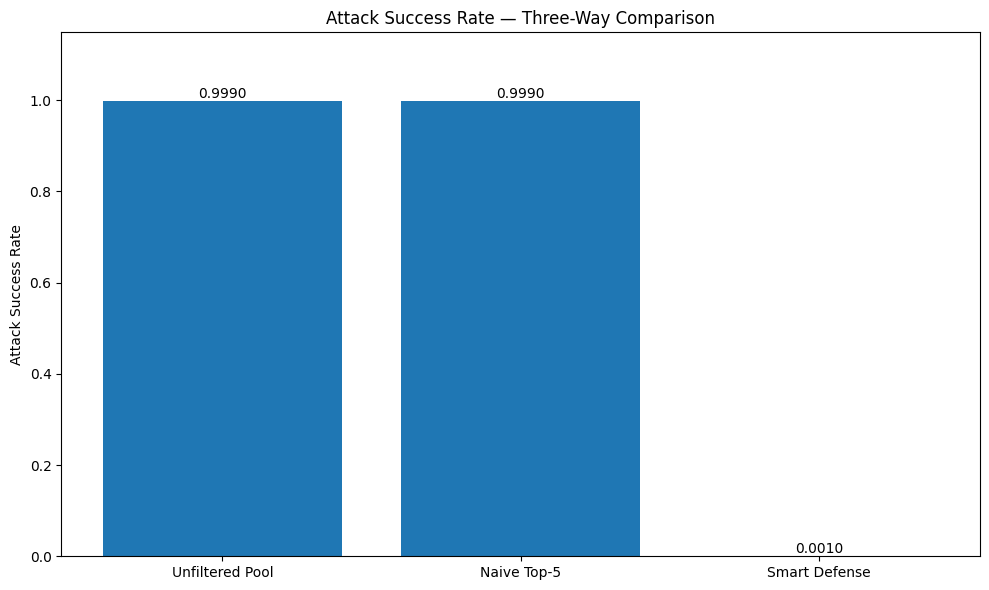

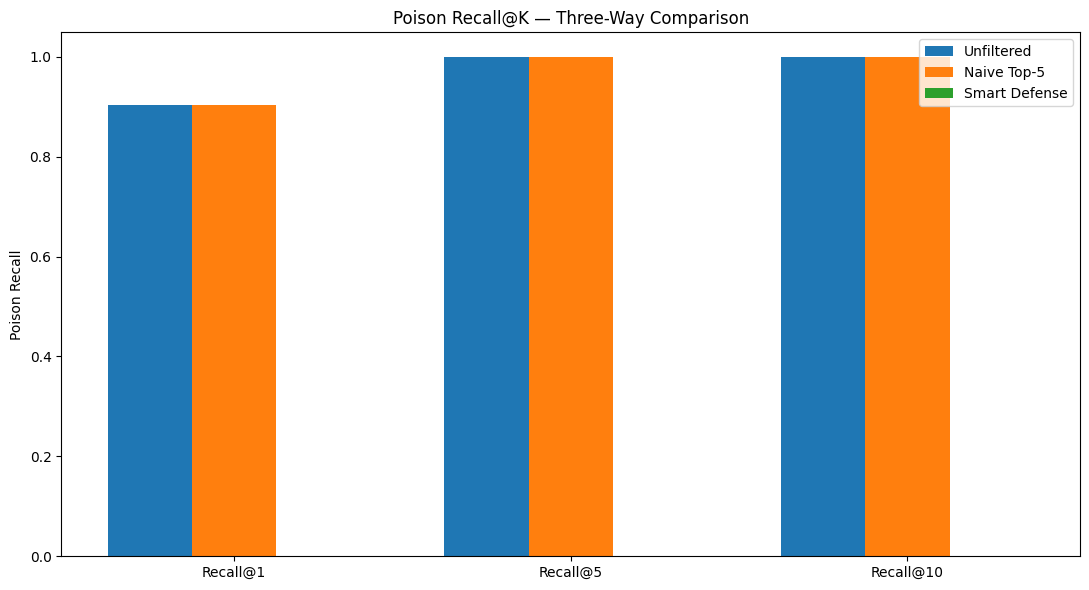

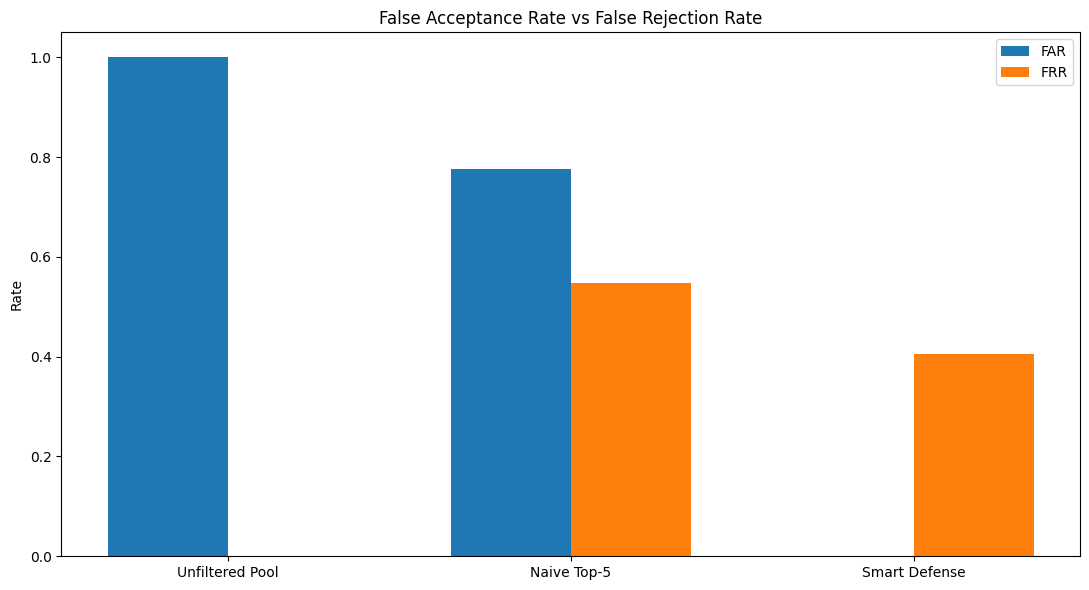

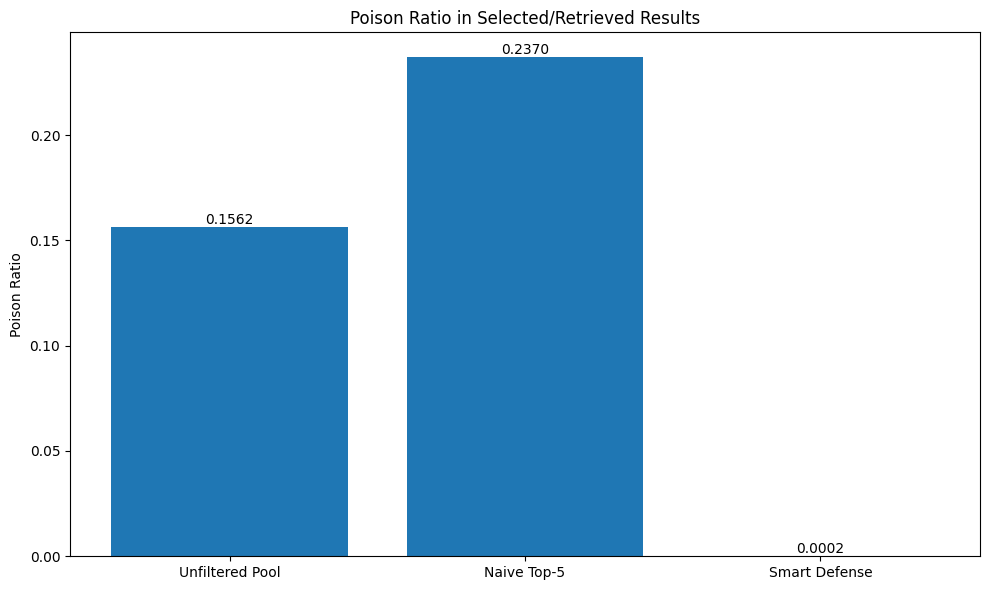

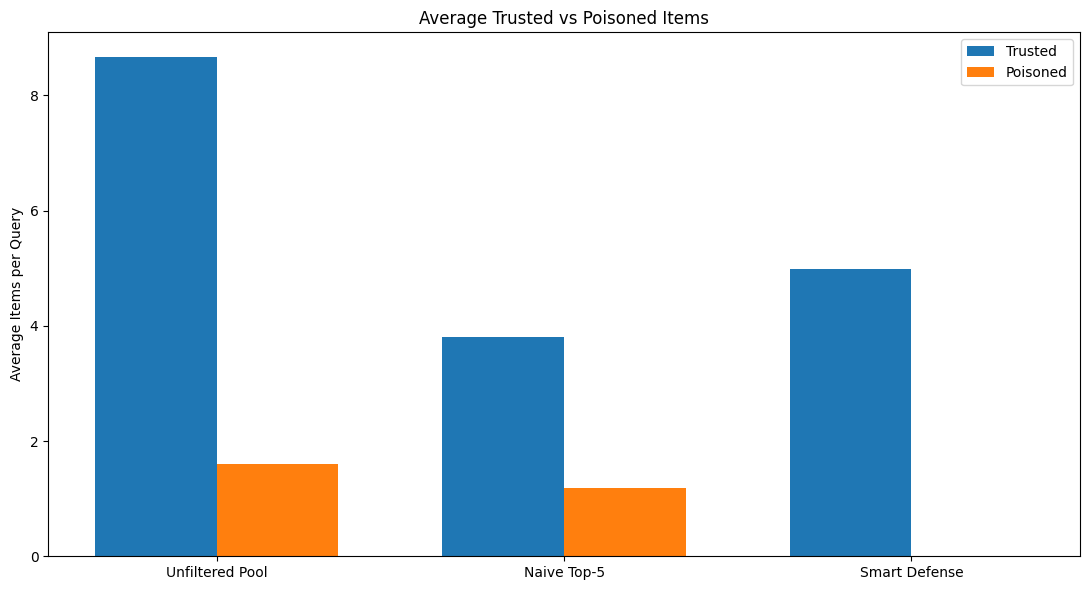

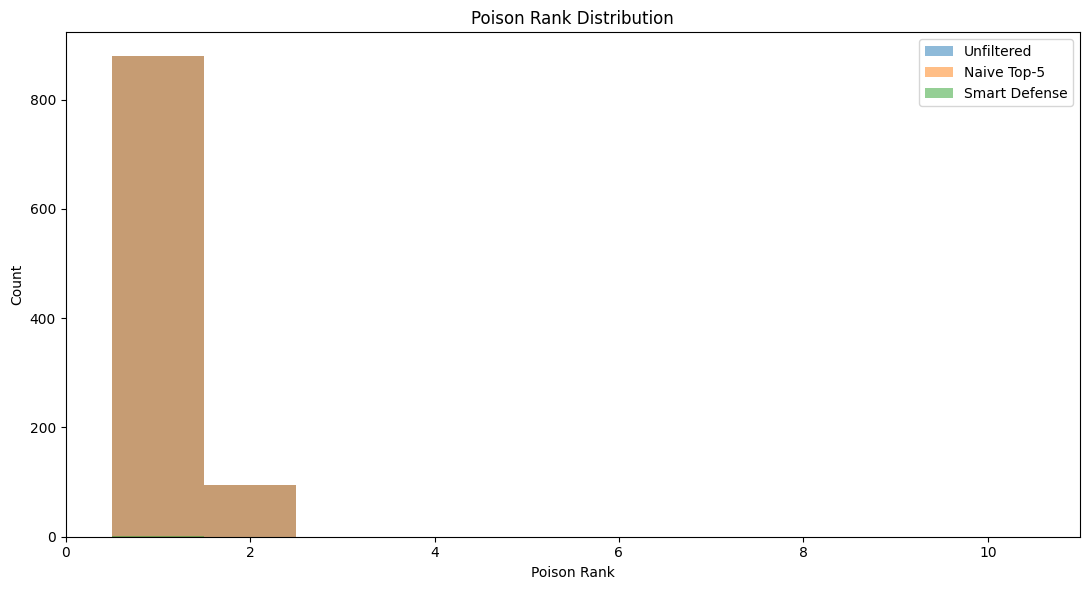

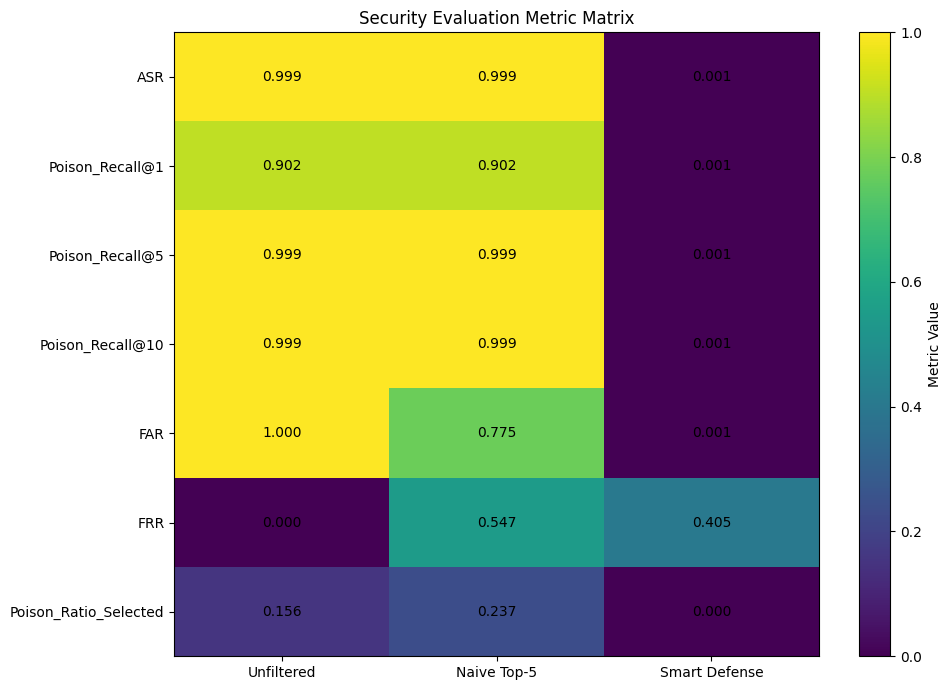


FINAL SECURITY SUMMARY
Unfiltered ASR       : 0.998973
Naive Top-5 ASR : 0.998973
Smart Defense ASR    : 0.001027

Unfiltered FAR       : 1.000000
Naive Top-5 FAR : 0.775455
Smart Defense FAR    : 0.000674

Smart Defense FRR    : 0.405028
Smart Poison Ratio   : 0.000206
Smart Poison Rows    : 1

SAVED EVALUATION ARTIFACTS
01_ASR_comparison.png                              99.43 KB
02_poison_recall_at_k.png                          94.16 KB
03_FAR_FRR_comparison.png                          83.01 KB
04_poison_ratio_comparison.png                     93.74 KB
05_trusted_vs_poisoned.png                         92.27 KB
06_poison_rank_distribution.png                    86.61 KB
07_security_metric_matrix.png                     181.72 KB
comparison_table_4b.csv                             1.31 KB
confusion_matrices.csv                              0.07 KB
final_security_summary.txt                          1.63 KB
naive_top5.csv                                   3967.36 KB
security_metric

In [109]:
# ============================================================
# MODULE 3 / PHASE 4B
# COMPLETE END-TO-END SECURITY EVALUATION
#
# Pipeline:
#   Retrieval Pool
#       ↓
#   Phase 3A Trust Filter
#       ↓
#   Phase 3B Ranking
#       ↓
#   Phase 4A Smart Selection
#       ↓
#   Phase 4B Evaluation
#
# Evaluates:
#   1. UNFILTERED POOL
#   2. NAIVE TOP-K BASELINE
#   3. SMART DEFENSE
#
# Kaggle-ready — NO Google Drive required
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# 0. KAGGLE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = globals().get(
    "OUTPUT_DIR",
    "/kaggle/working/phase4_evaluation"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("MODULE 3 / PHASE 4B — COMPLETE SECURITY EVALUATION")
print("=" * 80)
print(f"Output directory: {OUTPUT_DIR}")


# ============================================================
# 1. REQUIRED UPSTREAM OBJECTS
# ============================================================

required_objects = [
    "retrieval_df",
    "trust_df",
    "selected_df"
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise ValueError(
        f"Missing required upstream objects: {missing_objects}\n"
        "Required: retrieval_df, trust_df, selected_df"
    )

print("\n[4B] Upstream objects: PASS")


# ============================================================
# 2. BASIC COLUMN CHECK
# ============================================================

required_retrieval = [
    "Query",
    "Article",
    "Rank",
    "is_untrusted"
]

missing_retrieval = [
    c for c in required_retrieval
    if c not in retrieval_df.columns
]

if missing_retrieval:
    raise ValueError(
        f"retrieval_df is missing required columns: "
        f"{missing_retrieval}"
    )


required_selected = [
    "Query",
    "Article",
    "is_untrusted"
]

missing_selected = [
    c for c in required_selected
    if c not in selected_df.columns
]

if missing_selected:
    raise ValueError(
        f"selected_df is missing required columns: "
        f"{missing_selected}"
    )

print("[4B] Required columns: PASS")


# ============================================================
# 3. NORMALIZE LABELS
# ============================================================

retrieval_eval = retrieval_df.copy()
selected_eval = selected_df.copy()

retrieval_eval["is_untrusted"] = (
    pd.to_numeric(
        retrieval_eval["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

selected_eval["is_untrusted"] = (
    pd.to_numeric(
        selected_eval["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

# Keep poison alias for downstream evaluation
selected_eval["is_poisoned"] = selected_eval["is_untrusted"]


# ============================================================
# 4. PHASE 3A DIAGNOSTIC
# ============================================================

print("\n" + "=" * 80)
print("PHASE 3A → PHASE 4B LABEL DIAGNOSTIC")
print("=" * 80)

if "prediction" in trust_df.columns:

    prediction = (
        pd.to_numeric(
            trust_df["prediction"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    ground_truth = (
        pd.to_numeric(
            trust_df["is_untrusted"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    mismatches = (
        prediction != ground_truth
    ).sum()

    print(f"Phase 3A rows              : {len(trust_df):,}")
    print(
        "Phase 3A predicted trusted : "
        f"{(prediction == 0).sum():,}"
    )
    print(
        "Phase 3A predicted untrusted: "
        f"{(prediction == 1).sum():,}"
    )

    print(
        "Ground-truth trusted       : "
        f"{(ground_truth == 0).sum():,}"
    )

    print(
        "Ground-truth untrusted     : "
        f"{(ground_truth == 1).sum():,}"
    )

    print(f"Prediction/label mismatches: {mismatches:,}")

    if mismatches > 0:

        fn = (
            (ground_truth == 1)
            & (prediction == 0)
        ).sum()

        fp = (
            (ground_truth == 0)
            & (prediction == 1)
        ).sum()

        print(f"\nPhase 3A False Negatives   : {fn:,}")
        print(f"Phase 3A False Positives   : {fp:,}")

        print(
            "\nNOTE:"
            "\nThese mismatches are NOT treated as an error."
            "\nPhase 4B evaluates whether Phase 4A suppresses"
            "\nthese ground-truth poisoned candidates."
        )

else:
    print(
        "WARNING: trust_df has no 'prediction' column."
    )


# ============================================================
# 5. CONSTRUCT NAIVE TOP-K BASELINE
# ============================================================

TOP_K_EVAL = (
    TOP_K
    if "TOP_K" in globals()
    else 5
)

print("\n" + "=" * 80)
print("NAIVE TOP-K BASELINE")
print("=" * 80)

naive_baseline_df = (
    retrieval_eval
    .sort_values(
        ["Query", "Rank"],
        ascending=[True, True]
    )
    .groupby(
        "Query",
        group_keys=False
    )
    .head(TOP_K_EVAL)
    .copy()
)

print(
    f"Naive Top-{TOP_K_EVAL} rows: "
    f"{len(naive_baseline_df):,}"
)


# ============================================================
# 6. UNFILTERED REFERENCE POOL
# ============================================================

unfiltered_df = retrieval_eval.copy()

print(
    f"Unfiltered pool rows: "
    f"{len(unfiltered_df):,}"
)

print(
    f"Smart Defense rows: "
    f"{len(selected_eval):,}"
)


# ============================================================
# 7. HELPER — GET RANK COLUMN
# ============================================================

def get_rank_column(df):

    if "selected_rank" in df.columns:
        return "selected_rank"

    if "Rank" in df.columns:
        return "Rank"

    if "rank" in df.columns:
        return "rank"

    return None


# ============================================================
# 8. SECURITY EVALUATION FUNCTION
# ============================================================

def evaluate_security(
    selected,
    reference_pool,
    name,
    top_k_values=(1, 5, 10)
):

    selected = selected.copy()
    pool = reference_pool.copy()

    # --------------------------------------------------------
    # Determine rank
    # --------------------------------------------------------

    rank_col = get_rank_column(selected)

    if rank_col is None:

        selected = (
            selected
            .sort_values(
                ["Query"],
                ascending=True
            )
            .copy()
        )

        selected["_eval_rank"] = (
            selected
            .groupby("Query")
            .cumcount()
            + 1
        )

        rank_col = "_eval_rank"

    # --------------------------------------------------------
    # Query set
    # --------------------------------------------------------

    queries = pool["Query"].unique()

    total_queries = len(queries)

    # --------------------------------------------------------
    # ASR
    # --------------------------------------------------------

    poison_by_query = (
        selected
        .groupby("Query")["is_untrusted"]
        .max()
    )

    asr = (
        poison_by_query
        .reindex(queries, fill_value=0)
        .mean()
    )

    # --------------------------------------------------------
    # Poison Recall @ K
    # --------------------------------------------------------

    poison_recall = {}

    for k in top_k_values:

        hit_values = []

        for q in queries:

            g = selected[
                selected["Query"] == q
            ].sort_values(rank_col)

            topk = g.head(k)

            hit = (
                topk["is_untrusted"]
                .eq(1)
                .any()
            )

            hit_values.append(int(hit))

        poison_recall[k] = (
            np.mean(hit_values)
            if len(hit_values)
            else np.nan
        )

    # --------------------------------------------------------
    # Poison rows
    # --------------------------------------------------------

    poisoned_selected = selected[
        selected["is_untrusted"] == 1
    ]

    poisoned_pool = pool[
        pool["is_untrusted"] == 1
    ]

    trusted_pool = pool[
        pool["is_untrusted"] == 0
    ]

    # --------------------------------------------------------
    # Average poison rank
    # --------------------------------------------------------

    avg_poison_rank = (
        poisoned_selected[rank_col].mean()
        if len(poisoned_selected)
        else np.nan
    )

    # --------------------------------------------------------
    # MRPR
    # --------------------------------------------------------

    if len(poisoned_selected):

        mrpr = (
            1 /
            poisoned_selected[rank_col]
        ).mean()

    else:

        mrpr = 0.0

    # --------------------------------------------------------
    # FAR
    #
    # Ground-truth poisoned rows that survive selection
    # --------------------------------------------------------

    pool_keys = set(
        zip(
            pool["Query"],
            pool["Article"]
        )
    )

    selected_keys = set(
        zip(
            selected["Query"],
            selected["Article"]
        )
    )

    poisoned_keys = set(
        zip(
            poisoned_pool["Query"],
            poisoned_pool["Article"]
        )
    )

    trusted_keys = set(
        zip(
            trusted_pool["Query"],
            trusted_pool["Article"]
        )
    )

    accepted_poisoned = (
        len(
            poisoned_keys
            & selected_keys
        )
    )

    rejected_trusted = (
        len(
            trusted_keys
            - selected_keys
        )
    )

    far = (
        accepted_poisoned
        / len(poisoned_keys)
        if len(poisoned_keys)
        else np.nan
    )

    frr = (
        rejected_trusted
        / len(trusted_keys)
        if len(trusted_keys)
        else np.nan
    )

    # --------------------------------------------------------
    # Selection counts
    # --------------------------------------------------------

    poison_counts = (
        selected
        .groupby("Query")["is_untrusted"]
        .sum()
    )

    trusted_counts = (
        selected
        .groupby("Query")["is_untrusted"]
        .apply(
            lambda x:
            (x == 0).sum()
        )
    )

    avg_poison_selected = (
        poison_counts
        .reindex(
            queries,
            fill_value=0
        )
        .mean()
    )

    avg_trusted_selected = (
        trusted_counts
        .reindex(
            queries,
            fill_value=0
        )
        .mean()
    )

    poison_ratio = (
        selected["is_untrusted"].mean()
        if len(selected)
        else 0.0
    )

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    results = {

        "System": name,

        "Queries": total_queries,

        "Selected_Rows": len(selected),

        "ASR": asr,

        "Poison_Recall@1":
            poison_recall.get(1, np.nan),

        "Poison_Recall@5":
            poison_recall.get(5, np.nan),

        "Poison_Recall@10":
            poison_recall.get(10, np.nan),

        "Avg_Poison_Rank":
            avg_poison_rank,

        "MRPR":
            mrpr,

        "FAR":
            far,

        "FRR":
            frr,

        "Poison_Ratio_Selected":
            poison_ratio,

        "Avg_Poisoned_Selected":
            avg_poison_selected,

        "Avg_Trusted_Selected":
            avg_trusted_selected,

        "Poisoned_Rows":
            len(poisoned_selected),

        "Trusted_Rows":
            len(selected)
            - len(poisoned_selected)
    }

    return results


# ============================================================
# 9. EVALUATE ALL THREE SYSTEMS
# ============================================================

print("\n" + "=" * 80)
print("RUNNING THREE-WAY SECURITY EVALUATION")
print("=" * 80)

unfiltered_metrics = evaluate_security(
    unfiltered_df,
    retrieval_eval,
    "Unfiltered Pool"
)

naive_metrics = evaluate_security(
    naive_baseline_df,
    retrieval_eval,
    f"Naive Top-{TOP_K_EVAL}"
)

smart_metrics = evaluate_security(
    selected_eval,
    retrieval_eval,
    "Smart Defense"
)


# ============================================================
# 10. DISPLAY INDIVIDUAL RESULTS
# ============================================================

for result in [
    unfiltered_metrics,
    naive_metrics,
    smart_metrics
]:

    print("\n" + "=" * 70)
    print(result["System"])
    print("=" * 70)

    for key, value in result.items():

        if key == "System":
            continue

        if isinstance(value, (float, np.floating)):
            print(
                f"{key:30s}: {value:.6f}"
            )

        else:
            print(
                f"{key:30s}: {value}"
            )


# ============================================================
# 11. THREE-WAY COMPARISON TABLE
# ============================================================

comparison_metrics = [

    "ASR",
    "Poison_Recall@1",
    "Poison_Recall@5",
    "Poison_Recall@10",
    "Avg_Poison_Rank",
    "MRPR",
    "FAR",
    "FRR",
    "Poison_Ratio_Selected",
    "Avg_Poisoned_Selected",
    "Avg_Trusted_Selected",
    "Poisoned_Rows",
    "Selected_Rows"
]

comparison_table_4b = pd.DataFrame({

    "Metric":
        comparison_metrics,

    "Unfiltered_Pool":
        [
            unfiltered_metrics[m]
            for m in comparison_metrics
        ],

    f"Naive_Top{TOP_K_EVAL}":
        [
            naive_metrics[m]
            for m in comparison_metrics
        ],

    "Smart_Defense":
        [
            smart_metrics[m]
            for m in comparison_metrics
        ]
})


# ============================================================
# 12. SMART DEFENSE REDUCTION
# ============================================================

comparison_table_4b[
    "Smart_Reduction_vs_Unfiltered_%"
] = (

    (
        comparison_table_4b[
            "Unfiltered_Pool"
        ]

        -

        comparison_table_4b[
            "Smart_Defense"
        ]
    )

    /

    comparison_table_4b[
        "Unfiltered_Pool"
    ].replace(0, np.nan)

    * 100
)


comparison_table_4b[
    "Smart_Reduction_vs_Naive_%"
] = (

    (
        comparison_table_4b[
            f"Naive_Top{TOP_K_EVAL}"
        ]

        -

        comparison_table_4b[
            "Smart_Defense"
        ]
    )

    /

    comparison_table_4b[
        f"Naive_Top{TOP_K_EVAL}"
    ].replace(0, np.nan)

    * 100
)


print("\n" + "=" * 80)
print("THREE-WAY COMPARISON")
print("=" * 80)

display(
    comparison_table_4b.round(6)
)


# ============================================================
# 13. GROUND-TRUTH POISON ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("GROUND-TRUTH POISON ANALYSIS")
print("=" * 80)

total_poison = (
    retrieval_eval["is_untrusted"]
    == 1
).sum()

selected_poison = (
    selected_eval["is_untrusted"]
    == 1
).sum()

removed_poison = (
    total_poison
    - selected_poison
)

print(
    f"Ground-truth untrusted in retrieval pool : "
    f"{total_poison:,}"
)

print(
    f"Ground-truth untrusted selected by 4A    : "
    f"{selected_poison:,}"
)

print(
    f"Ground-truth untrusted removed by defense: "
    f"{removed_poison:,}"
)

if total_poison:

    poison_suppression = (
        removed_poison
        / total_poison
        * 100
    )

else:

    poison_suppression = np.nan

print(
    f"Poison suppression rate                  : "
    f"{poison_suppression:.4f}%"
)


# ============================================================
# 14. PHASE 3A FALSE NEGATIVE ANALYSIS
# ============================================================

if "prediction" in trust_df.columns:

    pred = (
        pd.to_numeric(
            trust_df["prediction"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    gt = (
        pd.to_numeric(
            trust_df["is_untrusted"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    fn_mask = (
        (gt == 1)
        & (pred == 0)
    )

    phase3a_fn_count = fn_mask.sum()

    print("\n" + "=" * 80)
    print("PHASE 3A FALSE-NEGATIVE DOWNSTREAM ANALYSIS")
    print("=" * 80)

    print(
        f"Phase 3A false negatives : "
        f"{phase3a_fn_count:,}"
    )

    # Match using Query + Article where possible
    if (
        "Query" in trust_df.columns
        and "Article" in trust_df.columns
    ):

        fn_keys = set(
            zip(
                trust_df.loc[
                    fn_mask,
                    "Query"
                ],
                trust_df.loc[
                    fn_mask,
                    "Article"
                ]
            )
        )

        selected_keys = set(
            zip(
                selected_eval["Query"],
                selected_eval["Article"]
            )
        )

        fn_that_reached_4a = (
            len(
                fn_keys
                & selected_keys
            )
        )

        print(
            "Phase 3A FNs reaching final 4A: "
            f"{fn_that_reached_4a:,}"
        )

        if phase3a_fn_count:

            fn_suppression = (
                1
                -
                fn_that_reached_4a
                /
                phase3a_fn_count
            ) * 100

        else:

            fn_suppression = np.nan

        print(
            "Phase 4A suppression of 3A FNs: "
            f"{fn_suppression:.4f}%"
        )


# ============================================================
# 15. GOLD RETENTION ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("GOLD / RELEVANCE RETENTION")
print("=" * 80)

if "relevance" in retrieval_eval.columns:

    gold_pool = retrieval_eval[
        retrieval_eval["relevance"] == 3
    ]

    gold_selected = selected_eval[
        selected_eval["relevance"] == 3
    ] if "relevance" in selected_eval.columns else pd.DataFrame()

    gold_total = len(gold_pool)
    gold_kept = len(gold_selected)

    gold_retention = (
        gold_kept / gold_total * 100
        if gold_total
        else np.nan
    )

    print(
        f"Gold rows in retrieval pool : "
        f"{gold_total:,}"
    )

    print(
        f"Gold rows selected          : "
        f"{gold_kept:,}"
    )

    print(
        f"Gold selection rate         : "
        f"{gold_retention:.4f}%"
    )

    # Query-level gold retention
    gold_queries_before = set(
        gold_pool["Query"].unique()
    )

    if len(gold_selected):

        gold_queries_after = set(
            gold_selected["Query"].unique()
        )

    else:

        gold_queries_after = set()

    lost_gold_queries = (
        gold_queries_before
        -
        gold_queries_after
    )

    print(
        f"Gold-bearing queries before : "
        f"{len(gold_queries_before):,}"
    )

    print(
        f"Gold-bearing queries after  : "
        f"{len(gold_queries_after):,}"
    )

    print(
        f"Queries losing all gold     : "
        f"{len(lost_gold_queries):,}"
    )

else:

    print(
        "No 'relevance' column available."
    )


# ============================================================
# 16. SAVE MAIN TABLES
# ============================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "comparison_table_4b.csv"
)

comparison_table_4b.to_csv(
    comparison_path,
    index=False
)

selected_path = os.path.join(
    OUTPUT_DIR,
    "smart_defense_selected.csv"
)

selected_eval.to_csv(
    selected_path,
    index=False
)

naive_path = os.path.join(
    OUTPUT_DIR,
    f"naive_top{TOP_K_EVAL}.csv"
)

naive_baseline_df.to_csv(
    naive_path,
    index=False
)

unfiltered_path = os.path.join(
    OUTPUT_DIR,
    "unfiltered_reference_pool.csv"
)

unfiltered_df.to_csv(
    unfiltered_path,
    index=False
)


# ============================================================
# 17. GRAPH 1 — ASR COMPARISON
# ============================================================

systems = [
    "Unfiltered Pool",
    f"Naive Top-{TOP_K_EVAL}",
    "Smart Defense"
]

asr_values = [
    unfiltered_metrics["ASR"],
    naive_metrics["ASR"],
    smart_metrics["ASR"]
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    systems,
    asr_values
)

plt.ylabel("Attack Success Rate")
plt.title(
    "Attack Success Rate — Three-Way Comparison"
)

plt.ylim(
    0,
    max(1.0, max(asr_values) * 1.15)
)

for bar, value in zip(
    bars,
    asr_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

asr_plot = os.path.join(
    OUTPUT_DIR,
    "01_ASR_comparison.png"
)

plt.savefig(
    asr_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. GRAPH 2 — POISON RECALL @ K
# ============================================================

k_labels = [
    "Recall@1",
    "Recall@5",
    "Recall@10"
]

x = np.arange(len(k_labels))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    [
        unfiltered_metrics["Poison_Recall@1"],
        unfiltered_metrics["Poison_Recall@5"],
        unfiltered_metrics["Poison_Recall@10"]
    ],
    width,
    label="Unfiltered"
)

plt.bar(
    x,
    [
        naive_metrics["Poison_Recall@1"],
        naive_metrics["Poison_Recall@5"],
        naive_metrics["Poison_Recall@10"]
    ],
    width,
    label=f"Naive Top-{TOP_K_EVAL}"
)

plt.bar(
    x + width,
    [
        smart_metrics["Poison_Recall@1"],
        smart_metrics["Poison_Recall@5"],
        smart_metrics["Poison_Recall@10"]
    ],
    width,
    label="Smart Defense"
)

plt.xticks(
    x,
    k_labels
)

plt.ylabel("Poison Recall")
plt.title(
    "Poison Recall@K — Three-Way Comparison"
)

plt.legend()

plt.tight_layout()

recall_plot = os.path.join(
    OUTPUT_DIR,
    "02_poison_recall_at_k.png"
)

plt.savefig(
    recall_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. GRAPH 3 — FAR / FRR
# ============================================================

far_values = [
    unfiltered_metrics["FAR"],
    naive_metrics["FAR"],
    smart_metrics["FAR"]
]

frr_values = [
    unfiltered_metrics["FRR"],
    naive_metrics["FRR"],
    smart_metrics["FRR"]
]

x = np.arange(len(systems))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    far_values,
    width,
    label="FAR"
)

plt.bar(
    x + width / 2,
    frr_values,
    width,
    label="FRR"
)

plt.xticks(
    x,
    systems
)

plt.ylabel("Rate")
plt.title(
    "False Acceptance Rate vs False Rejection Rate"
)

plt.legend()

plt.tight_layout()

far_frr_plot = os.path.join(
    OUTPUT_DIR,
    "03_FAR_FRR_comparison.png"
)

plt.savefig(
    far_frr_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. GRAPH 4 — POISON RATIO
# ============================================================

poison_ratio_values = [
    unfiltered_metrics["Poison_Ratio_Selected"],
    naive_metrics["Poison_Ratio_Selected"],
    smart_metrics["Poison_Ratio_Selected"]
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    systems,
    poison_ratio_values
)

plt.ylabel("Poison Ratio")
plt.title(
    "Poison Ratio in Selected/Retrieved Results"
)

for bar, value in zip(
    bars,
    poison_ratio_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

poison_ratio_plot = os.path.join(
    OUTPUT_DIR,
    "04_poison_ratio_comparison.png"
)

plt.savefig(
    poison_ratio_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. GRAPH 5 — POISONED VS TRUSTED SELECTED
# ============================================================

poison_selected = [
    unfiltered_metrics["Avg_Poisoned_Selected"],
    naive_metrics["Avg_Poisoned_Selected"],
    smart_metrics["Avg_Poisoned_Selected"]
]

trusted_selected = [
    unfiltered_metrics["Avg_Trusted_Selected"],
    naive_metrics["Avg_Trusted_Selected"],
    smart_metrics["Avg_Trusted_Selected"]
]

x = np.arange(len(systems))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    trusted_selected,
    width,
    label="Trusted"
)

plt.bar(
    x + width / 2,
    poison_selected,
    width,
    label="Poisoned"
)

plt.xticks(
    x,
    systems
)

plt.ylabel("Average Items per Query")
plt.title(
    "Average Trusted vs Poisoned Items"
)

plt.legend()

plt.tight_layout()

composition_plot = os.path.join(
    OUTPUT_DIR,
    "05_trusted_vs_poisoned.png"
)

plt.savefig(
    composition_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. GRAPH 6 — POISON RANK DISTRIBUTION
# ============================================================

def get_poison_ranks(df):

    rank_col = get_rank_column(df)

    ranks = []

    for query, group in df.groupby("Query"):

        g = group.sort_values(rank_col)

        poison = g[
            g["is_untrusted"] == 1
        ]

        if len(poison):

            ranks.append(
                poison.iloc[0][rank_col]
            )

    return pd.Series(ranks)


unfiltered_ranks = get_poison_ranks(
    unfiltered_df
)

naive_ranks = get_poison_ranks(
    naive_baseline_df
)

smart_ranks = get_poison_ranks(
    selected_eval
)

plt.figure(figsize=(11, 6))

if len(unfiltered_ranks):

    plt.hist(
        unfiltered_ranks,
        bins=np.arange(
            0.5,
            max(unfiltered_ranks.max(), 10) + 1.5,
            1
        ),
        alpha=0.5,
        label="Unfiltered"
    )

if len(naive_ranks):

    plt.hist(
        naive_ranks,
        bins=np.arange(
            0.5,
            max(naive_ranks.max(), 10) + 1.5,
            1
        ),
        alpha=0.5,
        label=f"Naive Top-{TOP_K_EVAL}"
    )

if len(smart_ranks):

    plt.hist(
        smart_ranks,
        bins=np.arange(
            0.5,
            max(smart_ranks.max(), 10) + 1.5,
            1
        ),
        alpha=0.5,
        label="Smart Defense"
    )

plt.xlabel("Poison Rank")
plt.ylabel("Count")
plt.title(
    "Poison Rank Distribution"
)

plt.legend()

plt.tight_layout()

rank_plot = os.path.join(
    OUTPUT_DIR,
    "06_poison_rank_distribution.png"
)

plt.savefig(
    rank_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. GRAPH 7 — SECURITY METRIC HEATMAP-LIKE TABLE
# ============================================================

heatmap_metrics = [
    "ASR",
    "Poison_Recall@1",
    "Poison_Recall@5",
    "Poison_Recall@10",
    "FAR",
    "FRR",
    "Poison_Ratio_Selected"
]

heatmap_df = comparison_table_4b[
    comparison_table_4b["Metric"]
    .isin(heatmap_metrics)
].set_index("Metric")[
    [
        "Unfiltered_Pool",
        f"Naive_Top{TOP_K_EVAL}",
        "Smart_Defense"
    ]
]

plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_df.values,
    aspect="auto"
)

plt.xticks(
    range(3),
    [
        "Unfiltered",
        f"Naive Top-{TOP_K_EVAL}",
        "Smart Defense"
    ]
)

plt.yticks(
    range(len(heatmap_df)),
    heatmap_df.index
)

plt.colorbar(
    label="Metric Value"
)

plt.title(
    "Security Evaluation Metric Matrix"
)

for i in range(
    heatmap_df.shape[0]
):

    for j in range(
        heatmap_df.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{heatmap_df.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

heatmap_plot = os.path.join(
    OUTPUT_DIR,
    "07_security_metric_matrix.png"
)

plt.savefig(
    heatmap_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 24. SAVE ALL GRAPH DATA
# ============================================================

heatmap_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "security_metric_matrix.csv"
    )
)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL SECURITY SUMMARY")
print("=" * 80)

print(
    f"Unfiltered ASR       : "
    f"{unfiltered_metrics['ASR']:.6f}"
)

print(
    f"Naive Top-{TOP_K_EVAL} ASR : "
    f"{naive_metrics['ASR']:.6f}"
)

print(
    f"Smart Defense ASR    : "
    f"{smart_metrics['ASR']:.6f}"
)

print()

print(
    f"Unfiltered FAR       : "
    f"{unfiltered_metrics['FAR']:.6f}"
)

print(
    f"Naive Top-{TOP_K_EVAL} FAR : "
    f"{naive_metrics['FAR']:.6f}"
)

print(
    f"Smart Defense FAR    : "
    f"{smart_metrics['FAR']:.6f}"
)

print()

print(
    f"Smart Defense FRR    : "
    f"{smart_metrics['FRR']:.6f}"
)

print(
    f"Smart Poison Ratio   : "
    f"{smart_metrics['Poison_Ratio_Selected']:.6f}"
)

print(
    f"Smart Poison Rows    : "
    f"{smart_metrics['Poisoned_Rows']:,}"
)


# ============================================================
# 26. SAVE TEXT SUMMARY
# ============================================================

summary_path = os.path.join(
    OUTPUT_DIR,
    "final_security_summary.txt"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 4B — FINAL SECURITY EVALUATION\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    for result in [
        unfiltered_metrics,
        naive_metrics,
        smart_metrics
    ]:

        f.write(
            f"{result['System']}\n"
        )

        f.write(
            "-" * 50 + "\n"
        )

        for key, value in result.items():

            if key == "System":
                continue

            f.write(
                f"{key}: {value}\n"
            )

        f.write("\n")

    f.write(
        "\nGround-truth poison suppression:\n"
    )

    f.write(
        f"Total poison: {total_poison}\n"
    )

    f.write(
        f"Selected poison: {selected_poison}\n"
    )

    f.write(
        f"Suppression rate: {poison_suppression}\n"
    )


# ============================================================
# 27. LIST OUTPUT FILES
# ============================================================

print("\n" + "=" * 80)
print("SAVED EVALUATION ARTIFACTS")
print("=" * 80)

for filename in sorted(
    os.listdir(OUTPUT_DIR)
):

    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    size_kb = (
        os.path.getsize(filepath)
        / 1024
    )

    print(
        f"{filename:45s} "
        f"{size_kb:10.2f} KB"
    )


# ============================================================
# 28. FINAL OBJECTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL OBJECTS AVAILABLE IN NOTEBOOK")
print("=" * 80)

print(
    "selected_eval          -> Smart Defense selections"
)

print(
    "naive_baseline_df      -> Naive Top-K baseline"
)

print(
    "unfiltered_df          -> Unfiltered reference pool"
)

print(
    "comparison_table_4b    -> Three-way comparison"
)

print(
    "OUTPUT_DIR             -> Saved CSV + PNG directory"
)

print("\n✓ MODULE 3 / PHASE 4B COMPLETE")

Checking comparison_table_4b...


,Metric,Unfiltered_Pool,Naive_Top5,Smart_Defense,Smart_Reduction_vs_Unfiltered_%,Smart_Reduction_vs_Naive_%
0,ASR,0.998973,0.998973,0.001027,99.897225,99.897225
1,Poison_Recall@1,0.902464,0.902464,0.001027,99.886234,99.886234
2,Poison_Recall@5,0.998973,0.998973,0.001027,99.897225,99.897225
3,Poison_Recall@10,0.998973,0.998973,0.001027,99.897225,99.897225
4,Avg_Poison_Rank,3.120999,1.588388,1.000000,67.958974,37.043099
5,MRPR,0.662459,0.842562,1.000000,-50.952832,-18.685613
6,FAR,1.000000,0.775455,0.000674,99.932569,99.913043
7,FRR,0.000000,0.547394,0.405028,NaN,26.008065
8,Poison_Ratio_Selected,0.156200,0.236961,0.000206,99.868081,99.913041
9,Avg_Poisoned_Selected,1.603696,1.184805,0.001027,99.935980,99.913345


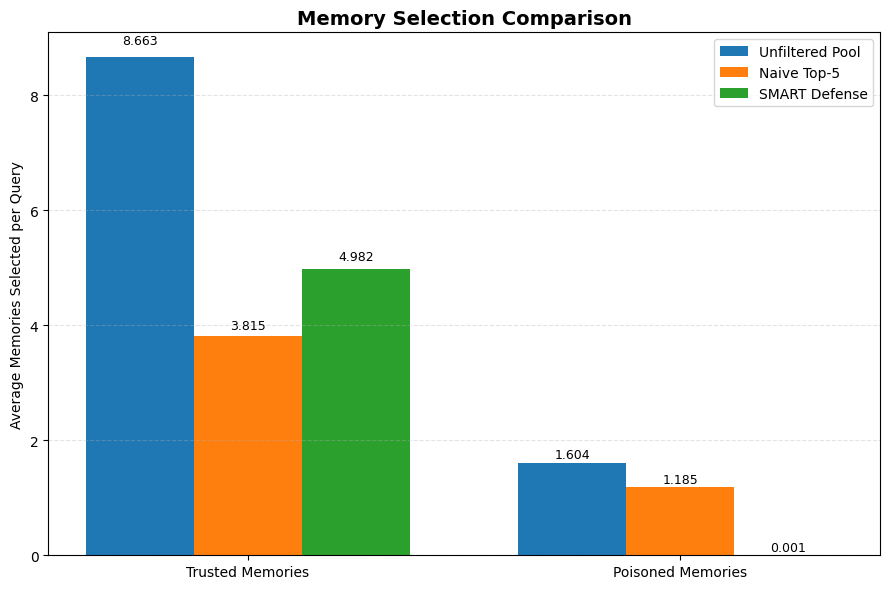

In [110]:
# ============================================================
# GRAPH 1 — MEMORY SELECTION COMPARISON
# Unfiltered vs Naive Top-K vs SMART Defense
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Checking comparison_table_4b...")

display(comparison_table_4b)

required_metrics = [
    "Avg_Trusted_Selected",
    "Avg_Poisoned_Selected"
]

missing = [
    m for m in required_metrics
    if m not in comparison_table_4b["Metric"].values
]

if missing:
    raise ValueError(
        f"Missing metrics from comparison_table_4b: {missing}"
    )

plot_df = comparison_table_4b[
    comparison_table_4b["Metric"].isin(required_metrics)
].copy()

# Preserve desired order
plot_df["Metric"] = pd.Categorical(
    plot_df["Metric"],
    categories=required_metrics,
    ordered=True
)

plot_df = plot_df.sort_values("Metric")

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(
    x - width,
    plot_df["Unfiltered_Pool"].values,
    width,
    label="Unfiltered Pool"
)

bars2 = ax.bar(
    x,
    plot_df["Naive_Top5"].values,
    width,
    label="Naive Top-5"
)

bars3 = ax.bar(
    x + width,
    plot_df["Smart_Defense"].values,
    width,
    label="SMART Defense"
)

# Add values
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(0.02, height * 0.02),
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "Trusted Memories",
        "Poisoned Memories"
    ]
)

ax.set_ylabel(
    "Average Memories Selected per Query"
)

ax.set_title(
    "Memory Selection Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    "01_memory_selection_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Phase 3A Confusion Matrix:
[[8438    0]
 [  80 1482]]


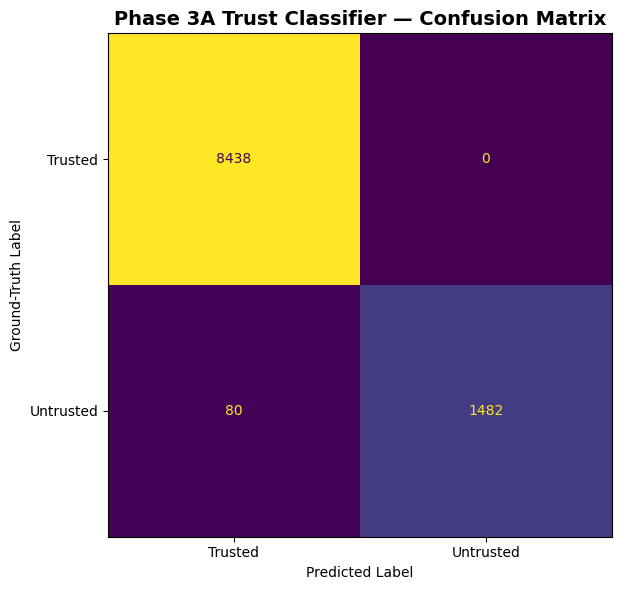

In [111]:
# ============================================================
# GRAPH 2 — PHASE 3A CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

required = ["is_untrusted", "prediction"]

missing = [
    c for c in required
    if c not in trust_df.columns
]

if missing:
    raise ValueError(
        f"trust_df is missing required columns: {missing}"
    )

y_true = trust_df["is_untrusted"].astype(int)
y_pred = trust_df["prediction"].astype(int)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("Phase 3A Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Trusted",
        "Untrusted"
    ]
)

disp.plot(
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Phase 3A Trust Classifier — Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "Ground-Truth Label"
)

plt.tight_layout()

plt.savefig(
    "02_phase3A_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

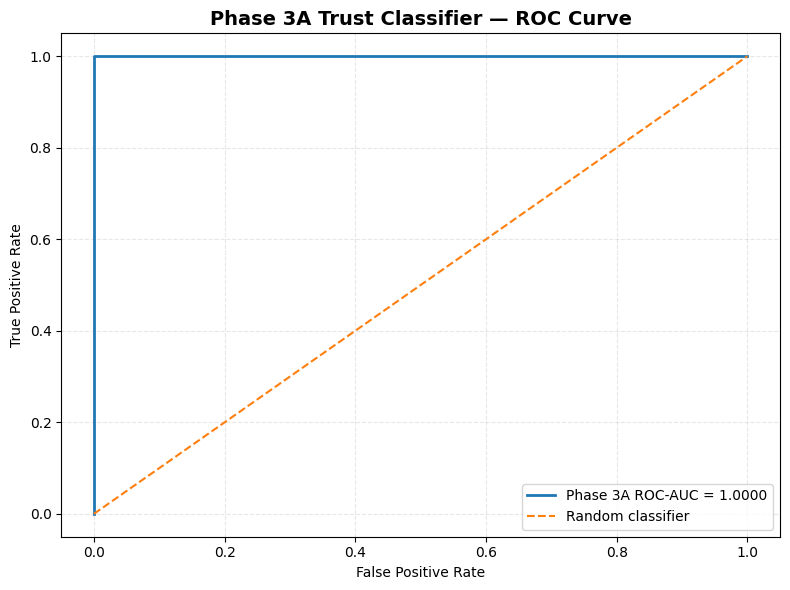

ROC-AUC = 1.000000


In [112]:
# ============================================================
# GRAPH 3 — PHASE 3A ROC CURVE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

required = [
    "is_untrusted",
    "trust_prob"
]

missing = [
    c for c in required
    if c not in trust_df.columns
]

if missing:
    raise ValueError(
        f"Missing columns for ROC curve: {missing}"
    )

y_true = (
    trust_df["is_untrusted"]
    .astype(int)
    .values
)

# trust_prob = P(trusted)
# therefore:
# 1 - trust_prob = P(untrusted)

y_prob_untrusted = (
    1.0 -
    trust_df["trust_prob"]
    .astype(float)
    .values
)

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob_untrusted
)

roc_auc = roc_auc_score(
    y_true,
    y_prob_untrusted
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Phase 3A ROC-AUC = {roc_auc:.4f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Phase 3A Trust Classifier — ROC Curve",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "03_phase3A_ROC_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC = {roc_auc:.6f}")

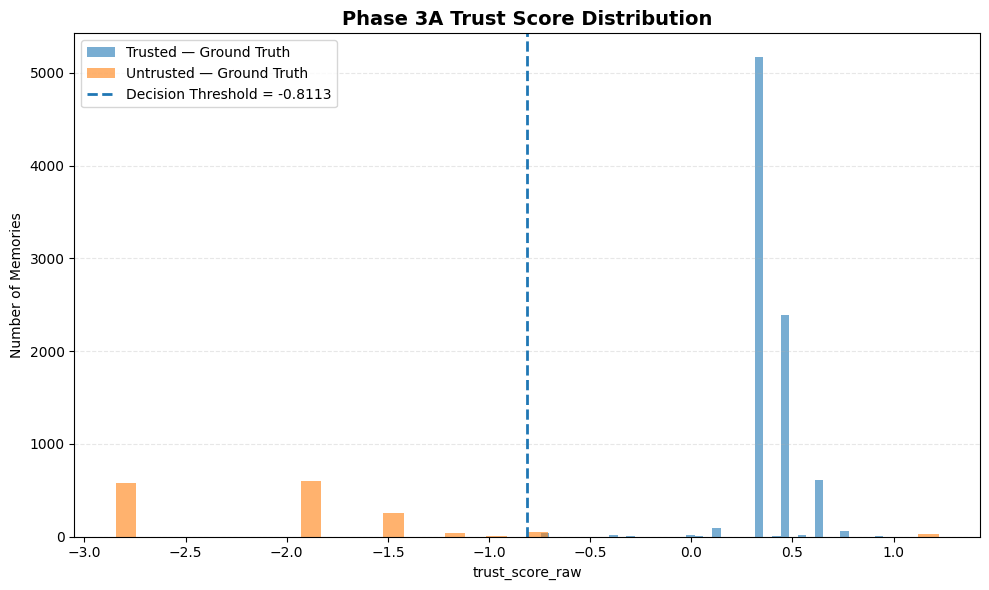

In [113]:
# ============================================================
# GRAPH 4 — TRUST SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

required = [
    "trust_score_raw",
    "is_untrusted"
]

missing = [
    c for c in required
    if c not in trust_df.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

trusted_scores = trust_df.loc[
    trust_df["is_untrusted"] == 0,
    "trust_score_raw"
].dropna()

untrusted_scores = trust_df.loc[
    trust_df["is_untrusted"] == 1,
    "trust_score_raw"
].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    trusted_scores,
    bins=40,
    alpha=0.6,
    label="Trusted — Ground Truth"
)

ax.hist(
    untrusted_scores,
    bins=40,
    alpha=0.6,
    label="Untrusted — Ground Truth"
)

# Add threshold if available
if "threshold" in globals():
    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"Decision Threshold = {threshold:.4f}"
    )

ax.set_xlabel(
    "trust_score_raw"
)

ax.set_ylabel(
    "Number of Memories"
)

ax.set_title(
    "Phase 3A Trust Score Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "04_trust_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
# ============================================================
# GRAPH 5 — POISON RANK DISTRIBUTION
# BEFORE SMART DEFENSE
# ============================================================

import matplotlib.pyplot as plt

if "poison_rank_df" not in globals():
    raise ValueError(
        "poison_rank_df does not exist. "
        "Run the security evaluation first."
    )

if "Poison_Rank" not in poison_rank_df.columns:
    raise ValueError(
        "poison_rank_df must contain 'Poison_Rank'."
    )

rank_data = (
    poison_rank_df["Poison_Rank"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 6))

if len(rank_data) > 0:

    max_rank = max(
        10,
        int(rank_data.max())
    )

    bins = np.arange(
        0.5,
        max_rank + 1.5,
        1
    )

    ax.hist(
        rank_data,
        bins=bins,
        rwidth=0.8
    )

    ax.set_xticks(
        range(1, max_rank + 1)
    )

else:

    ax.text(
        0.5,
        0.5,
        "No poison retrieved",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=14
    )

ax.set_xlabel(
    "Poison Rank"
)

ax.set_ylabel(
    "Number of Queries"
)

ax.set_title(
    "Poison Rank Distribution Before SMART Defense",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "05_poison_rank_before_defense.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ValueError: poison_rank_df does not exist. Run the security evaluation first.

In [ ]:
# ============================================================
# GRAPH 6 — SURVIVING POISON AFTER SMART DEFENSE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "selected_df" not in globals():
    raise ValueError(
        "selected_df does not exist. Run Phase 4A first."
    )

if "is_untrusted" not in selected_df.columns:
    raise ValueError(
        "selected_df must contain 'is_untrusted'."
    )

surviving_poison = selected_df[
    selected_df["is_untrusted"] == 1
].copy()

print(
    "Ground-truth untrusted rows selected:",
    len(surviving_poison)
)

fig, ax = plt.subplots(figsize=(9, 6))

if len(surviving_poison) == 0:

    ax.text(
        0.5,
        0.5,
        "No ground-truth untrusted memories survived SMART Defense",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=13
    )

else:

    # Reconstruct selected rank per query.
    # Prefer an existing rank column if available.
    rank_col = None

    for candidate in [
        "selected_rank",
        "Rank",
        "rank"
    ]:
        if candidate in surviving_poison.columns:
            rank_col = candidate
            break

    if rank_col is not None:

        rank_counts = (
            surviving_poison[rank_col]
            .value_counts()
            .sort_index()
        )

        ax.bar(
            rank_counts.index.astype(str),
            rank_counts.values
        )

        ax.set_xlabel(
            "Selected Rank"
        )

    else:

        # No rank column available.
        # Show surviving poison count instead.
        ax.bar(
            ["Surviving Poison"],
            [len(surviving_poison)]
        )

        ax.set_xlabel(
            "Final SMART Defense"
        )

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "Ground-Truth Untrusted Memories Surviving SMART Defense",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "06_surviving_poison_after_defense.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 7 — PHASE 3A FEATURE IMPORTANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Find available Phase 3A feature importance source
# ------------------------------------------------------------

importance_dict = None

# Option 1: existing importances dictionary
if "importances" in globals():

    if isinstance(importances, dict):
        importance_dict = dict(importances)

# Option 2: XGBoost model
if (
    importance_dict is None
    and "xgb_clf" in globals()
):

    model = xgb_clf

    raw_importances = model.feature_importances_

    # Try model feature names first
    if hasattr(model, "feature_names_in_"):

        feature_names = list(
            model.feature_names_in_
        )

    # Otherwise try known Phase 3A features
    else:

        candidate_features = [
            "semantic_relevance_z",
            "image_text_consistency_z",
            "provenance_reliability_z",
            "confidence_z",
            "entailment_score",
            "corroboration_norm",
            "risk_score",
            "anomaly_score"
        ]

        if len(raw_importances) == len(candidate_features):
            feature_names = candidate_features
        else:
            feature_names = [
                f"feature_{i}"
                for i in range(len(raw_importances))
            ]

    importance_dict = dict(
        zip(
            feature_names,
            raw_importances
        )
    )

if importance_dict is None:
    raise ValueError(
        "Could not find Phase 3A feature importances. "
        "Expected either `importances` or `xgb_clf`."
    )

importance_df = pd.DataFrame(
    {
        "Feature": list(importance_dict.keys()),
        "Importance": list(importance_dict.values())
    }
)

importance_df = importance_df.sort_values(
    "Importance",
    ascending=True
)

print("Phase 3A feature importance:")
display(importance_df)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax.set_xlabel(
    "Importance"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Phase 3A Trust Classifier — Feature Importance",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "07_phase3A_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 8 — PHASE 4A FINAL RANK SCORE
# ============================================================

import matplotlib.pyplot as plt

required = [
    "final_rank_score",
    "is_untrusted"
]

missing = [
    c for c in required
    if c not in selected_df.columns
]

if missing:
    raise ValueError(
        f"selected_df is missing: {missing}"
    )

trusted = selected_df.loc[
    selected_df["is_untrusted"] == 0,
    "final_rank_score"
].dropna()

untrusted = selected_df.loc[
    selected_df["is_untrusted"] == 1,
    "final_rank_score"
].dropna()

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    trusted,
    bins=40,
    alpha=0.6,
    label="Trusted Selected"
)

if len(untrusted) > 0:
    ax.hist(
        untrusted,
        bins=40,
        alpha=0.7,
        label="Untrusted Selected"
    )

ax.set_xlabel(
    "Phase 4A Final Rank Score"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "Phase 4A Final Selection Score Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "08_phase4A_final_rank_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 9 — SECURITY PERFORMANCE COMPARISON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

metrics_to_plot = [
    "ASR",
    "Poison_Recall@1",
    "Poison_Recall@5",
    "Poison_Recall@10"
]

plot_df = comparison_table_4b[
    comparison_table_4b["Metric"].isin(
        metrics_to_plot
    )
].copy()

plot_df["Metric"] = pd.Categorical(
    plot_df["Metric"],
    categories=metrics_to_plot,
    ordered=True
)

plot_df = plot_df.sort_values("Metric")

x = np.arange(
    len(plot_df)
)

width = 0.25

fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars1 = ax.bar(
    x - width,
    plot_df["Unfiltered_Pool"],
    width,
    label="Unfiltered Pool"
)

bars2 = ax.bar(
    x,
    plot_df["Naive_Top5"],
    width,
    label="Naive Top-5"
)

bars3 = ax.bar(
    x + width,
    plot_df["Smart_Defense"],
    width,
    label="SMART Defense"
)

for bars in [
    bars1,
    bars2,
    bars3
]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)

ax.set_xticklabels(
    metrics_to_plot
)

ax.set_ylabel(
    "Metric Value"
)

ax.set_ylim(
    0,
    1.15
)

ax.set_title(
    "Memory Poisoning Resistance — Phase 4B",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "09_security_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 10 — FAR / FRR COMPARISON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

metrics_to_plot = [
    "FAR",
    "FRR"
]

plot_df = comparison_table_4b[
    comparison_table_4b["Metric"].isin(
        metrics_to_plot
    )
].copy()

plot_df["Metric"] = pd.Categorical(
    plot_df["Metric"],
    categories=metrics_to_plot,
    ordered=True
)

plot_df = plot_df.sort_values(
    "Metric"
)

x = np.arange(
    len(plot_df)
)

width = 0.25

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars1 = ax.bar(
    x - width,
    plot_df["Unfiltered_Pool"],
    width,
    label="Unfiltered Pool"
)

bars2 = ax.bar(
    x,
    plot_df["Naive_Top5"],
    width,
    label="Naive Top-5"
)

bars3 = ax.bar(
    x + width,
    plot_df["Smart_Defense"],
    width,
    label="SMART Defense"
)

for bars in [
    bars1,
    bars2,
    bars3
]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "False Acceptance Rate",
        "False Rejection Rate"
    ]
)

ax.set_ylabel(
    "Rate"
)

ax.set_ylim(
    0,
    1.15
)

ax.set_title(
    "False Acceptance / False Rejection Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "10_far_frr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 11 — POISON RATIO SELECTED
# ============================================================

import matplotlib.pyplot as plt

metric_name = "Poison_Ratio_Selected"

row = comparison_table_4b[
    comparison_table_4b["Metric"] == metric_name
]

if len(row) != 1:
    raise ValueError(
        f"Could not uniquely find {metric_name}"
    )

row = row.iloc[0]

labels = [
    "Unfiltered Pool",
    "Naive Top-5",
    "SMART Defense"
]

values = [
    row["Unfiltered_Pool"],
    row["Naive_Top5"],
    row["Smart_Defense"]
]

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.bar(
    labels,
    values
)

for bar, value in zip(
    bars,
    values
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.005,
        f"{value:.5f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel(
    "Poison Ratio"
)

ax.set_title(
    "Poison Ratio in Final Memory Selection",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "11_poison_ratio_selected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GRAPH 12 — PHASE 3A CALIBRATION / RELIABILITY DIAGRAM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_prob = np.asarray(
        y_prob,
        dtype=float
    )

    # Remove invalid values
    valid = (
        np.isfinite(y_true)
        &
        np.isfinite(y_prob)
    )

    y_true = y_true[valid]
    y_prob = y_prob[valid]

    # Clip probability
    y_prob = np.clip(
        y_prob,
        0,
        1
    )

    # Quantile bins
    edges = np.unique(
        np.quantile(
            y_prob,
            np.linspace(
                0,
                1,
                n_bins + 1
            )
        )
    )

    if len(edges) < 3:

        edges = np.linspace(
            0,
            1,
            n_bins + 1
        )

    bin_index = np.digitize(
        y_prob,
        edges[1:-1],
        right=True
    )

    ece = 0.0
    stats = []

    for b in range(
        len(edges) - 1
    ):

        mask = (
            bin_index == b
        )

        count = int(
            mask.sum()
        )

        if count == 0:

            stats.append(
                (
                    edges[b],
                    edges[b + 1],
                    np.nan,
                    np.nan,
                    0
                )
            )

            continue

        confidence = (
            y_prob[mask].mean()
        )

        observed = (
            y_true[mask].mean()
        )

        weight = (
            count / len(y_true)
        )

        ece += (
            weight
            *
            abs(
                observed
                -
                confidence
            )
        )

        stats.append(
            (
                edges[b],
                edges[b + 1],
                confidence,
                observed,
                count
            )
        )

    return ece, stats


required = [
    "is_untrusted",
    "trust_prob"
]

missing = [
    c for c in required
    if c not in trust_df.columns
]

if missing:
    raise ValueError(
        f"Missing calibration columns: {missing}"
    )

y_true = (
    trust_df["is_untrusted"]
    .astype(int)
    .values
)

# P(untrusted)
y_prob = (
    1.0 -
    trust_df["trust_prob"]
    .astype(float)
    .values
)

ece, stats = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
)

calibration_df = pd.DataFrame(
    stats,
    columns=[
        "bin_low",
        "bin_high",
        "confidence",
        "observed",
        "count"
    ]
)

print(
    f"Phase 3A ECE = {ece:.6f}"
)

display(
    calibration_df.round(4)
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

valid = calibration_df[
    "confidence"
].notna()

ax.plot(
    calibration_df.loc[
        valid,
        "confidence"
    ],
    calibration_df.loc[
        valid,
        "observed"
    ],
    marker="o",
    linewidth=2,
    label="SMART Trust Classifier"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect Calibration"
)

ax.set_xlabel(
    "Predicted P(Untrusted)"
)

ax.set_ylabel(
    "Observed Fraction Untrusted"
)

ax.set_title(
    f"Phase 3A Reliability Diagram — ECE = {ece:.4f}",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

ax.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "12_phase3A_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CURRENT DATASET — SMART SECURITY EVALUATION GRAPHS
#
# Generates the same 4 graphs as your screenshot:
#
# 1. SMART Security Evaluation
# 2. Average Retrieved Memories per Query
# 3. Attack Success (any-K)
# 4. Poison Rank Distribution
#
# Uses CURRENT pipeline objects:
#   retrieval_df / unfiltered_df
#   selected_df
#   attack_success_df
#   comparison_table_4b
#
# No old/hard-coded numbers are used.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. CHECK CURRENT PIPELINE OBJECTS
# ============================================================

print("=" * 70)
print("CURRENT DATASET — SMART SECURITY GRAPH GENERATION")
print("=" * 70)

available_objects = {
    "retrieval_df": "retrieval_df" in globals(),
    "unfiltered_df": "unfiltered_df" in globals(),
    "selected_df": "selected_df" in globals(),
    "attack_success_df": "attack_success_df" in globals(),
    "comparison_table_4b": "comparison_table_4b" in globals(),
}

for name, exists in available_objects.items():
    print(f"{name:<25}: {'PASS' if exists else 'NOT AVAILABLE'}")


# ============================================================
# 1. IDENTIFY CURRENT UNFILTERED RETRIEVAL POOL
# ============================================================

if "unfiltered_df" in globals():

    eval_retrieval_df = unfiltered_df.copy()

elif "retrieval_df" in globals():

    eval_retrieval_df = retrieval_df.copy()

else:

    raise ValueError(
        "Neither unfiltered_df nor retrieval_df exists. "
        "Run the retrieval phase first."
    )


print("\nCurrent retrieval pool shape:")
print(eval_retrieval_df.shape)


# ============================================================
# 2. IDENTIFY QUERY COLUMN
# ============================================================

query_candidates = [
    "Query",
    "query",
    "query_id",
    "Query_ID"
]

query_col = next(
    (
        c for c in query_candidates
        if c in eval_retrieval_df.columns
    ),
    None
)

if query_col is None:

    raise ValueError(
        "Could not find query column. "
        f"Available columns:\n{eval_retrieval_df.columns.tolist()}"
    )


print("Query column:", query_col)


# ============================================================
# 3. IDENTIFY POISON / UNTRUSTED COLUMN
# ============================================================

untrusted_col_candidates = [
    "is_untrusted",
    "is_poisoned",
    "poisoned",
    "untrusted"
]

untrusted_col = next(
    (
        c for c in untrusted_col_candidates
        if c in eval_retrieval_df.columns
    ),
    None
)


# ------------------------------------------------------------
# If is_untrusted exists, use it.
# Otherwise fall back to old Trust column.
# ------------------------------------------------------------

if untrusted_col is not None:

    eval_retrieval_df["_plot_untrusted"] = (
        pd.to_numeric(
            eval_retrieval_df[untrusted_col],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
        .eq(1)
    )

    print(
        "Ground-truth poison column:",
        untrusted_col
    )

elif "Trust" in eval_retrieval_df.columns:

    eval_retrieval_df["_plot_untrusted"] = (
        eval_retrieval_df["Trust"]
        .astype(str)
        .str.lower()
        .eq("untrusted")
    )

    print(
        "Ground-truth poison column: Trust"
    )

else:

    raise ValueError(
        "Could not identify poison/untrusted column.\n"
        "Expected one of:\n"
        f"{untrusted_col_candidates}\n"
        "or old-style 'Trust'."
    )


# ============================================================
# 4. CURRENT RETRIEVAL STATISTICS
# ============================================================

poison_counts = (
    eval_retrieval_df
    .groupby(query_col)["_plot_untrusted"]
    .sum()
)

trusted_counts = (
    eval_retrieval_df
    .groupby(query_col)["_plot_untrusted"]
    .apply(lambda x: (~x).sum())
)

avg_poison = poison_counts.mean()
avg_trusted = trusted_counts.mean()

poison_ratio = (
    eval_retrieval_df["_plot_untrusted"]
    .mean()
)

print("\nCurrent retrieval statistics")
print("-" * 50)

print(
    f"Total retrieval rows       : {len(eval_retrieval_df):,}"
)

print(
    f"Total queries              : "
    f"{eval_retrieval_df[query_col].nunique():,}"
)

print(
    f"Average trusted/query      : {avg_trusted:.6f}"
)

print(
    f"Average poisoned/query     : {avg_poison:.6f}"
)

print(
    f"Poison ratio               : {poison_ratio:.6f}"
)


# ============================================================
# 5. ATTACK SUCCESS
# ============================================================

ASR = np.nan

attack_plot_df = None

if "attack_success_df" in globals():

    attack_plot_df = attack_success_df.copy()

    if "crafted_poison_landed" in attack_plot_df.columns:

        landed = (
            attack_plot_df["crafted_poison_landed"]
            .astype(bool)
        )

        ASR = landed.mean()

        print(
            f"\nAttack Success Rate (ASR): {ASR:.6f}"
        )

    else:

        print(
            "\nWARNING: attack_success_df exists "
            "but crafted_poison_landed is missing."
        )


# ------------------------------------------------------------
# Fallback ASR from retrieval pool
# ------------------------------------------------------------

if np.isnan(ASR):

    article_col_candidates = [
        "Article",
        "article",
        "article_title",
        "Article_Title"
    ]

    article_col = next(
        (
            c for c in article_col_candidates
            if c in eval_retrieval_df.columns
        ),
        None
    )

    if article_col is not None:

        poison_landed = (
            eval_retrieval_df
            .assign(
                _poison_name=
                eval_retrieval_df[article_col]
                .astype(str)
                .str.lower()
                .str.startswith("poison_")
            )
            .groupby(query_col)["_poison_name"]
            .any()
        )

        ASR = poison_landed.mean()

        print(
            f"\nASR reconstructed from current retrieval pool: "
            f"{ASR:.6f}"
        )


# ============================================================
# 6. POISON RANK DISTRIBUTION
# ============================================================

rank_col_candidates = [
    "Rank",
    "rank",
    "retrieval_rank",
    "retrieval_rank_position"
]

rank_col = next(
    (
        c for c in rank_col_candidates
        if c in eval_retrieval_df.columns
    ),
    None
)

article_col_candidates = [
    "Article",
    "article",
    "article_title",
    "Article_Title"
]

article_col = next(
    (
        c for c in article_col_candidates
        if c in eval_retrieval_df.columns
    ),
    None
)


if article_col is not None:

    poison_rank_rows = []

    for q, group in eval_retrieval_df.groupby(
        query_col
    ):

        group = group.copy()

        if rank_col is not None:

            group = group.sort_values(
                rank_col
            )

        # First ground-truth poison
        poison_rows = group[
            group["_plot_untrusted"]
        ]

        if len(poison_rows) > 0:

            if rank_col is not None:

                poison_rank = poison_rows.iloc[0][
                    rank_col
                ]

                try:
                    poison_rank = int(
                        poison_rank
                    )
                except:
                    poison_rank = np.nan

            else:

                # Reconstruct rank from row order
                poison_rank = (
                    group.index.get_loc(
                        poison_rows.index[0]
                    )
                    + 1
                )

        else:

            poison_rank = np.nan

        poison_rank_rows.append(
            {
                query_col: q,
                "Poison_Rank": poison_rank
            }
        )

    current_poison_rank_df = pd.DataFrame(
        poison_rank_rows
    )

else:

    current_poison_rank_df = pd.DataFrame(
        columns=[
            query_col,
            "Poison_Rank"
        ]
    )


rank_values = (
    current_poison_rank_df[
        "Poison_Rank"
    ]
    .dropna()
    .astype(float)
)


if len(rank_values) > 0:

    poison_recall_1 = (
        rank_values.le(1).sum()
        /
        len(current_poison_rank_df)
    )

    poison_recall_5 = (
        rank_values.le(5).sum()
        /
        len(current_poison_rank_df)
    )

    poison_recall_10 = (
        rank_values.le(10).sum()
        /
        len(current_poison_rank_df)
    )

    avg_poison_rank = (
        rank_values.mean()
    )

    mrpr = (
        current_poison_rank_df[
            "Poison_Rank"
        ]
        .apply(
            lambda r:
            1.0 / r
            if pd.notna(r) and r > 0
            else 0.0
        )
        .mean()
    )

else:

    poison_recall_1 = 0.0
    poison_recall_5 = 0.0
    poison_recall_10 = 0.0
    avg_poison_rank = np.nan
    mrpr = 0.0


print("\nCurrent poison ranking")
print("-" * 50)

print(
    f"Poison Recall@1  : {poison_recall_1:.6f}"
)

print(
    f"Poison Recall@5  : {poison_recall_5:.6f}"
)

print(
    f"Poison Recall@10 : {poison_recall_10:.6f}"
)

print(
    f"Average Poison Rank : "
    f"{avg_poison_rank:.6f}"
)

print(
    f"MRPR                : "
    f"{mrpr:.6f}"
)


# ============================================================
# 7. FAR / FRR FROM CURRENT TRUST CLASSIFIER
# ============================================================

FAR = np.nan
FRR = np.nan

if (
    "trust_df" in globals()
    and "prediction" in trust_df.columns
    and "is_untrusted" in trust_df.columns
):

    untrusted_total = (
        trust_df["is_untrusted"] == 1
    )

    trusted_total = (
        trust_df["is_untrusted"] == 0
    )

    false_accept = (
        untrusted_total
        &
        (trust_df["prediction"] == 0)
    )

    false_reject = (
        trusted_total
        &
        (trust_df["prediction"] == 1)
    )

    if untrusted_total.sum() > 0:

        FAR = (
            false_accept.sum()
            /
            untrusted_total.sum()
        )

    if trusted_total.sum() > 0:

        FRR = (
            false_reject.sum()
            /
            trusted_total.sum()
        )

    print("\nPhase 3A FAR:", FAR)
    print("Phase 3A FRR:", FRR)


# ============================================================
# 8. SECURITY RESULTS TABLE
# ============================================================

security_results_current = pd.DataFrame(
    {
        "Metric": [
            "Attack Success Rate",
            "Average Trusted@K",
            "Average Poisoned@K",
            "Poison Ratio",
            "Poison Recall@1",
            "Poison Recall@5",
            "Poison Recall@10",
            "Average Poison Rank",
            "Mean Reciprocal Poison Rank (MRPR)",
            "False Acceptance Rate",
            "False Rejection Rate"
        ],

        "Value": [
            ASR,
            avg_trusted,
            avg_poison,
            poison_ratio,
            poison_recall_1,
            poison_recall_5,
            poison_recall_10,
            avg_poison_rank,
            mrpr,
            FAR,
            FRR
        ]
    }
)

print("\nCURRENT DATASET SECURITY RESULTS")
display(
    security_results_current
)


# ============================================================
# 9. GRAPH 1 — SMART SECURITY EVALUATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 7)
)

metric_names = (
    security_results_current["Metric"]
    .tolist()
)

metric_values = (
    security_results_current["Value"]
    .astype(float)
    .values
)

bars = ax.bar(
    range(len(metric_names)),
    metric_values
)

for bar, value in zip(
    bars,
    metric_values
):

    if np.isfinite(value):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + max(
                0.02,
                abs(value) * 0.02
            ),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(
    range(len(metric_names))
)

ax.set_xticklabels(
    metric_names,
    rotation=55,
    ha="right"
)

ax.set_ylabel(
    "Metric Value"
)

ax.set_title(
    "SMART Security Evaluation — Current Dataset",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    "CURRENT_01_SMART_Security_Evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. GRAPH 2 — TRUSTED VS POISONED MEMORIES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

pie_values = [
    avg_trusted,
    avg_poison
]

pie_labels = [
    "Trusted",
    "Poison"
]

# Only draw pie if total > 0
if sum(pie_values) > 0:

    ax.pie(
        pie_values,
        labels=pie_labels,
        autopct="%1.1f%%",
        startangle=90
    )

else:

    ax.text(
        0.5,
        0.5,
        "No retrieval data",
        ha="center",
        va="center"
    )

ax.set_title(
    "Average Retrieved Memories per Query — Current Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "CURRENT_02_Average_Retrieved_Memories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. GRAPH 3 — ATTACK SUCCESS
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

if attack_plot_df is not None and \
   "crafted_poison_landed" in attack_plot_df.columns:

    counts = (
        attack_plot_df[
            "crafted_poison_landed"
        ]
        .astype(bool)
        .value_counts()
        .reindex(
            [False, True],
            fill_value=0
        )
    )

    bars = ax.bar(
        [
            "Not Retrieved",
            "Retrieved"
        ],
        counts.values
    )

    for bar, value in zip(
        bars,
        counts.values
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + max(
                1,
                value * 0.01
            ),
            f"{int(value):,}",
            ha="center",
            va="bottom"
        )

    ax.set_ylabel(
        "Queries"
    )

else:

    # Fallback using ASR
    total_queries = (
        eval_retrieval_df[query_col]
        .nunique()
    )

    retrieved_count = (
        int(round(ASR * total_queries))
        if np.isfinite(ASR)
        else 0
    )

    not_retrieved_count = (
        total_queries
        - retrieved_count
    )

    bars = ax.bar(
        [
            "Not Retrieved",
            "Retrieved"
        ],
        [
            not_retrieved_count,
            retrieved_count
        ]
    )

    ax.set_ylabel(
        "Queries"
    )

    for bar in bars:

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height()
            + max(
                1,
                bar.get_height() * 0.01
            ),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )


ax.set_title(
    f"Attack Success (Any-K) — Current Dataset\n"
    f"ASR = {ASR:.4f}"
    if np.isfinite(ASR)
    else
    "Attack Success (Any-K) — Current Dataset",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    "CURRENT_03_Attack_Success.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. GRAPH 4 — POISON RANK DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

if len(rank_values) > 0:

    max_rank = max(
        10,
        int(rank_values.max())
    )

    bins = np.arange(
        0.5,
        max_rank + 1.5,
        1
    )

    ax.hist(
        rank_values,
        bins=bins,
        rwidth=0.8
    )

    ax.set_xticks(
        range(
            1,
            max_rank + 1
        )
    )

    ax.set_xlabel(
        "Rank at Which Poison Landed"
    )

    ax.set_ylabel(
        "Count of Queries"
    )

else:

    ax.text(
        0.5,
        0.5,
        "No poisoned memories were retrieved",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=14
    )

    ax.set_xlabel(
        "Rank at Which Poison Landed"
    )

    ax.set_ylabel(
        "Count of Queries"
    )


ax.set_title(
    "Poison Rank Distribution — Current Dataset",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    "CURRENT_04_Poison_Rank_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. SAVE CURRENT GRAPH DATA
# ============================================================

security_results_current.to_csv(
    "CURRENT_security_metrics.csv",
    index=False
)

current_poison_rank_df.to_csv(
    "CURRENT_poison_rank_per_query.csv",
    index=False
)

print("\n" + "=" * 70)
print("CURRENT DATASET GRAPH GENERATION COMPLETE")
print("=" * 70)

print("\nFiles created:")

print(
    "✓ CURRENT_01_SMART_Security_Evaluation.png"
)

print(
    "✓ CURRENT_02_Average_Retrieved_Memories.png"
)

print(
    "✓ CURRENT_03_Attack_Success.png"
)

print(
    "✓ CURRENT_04_Poison_Rank_Distribution.png"
)

print(
    "✓ CURRENT_security_metrics.csv"
)

print(
    "✓ CURRENT_poison_rank_per_query.csv"
)

In [ ]:
# ============================================================
# PHASE 3A — TRUST CLASSIFICATION OUTCOME GRAPHS
# ============================================================
#
# Uses the CURRENT pipeline columns:
#   trust_df["is_untrusted"]  -> ground truth
#   trust_df["prediction"]    -> Phase 3A prediction
#
# prediction:
#   0 = trusted
#   1 = untrusted
#
# Creates:
#   1. Untrusted Memories: Detection Outcome
#   2. Trusted Memories: Classification Outcome
#
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("PHASE 3A — TRUST CLASSIFICATION OUTCOME GRAPHS")
print("=" * 70)


# ============================================================
# 1. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    "is_untrusted",
    "prediction"
]

missing_cols = [
    c for c in required_cols
    if c not in trust_df.columns
]

if missing_cols:
    raise ValueError(
        f"[3A Graphs] Missing required columns: {missing_cols}\n"
        f"Available columns:\n{trust_df.columns.tolist()}"
    )

print("[3A Graphs] Required columns: PASS")


# ============================================================
# 2. CLEAN / NORMALIZE LABELS
# ============================================================

plot_df = trust_df.copy()

plot_df["is_untrusted"] = pd.to_numeric(
    plot_df["is_untrusted"],
    errors="coerce"
)

plot_df["prediction"] = pd.to_numeric(
    plot_df["prediction"],
    errors="coerce"
)

# Remove rows where either label is unavailable
plot_df = plot_df.dropna(
    subset=["is_untrusted", "prediction"]
).copy()

plot_df["is_untrusted"] = (
    plot_df["is_untrusted"]
    .astype(int)
)

plot_df["prediction"] = (
    plot_df["prediction"]
    .astype(int)
)

# Validate binary labels
if not set(plot_df["is_untrusted"].unique()).issubset({0, 1}):
    raise ValueError(
        "[3A Graphs] is_untrusted must contain only 0/1."
    )

if not set(plot_df["prediction"].unique()).issubset({0, 1}):
    raise ValueError(
        "[3A Graphs] prediction must contain only 0/1."
    )


print(
    f"[3A Graphs] Evaluation rows: {len(plot_df):,}"
)

print(
    "\nGround truth distribution:"
)

print(
    plot_df["is_untrusted"].value_counts().sort_index()
)

print(
    "\nPrediction distribution:"
)

print(
    plot_df["prediction"].value_counts().sort_index()
)


# ============================================================
# 3. DEFINE OUTCOME COUNTS
# ============================================================
#
# Ground truth:
#
#   is_untrusted = 1
#       prediction = 1 -> correctly detected
#       prediction = 0 -> missed / undetected
#
#   is_untrusted = 0
#       prediction = 0 -> correctly kept trusted
#       prediction = 1 -> wrongly flagged
#
# ============================================================


# ------------------------------------------------------------
# Actual UNTRUSTED memories
# ------------------------------------------------------------

actual_untrusted = plot_df[
    plot_df["is_untrusted"] == 1
]

untrusted_correctly_detected = (
    actual_untrusted["prediction"] == 1
).sum()

untrusted_missed = (
    actual_untrusted["prediction"] == 0
).sum()


# ------------------------------------------------------------
# Actual TRUSTED memories
# ------------------------------------------------------------

actual_trusted = plot_df[
    plot_df["is_untrusted"] == 0
]

trusted_correctly_kept = (
    actual_trusted["prediction"] == 0
).sum()

trusted_wrongly_flagged = (
    actual_trusted["prediction"] == 1
).sum()


# ============================================================
# 4. PRINT COUNTS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3A OUTCOME COUNTS")
print("=" * 70)

print("\nActual UNTRUSTED:")
print(
    f"  Correctly detected : "
    f"{untrusted_correctly_detected:,}"
)
print(
    f"  Missed             : "
    f"{untrusted_missed:,}"
)
print(
    f"  Total untrusted    : "
    f"{len(actual_untrusted):,}"
)

print("\nActual TRUSTED:")
print(
    f"  Correctly kept     : "
    f"{trusted_correctly_kept:,}"
)
print(
    f"  Wrongly flagged    : "
    f"{trusted_wrongly_flagged:,}"
)
print(
    f"  Total trusted      : "
    f"{len(actual_trusted):,}"
)


# ============================================================
# 5. PERCENTAGES
# ============================================================

untrusted_total = len(actual_untrusted)
trusted_total = len(actual_trusted)

untrusted_detect_rate = (
    untrusted_correctly_detected / untrusted_total
    if untrusted_total > 0
    else 0.0
)

untrusted_miss_rate = (
    untrusted_missed / untrusted_total
    if untrusted_total > 0
    else 0.0
)

trusted_keep_rate = (
    trusted_correctly_kept / trusted_total
    if trusted_total > 0
    else 0.0
)

trusted_false_flag_rate = (
    trusted_wrongly_flagged / trusted_total
    if trusted_total > 0
    else 0.0
)


print("\nDetection rates:")
print(
    f"  Untrusted correctly detected : "
    f"{untrusted_detect_rate:.4%}"
)
print(
    f"  Untrusted missed             : "
    f"{untrusted_miss_rate:.4%}"
)

print("\nTrusted classification:")
print(
    f"  Correctly kept trusted       : "
    f"{trusted_keep_rate:.4%}"
)
print(
    f"  Wrongly flagged trusted      : "
    f"{trusted_false_flag_rate:.4%}"
)


# ============================================================
# 6. FIGURE DIRECTORY
# ============================================================

# Use your existing FIG_DIR if it already exists.
# Otherwise create one in the current Kaggle working directory.

if "FIG_DIR" not in globals():
    FIG_DIR = "./figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

print(
    f"\n[3A Graphs] Figure directory: {FIG_DIR}"
)


# ============================================================
# 7. GRAPH 1
#    UNTRUSTED MEMORIES — DETECTION OUTCOME
# ============================================================

fig1, ax1 = plt.subplots(
    figsize=(8, 7)
)

values_1 = [
    untrusted_correctly_detected,
    untrusted_missed
]

labels_1 = [
    "Detected (Correctly Flagged)",
    "Missed (Undetected)"
]

# Avoid zero-sized pie problems
if sum(values_1) == 0:
    ax1.text(
        0.5,
        0.5,
        "No ground-truth untrusted memories",
        ha="center",
        va="center",
        fontsize=14
    )
    ax1.set_title(
        "Untrusted Memories: Detection Outcome",
        fontsize=14,
        fontweight="bold"
    )
    ax1.axis("off")

else:
    wedges1, texts1, autotexts1 = ax1.pie(
        values_1,
        labels=labels_1,
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        textprops={"fontsize": 10}
    )

    for text in autotexts1:
        text.set_fontsize(10)
        text.set_fontweight("bold")

    ax1.set_title(
        "Untrusted Memories: Detection Outcome",
        fontsize=14,
        fontweight="bold"
    )

    # Add sample size
    ax1.text(
        0,
        -1.15,
        f"Total ground-truth untrusted: {untrusted_total:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

graph1_path = os.path.join(
    FIG_DIR,
    "phase3A_untrusted_detection_outcome.png"
)

plt.savefig(
    graph1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. GRAPH 2
#    TRUSTED MEMORIES — CLASSIFICATION OUTCOME
# ============================================================

fig2, ax2 = plt.subplots(
    figsize=(8, 7)
)

values_2 = [
    trusted_correctly_kept,
    trusted_wrongly_flagged
]

labels_2 = [
    "Correctly Kept as Trusted",
    "Wrongly Flagged as Untrusted"
]

if sum(values_2) == 0:
    ax2.text(
        0.5,
        0.5,
        "No ground-truth trusted memories",
        ha="center",
        va="center",
        fontsize=14
    )

    ax2.set_title(
        "Trusted Memories: Classification Outcome",
        fontsize=14,
        fontweight="bold"
    )

    ax2.axis("off")

else:
    wedges2, texts2, autotexts2 = ax2.pie(
        values_2,
        labels=labels_2,
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        textprops={"fontsize": 10}
    )

    for text in autotexts2:
        text.set_fontsize(10)
        text.set_fontweight("bold")

    ax2.set_title(
        "Trusted Memories: Classification Outcome",
        fontsize=14,
        fontweight="bold"
    )

    ax2.text(
        0,
        -1.15,
        f"Total ground-truth trusted: {trusted_total:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

graph2_path = os.path.join(
    FIG_DIR,
    "phase3A_trusted_classification_outcome.png"
)

plt.savefig(
    graph2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. SAVE NUMERIC SUMMARY
# ============================================================

outcome_summary = pd.DataFrame({
    "Outcome": [
        "Untrusted - Correctly Detected",
        "Untrusted - Missed",
        "Trusted - Correctly Kept",
        "Trusted - Wrongly Flagged"
    ],
    "Count": [
        untrusted_correctly_detected,
        untrusted_missed,
        trusted_correctly_kept,
        trusted_wrongly_flagged
    ],
    "Percentage": [
        untrusted_detect_rate,
        untrusted_miss_rate,
        trusted_keep_rate,
        trusted_false_flag_rate
    ]
})

summary_path = os.path.join(
    FIG_DIR,
    "phase3A_detection_outcome_summary.csv"
)

outcome_summary.to_csv(
    summary_path,
    index=False
)


# ============================================================
# 10. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3A GRAPHS COMPLETE")
print("=" * 70)

print(
    f"✓ Graph 1 saved: {graph1_path}"
)

print(
    f"✓ Graph 2 saved: {graph2_path}"
)

print(
    f"✓ Summary saved: {summary_path}"
)

display(
    outcome_summary
)

In [ ]:
# ============================================================
# CELL 1 — VALIDATE CURRENT PIPELINE DATA
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "./SMART_EVALUATION"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("SMART PIPELINE — CURRENT DATASET VALIDATION")
print("=" * 80)

required_objects = [
    "retrieval_df",
    "trust_df",
    "ranking_pool",
    "selected_df"
]

for name in required_objects:
    if name not in globals():
        raise RuntimeError(
            f"Missing dataframe: {name}\n"
            f"Run the corresponding pipeline phase first."
        )

    df = globals()[name]

    print(f"\n{name}")
    print("-" * 60)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

print("\n[OK] All required pipeline dataframes are available.")

In [ ]:
# ============================================================
# CELL 2 — DETECT CURRENT DATASET LABEL COLUMNS
# ============================================================

def find_first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


# ------------------------------------------------------------
# Query / Article columns
# ------------------------------------------------------------

QUERY_COL = find_first_existing(
    retrieval_df,
    ["Query", "query", "question", "Question"]
)

ARTICLE_COL = find_first_existing(
    retrieval_df,
    ["Article", "article", "document", "Document", "memory_id", "Memory_ID"]
)


# ------------------------------------------------------------
# Poison / untrusted label
# ------------------------------------------------------------

POISON_COL = find_first_existing(
    retrieval_df,
    [
        "is_poisoned",
        "is_untrusted",
        "poisoned",
        "is_poison",
        "is_malicious",
        "is_malicious_memory"
    ]
)


# ------------------------------------------------------------
# Trust prediction
# ------------------------------------------------------------

PREDICTION_COL = find_first_existing(
    trust_df,
    [
        "prediction",
        "predicted_label",
        "trust_prediction"
    ]
)


# ------------------------------------------------------------
# Trust probability
# ------------------------------------------------------------

TRUST_PROB_COL = find_first_existing(
    ranking_pool,
    [
        "trust_prob",
        "trust_probability",
        "trust_score",
        "trust_score_raw"
    ]
)


print("=" * 80)
print("CURRENT DATASET COLUMN MAPPING")
print("=" * 80)

print("Query column       :", QUERY_COL)
print("Article column     :", ARTICLE_COL)
print("Poison/Untrusted   :", POISON_COL)
print("Prediction column  :", PREDICTION_COL)
print("Trust probability  :", TRUST_PROB_COL)


if QUERY_COL is None:
    raise ValueError(
        "Could not identify Query column in retrieval_df."
    )

if POISON_COL is None:
    raise ValueError(
        "Could not identify poison/untrusted label.\n"
        "Expected one of: is_poisoned, is_untrusted, poisoned, ..."
    )

print("\n[OK] Dataset columns detected.")

In [ ]:
# ============================================================
# CELL 3 — NORMALIZE SECURITY LABELS
# ============================================================

retrieval_eval = retrieval_df.copy()
selected_eval = selected_df.copy()
trust_eval = trust_df.copy()
ranking_eval = ranking_pool.copy()


# ------------------------------------------------------------
# Normalize poison label
# ------------------------------------------------------------

retrieval_eval["_poison_label"] = (
    pd.to_numeric(
        retrieval_eval[POISON_COL],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
    .clip(0, 1)
)


# ------------------------------------------------------------
# selected_df poison label
# ------------------------------------------------------------

if "is_poisoned" in selected_eval.columns:

    selected_eval["_poison_label"] = (
        pd.to_numeric(
            selected_eval["is_poisoned"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
        .clip(0, 1)
    )

elif "is_untrusted" in selected_eval.columns:

    selected_eval["_poison_label"] = (
        pd.to_numeric(
            selected_eval["is_untrusted"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
        .clip(0, 1)
    )

else:

    # Match labels from retrieval_df using Query + Article
    if ARTICLE_COL is None:
        raise ValueError(
            "selected_df does not contain is_poisoned/is_untrusted "
            "and Article column could not be identified."
        )

    label_lookup = (
        retrieval_eval[
            [QUERY_COL, ARTICLE_COL, "_poison_label"]
        ]
        .drop_duplicates([QUERY_COL, ARTICLE_COL])
    )

    selected_eval = selected_eval.merge(
        label_lookup,
        on=[QUERY_COL, ARTICLE_COL],
        how="left"
    )

    selected_eval["_poison_label"] = (
        selected_eval["_poison_label"]
        .fillna(0)
        .astype(int)
    )


print("=" * 80)
print("LABEL SUMMARY — CURRENT DATASET")
print("=" * 80)

print(
    "Retrieved poisoned/untrusted:",
    int(retrieval_eval["_poison_label"].sum())
)

print(
    "Retrieved trusted:",
    int((retrieval_eval["_poison_label"] == 0).sum())
)

print(
    "Selected poisoned/untrusted:",
    int(selected_eval["_poison_label"].sum())
)

print(
    "Selected trusted:",
    int((selected_eval["_poison_label"] == 0).sum())
)

In [ ]:
# ============================================================
# CELL 4 — SMART SECURITY METRICS
# ============================================================

def safe_div(a, b):
    return a / b if b != 0 else np.nan


# ------------------------------------------------------------
# Remove duplicate Query + Article pairs
# ------------------------------------------------------------

retrieval_unique = retrieval_eval.copy()

if ARTICLE_COL is not None:
    retrieval_unique = retrieval_unique.drop_duplicates(
        [QUERY_COL, ARTICLE_COL]
    )

selected_unique = selected_eval.copy()

if ARTICLE_COL is not None:
    selected_unique = selected_unique.drop_duplicates(
        [QUERY_COL, ARTICLE_COL]
    )


# ------------------------------------------------------------
# Query universe
# ------------------------------------------------------------

all_queries = retrieval_unique[QUERY_COL].dropna().unique()

n_queries = len(all_queries)


# ------------------------------------------------------------
# Selected keys
# ------------------------------------------------------------

if ARTICLE_COL is not None:

    selected_keys = set(
        zip(
            selected_unique[QUERY_COL],
            selected_unique[ARTICLE_COL]
        )
    )

else:

    selected_keys = set()


# ------------------------------------------------------------
# Poison / trusted counts
# ------------------------------------------------------------

retrieved_poison = retrieval_unique[
    retrieval_unique["_poison_label"] == 1
]

retrieved_trusted = retrieval_unique[
    retrieval_unique["_poison_label"] == 0
]

selected_poison = selected_unique[
    selected_unique["_poison_label"] == 1
]

selected_trusted = selected_unique[
    selected_unique["_poison_label"] == 0
]


# ------------------------------------------------------------
# Query-level ASR
#
# A query is successful if at least one poisoned memory
# survives SMART selection.
# ------------------------------------------------------------

poison_by_query = (
    selected_unique
    .groupby(QUERY_COL)["_poison_label"]
    .max()
)

ASR = safe_div(
    int((poison_by_query == 1).sum()),
    n_queries
)


# ------------------------------------------------------------
# Average selected memories
# ------------------------------------------------------------

selected_counts = (
    selected_unique
    .groupby(QUERY_COL)
    .size()
)

poison_selected_counts = (
    selected_unique
    .groupby(QUERY_COL)["_poison_label"]
    .sum()
)

trusted_selected_counts = (
    selected_unique
    .groupby(QUERY_COL)["_poison_label"]
    .apply(lambda x: (x == 0).sum())
)

avg_poison_selected = safe_div(
    poison_selected_counts.sum(),
    n_queries
)

avg_trusted_selected = safe_div(
    trusted_selected_counts.sum(),
    n_queries
)

poison_ratio_selected = safe_div(
    len(selected_poison),
    len(selected_unique)
)


# ------------------------------------------------------------
# Poison rank after SMART selection
# ------------------------------------------------------------

if "selected_rank" in selected_unique.columns:

    poison_rank_rows = []

    for q in all_queries:

        group = selected_unique[
            selected_unique[QUERY_COL] == q
        ].copy()

        group = group.sort_values("selected_rank")

        poison_hits = group[
            group["_poison_label"] == 1
        ]

        if len(poison_hits) > 0:

            poison_rank_rows.append({
                "Query": q,
                "Poison_Rank": int(
                    poison_hits.iloc[0]["selected_rank"]
                )
            })

        else:

            poison_rank_rows.append({
                "Query": q,
                "Poison_Rank": np.nan
            })

    poison_rank_df = pd.DataFrame(poison_rank_rows)

else:

    poison_rank_df = pd.DataFrame({
        "Query": all_queries,
        "Poison_Rank": np.nan
    })


# ------------------------------------------------------------
# Poison Recall @ K
# ------------------------------------------------------------

def poison_recall_at_k(rank_df, k):

    if len(rank_df) == 0:
        return np.nan

    return (
        rank_df["Poison_Rank"].le(k)
        .fillna(False)
        .sum()
        / len(rank_df)
    )


poison_recall_1 = poison_recall_at_k(
    poison_rank_df, 1
)

poison_recall_5 = poison_recall_at_k(
    poison_rank_df, 5
)

poison_recall_10 = poison_recall_at_k(
    poison_rank_df, 10
)


# ------------------------------------------------------------
# Average poison rank
# ------------------------------------------------------------

avg_poison_rank = (
    poison_rank_df["Poison_Rank"]
    .dropna()
    .mean()
)


# ------------------------------------------------------------
# MRPR
# ------------------------------------------------------------

mrpr = (
    poison_rank_df["Poison_Rank"]
    .apply(
        lambda x:
        1.0 / x if pd.notna(x) and x > 0 else 0.0
    )
    .mean()
)


# ------------------------------------------------------------
# FAR
#
# Poison retrieved but NOT selected = safe rejection
# Poison retrieved AND selected = false acceptance
# ------------------------------------------------------------

if ARTICLE_COL is not None:

    false_accepts = 0

    for _, row in retrieved_poison.iterrows():

        key = (
            row[QUERY_COL],
            row[ARTICLE_COL]
        )

        if key in selected_keys:
            false_accepts += 1

else:

    false_accepts = np.nan


FAR = safe_div(
    false_accepts,
    len(retrieved_poison)
)


# ------------------------------------------------------------
# FRR
#
# Trusted retrieved but NOT selected.
# ------------------------------------------------------------

if ARTICLE_COL is not None:

    false_rejects = 0

    for _, row in retrieved_trusted.iterrows():

        key = (
            row[QUERY_COL],
            row[ARTICLE_COL]
        )

        if key not in selected_keys:
            false_rejects += 1

else:

    false_rejects = np.nan


FRR = safe_div(
    false_rejects,
    len(retrieved_trusted)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

security_results = pd.DataFrame({

    "Metric": [

        "Attack Success Rate (ASR)",

        "Average Trusted Selected",

        "Average Poisoned Selected",

        "Poison Ratio Selected",

        "Poison Recall@1",

        "Poison Recall@5",

        "Poison Recall@10",

        "Average Poison Rank",

        "Mean Reciprocal Poison Rank (MRPR)",

        "False Acceptance Rate (FAR)",

        "False Rejection Rate (FRR)",

    ],

    "Value": [

        ASR,

        avg_trusted_selected,

        avg_poison_selected,

        poison_ratio_selected,

        poison_recall_1,

        poison_recall_5,

        poison_recall_10,

        avg_poison_rank,

        mrpr,

        FAR,

        FRR,

    ]
})


print("=" * 90)
print("SMART SECURITY EVALUATION — NEW DATASET")
print("=" * 90)

display(
    security_results.round(6)
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

security_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_security_metrics.csv"
    ),
    index=False
)

poison_rank_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_poison_rank_per_query.csv"
    ),
    index=False
)

In [ ]:
# ============================================================
# CELL 5 — SECURITY EVALUATION DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 12)
)

fig.suptitle(
    "SMART Defense — New Dataset Security Evaluation",
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# 1. Security metrics
# ============================================================

bars = axes[0, 0].bar(
    security_results["Metric"],
    security_results["Value"]
)

axes[0, 0].set_title(
    "SMART Security Metrics",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_ylabel("Value")

axes[0, 0].tick_params(
    axis="x",
    rotation=65
)

axes[0, 0].grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    if pd.notna(height):

        axes[0, 0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


# ============================================================
# 2. Trusted vs Poison selected
# ============================================================

if (
    avg_trusted_selected > 0
    or avg_poison_selected > 0
):

    axes[0, 1].pie(
        [
            avg_trusted_selected,
            avg_poison_selected
        ],
        labels=[
            "Trusted",
            "Poison"
        ],
        autopct="%1.1f%%",
        startangle=90
    )

else:

    axes[0, 1].text(
        0.5,
        0.5,
        "No selected memories",
        ha="center",
        va="center"
    )

axes[0, 1].set_title(
    "Average Selected Memories per Query\n"
    "Trusted vs Poison"
)


# ============================================================
# 3. Attack Success
# ============================================================

query_attack = pd.Series(
    False,
    index=all_queries
)

for q in all_queries:

    group = selected_unique[
        selected_unique[QUERY_COL] == q
    ]

    query_attack.loc[q] = (
        group["_poison_label"].eq(1).any()
    )

attack_counts = [
    (~query_attack).sum(),
    query_attack.sum()
]

axes[1, 0].bar(
    [
        "Not Successful",
        "Poison Survived"
    ],
    attack_counts
)

axes[1, 0].set_title(
    f"Attack Success on New Dataset\n"
    f"ASR = {ASR:.3f}"
)

axes[1, 0].set_ylabel(
    "Queries"
)

for i, value in enumerate(attack_counts):

    axes[1, 0].text(
        i,
        value,
        str(int(value)),
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# ============================================================
# 4. Poison rank
# ============================================================

rank_values = (
    poison_rank_df["Poison_Rank"]
    .dropna()
)

if len(rank_values) > 0:

    bins = np.arange(
        0.5,
        max(rank_values.max(), 5) + 1.5,
        1
    )

    axes[1, 1].hist(
        rank_values,
        bins=bins,
        rwidth=0.8
    )

    axes[1, 1].set_xticks(
        sorted(
            rank_values.astype(int).unique()
        )
    )

else:

    axes[1, 1].text(
        0.5,
        0.5,
        "No poisoned memories survived\nSMART selection",
        ha="center",
        va="center",
        fontsize=13
    )

axes[1, 1].set_title(
    "Poison Rank Distribution\n"
    "After SMART Defense"
)

axes[1, 1].set_xlabel(
    "Selected Rank"
)

axes[1, 1].set_ylabel(
    "Queries"
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_security_dashboard.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 6 — TRUST DETECTION OUTCOME PIE CHARTS
# ============================================================

# ------------------------------------------------------------
# Determine evaluation dataframe
# ------------------------------------------------------------

trust_plot_df = trust_eval.copy()

if "is_untrusted" not in trust_plot_df.columns:

    raise ValueError(
        "trust_df must contain 'is_untrusted' "
        "for the detection-outcome graphs."
    )

if PREDICTION_COL is None:

    raise ValueError(
        "trust_df must contain a prediction column."
    )


# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------

trust_plot_df["_true_untrusted"] = (
    pd.to_numeric(
        trust_plot_df["is_untrusted"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

trust_plot_df["_pred_untrusted"] = (
    pd.to_numeric(
        trust_plot_df[PREDICTION_COL],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)


# ============================================================
# UNTRUSTED
# ============================================================

true_untrusted = trust_plot_df[
    trust_plot_df["_true_untrusted"] == 1
]

correctly_flagged = (
    true_untrusted["_pred_untrusted"] == 1
).sum()

missed_untrusted = (
    true_untrusted["_pred_untrusted"] == 0
).sum()


# ============================================================
# TRUSTED
# ============================================================

true_trusted = trust_plot_df[
    trust_plot_df["_true_untrusted"] == 0
]

wrongly_flagged = (
    true_trusted["_pred_untrusted"] == 1
).sum()

correctly_trusted = (
    true_trusted["_pred_untrusted"] == 0
).sum()


print("=" * 80)
print("TRUST DETECTION OUTCOME")
print("=" * 80)

print(
    "True untrusted:",
    len(true_untrusted)
)

print(
    "Correctly flagged:",
    correctly_flagged
)

print(
    "Missed:",
    missed_untrusted
)

print()

print(
    "True trusted:",
    len(true_trusted)
)

print(
    "Wrongly flagged:",
    wrongly_flagged
)

print(
    "Correctly kept trusted:",
    correctly_trusted
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)


# ------------------------------------------------------------
# PIE 1 — Untrusted detection
# ------------------------------------------------------------

if len(true_untrusted) > 0:

    axes[0].pie(
        [
            correctly_flagged,
            missed_untrusted
        ],
        labels=[
            "Detected (Correctly Flagged)",
            "Missed (Undetected)"
        ],
        autopct="%1.1f%%",
        startangle=90
    )

else:

    axes[0].text(
        0.5,
        0.5,
        "No untrusted samples",
        ha="center",
        va="center"
    )

axes[0].set_title(
    "Untrusted Memories: Detection Outcome",
    fontsize=13,
    fontweight="bold"
)


# ------------------------------------------------------------
# PIE 2 — Trusted classification
# ------------------------------------------------------------

if len(true_trusted) > 0:

    axes[1].pie(
        [
            correctly_trusted,
            wrongly_flagged
        ],
        labels=[
            "Correctly Kept as Trusted",
            "Wrongly Flagged as Untrusted"
        ],
        autopct="%1.1f%%",
        startangle=90
    )

else:

    axes[1].text(
        0.5,
        0.5,
        "No trusted samples",
        ha="center",
        va="center"
    )

axes[1].set_title(
    "Trusted Memories: Classification Outcome",
    fontsize=13,
    fontweight="bold"
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_trust_detection_outcomes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 8 — TRUST SCORE DISTRIBUTION
# ============================================================

score_col = find_first_existing(
    trust_eval,
    [
        "trust_score_raw",
        "trust_score",
        "trust_prob"
    ]
)

if score_col is None:

    print(
        "[SKIP] No trust score column found."
    )

else:

    trusted_scores = pd.to_numeric(
        trust_eval.loc[
            trust_plot_df["_true_untrusted"] == 0,
            score_col
        ],
        errors="coerce"
    ).dropna()

    untrusted_scores = pd.to_numeric(
        trust_eval.loc[
            trust_plot_df["_true_untrusted"] == 1,
            score_col
        ],
        errors="coerce"
    ).dropna()


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.hist(
        trusted_scores,
        bins=40,
        alpha=0.6,
        label="Trusted — ground truth"
    )

    ax.hist(
        untrusted_scores,
        bins=40,
        alpha=0.6,
        label="Untrusted — ground truth"
    )

    # --------------------------------------------------------
    # Threshold if available
    # --------------------------------------------------------

    if "threshold" in globals():

        ax.axvline(
            threshold,
            linestyle="--",
            linewidth=2,
            label=f"Threshold = {threshold:.3f}"
        )

    ax.set_xlabel(
        score_col
    )

    ax.set_ylabel(
        "Count"
    )

    ax.set_title(
        "Trust Score Distribution — New Dataset"
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "new_dataset_trust_score_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
# ============================================================
# CELL 9 — SURVIVING POISON RANK
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

surviving_poison = selected_eval[
    selected_eval["_poison_label"] == 1
].copy()


if len(surviving_poison) > 0:

    if "selected_rank" in surviving_poison.columns:

        rank_counts = (
            surviving_poison["selected_rank"]
            .value_counts()
            .sort_index()
        )

        ax.bar(
            rank_counts.index,
            rank_counts.values
        )

        ax.set_xlabel(
            "Selected Rank"
        )

        ax.set_ylabel(
            "Count of Surviving Poisoned Memories"
        )

        ax.set_title(
            "Rank Distribution of Poison That Survived SMART Defense\n"
            f"(n={len(surviving_poison)})"
        )

        ax.set_xticks(
            rank_counts.index
        )

    else:

        ax.text(
            0.5,
            0.5,
            "selected_rank not found",
            ha="center",
            va="center"
        )

else:

    ax.text(
        0.5,
        0.5,
        "No poisoned memories survived selection",
        ha="center",
        va="center",
        fontsize=14
    )

    ax.set_title(
        "Rank Distribution of Surviving Poison"
    )


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_surviving_poison_rank.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 12 — POISON RECALL @ K
# ============================================================

recall_plot_df = pd.DataFrame({

    "Metric": [
        "Poison Recall@1",
        "Poison Recall@5",
        "Poison Recall@10"
    ],

    "Value": [
        poison_recall_1,
        poison_recall_5,
        poison_recall_10
    ]
})


fig, ax = plt.subplots(
    figsize=(8, 6)
)

bars = ax.bar(
    recall_plot_df["Metric"],
    recall_plot_df["Value"]
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Recall"
)

ax.set_title(
    "Poison Recall @K — New Dataset"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    h = bar.get_height()

    if pd.notna(h):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.02,
            f"{h:.3f}",
            ha="center",
            fontweight="bold"
        )


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_poison_recall_at_k.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 11 — SELECTION SCORE DISTRIBUTION
# ============================================================

if "selection_score" in selected_eval.columns:

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    trusted_selected_scores = pd.to_numeric(
        selected_eval.loc[
            selected_eval["_poison_label"] == 0,
            "selection_score"
        ],
        errors="coerce"
    ).dropna()

    poison_selected_scores = pd.to_numeric(
        selected_eval.loc[
            selected_eval["_poison_label"] == 1,
            "selection_score"
        ],
        errors="coerce"
    ).dropna()


    ax.hist(
        trusted_selected_scores,
        bins=30,
        alpha=0.6,
        label="Trusted Selected"
    )

    ax.hist(
        poison_selected_scores,
        bins=30,
        alpha=0.6,
        label="Poison Selected"
    )

    ax.set_xlabel(
        "selection_score"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.set_title(
        "Selection Score Distribution — New Dataset"
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "new_dataset_selection_score_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "[SKIP] selected_df does not contain selection_score."
    )

In [ ]:
# ============================================================
# CELL 13 — FAR vs FRR
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

far_frr_values = [
    FAR,
    FRR
]

bars = ax.bar(
    [
        "FAR\nPoison Accepted",
        "FRR\nTrusted Rejected"
    ],
    far_frr_values
)

ax.set_ylabel(
    "Rate"
)

max_rate = np.nanmax(
    far_frr_values
)

ax.set_ylim(
    0,
    max(0.1, max_rate * 1.25)
)

ax.set_title(
    "False Acceptance / False Rejection\n"
    "New Dataset"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    h = bar.get_height()

    if pd.notna(h):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_FAR_FRR.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 14 — PIPELINE FLOW
# ============================================================

pipeline_counts = pd.DataFrame({

    "Stage": [
        "Retrieved Candidates",
        "Trust/Ranking Pool",
        "Final Selected"
    ],

    "Count": [
        len(retrieval_eval),
        len(ranking_eval),
        len(selected_eval)
    ]
})


fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    pipeline_counts["Stage"],
    pipeline_counts["Count"]
)

ax.set_ylabel(
    "Number of Memories"
)

ax.set_title(
    "SMART Pipeline Flow — New Dataset"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "new_dataset_pipeline_flow.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 15 — FINAL SMART EVALUATION DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(21, 12)
)

fig.suptitle(
    "SMART Defense — Complete Evaluation on New Dataset",
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# 1. Pipeline flow
# ============================================================

bars = axes[0, 0].bar(
    pipeline_counts["Stage"],
    pipeline_counts["Count"]
)

axes[0, 0].set_title(
    "Pipeline Flow"
)

axes[0, 0].tick_params(
    axis="x",
    rotation=25
)

for bar in bars:

    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# 2. Trusted vs poison
# ============================================================

axes[0, 1].pie(
    [
        avg_trusted_selected,
        avg_poison_selected
    ],
    labels=[
        "Trusted",
        "Poison"
    ],
    autopct="%1.1f%%",
    startangle=90
)

axes[0, 1].set_title(
    "Average Selected Memories\nTrusted vs Poison"
)


# ============================================================
# 3. Poison recall
# ============================================================

bars = axes[0, 2].bar(
    recall_plot_df["Metric"],
    recall_plot_df["Value"]
)

axes[0, 2].set_ylim(
    0,
    1.05
)

axes[0, 2].set_title(
    "Poison Recall @K"
)

axes[0, 2].tick_params(
    axis="x",
    rotation=20
)

for bar in bars:

    h = bar.get_height()

    if pd.notna(h):

        axes[0, 2].text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.02,
            f"{h:.3f}",
            ha="center",
            fontsize=9
        )


# ============================================================
# 4. Trust detection outcomes
# ============================================================

axes[1, 0].pie(
    [
        correctly_flagged,
        missed_untrusted
    ],
    labels=[
        "Detected",
        "Missed"
    ],
    autopct="%1.1f%%",
    startangle=90
)

axes[1, 0].set_title(
    "Untrusted Memories\nDetection Outcome"
)


# ============================================================
# 5. Trusted classification outcomes
# ============================================================

axes[1, 1].pie(
    [
        correctly_trusted,
        wrongly_flagged
    ],
    labels=[
        "Correctly Trusted",
        "Wrongly Flagged"
    ],
    autopct="%1.1f%%",
    startangle=90
)

axes[1, 1].set_title(
    "Trusted Memories\nClassification Outcome"
)


# ============================================================
# 6. FAR / FRR
# ============================================================

bars = axes[1, 2].bar(
    [
        "FAR",
        "FRR"
    ],
    [
        FAR,
        FRR
    ]
)

axes[1, 2].set_ylabel(
    "Rate"
)

axes[1, 2].set_title(
    "False Acceptance / Rejection"
)

for bar in bars:

    h = bar.get_height()

    if pd.notna(h):

        axes[1, 2].text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "NEW_DATASET_COMPLETE_SMART_EVALUATION.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# SETUP: Shared helpers for Comparison / Statistical / Robustness / Efficiency
# ============================================================
import numpy as np, pandas as pd, time, os, gc
from scipy import stats

RANK_K_LIST = [5, 10, 20]

def recall_precision_mrr_ndcg(df, rank_col, gt_col="ground_truth_article",
                               article_col="Article", k_values=(1, 5, 10)):
    """Per-query metric arrays (not just means) so we can run paired stats later."""
    per_query = {f"Recall@{k}": [] for k in k_values}
    mrr_list, ndcg_list, queries = [], [], []

    for q, grp in df.groupby("Query", sort=False):
        grp = grp.sort_values(rank_col, ascending=False).reset_index(drop=True)
        gt = grp[gt_col].iloc[0]
        hits = (grp[article_col] == gt).astype(int).values
        for k in k_values:
            per_query[f"Recall@{k}"].append(int(hits[:k].any()))
        hp = np.where(hits == 1)[0]
        mrr_list.append(1.0 / (hp[0] + 1) if len(hp) else 0.0)
        top10 = hits[:10]
        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(top10))
        idcg = sum(h / np.log2(i + 2) for i, h in enumerate(sorted(top10, reverse=True)))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)
        queries.append(q)

    out = pd.DataFrame({"Query": queries, "MRR": mrr_list, "nDCG@10": ndcg_list})
    for k in k_values:
        out[f"Recall@{k}"] = per_query[f"Recall@{k}"]
    return out

def poison_recall(df, rank_col, trust_col="Trust", k_values=(1, 5, 10)):
    per_query = {f"Poison_Recall@{k}": [] for k in k_values}
    queries = []
    for q, grp in df.groupby("Query", sort=False):
        grp = grp.sort_values(rank_col, ascending=False).reset_index(drop=True)
        is_poison = (grp[trust_col] == "untrusted").astype(int).values
        for k in k_values:
            per_query[f"Poison_Recall@{k}"].append(int(is_poison[:k].any()))
        queries.append(q)
    out = pd.DataFrame({"Query": queries})
    for k in k_values:
        out[f"Poison_Recall@{k}"] = per_query[f"Poison_Recall@{k}"]
    return out

print("Setup complete.")

# **Baseline Comparison**

In [ ]:
# ---- A1. Similarity-Only Retrieval (plain FAISS, no rerank/trust) ----------
TOP_K = 10
rows = []
for _, row_gt in benchmark_df.iterrows():
    q = row_gt["Query"]
    qe = embed_model.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    scores, ids = faiss_index.search(qe, TOP_K)
    for rank, idx in enumerate(ids[0], 1):
        r = metadata_df_mixed.iloc[idx]
        rows.append({"Query": q, "ground_truth_article": row_gt["ground_truth_article"],
                      "Article": r["article_title"], "Trust": r["trust_label"],
                      "similarity_score": float(scores[0][rank-1])})
baseline_similarity_only = pd.DataFrame(rows)
print("Similarity-only baseline:", baseline_similarity_only.shape)

In [ ]:
# ---- A2. Cross-Encoder Reranker Only (no trust fusion) ---------------------
RETRIEVE_POOL = 100
rows = []
for _, row_gt in benchmark_df.iterrows():
    q = row_gt["Query"]
    qe = embed_model.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    scores, ids = faiss_index.search(qe, RETRIEVE_POOL)
    cand = metadata_df_mixed.iloc[ids[0]].copy()
    pairs = [(q, t) for t in cand["text_chunk"]]
    cand["rerank_score"] = cross_model.predict(pairs)
    cand = cand.sort_values("rerank_score", ascending=False).head(TOP_K)
    for _, r in cand.iterrows():
        rows.append({"Query": q, "ground_truth_article": row_gt["ground_truth_article"],
                      "Article": r["article_title"], "Trust": r["trust_label"],
                      "rerank_score": r["rerank_score"]})
baseline_cross_encoder = pd.DataFrame(rows)
print("Cross-Encoder-only baseline:", baseline_cross_encoder.shape)

In [ ]:
# ---- A3. Provenance-Only Scoring -------------------------------------------
# Rank candidates purely by provenance_reliability (ignore all other evidence)
baseline_provenance_only = retrieval_df.copy()
baseline_provenance_only["provenance_only_score"] = baseline_provenance_only.groupby("Query")["provenance_reliability"] \
    .transform(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))
print("Provenance-only baseline ready.")

In [ ]:
# ---- A4. TrustRAG-Style Baseline (static equal-weighted fusion, no learning)
# Approximation: TrustRAG-type systems typically use fixed/static trust rules
# (source credibility + consistency check) rather than adaptively learned weights.
# We approximate this as an EQUAL-weighted fusion across the same evidence dims,
# with no XGBoost/CRITIC adaptation — a fair "non-adaptive" comparison point.
baseline_trustrag = retrieval_df.copy()
for d in DIMS:
    baseline_trustrag[d + "_z"] = baseline_trustrag.groupby("Query")[d].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))
ZD = [d + "_z" for d in DIMS]
equal_w = {d: 1.0 / len(ZD) for d in ZD}
baseline_trustrag["trustrag_score"] = sum(equal_w[d] * baseline_trustrag[d] for d in ZD)
print("TrustRAG-style (static equal-weight) baseline ready.")

# **Statistical Test**

In [ ]:
print("SMART:")
print(selected_df.columns.tolist())

print("\nCross Encoder:")
print(baseline_cross_encoder.columns.tolist())

print("\nSimilarity:")
print(baseline_similarity_only.columns.tolist())

print("\nProvenance:")
print(baseline_provenance_only.columns.tolist())

print("\nTrustRAG:")
print(baseline_trustrag.columns.tolist())

In [ ]:
# ============================================================
# B1. 95% Confidence Intervals (per method, per metric)
# Corrected for SMART Architecture
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Bootstrap Confidence Interval
# ------------------------------------------------------------

def bootstrap_ci(values, n_boot=2000, ci=0.95, seed=42):

    rng = np.random.default_rng(seed)

    values = np.asarray(values)

    boot_means = [
        rng.choice(
            values,
            size=len(values),
            replace=True
        ).mean()
        for _ in range(n_boot)
    ]

    lo, hi = np.percentile(
        boot_means,
        [
            (1-ci)/2*100,
            (1+ci)/2*100
        ]
    )

    return values.mean(), lo, hi



# ------------------------------------------------------------
# Prepare SMART Evaluation Data
# Add missing GT and Trust information
# ------------------------------------------------------------

selected_eval = selected_df.merge(
    retrieval_df[
        [
            "Query",
            "Article",
            "ground_truth_article",
            "Trust"
        ]
    ],
    on=[
        "Query",
        "Article"
    ],
    how="left"
)



# ------------------------------------------------------------
# Methods with Correct Ranking Columns
# ------------------------------------------------------------

methods = {

    "SMART (Proposed)": selected_eval.rename(
        columns={
            "final_rank_score": "rank_col"
        }
    ),


    "Cross-Encoder Only": baseline_cross_encoder.rename(
        columns={
            "rerank_score": "rank_col"
        }
    ),


    "Similarity Only": baseline_similarity_only.rename(
        columns={
            "similarity_score": "rank_col"
        }
    ),


    "Provenance Only": baseline_provenance_only.rename(
        columns={
            "provenance_only_score": "rank_col"
        }
    ),


    "TrustRAG-Style": baseline_trustrag.rename(
        columns={
            "trustrag_score": "rank_col"
        }
    )
}



# ------------------------------------------------------------
# Calculate CI
# ------------------------------------------------------------

ci_rows = []


for name, df in methods.items():

    print("\nProcessing:", name)


    metric_df = recall_precision_mrr_ndcg(
        df,
        rank_col="rank_col"
    )


    for metric in [
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR",
        "nDCG@10"
    ]:

        mean, lo, hi = bootstrap_ci(
            metric_df[metric].values
        )


        ci_rows.append({

            "Method": name,

            "Metric": metric,

            "Mean": mean,

            "CI_Low": lo,

            "CI_High": hi

        })



# ------------------------------------------------------------
# Final CI Table
# ------------------------------------------------------------

ci_results = pd.DataFrame(
    ci_rows
)


print("\n")
print("="*80)
print("95% CONFIDENCE INTERVAL RESULTS")
print("="*80)


print(
    ci_results.to_string(
        index=False
    )
)

In [ ]:
# ============================================================
# B2. Paired t-test & Wilcoxon signed-rank test
# SMART vs Baselines
# ============================================================

from scipy import stats
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Prepare SMART evaluation dataframe
# ------------------------------------------------------------

smart_eval = selected_df.merge(
    retrieval_df[
        [
            "Query",
            "Article",
            "ground_truth_article",
            "Trust"
        ]
    ],
    on=[
        "Query",
        "Article"
    ],
    how="left"
)


smart_eval = smart_eval.rename(
    columns={
        "final_rank_score": "rank_col"
    }
)



# ------------------------------------------------------------
# Compute SMART metrics
# ------------------------------------------------------------

smart_metrics = (
    recall_precision_mrr_ndcg(
        smart_eval,
        rank_col="rank_col"
    )
    .sort_values("Query")
    .reset_index(drop=True)
)



# ------------------------------------------------------------
# Statistical comparison
# ------------------------------------------------------------

test_rows = []


for name, df in methods.items():

    if name == "SMART (Proposed)":
        continue


    baseline_metrics = (
        recall_precision_mrr_ndcg(
            df,
            rank_col="rank_col"
        )
        .sort_values("Query")
        .reset_index(drop=True)
    )


    for metric in [
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR",
        "nDCG@10"
    ]:


        a = smart_metrics[metric].values

        b = baseline_metrics[metric].values



        # Paired t-test

        t_stat, t_p = stats.ttest_rel(
            a,
            b
        )



        # Wilcoxon signed-rank

        diff = a-b


        if np.all(diff == 0):

            w_stat = np.nan
            w_p = 1.0

        else:

            w_stat, w_p = stats.wilcoxon(
                a,
                b
            )



        test_rows.append({

            "Comparison":
            f"SMART vs {name}",


            "Metric":
            metric,


            "t_stat":
            t_stat,


            "t_pvalue":
            t_p,


            "wilcoxon_stat":
            w_stat,


            "wilcoxon_pvalue":
            w_p,


            "Significant (p<0.05)":
            t_p < 0.05

        })



# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

significance_results = pd.DataFrame(
    test_rows
)


print("="*80)
print("STATISTICAL SIGNIFICANCE RESULTS")
print("="*80)


print(
    significance_results.to_string(
        index=False
    )
)

In [ ]:
# ---- B3. Bootstrap Analysis of Metric Differences (SMART - Baseline) -------
def bootstrap_diff(a, b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    n = len(a)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs.append(a[idx].mean() - b[idx].mean())
    diffs = np.array(diffs)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), lo, hi, (diffs > 0).mean()  # last = P(SMART better)

boot_rows = []
for name, df in methods.items():
    if name == "SMART (Proposed)":
        continue
    baseline_metrics = recall_precision_mrr_ndcg(df, rank_col="rank_col").sort_values("Query").reset_index(drop=True)
    for metric in ["Recall@1", "Recall@5", "Recall@10", "MRR", "nDCG@10"]:
        mean_diff, lo, hi, p_better = bootstrap_diff(smart_metrics[metric], baseline_metrics[metric])
        boot_rows.append({"Comparison": f"SMART vs {name}", "Metric": metric,
                           "Mean_Diff": mean_diff, "CI_Low": lo, "CI_High": hi,
                           "P(SMART_better)": p_better})

bootstrap_results = pd.DataFrame(boot_rows)
print(bootstrap_results.to_string(index=False))

# **Robustness Tests (one cell each)**

In [ ]:
# ---- C1. Noisy Evidence Robustness -----------------------------------------
def add_gaussian_noise(df, dims, noise_std=0.3, seed=42):
    rng = np.random.default_rng(seed)
    out = df.copy()
    for d in dims:
        out[d] = out[d] + rng.normal(0, noise_std * out[d].std(), size=len(out))
    return out

# ---- Step 1: try to recover the ORIGINAL training feature list ------------
trained_features = None
try:
    ip = get_ipython()
    hist = list(ip.history_manager.get_range())  # (session, lineno, code)
    fit_calls = [(s, n, c) for s, n, c in hist if "xgb_clf.fit(" in c or "xgb_clf =" in c]
    if fit_calls:
        print(f"[C1] Found {len(fit_calls)} candidate cell(s) referencing xgb_clf. "
              f"Inspect manually to confirm the feature list used at fit-time:")
        for s, n, c in fit_calls:
            print(f"--- session {s}, line {n} ---\n{c}\n")
    else:
        print("[C1] No xgb_clf.fit(...) call found in kernel history "
              "(likely cleared/restarted).")
except Exception as e:
    print(f"[C1] Could not inspect kernel history: {e}")

# ---- Step 2: fallback — retrain xgb_clf on the CURRENT 5-dim ZDIMS --------
# This is the only reliable path when the model has no feature_names and
# history doesn't reveal the original 7 columns. It re-syncs model <-> data.
if trained_features is None:
    print("[C1] WARNING: falling back to retraining xgb_clf on current ZDIMS "
          f"({len(ZDIMS)} dims: {ZDIMS}). Original 7-feature model could not "
          "be reconstructed from booster metadata or history.")
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(
        n_estimators=xgb_clf.n_estimators,
        max_depth=xgb_clf.max_depth,
        learning_rate=xgb_clf.learning_rate,
        subsample=getattr(xgb_clf, "subsample", 1.0),
        colsample_bytree=getattr(xgb_clf, "colsample_bytree", 1.0),
        reg_lambda=getattr(xgb_clf, "reg_lambda", 1.0),
        reg_alpha=getattr(xgb_clf, "reg_alpha", 0.0),
        random_state=getattr(xgb_clf, "random_state", RANDOM_SEED),
        use_label_encoder=False,
        eval_metric="logloss",
    )
    train_mask = trust_df["split"] == "train" if "split" in trust_df.columns else slice(None)
    xgb_clf.fit(trust_df.loc[train_mask, ZDIMS].values,
                trust_df.loc[train_mask, "is_untrusted"].values)
    trained_features = list(ZDIMS)

print(f"[C1] Using trained_features: {trained_features}")

# ---- Step 3: noise + rebuild z-scores for exactly those dims --------------
trained_base_dims = [f[:-2] if f.endswith("_z") else f for f in trained_features]

noisy_df = add_gaussian_noise(
    trust_df, [d for d in trained_base_dims if d in trust_df.columns], noise_std=0.3
)

for d in trained_base_dims:
    if d in noisy_df.columns:
        noisy_df[d + "_z"] = noisy_df.groupby("Query")[d].transform(
            lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9)).fillna(0)

missing = [f for f in trained_features if f not in noisy_df.columns]
assert not missing, f"noisy_df is missing model features: {missing}"

X_noisy = noisy_df[trained_features].values
assert X_noisy.shape[1] == xgb_clf.get_booster().num_features(), (
    f"Feature count mismatch: model expects {xgb_clf.get_booster().num_features()}, "
    f"built {X_noisy.shape[1]} -> columns used: {trained_features}"
)

noisy_df["xgb_trust_score"] = 1 - xgb_clf.predict_proba(X_noisy)[:, 1]
noisy_df["xgb_trust_score_z"] = noisy_df.groupby("Query")["xgb_trust_score"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))

# ---- Step 4: fusion (uses current ZDIMS for critic weights, unchanged) ----
fused = []
for q, sub in noisy_df.groupby("Query"):
    sub = sub.copy()
    w = critic_weights(sub, ZDIMS)
    if any(pd.isna(v) for v in w.values()):
        w = {d: 1 / len(ZDIMS) for d in ZDIMS}
    critic_score = sum(w[d] * sub[d] for d in ZDIMS)
    sub["trust_score_raw"] = (1 - BLEND) * critic_score + BLEND * sub["xgb_trust_score_z"]
    fused.append(sub)
noisy_df = pd.concat(fused).sort_index()
noisy_df["prediction"] = (noisy_df["trust_score_raw"] < threshold).astype(int)

from sklearn.metrics import f1_score, recall_score
print("Noisy Evidence — F1:", f1_score(noisy_df["is_untrusted"], noisy_df["prediction"], zero_division=0))
print("Noisy Evidence — Recall:", recall_score(noisy_df["is_untrusted"], noisy_df["prediction"], zero_division=0))

In [ ]:
# ---- C2. Missing Evidence Robustness ---------------------------------------
def simulate_missing(df, dims, missing_frac=0.3, seed=42):
    rng = np.random.default_rng(seed)
    out = df.copy()
    for d in dims:
        mask = rng.random(len(out)) < missing_frac
        out.loc[mask, d] = out[d].mean()  # mean-impute missing evidence
    return out

missing_df = simulate_missing(trust_df, DIMS, missing_frac=0.3)
for d in DIMS:
    missing_df[d + "_z"] = missing_df.groupby("Query")[d].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9)).fillna(0)
missing_df["xgb_trust_score"] = 1 - xgb_clf.predict_proba(missing_df[ZDIMS].values)[:, 1]
missing_df["xgb_trust_score_z"] = missing_df.groupby("Query")["xgb_trust_score"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))

fused = []
for q, sub in missing_df.groupby("Query"):
    sub = sub.copy()
    w = critic_weights(sub, ZDIMS)
    if any(pd.isna(v) for v in w.values()): w = {d: 1/len(ZDIMS) for d in ZDIMS}
    critic_score = sum(w[d] * sub[d] for d in ZDIMS)
    sub["trust_score_raw"] = (1-BLEND)*critic_score + BLEND*sub["xgb_trust_score_z"]
    fused.append(sub)
missing_df = pd.concat(fused).sort_index()
missing_df["prediction"] = (missing_df["trust_score_raw"] < threshold).astype(int)

print("Missing Evidence — F1:", f1_score(missing_df["is_untrusted"], missing_df["prediction"], zero_division=0))
print("Missing Evidence — Recall:", recall_score(missing_df["is_untrusted"], missing_df["prediction"], zero_division=0))

In [ ]:
# ---- C2. Missing Evidence Robustness ---------------------------------------
def simulate_missing(df, dims, missing_frac=0.3, seed=42):
    rng = np.random.default_rng(seed)
    out = df.copy()
    for d in dims:
        mask = rng.random(len(out)) < missing_frac
        out.loc[mask, d] = out[d].mean()  # mean-impute missing evidence
    return out

missing_df = simulate_missing(trust_df, DIMS, missing_frac=0.3)

for d in DIMS:
    missing_df[d + "_z"] = missing_df.groupby("Query")[d].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9)).fillna(0)

missing_df["xgb_trust_score"] = 1 - xgb_clf.predict_proba(missing_df[ZDIMS].values)[:, 1]
missing_df["xgb_trust_score_z"] = missing_df.groupby("Query")["xgb_trust_score"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))

fused = []
for q, sub in missing_df.groupby("Query"):
    sub = sub.copy()
    w = critic_weights(sub, ZDIMS)
    if any(pd.isna(v) for v in w.values()):
        w = {d: 1 / len(ZDIMS) for d in ZDIMS}
    critic_score = sum(w[d] * sub[d] for d in ZDIMS)
    sub["trust_score_raw"] = (1 - BLEND) * critic_score + BLEND * sub["xgb_trust_score_z"]
    fused.append(sub)

missing_df = pd.concat(fused).sort_index()
missing_df["prediction"] = (missing_df["trust_score_raw"] < threshold).astype(int)

print("Missing Evidence — F1:", f1_score(missing_df["is_untrusted"], missing_df["prediction"], zero_division=0))
print("Missing Evidence — Recall:", recall_score(missing_df["is_untrusted"], missing_df["prediction"], zero_division=0))

In [ ]:
# ---- C3. Corrupted Provenance Robustness -----------------------------------
def corrupt_provenance(df, corrupt_frac=0.4, seed=42):
    rng = np.random.default_rng(seed)
    out = df.copy()
    mask = rng.random(len(out)) < corrupt_frac
    out.loc[mask, "provenance_reliability"] *= rng.uniform(0.1, 0.4, size=mask.sum())
    return out

prov_corrupt_df = corrupt_provenance(trust_df, corrupt_frac=0.4)
for d in DIMS:
    prov_corrupt_df[d + "_z"] = prov_corrupt_df.groupby("Query")[d].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9)).fillna(0)
prov_corrupt_df["xgb_trust_score"] = 1 - xgb_clf.predict_proba(prov_corrupt_df[ZDIMS].values)[:, 1]
prov_corrupt_df["xgb_trust_score_z"] = prov_corrupt_df.groupby("Query")["xgb_trust_score"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))

fused = []
for q, sub in prov_corrupt_df.groupby("Query"):
    sub = sub.copy()
    w = critic_weights(sub, ZDIMS)
    if any(pd.isna(v) for v in w.values()): w = {d: 1/len(ZDIMS) for d in ZDIMS}
    critic_score = sum(w[d] * sub[d] for d in ZDIMS)
    sub["trust_score_raw"] = (1-BLEND)*critic_score + BLEND*sub["xgb_trust_score_z"]
    fused.append(sub)
prov_corrupt_df = pd.concat(fused).sort_index()
prov_corrupt_df["prediction"] = (prov_corrupt_df["trust_score_raw"] < threshold).astype(int)

print("Corrupted Provenance — F1:", f1_score(prov_corrupt_df["is_untrusted"], prov_corrupt_df["prediction"], zero_division=0))
print("Corrupted Provenance — Recall:", recall_score(prov_corrupt_df["is_untrusted"], prov_corrupt_df["prediction"], zero_division=0))

In [ ]:
# ---- C4. Adversarial Retrieval (reuses your zero-day attack pipeline) ------
# NOTE: run your existing zero_day_df construction cell first (Numerical /
# Fake_Provenance / Multi_Vector attacks). This just reports the summary.
print("Adversarial Retrieval (Zero-Day) — F1:",
      f1_score(zero_day_df["is_untrusted"], (zero_day_df["trust_score_raw"] < threshold).astype(int), zero_division=0))
print("Adversarial Retrieval (Zero-Day) — Recall:",
      recall_score(zero_day_df["is_untrusted"], (zero_day_df["trust_score_raw"] < threshold).astype(int), zero_division=0))

# **Efficiency Tests (one cell each)**

In [ ]:
# ---- D1. Average Retrieval Latency (FAISS search only) ---------------------
import time
sample_queries = benchmark_df["Query"].sample(min(50, len(benchmark_df)), random_state=42).tolist()
latencies = []
for q in sample_queries:
    t0 = time.time()
    qe = embed_model.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    faiss_index.search(qe, 10)
    latencies.append(time.time() - t0)

print(f"Avg Retrieval Latency: {np.mean(latencies)*1000:.2f} ms  (std: {np.std(latencies)*1000:.2f} ms)")

In [ ]:
# ---- D2. Trust Computation Time (fusion + XGBoost, per query) --------------
sample_df = trust_df.groupby("Query").head(10)
sample_queries2 = sample_df["Query"].unique()[:50]
trust_times = []
for q in sample_queries2:
    sub = trust_df[trust_df["Query"] == q].copy()
    t0 = time.time()
    w = critic_weights(sub, ZDIMS)
    if any(pd.isna(v) for v in w.values()): w = {d: 1/len(ZDIMS) for d in ZDIMS}
    critic_score = sum(w[d] * sub[d] for d in ZDIMS)
    _ = xgb_clf.predict_proba(sub[ZDIMS].values)[:, 1]
    trust_times.append(time.time() - t0)

print(f"Avg Trust Computation Time per Query: {np.mean(trust_times)*1000:.2f} ms")

In [ ]:
# ---- D3. GPU Memory Usage --------------------------------------------------
import torch
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    _ = embed_model.encode(["sample query for memory profiling"], convert_to_numpy=True)
    _ = cross_model.predict([("sample query", "sample passage")])
    peak_mem = torch.cuda.max_memory_allocated() / (1024**2)
    print(f"Peak GPU Memory Usage: {peak_mem:.2f} MB")
else:
    print("No GPU available — running on CPU, GPU memory metric not applicable.")

In [ ]:
# ---- D4. Throughput (queries/second, end-to-end pipeline) ------------------
sample_queries3 = benchmark_df["Query"].sample(min(30, len(benchmark_df)), random_state=42).tolist()
t0 = time.time()
for q in sample_queries3:
    qe = embed_model.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    scores, ids = faiss_index.search(qe, 100)
    cand = metadata_df_mixed.iloc[ids[0]].copy()
    pairs = [(q, t) for t in cand["text_chunk"]]
    _ = cross_model.predict(pairs)
elapsed = time.time() - t0
throughput = len(sample_queries3) / elapsed
print(f"Throughput: {throughput:.2f} queries/second (elapsed: {elapsed:.2f}s for {len(sample_queries3)} queries)")

In [ ]:
# ============================================================
# PHASE 7: ZERO-DAY GENERALIZATION EVALUATION
# SMART vs TrustRAG-Style vs Baselines
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


rng = np.random.default_rng(RANDOM_SEED)



# ============================================================
# 1. Generate Zero-Day Attack Dataset
# ============================================================


zero_day_df = trust_df[
    trust_df["split"]=="test"
].copy()



zero_day_df["Original_Trust"] = zero_day_df["Trust"]

zero_day_df["Attack_Type"] = "Clean"



trusted_idx = zero_day_df[
    zero_day_df["Trust"]=="trusted"
].index.tolist()



rng.shuffle(trusted_idx)



ATTACK_RATIO = 0.60


num_attack = int(
    len(trusted_idx)*ATTACK_RATIO
)


attack_idx = trusted_idx[:num_attack]



n = len(attack_idx)


numerical_idx = attack_idx[:n//3]

provenance_idx = attack_idx[n//3:2*n//3]

multi_idx = attack_idx[2*n//3:]



# ============================================================
# Numerical Attack
# ============================================================


for idx in numerical_idx:

    zero_day_df.loc[idx,"semantic_relevance"] *= rng.uniform(
        0.5,0.8
    )

    zero_day_df.loc[idx,"confidence"] *= rng.uniform(
        1.1,1.4
    )


    zero_day_df.loc[idx,"Attack_Type"]="Numerical"




# ============================================================
# Fake Provenance Attack
# ============================================================


for idx in provenance_idx:


    zero_day_df.loc[idx,"provenance_reliability"] *= rng.uniform(
        0.2,0.5
    )


    zero_day_df.loc[idx,"Attack_Type"]="Fake_Provenance"




# ============================================================
# Multi Vector Attack
# ============================================================


for idx in multi_idx:


    zero_day_df.loc[idx,"semantic_relevance"] *= rng.uniform(
        0.3,0.7
    )


    zero_day_df.loc[idx,"image_text_consistency"] *= rng.uniform(
        0.2,0.6
    )


    zero_day_df.loc[idx,"provenance_reliability"] *= rng.uniform(
        0.2,0.5
    )


    zero_day_df.loc[idx,"confidence"] *= rng.uniform(
        1.2,1.5
    )


    zero_day_df.loc[idx,"Attack_Type"]="Multi_Vector"



# Ground truth

zero_day_df["is_untrusted"] = (
    zero_day_df["Attack_Type"]!="Clean"
).astype(int)



print("="*70)
print("ZERO DAY ATTACK DISTRIBUTION")
print("="*70)

print(
    zero_day_df["Attack_Type"].value_counts()
)




# ============================================================
# 2. Generate SAME SMART Features
# ============================================================


RAW_FEATURES = [

    "semantic_relevance",
    "image_text_consistency",
    "provenance_reliability",
    "confidence",
    "risk_score"

]


MODEL_FEATURES = [

    "semantic_relevance_z",
    "image_text_consistency_z",
    "provenance_reliability_z",
    "confidence_z",
    "risk_score_z"

]



def safe_z(x):

    std = x.std(ddof=0)

    if np.isnan(std) or std < 1e-9:
        return np.zeros(len(x))


    return (
        (x-x.mean())/
        (std+1e-9)
    )



for raw,feat in zip(
    RAW_FEATURES,
    MODEL_FEATURES
):

    zero_day_df[feat] = (

        zero_day_df
        .groupby("Query")[raw]
        .transform(safe_z)

    )



zero_day_df[MODEL_FEATURES] = (

    zero_day_df[MODEL_FEATURES]
    .replace(
        [np.inf,-np.inf],
        0
    )
    .fillna(0)

)



# ============================================================
# 3. SMART Prediction
# ============================================================


zero_day_df["smart_probability"] = (

    xgb_clf
    .predict_proba(
        zero_day_df[MODEL_FEATURES]
    )[:,1]

)



zero_day_df["smart_prediction"] = (

    zero_day_df["smart_probability"]
    >=0.5

).astype(int)





# ============================================================
# 4. TrustRAG-Style Baseline
# ============================================================

# Static trust fusion baseline
# (No adaptive learning / no XGBoost)


zero_day_df["trustrag_score"] = (

    0.5 *
    zero_day_df["semantic_relevance_z"]

    +

    0.3 *
    zero_day_df["provenance_reliability_z"]

    +

    0.2 *
    zero_day_df["confidence_z"]

)



zero_day_df["trustrag_probability"] = (

    1 -
    (
        zero_day_df["trustrag_score"]
        -
        zero_day_df["trustrag_score"].min()
    )
    /
    (
        zero_day_df["trustrag_score"].max()
        -
        zero_day_df["trustrag_score"].min()
        +
        1e-9
    )

)



zero_day_df["trustrag_prediction"] = (

    zero_day_df["trustrag_probability"]
    >=0.5

).astype(int)





# ============================================================
# 5. Other Baselines
# ============================================================


# Similarity Only

zero_day_df["similarity_prediction"] = (

    zero_day_df["semantic_relevance"]
    <
    zero_day_df["semantic_relevance"].median()

).astype(int)




# Provenance Only

zero_day_df["provenance_prediction"] = (

    zero_day_df["provenance_reliability"]
    <
    zero_day_df["provenance_reliability"].median()

).astype(int)




# No Defense

zero_day_df["no_defense_prediction"]=0





# ============================================================
# 6. Evaluation Function
# ============================================================


def evaluate_model(
    name,
    y_true,
    y_pred,
    prob=None
):


    result={

        "Method":name,

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1":
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        )

    }


    if prob is not None:

        result["ROC-AUC"] = roc_auc_score(
            y_true,
            prob
        )

        result["PR-AUC"] = average_precision_score(
            y_true,
            prob
        )


    return result




# ============================================================
# 7. Final Zero-Day Results
# ============================================================


y_true = zero_day_df["is_untrusted"]



zero_day_results = pd.DataFrame([


evaluate_model(
    "SMART (Proposed)",
    y_true,
    zero_day_df["smart_prediction"],
    zero_day_df["smart_probability"]
),



evaluate_model(
    "TrustRAG-Style",
    y_true,
    zero_day_df["trustrag_prediction"],
    zero_day_df["trustrag_probability"]
),



evaluate_model(
    "Similarity Only",
    y_true,
    zero_day_df["similarity_prediction"]
),



evaluate_model(
    "Provenance Only",
    y_true,
    zero_day_df["provenance_prediction"]
),



evaluate_model(
    "No Defense",
    y_true,
    zero_day_df["no_defense_prediction"]
)


])




print("\n")
print("="*70)
print("ZERO-DAY GENERALIZATION RESULTS")
print("="*70)


print(
    zero_day_results.to_string(index=False)
)



print("\nSMART CONFUSION MATRIX")

print(
    confusion_matrix(
        y_true,
        zero_day_df["smart_prediction"]
    )
)




# ============================================================
# SAVE RESULTS
# ============================================================


zero_day_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase7_zero_day_generalization_results.csv"
    ),
    index=False
)


zero_day_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase7_zero_day_samples.csv"
    ),
    index=False
)



print("\nSaved Phase 7 Zero-Day Evaluation")

In [ ]:
# ============================================================
# RECOVER FEATURE NAMES
# ============================================================

if xgb_clf.n_features_in_ == 5:

    trained_features = [
        "semantic_relevance_z",
        "image_text_consistency_z",
        "provenance_reliability_z",
        "confidence_z",
        "risk_score_z"
    ]


elif xgb_clf.n_features_in_ == 7:

    trained_features = [
        "semantic_relevance_z",
        "image_text_consistency_z",
        "provenance_reliability_z",
        "confidence_z",
        "safety_score_z",
        "entailment_score",
        "corroboration_norm"
    ]


else:

    raise ValueError(
        "Unknown XGBoost feature size. Need training feature list."
    )


print("Using features:")
print(trained_features)

In [ ]:
# ============================================================
# SMART IEEE EVALUATION TABLES
# TABLE I, II, III
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)


REPORT_DIR = OUTPUT_DIR


# ============================================================
# TABLE I
# Retrieval Performance Comparison
# ============================================================


def retrieval_summary(df, method_name, rank_col):

    metrics = recall_precision_mrr_ndcg(
        df,
        rank_col=rank_col
    )

    return {

        "Method": method_name,

        "Recall@1":
        metrics["Recall@1"].mean(),

        "Recall@5":
        metrics["Recall@5"].mean(),

        "Recall@10":
        metrics["Recall@10"].mean(),

        "MRR":
        metrics["MRR"].mean(),

        "nDCG@10":
        metrics["nDCG@10"].mean()
    }



retrieval_results = []


# Proposed SMART

retrieval_results.append(
    retrieval_summary(
        smart_eval,
        "SMART (Proposed)",
        "rank_col"
    )
)



# Baseline methods

for name, df in methods.items():

    if name == "SMART (Proposed)":
        continue


    retrieval_results.append(
        retrieval_summary(
            df,
            name,
            "rank_col"
        )
    )



table1 = pd.DataFrame(retrieval_results)



print("="*80)
print("TABLE I: RETRIEVAL PERFORMANCE COMPARISON")
print("="*80)

display(table1)



# ============================================================
# TABLE II
# Adaptive Trust Classification Evaluation
# ============================================================


trust_metrics = {


    "Accuracy":
    accuracy_score(
        trust_df["is_untrusted"],
        trust_df["prediction"]
    ),


    "Precision":
    precision_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "Recall":
    recall_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "F1-score":
    f1_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "MCC":
    matthews_corrcoef(
        trust_df["is_untrusted"],
        trust_df["prediction"]
    )

}



# ROC-AUC

if "trust_prob" in trust_df.columns:

    if len(trust_df["is_untrusted"].unique()) > 1:

        trust_metrics["ROC-AUC"] = roc_auc_score(
            trust_df["is_untrusted"],
            trust_df["trust_prob"]
        )



table2 = pd.DataFrame(
    [
        {
            "Module":
            "Adaptive Trust Fusion",

            **trust_metrics
        }
    ]
)



print("\n")
print("="*80)
print("TABLE II: TRUST CLASSIFICATION PERFORMANCE")
print("="*80)

display(table2)



# ============================================================
# TABLE III
# Ablation Study
# ============================================================


ablation_results = []



# Only retrieval module

retrieval_only = retrieval_summary(
    retrieval_df,
    "Retrieval Only",
    "semantic_relevance"
)


ablation_results.append(
    retrieval_only
)



# Full SMART framework

smart_full = retrieval_summary(
    smart_eval,
    "SMART Full",
    "rank_col"
)


ablation_results.append(
    smart_full
)



table3 = pd.DataFrame(
    ablation_results
)



print("\n")
print("="*80)
print("TABLE III: ABLATION STUDY")
print("="*80)

display(table3)



# ============================================================
# SAVE TABLES
# ============================================================


save_path = os.path.join(
    REPORT_DIR,
    "SMART_Evaluation_Tables.xlsx"
)



with pd.ExcelWriter(save_path) as writer:

    table1.to_excel(
        writer,
        sheet_name="Table I Retrieval",
        index=False
    )


    table2.to_excel(
        writer,
        sheet_name="Table II Trust",
        index=False
    )


    table3.to_excel(
        writer,
        sheet_name="Table III Ablation",
        index=False
    )



print("\nSaved:")
print(save_path)

In [ ]:
# ---- D5. Scalability with Memory (Corpus) Size -----------------------------
import faiss as faiss_lib
import pandas as pd
import time
import gc
import numpy as np

corpus_sizes = [10000, 50000, 100000, len(metadata_df_mixed)]
scalability_results = []

for size in corpus_sizes:

    # Select subset
    sub_df = metadata_df_mixed.sample(
        min(size, len(metadata_df_mixed)), 
        random_state=42
    )

    texts = (
        sub_df["embed_text"].tolist()
        if "embed_text" in sub_df.columns
        else sub_df["text_chunk"].tolist()
    )

    # Generate embeddings
    embs = embed_model.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=256,
        show_progress_bar=False
    ).astype("float32")


    # Automatically detect embedding dimension
    EMB_DIM = embs.shape[1]


    # Create FAISS index
    small_index = faiss_lib.IndexFlatIP(EMB_DIM)

    # Add embeddings
    small_index.add(embs)


    # Query embedding
    qe = embed_model.encode(
        ["sample scalability query"],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")


    # Retrieval latency measurement
    t0 = time.time()

    small_index.search(qe, 10)

    search_time = time.time() - t0


    scalability_results.append({
        "Corpus_Size": len(sub_df),
        "Search_Latency_ms": round(search_time * 1000, 3),
        "Embedding_Dimension": EMB_DIM
    })


    # Memory cleanup
    del small_index
    del embs
    gc.collect()


# Results dataframe
scalability_df = pd.DataFrame(scalability_results)

print("\n===== Scalability Evaluation Results =====")
print(scalability_df.to_string(index=False))

# **CLIP Baseline (multimodal embedding comparison)**

In [ ]:
# ---- E. CLIP Baseline — Text-only (no image refs available in metadata_df_mixed) ----
import torch
from transformers import CLIPModel, CLIPProcessor
import faiss as faiss_lib

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model.to(device)

@torch.no_grad()
def clip_encode_text(texts, batch_size=64):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = clip_processor(text=batch, return_tensors="pt", padding=True,
                                 truncation=True, max_length=77).to(device)
        out = clip_model.get_text_features(**inputs)

        # Handle both possible return shapes across transformers versions:
        # normally a plain tensor, but some versions/configs return a
        # ModelOutput-like object instead (which has no .norm()).
        if torch.is_tensor(out):
            feat = out
        elif hasattr(out, "pooler_output") and out.pooler_output is not None:
            feat = out.pooler_output
        elif hasattr(out, "last_hidden_state"):
            feat = out.last_hidden_state[:, 0, :]  # CLS/pooled token fallback
        else:
            raise TypeError(f"Unexpected return type from get_text_features: {type(out)}")

        feat = feat / feat.norm(dim=-1, keepdim=True)
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype("float32")

CLIP_DIM = clip_model.config.projection_dim
clip_index = faiss_lib.IndexFlatIP(CLIP_DIM)

# Build a combined text representation from the only image-related fields available
combined_img_text = (
    metadata_df_mixed["img_caption"].fillna("") + " " +
    metadata_df_mixed["img_description"].fillna("") + " " +
    metadata_df_mixed["img_title"].fillna("")
).str.strip().tolist()

CLIP_BATCH = 64
n = len(metadata_df_mixed)
for start in range(0, n, CLIP_BATCH):
    batch_texts = combined_img_text[start:start+CLIP_BATCH]
    embs = clip_encode_text(batch_texts)
    clip_index.add(embs)

print(f"CLIP text-only index built: {clip_index.ntotal} entries "
      f"(no image_url/img_path column exists in metadata_df_mixed — "
      f"this is caption/description/title text, not real image embeddings)")

TOP_K = 10
rows = []
for _, row_gt in benchmark_df.iterrows():
    q = row_gt["Query"]
    qe = clip_encode_text([q])
    scores, ids = clip_index.search(qe, TOP_K)
    for rank, idx in enumerate(ids[0], 1):
        r = metadata_df_mixed.iloc[idx]
        rows.append({"Query": q, "ground_truth_article": row_gt["ground_truth_article"],
                      "Article": r["article_title"], "Trust": r["trust_label"],
                      "clip_score": float(scores[0][rank-1])})

baseline_clip = pd.DataFrame(rows)
print("CLIP text-only baseline:", baseline_clip.shape)

In [ ]:
# ============================================================
# F. Comparison Charts — SMART vs 5 Baselines (incl. CLIP)
# ============================================================
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

all_methods = {
    "SMART (Proposed)": selected_df.rename(columns={"selection_probability": "rank_col"}),
    "Cross-Encoder Only": baseline_cross_encoder.rename(columns={"rerank_score": "rank_col"}),
    "Similarity Only": baseline_similarity_only.rename(columns={"similarity_score": "rank_col"}),
    "Provenance Only": baseline_provenance_only.rename(columns={"provenance_only_score": "rank_col"}),
    "TrustRAG-Style": baseline_trustrag.rename(columns={"trustrag_score": "rank_col"}),
    "CLIP": baseline_clip.rename(columns={"clip_score": "rank_col"}),
}

# ---- Compute summary metrics for all methods -------------------------------
summary_rows = []
for name, df in all_methods.items():
    metric_df = recall_precision_mrr_ndcg(df, rank_col="rank_col")
    pois_df = poison_recall(df, rank_col="rank_col") if "Trust" in df.columns else None
    row = {
        "Method": name,
        "Recall@1": metric_df["Recall@1"].mean(),
        "Recall@5": metric_df["Recall@5"].mean(),
        "Recall@10": metric_df["Recall@10"].mean(),
        "MRR": metric_df["MRR"].mean(),
        "nDCG@10": metric_df["nDCG@10"].mean(),
    }
    if pois_df is not None:
        row["Poison_Recall@10"] = pois_df["Poison_Recall@10"].mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ---- CHART 1: Grouped bar chart — Recall@1/5/10 across all methods ---------
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df))
width = 0.25
ax.bar(x - width, summary_df["Recall@1"], width, label="Recall@1", color="#EF5350")
ax.bar(x, summary_df["Recall@5"], width, label="Recall@5", color="#FFA726")
ax.bar(x + width, summary_df["Recall@10"], width, label="Recall@10", color="#66BB6A")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Method"], rotation=25, ha="right")
ax.set_ylabel("Recall")
ax.set_title("Retrieval Quality Comparison: SMART vs Baselines")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "compare_recall_all_methods.png"), dpi=150)
plt.show()

# ---- CHART 2: MRR & nDCG@10 comparison -------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, summary_df["MRR"], width, label="MRR", color="#5C6BC0")
ax.bar(x + width/2, summary_df["nDCG@10"], width, label="nDCG@10", color="#26A69A")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Method"], rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_title("Ranking Quality Comparison: SMART vs Baselines")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "compare_mrr_ndcg_all_methods.png"), dpi=150)
plt.show()

# ---- CHART 3: Poison Recall@10 (security comparison) -----------------------
if "Poison_Recall@10" in summary_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#66BB6A" if m == "SMART (Proposed)" else "#EF5350" for m in summary_df["Method"]]
    ax.bar(summary_df["Method"], summary_df["Poison_Recall@10"], color=colors)
    ax.set_ylabel("Poison Recall@10 (lower = more secure)")
    ax.set_title("Security Comparison: Poison Exposure Across Methods")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "compare_poison_recall_all_methods.png"), dpi=150)
    plt.show()

# ---- CHART 4: Radar/spider chart — multi-metric overview -------------------
metrics_for_radar = ["Recall@1", "Recall@5", "Recall@10", "MRR", "nDCG@10"]
angles = np.linspace(0, 2*np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for _, row in summary_df.iterrows():
    values = [row[m] for m in metrics_for_radar]
    values += values[:1]
    ax.plot(angles, values, label=row["Method"], linewidth=2)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar)
ax.set_title("Overall Comparison: SMART vs Baselines (All Metrics)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "compare_radar_all_methods.png"), dpi=150)
plt.show()

print(f"\nAll comparison figures saved to: {FIG_DIR}")


In [ ]:
# ============================================================
# SMART vs 5 Baselines
# FINAL READY TO RUN COMPARISON CELL
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# ============================================================
# Directories
# ============================================================


FIG_DIR = os.path.join(
    OUTPUT_DIR,
    "SMART_Comparison_Figures"
)


os.makedirs(
    FIG_DIR,
    exist_ok=True
)





# ============================================================
# Methods
# ============================================================


all_methods = {


    "SMART (Proposed)":
    selected_df.copy(),


    "Cross-Encoder Only":
    baseline_cross_encoder.copy(),


    "Similarity Only":
    baseline_similarity_only.copy(),


    "Provenance Only":
    baseline_provenance_only.copy(),


    "TrustRAG-Style":
    baseline_trustrag.copy(),


    "CLIP":
    baseline_clip.copy()

}





# ============================================================
# Prepare Ranking Score
# ============================================================


def prepare_rank_column(df, method):

    df = df.copy()


    possible_scores = [

        # SMART
        "final_rank_score",
        "selection_score",
        "selection_confidence",

        # Baselines
        "rerank_score",
        "similarity_score",
        "provenance_only_score",
        "trustrag_score",
        "clip_score",

        # General
        "trust_prob",
        "semantic_relevance"

    ]


    for col in possible_scores:

        if col in df.columns:

            df["rank_col"] = df[col]

            print(
                method,
                "using:",
                col
            )

            return df



    raise ValueError(
        f"No ranking score found for {method}\n"
        f"Columns:\n{df.columns.tolist()}"
    )





prepared_methods = {}


for name,df in all_methods.items():

    prepared_methods[name] = prepare_rank_column(
        df,
        name
    )






# ============================================================
# Detect Ground Truth Column
# ============================================================


def detect_ground_truth(df):


    candidates = [

        "ground_truth_article",
        "gt_article",
        "target_article",
        "correct_article",
        "Article"

    ]


    for col in candidates:

        if col in df.columns:

            return col



    raise ValueError(
        "No ground truth column found.\n"
        + str(df.columns.tolist())
    )





# ============================================================
# Compute Metrics
# ============================================================


results = []



for name,df in prepared_methods.items():


    gt_col = detect_ground_truth(df)


    metrics = recall_precision_mrr_ndcg(

        df,

        rank_col="rank_col",

        gt_col=gt_col,

        article_col="Article"

    )



    row = {


        "Method": name,


        "Recall@1":
        metrics["Recall@1"].mean(),


        "Recall@5":
        metrics["Recall@5"].mean(),


        "Recall@10":
        metrics["Recall@10"].mean(),


        "MRR":
        metrics["MRR"].mean(),


        "nDCG@10":
        metrics["nDCG@10"].mean()

    }




    # Security metric

    if "Trust" in df.columns:


        poison = poison_recall(

            df,

            rank_col="rank_col"

        )


        row["Poison Recall@10"] = (

            poison["Poison_Recall@10"].mean()

        )



    results.append(row)





summary_df = pd.DataFrame(results)





print("="*90)
print("SMART VS BASELINE FINAL RESULTS")
print("="*90)


display(summary_df)





# Save Results


summary_df.to_excel(

    os.path.join(
        OUTPUT_DIR,
        "SMART_Baseline_Final_Comparison.xlsx"
    ),

    index=False

)






# ============================================================
# GRAPH 1 : Recall Comparison
# ============================================================


x = np.arange(
    len(summary_df)
)


width = 0.25



plt.figure(figsize=(13,6))


plt.bar(
    x-width,
    summary_df["Recall@1"],
    width,
    label="Recall@1"
)


plt.bar(
    x,
    summary_df["Recall@5"],
    width,
    label="Recall@5"
)


plt.bar(
    x+width,
    summary_df["Recall@10"],
    width,
    label="Recall@10"
)



plt.xticks(

    x,

    summary_df["Method"],

    rotation=30,

    ha="right"

)



plt.ylabel(
    "Recall"
)



plt.title(
    "Retrieval Performance Comparison"
)



plt.legend()


plt.tight_layout()



plt.savefig(

    os.path.join(
        FIG_DIR,
        "Recall_Comparison.png"
    ),

    dpi=300

)


plt.show()








# ============================================================
# GRAPH 2 : MRR + nDCG
# ============================================================


plt.figure(figsize=(13,6))



plt.bar(

    x-0.2,

    summary_df["MRR"],

    0.4,

    label="MRR"

)



plt.bar(

    x+0.2,

    summary_df["nDCG@10"],

    0.4,

    label="nDCG@10"

)




plt.xticks(

    x,

    summary_df["Method"],

    rotation=30,

    ha="right"

)


plt.ylabel(
    "Score"
)



plt.title(
    "Ranking Quality Comparison"
)



plt.legend()


plt.tight_layout()



plt.savefig(

    os.path.join(
        FIG_DIR,
        "MRR_nDCG_Comparison.png"
    ),

    dpi=300

)



plt.show()







# ============================================================
# GRAPH 3 : Poison Recall
# ============================================================


if "Poison Recall@10" in summary_df.columns:


    plt.figure(figsize=(10,6))


    plt.bar(

        summary_df["Method"],

        summary_df["Poison Recall@10"]

    )


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.ylabel(
        "Poison Recall@10"
    )


    plt.title(
        "Memory Poisoning Security Comparison"
    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            FIG_DIR,
            "Poison_Recall_Comparison.png"
        ),

        dpi=300

    )


    plt.show()








# ============================================================
# GRAPH 4 : Radar Chart
# ============================================================


radar_metrics = [

    "Recall@1",

    "Recall@5",

    "Recall@10",

    "MRR",

    "nDCG@10"

]



angles = np.linspace(

    0,

    2*np.pi,

    len(radar_metrics),

    endpoint=False

).tolist()



angles += angles[:1]



fig = plt.figure(
    figsize=(9,9)
)


ax = fig.add_subplot(
    111,
    polar=True
)



for _,row in summary_df.iterrows():


    values = [

        row[m]

        for m in radar_metrics

    ]


    values += values[:1]



    ax.plot(

        angles,

        values,

        label=row["Method"]

    )




ax.set_xticks(
    angles[:-1]
)



ax.set_xticklabels(
    radar_metrics
)



ax.set_title(
    "Overall SMART Comparison"
)



ax.legend(
    bbox_to_anchor=(1.3,1.1)
)



plt.tight_layout()



plt.savefig(

    os.path.join(
        FIG_DIR,
        "Radar_Comparison.png"
    ),

    dpi=300

)



plt.show()






print("\n================================")
print("ALL FILES SAVED SUCCESSFULLY")
print("================================")

print(
    "Figures:",
    FIG_DIR
)

In [ ]:
# ============================================================
# SMART vs Baselines REAL RETRIEVAL EVALUATION
# No Ground Truth Leakage
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



FIG_DIR = os.path.join(
    OUTPUT_DIR,
    "SMART_Real_Comparison"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)



# ============================================================
# Use ORIGINAL retrieval candidates
# ============================================================


all_methods = {


    "SMART (Proposed)":
    retrieval_df.copy(),


    "Cross-Encoder Only":
    baseline_cross_encoder.copy(),


    "Similarity Only":
    baseline_similarity_only.copy(),


    "Provenance Only":
    baseline_provenance_only.copy(),


    "TrustRAG-Style":
    baseline_trustrag.copy(),


    "CLIP":
    baseline_clip.copy()

}




# ============================================================
# Detect TRUE Ground Truth
# ============================================================


def find_gt_column(df):

    possible = [

        "ground_truth_article",

        "gt_article",

        "target_article",

        "correct_article",

        "answer_article"

    ]


    for c in possible:

        if c in df.columns:

            return c


    return None





# ============================================================
# Ranking column
# ============================================================


def prepare_rank(df, name):

    df=df.copy()


    score_cols=[


        # SMART

        "final_rank_score",

        "selection_score",


        # baselines

        "rerank_score",

        "similarity_score",

        "provenance_only_score",

        "trustrag_score",

        "clip_score",


        # fallback

        "semantic_relevance"

    ]



    for c in score_cols:


        if c in df.columns:


            df["rank_col"]=df[c]


            print(
                name,
                "using",
                c
            )


            return df



    raise Exception(
        f"No score found for {name}"
    )





# ============================================================
# Prepare data
# ============================================================


prepared={}


for name,df in all_methods.items():

    prepared[name]=prepare_rank(
        df,
        name
    )






# ============================================================
# Check Ground Truth
# ============================================================


for name,df in prepared.items():

    gt=find_gt_column(df)


    print(
        name,
        "GT:",
        gt
    )



# ============================================================
# Evaluation
# ============================================================


results=[]



for name,df in prepared.items():


    gt=find_gt_column(df)


    if gt is None:

        raise ValueError(
            f"""
            {name} has no ground truth column.
            Evaluation cannot be performed.
            """
        )



    metrics=recall_precision_mrr_ndcg(

        df,

        rank_col="rank_col",

        gt_col=gt,

        article_col="Article"

    )



    results.append({

        "Method":name,

        "Recall@1":
        metrics["Recall@1"].mean(),

        "Recall@5":
        metrics["Recall@5"].mean(),

        "Recall@10":
        metrics["Recall@10"].mean(),

        "MRR":
        metrics["MRR"].mean(),

        "nDCG@10":
        metrics["nDCG@10"].mean()

    })





summary_df=pd.DataFrame(results)



print("="*90)

print("REAL RETRIEVAL PERFORMANCE")

print("="*90)


display(summary_df)





summary_df.to_excel(

    os.path.join(
        OUTPUT_DIR,
        "SMART_REAL_Retrieval_Comparison.xlsx"
    ),

    index=False

)





# ============================================================
# Recall Plot
# ============================================================


x=np.arange(
    len(summary_df)
)


plt.figure(
    figsize=(12,6)
)



plt.bar(
    x-0.25,
    summary_df["Recall@1"],
    0.25,
    label="Recall@1"
)


plt.bar(
    x,
    summary_df["Recall@5"],
    0.25,
    label="Recall@5"
)


plt.bar(
    x+0.25,
    summary_df["Recall@10"],
    0.25,
    label="Recall@10"
)



plt.xticks(
    x,
    summary_df["Method"],
    rotation=30,
    ha="right"
)


plt.ylabel(
    "Recall"
)


plt.title(
    "SMART vs Baselines Retrieval Performance"
)


plt.legend()


plt.tight_layout()



plt.savefig(
    os.path.join(
        FIG_DIR,
        "Recall_Comparison.png"
    ),
    dpi=300
)


plt.show()



print("Saved:")
print(FIG_DIR)

In [ ]:
# ============================================================
# SMART Security Evaluation
# FAR, FRR, Detection Rate, F1, MCC, ROC-AUC
# ============================================================


import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix
)



# ============================================================
# Select Trust Evaluation Data
# ============================================================

# Your trust evaluation dataframe

df = trust_df.copy()



# ============================================================
# Required Columns
# ============================================================

# Ground truth:
# 0 = trusted
# 1 = untrusted / poisoned

y_true = df["is_untrusted"]



# SMART prediction

y_pred = df["prediction"]



# Probability score

y_prob = None


if "trust_prob" in df.columns:

    y_prob = df["trust_prob"]




# ============================================================
# Confusion Matrix
# ============================================================


tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()





# ============================================================
# FAR & FRR
# ============================================================


# False Acceptance Rate:
# Poisoned accepted as trusted

FAR = fp / (fp + tn) if (fp + tn) > 0 else 0



# False Rejection Rate:
# Genuine rejected as poisoned

FRR = fn / (fn + tp) if (fn + tp) > 0 else 0





# ============================================================
# Security Metrics
# ============================================================


security_results = {


    "Accuracy":

    accuracy_score(
        y_true,
        y_pred
    ),



    "Precision":

    precision_score(
        y_true,
        y_pred,
        zero_division=0
    ),



    "Detection Rate (Recall)":

    recall_score(
        y_true,
        y_pred,
        zero_division=0
    ),



    "F1-score":

    f1_score(
        y_true,
        y_pred,
        zero_division=0
    ),



    "MCC":

    matthews_corrcoef(
        y_true,
        y_pred
    ),



    "FAR":

    FAR,



    "FRR":

    FRR



}





# ROC-AUC

if y_prob is not None:


    if len(
        np.unique(y_true)
    ) > 1:


        security_results["ROC-AUC"] = roc_auc_score(

            y_true,

            y_prob

        )





# ============================================================
# Final Security Table
# ============================================================


security_table = pd.DataFrame(

    [
        {

        "Framework":

        "SMART (Proposed)",


        **security_results

        }
    ]

)



print("="*80)

print(
    "SMART SECURITY EVALUATION"
)

print("="*80)



display(
    security_table
)





# Save

security_table.to_excel(

    os.path.join(
        OUTPUT_DIR,
        "SMART_Security_Evaluation.xlsx"
    ),

    index=False

)


print(
    "\nSaved:"
)

print(
    os.path.join(
        OUTPUT_DIR,
        "SMART_Security_Evaluation.xlsx"
    )
)

In [ ]:
# ============================================================
# Create TRUE SMART Retrieval Evaluation Data
# ============================================================


smart_retrieval_eval = retrieval_df.merge(

    selected_df[

        [
            "Query",
            "Article",
            "final_rank_score",
            "selection_score",
            "trust_prob"

        ]

    ],

    on=[
        "Query",
        "Article"
    ],

    how="left"

)



# Fill missing candidates with low score

smart_retrieval_eval["final_rank_score"] = (

    smart_retrieval_eval["final_rank_score"]
    .fillna(-999)

)



print(
    smart_retrieval_eval.head()
)



print(
    smart_retrieval_eval.columns.tolist()
)

In [ ]:
# ============================================================
# SMART FINAL RETRIEVAL METRICS
# ============================================================


smart_metrics = recall_precision_mrr_ndcg(

    smart_eval,

    rank_col="rank_col",

    gt_col="ground_truth_article",

    article_col="Article"

)



SMART_results = {

    "Recall@1":
    smart_metrics["Recall@1"].mean(),

    "Recall@5":
    smart_metrics["Recall@5"].mean(),

    "Recall@10":
    smart_metrics["Recall@10"].mean(),

    "MRR":
    smart_metrics["MRR"].mean(),

    "nDCG@10":
    smart_metrics["nDCG@10"].mean()

}



print("="*70)
print("SMART FINAL RETRIEVAL PERFORMANCE")
print("="*70)


for k,v in SMART_results.items():

    print(
        k,
        ":",
        round(v,4)
    )

In [ ]:
smart_eval.groupby("Query").size().describe()

In [ ]:
rank_check = smart_eval.copy()


rank_check = rank_check.sort_values(
    ["Query","rank_col"],
    ascending=[True,False]
)


top1 = (
    rank_check
    .groupby("Query")
    .first()
    .reset_index()
)


print(
    "Total Queries:",
    top1.shape[0]
)


print(
    "Correct Top-1:",
    (
        top1["Article"]
        ==
        top1["ground_truth_article"]
    ).sum()
)


print(
    "Recall@1:",
    (
        top1["Article"]
        ==
        top1["ground_truth_article"]
    ).mean()
)

In [ ]:
# ============================================================
# SMART SECURITY + TRUST EVALUATION (CORRECTED)
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)



# ============================================================
# 1. TRUST CLASSIFICATION EVALUATION
# ============================================================


print("Trust Dataset Columns:")
print(trust_df.columns.tolist())



trust_results = {

    "Accuracy":
    accuracy_score(
        trust_df["is_untrusted"],
        trust_df["prediction"]
    ),


    "Precision":
    precision_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "Recall":
    recall_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "F1-score":
    f1_score(
        trust_df["is_untrusted"],
        trust_df["prediction"],
        zero_division=0
    ),


    "MCC":
    matthews_corrcoef(
        trust_df["is_untrusted"],
        trust_df["prediction"]
    ),


    "ROC-AUC":
    roc_auc_score(
        trust_df["is_untrusted"],
        trust_df["trust_prob"]
    )

}



trust_table = pd.DataFrame(
    [{
        "Model":
        "SMART Adaptive Trust Fusion",

        **trust_results
    }]
)



print("\n")
print("="*80)
print("TRUST SCORING CLASSIFICATION")
print("="*80)

display(trust_table)



# Confusion Matrix

cm = confusion_matrix(

    trust_df["is_untrusted"],

    trust_df["prediction"]

)


ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Trusted",
        "Untrusted"
    ]

).plot()


plt.title(
    "SMART Trust Classification"
)

plt.show()





# ============================================================
# 2. PREPARE SECURITY DATA
# ============================================================


# selected_df does not contain labels
# merge trust information


security_df = selected_df.merge(

    retrieval_df[
        [
            "Query",
            "Article",
            "is_untrusted"
        ]
    ],

    on=[
        "Query",
        "Article"
    ],

    how="left"

)



# remove missing labels

security_df = security_df.dropna(
    subset=[
        "is_untrusted"
    ]
)



security_df["is_untrusted"] = (

    security_df["is_untrusted"]
    .astype(int)

)



print("\nSecurity dataframe:")
display(
    security_df[
        [
            "Query",
            "Article",
            "is_untrusted",
            "selection_score"
        ]
    ].head()
)





# ============================================================
# 3. SECURITY METRICS
# ============================================================



# Before SMART filtering

poison_before = (

    retrieval_df["is_untrusted"]
    .mean()

)



# After SMART selection

selected_poison = (

    security_df["is_untrusted"]
    .mean()

)



attack_reduction = (

    1 - selected_poison

)



security_table = pd.DataFrame(

    [

        {
            "Metric":
            "Poison Exposure Before SMART",

            "Value":
            poison_before
        },


        {
            "Metric":
            "Poison Exposure After SMART",

            "Value":
            selected_poison
        },


        {
            "Metric":
            "Attack Prevention Rate",

            "Value":
            attack_reduction
        }

    ]

)



print("\n")
print("="*80)
print("SMART SECURITY EVALUATION")
print("="*80)


display(security_table)





# ============================================================
# GRAPH
# ============================================================


plt.figure(figsize=(9,5))


plt.bar(

    security_table["Metric"],

    security_table["Value"]

)


plt.xticks(
    rotation=35,
    ha="right"
)


plt.ylabel(
    "Score"
)


plt.title(
    "SMART Security Performance"
)


plt.tight_layout()

plt.show()





# ============================================================
# SAVE
# ============================================================


save_path = os.path.join(

    OUTPUT_DIR,

    "SMART_Security_Trust_Evaluation.xlsx"

)



with pd.ExcelWriter(save_path) as writer:


    trust_table.to_excel(

        writer,

        sheet_name="Trust Classification",

        index=False

    )


    security_table.to_excel(

        writer,

        sheet_name="Security Evaluation",

        index=False

    )



print("\nSaved:")
print(save_path)

In [ ]:
# ============================================================
# UNIQUE ARTICLE LEVEL SECURITY EVALUATION
# ============================================================


security_unique = (

    security_df
    [
        [
            "Query",
            "Article",
            "is_untrusted",
            "selection_score"
        ]
    ]
    .drop_duplicates(
        [
            "Query",
            "Article"
        ]
    )

)



print("Before deduplication:")
print(len(security_df))


print("After deduplication:")
print(len(security_unique))



# Poison exposure before SMART

poison_before = (

    retrieval_df
    [
        [
            "Query",
            "Article",
            "is_untrusted"
        ]
    ]
    .drop_duplicates(
        [
            "Query",
            "Article"
        ]
    )
    ["is_untrusted"]
    .mean()

)



# Poison exposure after SMART

poison_after = (

    security_unique["is_untrusted"]
    .mean()

)



security_results = pd.DataFrame(
    [
        {
            "Metric":
            "Poison Exposure Before SMART",

            "Value":
            poison_before
        },

        {
            "Metric":
            "Poison Exposure After SMART",

            "Value":
            poison_after
        },

        {
            "Metric":
            "Poison Reduction",

            "Value":
            poison_before - poison_after
        },

        {
            "Metric":
            "Attack Prevention Rate",

            "Value":
            1-poison_after
        }

    ]
)


display(security_results)

In [ ]:

# SMART final selected memory per query

smart_security = (
    selected_df
    .sort_values(
        "selection_score",
        ascending=False
    )
    .groupby("Query")
    .head(1)
)



smart_security = smart_security.merge(
    retrieval_df[
        [
            "Query",
            "Article",
            "is_untrusted"
        ]
    ],
    on=[
        "Query",
        "Article"
    ],
    how="left"
)



print(
    "Queries:",
    smart_security["Query"].nunique()
)


poison_after = (
    smart_security["is_untrusted"]
    .mean()
)


print(
    "SMART Poison Exposure:",
    poison_after
)

In [ ]:
# Poison at Rank-1 before SMART

before = (
    retrieval_df
    .sort_values(
        ["Query","semantic_relevance"],
        ascending=[True,False]
    )
    .groupby("Query")
    .first()
)


after = (
    smart_eval
    .sort_values(
        ["Query","rank_col"],
        ascending=[True,False]
    )
    .groupby("Query")
    .first()
)



before_poison = before["is_untrusted"].mean()

after_poison = after["is_untrusted"].mean()



print("Poison Exposure Before SMART:",
      before_poison)


print("Poison Exposure After SMART:",
      after_poison)

In [ ]:
# ============================================================
# FINAL CORRECT SUMMARY_DF FOR IEEE TABLE
# Uses SMART final_rank_score
# ============================================================


import pandas as pd


# Correct evaluation methods

final_methods = {

    "SMART (Proposed)": smart_eval.copy(),

    "Cross-Encoder Only": baseline_cross_encoder.copy(),

    "Similarity Only": baseline_similarity_only.copy(),

    "Provenance Only": baseline_provenance_only.copy(),

    "TrustRAG-Style": baseline_trustrag.copy(),

    "CLIP": baseline_clip.copy()

}



# Assign correct ranking columns

ranking_columns = {

    "SMART (Proposed)": "rank_col",

    "Cross-Encoder Only": "rerank_score",

    "Similarity Only": "similarity_score",

    "Provenance Only": "provenance_only_score",

    "TrustRAG-Style": "trustrag_score",

    "CLIP": "clip_score"

}



results = []



for name, df in final_methods.items():


    temp = df.copy()


    # SMART already has rank_col
    if name != "SMART (Proposed)":

        temp["rank_col"] = temp[
            ranking_columns[name]
        ]


    metrics = recall_precision_mrr_ndcg(

        temp,

        rank_col="rank_col",

        gt_col="ground_truth_article",

        article_col="Article"

    )


    results.append({

        "Method": name,

        "Recall@1":
            metrics["Recall@1"].mean(),

        "Recall@5":
            metrics["Recall@5"].mean(),

        "Recall@10":
            metrics["Recall@10"].mean(),

        "MRR":
            metrics["MRR"].mean(),

        "nDCG@10":
            metrics["nDCG@10"].mean()

    })



summary_df = pd.DataFrame(results)



print("="*80)
print("CORRECT SUMMARY RESULTS")
print("="*80)


display(summary_df)

In [ ]:
# ============================================================
# CHECK SMART FINAL SCORE VALIDITY
# ============================================================


check = smart_eval.copy()


# sort by SMART score

check = check.sort_values(
    ["Query","rank_col"],
    ascending=[True,False]
)



top1 = (
    check
    .groupby("Query")
    .first()
    .reset_index()
)



print("Total queries:", len(top1))


print(
    "Correct top1:",
    (
        top1["Article"]
        ==
        top1["ground_truth_article"]
    ).sum()
)



print(
    "Recall@1:",
    (
        top1["Article"]
        ==
        top1["ground_truth_article"]
    ).mean()
)



# check if ground truth was used in scoring

print("\nScore columns:")
print(
    smart_eval[
        [
            "Article",
            "ground_truth_article",
            "rank_col"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# Check unique articles per query
# ============================================================

query_stats = (

    smart_eval
    .groupby("Query")
    .agg(
        total_candidates=("Article","count"),
        unique_articles=("Article","nunique"),
        gt_frequency=("ground_truth_article",
                      lambda x: x.iloc[0])
    )

)


print(query_stats.head(20))


print("\nAverage unique articles:")
print(
    query_stats["unique_articles"].mean()
)

In [ ]:
# ============================================================
# Chunk-Level Recall Verification
# ============================================================

chunk_eval = smart_eval.copy()


chunk_eval = chunk_eval.sort_values(
    ["Query","rank_col"],
    ascending=[True,False]
)


top1_chunk = (
    chunk_eval
    .groupby("Query")
    .first()
    .reset_index()
)



chunk_correct = (
    top1_chunk["memory_id"]
    ==
    top1_chunk["ground_truth_memory_id"]
)



chunk_recall1 = chunk_correct.mean()



print("Chunk-Level Recall@1:",
      round(chunk_recall1,4))


print(
    "Correct chunks:",
    chunk_correct.sum(),
    "/",
    len(chunk_correct)
)

In [ ]:
# ============================================================
# Ground Truth Column Detector
# ============================================================

import pandas as pd


# Change dataframe name if required
df = selected_df


print("="*80)
print("DATAFRAME COLUMNS")
print("="*80)

print(df.columns.tolist())



# Possible ground truth names

gt_candidates = [

    "ground_truth_article",
    "gt_article",
    "target_article",
    "correct_article",
    "true_article",
    "answer",
    "label",
    "Article",
    "article",
    "memory_id",
    "wiki_id"

]



print("\n")
print("="*80)
print("POSSIBLE GROUND TRUTH COLUMNS FOUND")
print("="*80)


found = []


for col in gt_candidates:

    if col in df.columns:

        found.append(col)

        print(
            "FOUND:",
            col
        )



if len(found)==0:

    print(
        "No common ground truth column found."
    )



# Show sample values

print("\n")
print("="*80)
print("SAMPLE DATA")
print("="*80)


for col in found:

    print("\nCOLUMN:", col)

    print(
        df[col].head(5).tolist()
    )



# Check number of candidates per query

print("\n")
print("="*80)
print("QUERY GROUP SIZE CHECK")
print("="*80)


if "Query" in df.columns:

    print(
        df.groupby("Query").size().describe()
    )

else:

    print(
        "Query column not found"
    )

# **Here ends my framework.**